# Application IA de Scoring de Risque de Défaut
## Pipeline complet — Home Credit Default Risk (307 511 observations)

**Auteur :** SINGHE PENKA HENDRIX DONAVAN — ENSPY Genie Informatique 5e annee  
**Entreprise :** IT Nearshore  
**Date :** Mai 2026  

---

### Architecture du pipeline (version finale)

```
Donnees brutes (7 fichiers)
    -> SECTION 0 : Installation et imports
    -> SECTION 1 : Exploration + filtre colonnes >50% NaN
    -> SECTION 2 : Feature Engineering (numeriques + TOUTES categorielle valides)
    -> SECTION 3 : Split temporel 70/15/15
    -> SECTION 4 : Pre-filtre IV (seuil 0.02, Siddiqi 2006)
    -> SECTION 5 : Encodage WOE par Optimal Binning
    -> SECTION 6 : Selection NAP (tout le train)
    -> SECTION 7 : Entrainement LightGBM + scale_pos_weight
    -> SECTION 8 : Comparaison des modeles
    -> SECTION 9 : Evaluation finale sur Test Set (une seule fois)
    -> SECTION 10 : Explicabilite SHAP + Score PDO + Indice pc
```

**Regles fondamentales :**
- `NaN != 0` : absence d'information n'est jamais confondue avec zero
- Parametres WOE/NAP calcules sur le **train uniquement**
- Test set consulte **une seule fois** (Section 9)
- SMOTE supprime — remplace par `scale_pos_weight` dans LightGBM
- NAP sur **tout** le train (pas de sous-echantillonnage)
- Variables categorielle : **toutes incluses**, filtre IV decide


---
## SECTION 0 — Installation et imports

Installe les bibliotheques et importe tous les modules.

**Decisions techniques cles :**
- `optbinning==0.21.0` : version fixee pour la reproductibilite
- `LightGBM` : modele final retenu (Recall +0.28 vs XGBoost)
- `CAT_FEATURES` : toutes les categorielle valides — definie ici une seule fois
- `OFFSET = 515.06` : calcule pour que PD=5% donne Score=600
- `scale_pos_weight` : sera calcule en Section 1 depuis les vraies donnees


In [1]:
# ============================================================
# SECTION 0 — INSTALLATION ET IMPORTS
# ============================================================

import subprocess, os, sys

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'optbinning==0.21.0', '-q'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    brier_score_loss, accuracy_score, confusion_matrix, roc_curve
)
from scipy.stats import ks_2samp
import xgboost as xgb
import lightgbm as lgb
from optbinning import OptimalBinning
import shap

# ============================================================
# DÉTECTION AUTOMATIQUE DU CHEMIN DES DONNÉES
# ============================================================
POSSIBLE_PATHS = [
    '/kaggle/input/home-credit-default-risk/',
    '/kaggle/input/competitions/home-credit-default-risk/',
    '/kaggle/input/datasets/home-credit-default-risk/',
]

INPUT_DIR = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path) and 'application_train.csv' in os.listdir(path):
        INPUT_DIR = path
        break

if INPUT_DIR is None and os.path.exists('/kaggle/input/'):
    for root, dirs, files in os.walk('/kaggle/input/'):
        if 'application_train.csv' in files:
            INPUT_DIR = root + '/'
            break

if INPUT_DIR is None:
    print('DATASET HOME CREDIT NON TROUVÉ — Ajoutez-le via + Add Data sur Kaggle')
    raise FileNotFoundError('Dataset Home Credit non trouvé.')

OUTPUT_DIR = '/kaggle/working/'
DATA_DIR   = '/kaggle/working/data/'
ART_DIR    = '/kaggle/working/artefacts/'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ART_DIR,  exist_ok=True)

# Style graphiques
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLORS = {'primary': '#1F4E79', 'secondary': '#2E75B6',
          'success': '#70AD47', 'danger': '#C00000', 'warning': '#FFC000'}

# ============================================================
# PARAMÈTRES GLOBAUX DU PIPELINE
# ============================================================

# Seuil IV — Siddiqi (2006) : standard bancaire international
# < 0.02 = pas de signal | 0.02-0.10 = faible | 0.10-0.30 = moyen | > 0.30 = fort
IV_THRESHOLD = 0.02

# Paramètres Score PDO (Points to Double the Odds)
# Ancrage : PD = 5% -> Score = 600 (convention bancaire standard)
# PDO = 20 : chaque tranche de 20 points double le risque
# Calcul Offset : 600 = Offset - (20/ln2) x ln(0.05/0.95)
#                 600 = Offset + 84.94 => Offset = 515.06
PDO    = 20
FACTOR = PDO / np.log(2)   # = 28.85
OFFSET = 515.06             # ancrage PD=5% -> Score=600

# Seuils de décision PDO
SEUIL_ACCORDE = 600   # PD < 5%  -> ACCORDE
SEUIL_REVUE   = 500   # 5% < PD < 50% -> REVUE MANUELLE
                       # Score < 500 -> REFUSE

# CAT_FEATURES — sera rempli en Section 1 (toutes catégorielles valides)
CAT_FEATURES = []
SCALE_POS_WEIGHT = None  # sera calculé en Section 1

# Vérification
print('=' * 60)
print('  VÉRIFICATION DE L\'ENVIRONNEMENT')
print('=' * 60)
print(f'  Python      : {sys.version.split()[0]}')
print(f'  LightGBM    : {lgb.__version__}')
print(f'  XGBoost     : {xgb.__version__}')
print(f'  INPUT_DIR   : {INPUT_DIR}')
print()
print('  Fichiers disponibles :')
for f in sorted(os.listdir(INPUT_DIR)):
    sz = os.path.getsize(INPUT_DIR + f) / 1024 / 1024
    print(f'    {f:<45} {sz:.0f} MB')
print()
print(f'  Paramètres PDO : Factor={FACTOR:.2f} | Offset={OFFSET:.2f}')
print(f'  Ancrage : PD=5% -> Score=600')
print(f'  Seuils  : ACCORDE >= {SEUIL_ACCORDE} | REVUE >= {SEUIL_REVUE} | REFUSE < {SEUIL_REVUE}')
print()


# ============================================================
# FAMILLE_MAPPING — construit dynamiquement en Section 2
# Ce dictionnaire mappe chaque feature a sa famille (F1-F9, EXT)
# Il est peuple progressivement a la fin de chaque bloc famille.
# JAMAIS modifie manuellement — 100% dynamique.
# ============================================================
FAMILLE_MAPPING = {}  # sera rempli en Section 2
print('OK Environnement pret')


  VÉRIFICATION DE L'ENVIRONNEMENT
  Python      : 3.12.13
  LightGBM    : 4.6.0
  XGBoost     : 3.2.0
  INPUT_DIR   : /kaggle/input/competitions/home-credit-default-risk/

  Fichiers disponibles :
    HomeCredit_columns_description.csv            0 MB
    POS_CASH_balance.csv                          375 MB
    application_test.csv                          25 MB
    application_train.csv                         158 MB
    bureau.csv                                    162 MB
    bureau_balance.csv                            358 MB
    credit_card_balance.csv                       405 MB
    installments_payments.csv                     690 MB
    previous_application.csv                      386 MB
    sample_submission.csv                         1 MB

  Paramètres PDO : Factor=28.85 | Offset=515.06
  Ancrage : PD=5% -> Score=600
  Seuils  : ACCORDE >= 600 | REVUE >= 500 | REFUSE < 500

OK Environnement pret


**Resultat attendu :** toutes les bibliotheques s'affichent sans erreur et les 7 fichiers du dataset sont listes.


---
## SECTION 1 — Exploration et Analyse du Dataset

**Trois analyses fondamentales :**
1. Desequilibre des classes -> justifie `scale_pos_weight`
2. Valeurs manquantes -> colonnes >50% NaN exclues de la construction
3. Construction de CAT_FEATURES : toutes categorielle avec NaN <= 50%

**Regle sur les colonnes NaN :** une colonne source avec >50% de NaN produit
une feature peu fiable statistiquement. On exclut la **colonne**, jamais le **client**.
Les NaN dans les features construites seront geres par le bin 'Manquant' du WOE.


Chargement de application_train.csv...
OK 307,511 observations, 122 variables

  DESEQUILIBRE DES CLASSES
  Bons payeurs  (TARGET=0) :    282,686  (91.93%)
  Defauts       (TARGET=1) :     24,825  (8.07%)
  scale_pos_weight (brut)  : 11.39
  -> Chaque defaut compte 11.4x plus dans LightGBM


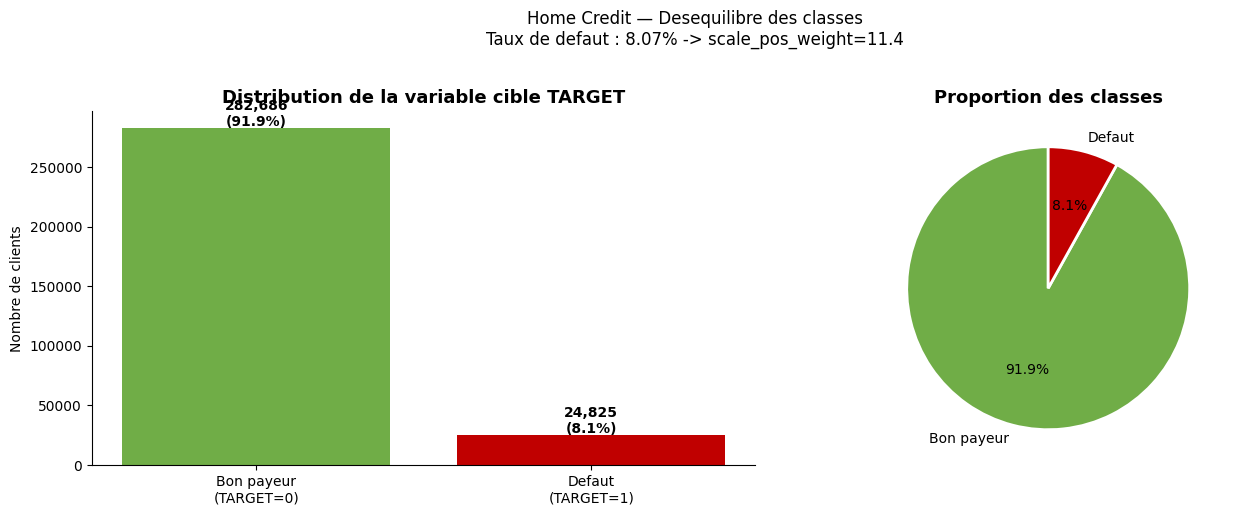


  VALEURS MANQUANTES :
  Variables avec NaN : 67 / 122

  FILTRE COLONNES >50% NaN :
  Colonnes exclues de la construction : 41
    - OWN_CAR_AGE (66% NaN)
    - EXT_SOURCE_1 (56% NaN)
    - APARTMENTS_AVG (51% NaN)
    - BASEMENTAREA_AVG (59% NaN)
    - YEARS_BUILD_AVG (66% NaN)
    - COMMONAREA_AVG (70% NaN)
    - ELEVATORS_AVG (53% NaN)
    - ENTRANCES_AVG (50% NaN)
    - FLOORSMIN_AVG (68% NaN)
    - LANDAREA_AVG (59% NaN)
    ... et 31 autres


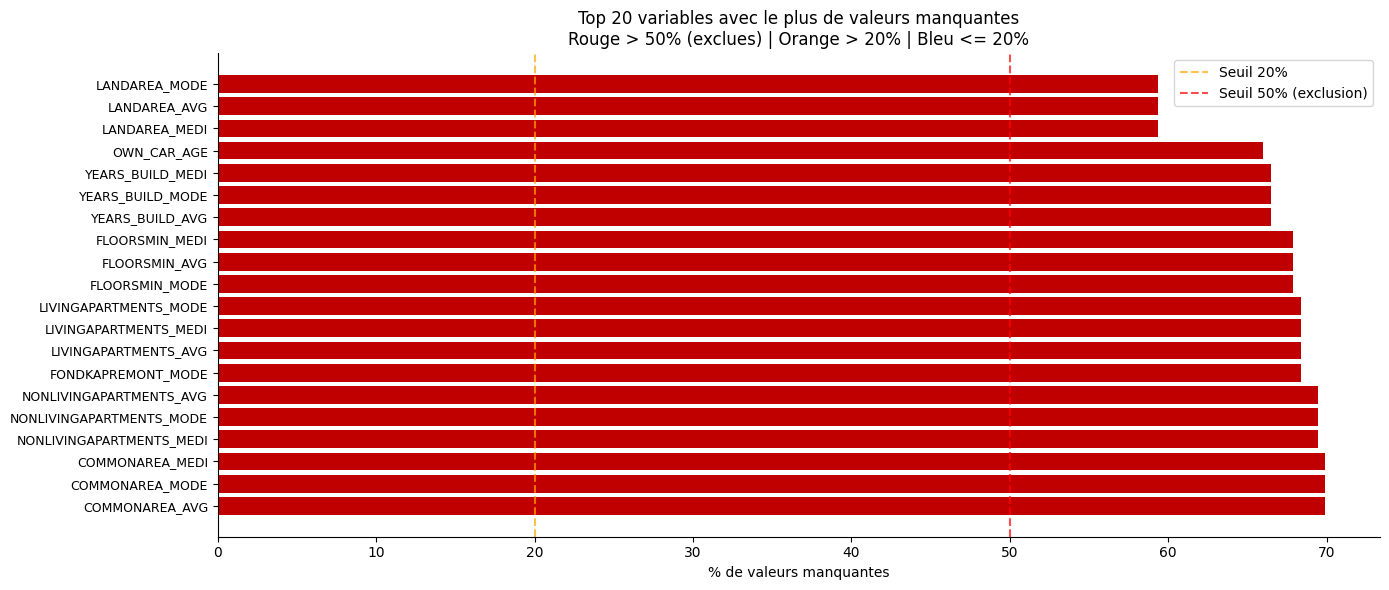


  VARIABLES CATEGORIELLE RETENUES (NaN <= 50%) :
  Total : 13 — le filtre IV (Section 4) decidera lesquelles conserver
    NAME_CONTRACT_TYPE                    2 modalites | 0.0% NaN
    CODE_GENDER                           3 modalites | 0.0% NaN
    FLAG_OWN_CAR                          2 modalites | 0.0% NaN
    FLAG_OWN_REALTY                       2 modalites | 0.0% NaN
    NAME_TYPE_SUITE                       7 modalites | 0.4% NaN
    NAME_INCOME_TYPE                      8 modalites | 0.0% NaN
    NAME_EDUCATION_TYPE                   5 modalites | 0.0% NaN
    NAME_FAMILY_STATUS                    6 modalites | 0.0% NaN
    NAME_HOUSING_TYPE                     6 modalites | 0.0% NaN
    OCCUPATION_TYPE                      18 modalites | 31.3% NaN
    WEEKDAY_APPR_PROCESS_START            7 modalites | 0.0% NaN
    ORGANIZATION_TYPE                    58 modalites | 0.0% NaN
    EMERGENCYSTATE_MODE                   2 modalites | 47.4% NaN

  CAS PARTICULIER DAYS_EMPLOYED 

In [2]:
# ============================================================
# SECTION 1 — EXPLORATION DU DATASET PRINCIPAL
# ============================================================

print('Chargement de application_train.csv...')
app_train = pd.read_csv(INPUT_DIR + 'application_train.csv')
print(f'OK {app_train.shape[0]:,} observations, {app_train.shape[1]} variables\n')

nb_total  = len(app_train)
nb_defaut = int(app_train['TARGET'].sum())
nb_bon    = nb_total - nb_defaut
taux      = nb_defaut / nb_total * 100

# --- 1.1 Desequilibre des classes ---
print('=' * 55)
print('  DESEQUILIBRE DES CLASSES')
print('=' * 55)
print(f'  Bons payeurs  (TARGET=0) : {nb_bon:>10,}  ({100-taux:.2f}%)')
print(f'  Defauts       (TARGET=1) : {nb_defaut:>10,}  ({taux:.2f}%)')

# scale_pos_weight : chaque defaut pese X fois plus qu'un bon payeur
# Calcule depuis les vraies donnees (pas un parametre arbitraire)
SCALE_POS_WEIGHT = nb_bon / nb_defaut
print(f'  scale_pos_weight (brut)  : {SCALE_POS_WEIGHT:.2f}')
print(f'  -> Chaque defaut compte {SCALE_POS_WEIGHT:.1f}x plus dans LightGBM')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Bon payeur\n(TARGET=0)', 'Defaut\n(TARGET=1)'],
            [nb_bon, nb_defaut], color=[COLORS['success'], COLORS['danger']])
axes[0].set_title('Distribution de la variable cible TARGET', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate([nb_bon, nb_defaut]):
    axes[0].text(i, v + 2000, f'{v:,}\n({[100-taux, taux][i]:.1f}%)', ha='center', fontweight='bold')

axes[1].pie([nb_bon, nb_defaut], labels=['Bon payeur', 'Defaut'],
            colors=[COLORS['success'], COLORS['danger']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')
plt.suptitle(f'Home Credit — Desequilibre des classes\nTaux de defaut : {taux:.2f}% -> scale_pos_weight={SCALE_POS_WEIGHT:.1f}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig1_desequilibre_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 1.2 Valeurs manquantes et filtre colonnes ---
nan_pct  = (app_train.isnull().sum() / nb_total * 100).sort_values(ascending=False)
cols_nan = nan_pct[nan_pct > 0]

print(f'\n  VALEURS MANQUANTES :')
print(f'  Variables avec NaN : {len(cols_nan)} / {app_train.shape[1]}')

# FILTRE COLONNES >50% NaN
# Raison : les colonnes avec >50% de NaN couvrent une fraction trop faible
# de la population (< 50% des clients). Les features derivees depuis ces colonnes
# reposent sur un sous-ensemble limite de clients et risquent d'etre peu
# generalisables. Le bin 'Missing' du WOE tendrait a devenir dominant,
# reduisant la capacite discriminante de la variable.
# Note : 30% de 307 511 = 92 000 obs — pas un probleme de robustesse statistique
# mais bien de couverture de la population.
# Ce filtre s'applique aux COLONNES sources, jamais aux CLIENTS (observations).
# La Section 4b calcule l'IV de toutes les colonnes exclues pour justification.
COLS_HIGH_NAN = [col for col in app_train.columns
                 if app_train[col].isnull().mean() > 0.50]
print(f'\n  FILTRE COLONNES >50% NaN :')
print(f'  Colonnes exclues de la construction : {len(COLS_HIGH_NAN)}')
for c in COLS_HIGH_NAN[:10]:
    print(f'    - {c} ({app_train[c].isnull().mean()*100:.0f}% NaN)')
if len(COLS_HIGH_NAN) > 10:
    print(f'    ... et {len(COLS_HIGH_NAN)-10} autres')

fig, ax = plt.subplots(figsize=(14, 6))
top_nan = cols_nan.head(20)
colors_nan = [COLORS['danger'] if v > 50 else COLORS['warning'] if v > 20
              else COLORS['secondary'] for v in top_nan.values]
ax.barh(range(len(top_nan)), top_nan.values, color=colors_nan)
ax.set_yticks(range(len(top_nan)))
ax.set_yticklabels(top_nan.index, fontsize=9)
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Top 20 variables avec le plus de valeurs manquantes\nRouge > 50% (exclues) | Orange > 20% | Bleu <= 20%', fontsize=12)
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Seuil 20%')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Seuil 50% (exclusion)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig2_valeurs_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 1.3 Construction de CAT_FEATURES (definitive) ---
# Toutes les variables categorielle de application_train.csv avec NaN <= 50%.
# Approche : inclure toutes, laisser le filtre IV (Section 4) decider.
# Aucune selection manuelle a priori — evite tout biais de selection.
all_cat = app_train.select_dtypes(include='object').columns.tolist()
CAT_FEATURES = [c for c in all_cat
                if c not in COLS_HIGH_NAN
                and app_train[c].isnull().mean() <= 0.50
                and c != 'SK_ID_CURR']

print(f'\n  VARIABLES CATEGORIELLE RETENUES (NaN <= 50%) :')
print(f'  Total : {len(CAT_FEATURES)} — le filtre IV (Section 4) decidera lesquelles conserver')
for c in CAT_FEATURES:
    n_mod = app_train[c].nunique()
    n_nan = app_train[c].isnull().mean() * 100
    print(f'    {c:<35} {n_mod:>3} modalites | {n_nan:.1f}% NaN')

# --- 1.4 Cas particulier DAYS_EMPLOYED ---
nb_365243 = (app_train['DAYS_EMPLOYED'] == 365243).sum()
print(f'\n  CAS PARTICULIER DAYS_EMPLOYED = 365243 :')
print(f'  {nb_365243:,} clients ({nb_365243/nb_total*100:.1f}%) — retraites/sans-emploi')
print(f'  -> Sera remplace par NaN au feature engineering')
print(f'  -> WOE creera un bin "Manquant" pour ces clients')

nb_num = app_train.select_dtypes(include=[np.number]).shape[1]
nb_cat = app_train.select_dtypes(include=['object']).shape[1]
print(f'\n  TYPES : {nb_num} numeriques | {nb_cat} categorielle')

print('\nOK SECTION 1 TERMINEE')
print(f'   scale_pos_weight = {SCALE_POS_WEIGHT:.2f} (utilise en Section 7)')
print(f'   CAT_FEATURES = {len(CAT_FEATURES)} variables (utilisees en Sections 2, 4, 5)')


**Interpretation :** Le taux de defaut de ~8.07% justifie `scale_pos_weight` (pas SMOTE).
Chaque defaut pesera ~11.4x plus qu'un bon payeur. Les colonnes >50% NaN sont exclues
de la construction — les clients restent tous dans le dataset.


---
## SECTION 2 — Feature Engineering

**10 familles de features :**

| Famille | Source | Role |
|---|---|---|
| F1 — Couverture | Pipeline | Richesse informationnelle, detection thin-file |
| F2 — Identite temporelle | application_train | Age, anciennete emploi, stabilite |
| F3 — Transactionnel (POS+CC x3 fenetres) | POS_CASH + credit_card | Comportement recent |
| F4 — Remboursement | installments_payments | Discipline de paiement |
| F5 — Bureau de credit | bureau | Engagements autres institutions |
| F6 — Demandes precedentes | previous_application | Historique de demandes |
| F7 — Declaratives binaires | application_train | Variables a 2 modalites |
| F8 — Ratios financiers | application_train | Charge vs revenu, endettement |
| F9 — Categorielle (WOE) | application_train | Multi-modalites pour WOE |
| EXT_SOURCE | application_train | Scores bureau externe |

**Corrections appliquees vs version precedente :**
- `payment_ratio` : `np.where` au lieu de `+1e-9` (evite aberrations si AMT_INSTALMENT=0)
- `loan_to_income_ratio` = AMT_CREDIT/AMT_INCOME (renomme correctement)
- `debt_to_income` = AMT_ANNUITY/AMT_INCOME (charge mensuelle / revenu)
- `inst_ever_late` et `inst_pct_late` dans F4 (bloc correct)
- `CAT_FEATURES` utilisee depuis Section 0 (pas redefinie ici)


In [3]:
# ============================================================
# SECTION 2 — FEATURE ENGINEERING COMPLET
# Regle absolue : NaN = absence d'info. Jamais d'imputation.
# Exception F1 : fillna(0) car 0 tx = valeur connue, pas une absence.
# ============================================================
t0 = time.time()

print('Chargement des fichiers source...')
app    = pd.read_csv(INPUT_DIR + 'application_train.csv')
pos    = pd.read_csv(INPUT_DIR + 'POS_CASH_balance.csv')
cc     = pd.read_csv(INPUT_DIR + 'credit_card_balance.csv')
inst   = pd.read_csv(INPUT_DIR + 'installments_payments.csv')
bureau = pd.read_csv(INPUT_DIR + 'bureau.csv')
bur_bal= pd.read_csv(INPUT_DIR + 'bureau_balance.csv')
prev   = pd.read_csv(INPUT_DIR + 'previous_application.csv')

for name, df in [('application_train', app), ('POS_CASH_balance', pos),
                  ('credit_card_balance', cc), ('installments_payments', inst),
                  ('bureau', bureau), ('bureau_balance', bur_bal),
                  ('previous_application', prev)]:
    print(f'  OK {name:<35} {df.shape[0]:>10,} lignes x {df.shape[1]:>3} colonnes')

features = app[['SK_ID_CURR', 'TARGET']].copy()

# ============================================================
# FAMILLE F1 — COUVERTURE (5 features)
# Seule famille avec fillna(0) : 0 transaction = valeur connue
# ============================================================
print('\n[F1] Couverture des donnees...')

hist_length = (inst.groupby('SK_ID_CURR')['DAYS_INSTALMENT']
               .min().abs().reset_index()
               .rename(columns={'DAYS_INSTALMENT': 'history_length_days'}))
features = features.merge(hist_length, on='SK_ID_CURR', how='left')
features['history_length_days'] = features['history_length_days'].fillna(0)

nb_tx_pos = pos.groupby('SK_ID_CURR').size().reset_index(name='nb_tx_pos')
nb_tx_cc  = cc.groupby('SK_ID_CURR').size().reset_index(name='nb_tx_cc')
features  = features.merge(nb_tx_pos, on='SK_ID_CURR', how='left')
features  = features.merge(nb_tx_cc,  on='SK_ID_CURR', how='left')
features['nb_tx_pos'] = features['nb_tx_pos'].fillna(0)
features['nb_tx_cc']  = features['nb_tx_cc'].fillna(0)
features['nb_transactions_total'] = features['nb_tx_pos'] + features['nb_tx_cc']

clients_bureau = set(bureau['SK_ID_CURR'].unique())
clients_inst   = set(inst['SK_ID_CURR'].unique())
features['has_external_data']     = features['SK_ID_CURR'].isin(clients_bureau).astype(int)
features['has_repayment_history'] = features['SK_ID_CURR'].isin(clients_inst).astype(int)

# has_history = 0 -> client thin-file (aucun comportement financier enregistre)
features['has_history'] = (
    (features['nb_transactions_total'] > 0) |
    (features['has_repayment_history'] == 1)
).astype(int)
n_thin = (features['has_history'] == 0).sum()
print(f'  Thin-file (has_history=0) : {n_thin:,} clients ({n_thin/len(features)*100:.1f}%)')

# ============================================================
# FAMILLE F2 — IDENTITE TEMPORELLE (3 features)
# DAYS_* sont negatifs dans Home Credit -> valeur absolue
# Division par 365.25 (annees bissextiles incluses)
# DAYS_EMPLOYED = 365243 -> valeur sentinelle retraite/sans-emploi -> NaN
# ============================================================
print('[F2] Identite temporelle...')

app_temp = app[['SK_ID_CURR', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
                 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']].copy()
app_temp['DAYS_EMPLOYED'] = app_temp['DAYS_EMPLOYED'].replace(365243, np.nan)
app_temp['age_years']          = (-app_temp['DAYS_BIRTH'])       / 365.25
app_temp['employment_years']   = (-app_temp['DAYS_EMPLOYED'])    / 365.25
app_temp['registration_years'] = (-app_temp['DAYS_REGISTRATION'])/ 365.25

features = features.merge(
    app_temp[['SK_ID_CURR', 'age_years', 'employment_years',
              'registration_years', 'DAYS_ID_PUBLISH']],
    on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F3 — COMPORTEMENT TRANSACTIONNEL (22 features)
# POS = credits point de vente (achat en magasin)
# CC  = cartes de credit (revolving)
# 3 fenetres : 3, 6, 12 mois
# MONTHS_BALANCE negatif : -3 = il y a 3 mois avant la demande
# SK_DPD = Days Past Due = jours de retard ce mois (fourni par Home Credit)
# ============================================================
print('[F3] Comportement transactionnel (POS + CC x 3 fenetres)...')

def build_tx_features(df_src, prefix, windows=None):
    if windows is None:
        windows = [3, 6, 12]
    result = pd.DataFrame({'SK_ID_CURR': df_src['SK_ID_CURR'].unique()})
    for w in windows:
        # Filtre fenetre : MONTHS_BALANCE >= -W garde les W derniers mois
        df_w = df_src[df_src['MONTHS_BALANCE'] >= -w].copy()
        # Mois distincts actifs (un client peut avoir plusieurs lignes par mois)
        nb_mois = df_w.groupby('SK_ID_CURR')['MONTHS_BALANCE'].nunique().reset_index()
        nb_mois.columns = ['SK_ID_CURR', f'{prefix}_nb_mois_{w}m']
        result = result.merge(nb_mois, on='SK_ID_CURR', how='left')
        if 'SK_DPD' in df_w.columns:
            df_w['is_late'] = (df_w['SK_DPD'] > 0).astype(int)
            taux = df_w.groupby('SK_ID_CURR')['is_late'].mean().reset_index()
            taux.columns = ['SK_ID_CURR', f'{prefix}_taux_retard_{w}m']
            dpd  = df_w.groupby('SK_ID_CURR')['SK_DPD'].mean().reset_index()
            dpd.columns = ['SK_ID_CURR', f'{prefix}_dpd_moyen_{w}m']
            result = result.merge(taux, on='SK_ID_CURR', how='left')
            result = result.merge(dpd,  on='SK_ID_CURR', how='left')
    return result

pos_features = build_tx_features(pos, 'pos')
cc_features  = build_tx_features(cc,  'cc')
features = features.merge(pos_features, on='SK_ID_CURR', how='left')
features = features.merge(cc_features,  on='SK_ID_CURR', how='left')

# Features POS sur tout l'historique
pos['is_late_all'] = (pos['SK_DPD'] > 0).astype(int)
pos_all = pos.groupby('SK_ID_CURR').agg(
    pos_avg_dpd_all=('SK_DPD', 'mean'),
    pos_ever_late=('is_late_all', 'max')
).reset_index()
features = features.merge(pos_all, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F4 — REMBOURSEMENT (5 features)
# Source : installments_payments.csv
# delay_days = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT (variable intermediaire)
#   Positif = retard | Negatif = paiement anticipe
# inst_ever_late et inst_pct_late : features de retard sur mensualites directes
# ============================================================
print('[F4] Remboursement...')

inst['delay_days']     = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['is_late_inst']   = (inst['delay_days'] > 0).astype(int)
inst['is_late_30d']    = (inst['delay_days'] > 30).astype(int)

inst_flags = inst.groupby('SK_ID_CURR').agg(
    inst_ever_late=('is_late_inst', 'max'),   # au moins un retard (tout historique)
    inst_pct_late=('is_late_30d', 'mean')     # % mensualites avec retard > 30j
).reset_index()
features = features.merge(inst_flags, on='SK_ID_CURR', how='left')

# CORRECTION vs version precedente : np.where au lieu de +1e-9
# Si AMT_INSTALMENT = 0 -> ratio non calculable -> NaN (pas de valeur aberrante)
inst['payment_ratio'] = np.where(
    inst['AMT_INSTALMENT'] > 0,
    inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'],
    np.nan)
inst['payment_diff'] = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']

remb = inst.groupby('SK_ID_CURR').agg(
    avg_payment_diff=('payment_diff', 'mean'),   # sous-paiement si negatif
    avg_payment_ratio=('payment_ratio', 'mean'), # couverture moyenne mensualite
    std_payment_ratio=('payment_ratio', 'std'),  # irregularite des paiements
).reset_index()
features = features.merge(remb, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F5 — BUREAU DE CREDIT (3 features)
# ============================================================
print('[F5] Bureau de credit...')

bureau['is_active'] = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_nb_credits=('SK_ID_BUREAU', 'count'),
    bureau_active_count=('is_active', 'sum'),
    bureau_debt_total=('AMT_CREDIT_SUM_DEBT', 'sum')
).reset_index()
features = features.merge(bureau_agg, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F6 — DEMANDES PRECEDENTES (3 features)
# Un client souvent refuse a un profil de risque plus eleve
# ============================================================
print('[F6] Demandes precedentes...')

prev['is_refused'] = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
prev_agg = prev.groupby('SK_ID_CURR').agg(
    prev_nb_demandes=('SK_ID_PREV', 'count'),
    prev_refused_ratio=('is_refused', 'mean'),
    prev_avg_down_payment=('AMT_DOWN_PAYMENT', 'mean')
).reset_index()
features = features.merge(prev_agg, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F7 — DECLARATIVES BINAIRES (4 features)
# Variables a 2 modalites -> encodage binaire direct
# ============================================================
print('[F7] Declaratives binaires...')

features['CODE_GENDER_bin']     = (app['CODE_GENDER'] == 'M').astype(float).values
features['FLAG_OWN_CAR_bin']    = (app['FLAG_OWN_CAR'] == 'Y').astype(float).values
features['FLAG_OWN_REALTY_bin'] = (app['FLAG_OWN_REALTY'] == 'Y').astype(float).values
features['REGION_RATING_CLIENT']= app['REGION_RATING_CLIENT'].values

# ============================================================
# FAMILLE F8 — RATIOS FINANCIERS (4 features)
# CORRECTION vs version precedente :
# loan_to_income_ratio = AMT_CREDIT / AMT_INCOME (montant total / revenu annuel)
# debt_to_income       = AMT_ANNUITY / AMT_INCOME (mensualite / revenu mensuel)
# Ces deux ratios mesurent des dimensions DIFFERENTES du risque.
# ============================================================
print('[F8] Ratios financiers...')

# loan_to_income : le credit total represent combien d'annees de revenu ?
features['loan_to_income_ratio'] = np.where(
    app['AMT_INCOME_TOTAL'] > 0,
    app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL'], np.nan)

# debt_to_income : la mensualite est quelle fraction du revenu mensuel ?
features['debt_to_income'] = np.where(
    app['AMT_INCOME_TOTAL'] > 0,
    app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL'], np.nan)

# annuity_to_credit : mensualite / credit total (vitesse de remboursement)
features['annuity_to_credit'] = np.where(
    app['AMT_CREDIT'] > 0,
    app['AMT_ANNUITY'] / app['AMT_CREDIT'], np.nan)

# goods_to_credit : valeur du bien / credit (credit calibre au bien ?)
features['goods_to_credit'] = np.where(
    app['AMT_CREDIT'] > 0,
    app['AMT_GOODS_PRICE'] / app['AMT_CREDIT'], np.nan)

# ============================================================
# FAMILLE F9 — CATEGORIELLE MULTI-MODALITES (pour WOE)
# On inclut TOUTES les categorielle valides (NaN <= 50%)
# Le filtre IV en Section 4 decidera lesquelles conserver.
# Aucune selection manuelle a priori.
# ============================================================
print('[F9] Categorielle multi-modalites (toutes celles de Section 1)...')
app_cat  = app[['SK_ID_CURR'] + CAT_FEATURES].copy()
features = features.merge(app_cat, on='SK_ID_CURR', how='left')
for col in CAT_FEATURES:
    n_mod = features[col].nunique()
    n_nan = features[col].isna().sum()
    print(f'  OK {col:<35} {n_mod:>3} modalites | NaN={n_nan:,}')

# ============================================================
# EXT_SOURCE — Scores de bureau externe
# Opaques : calcul inconnu. En production africaine -> features Mobile Money
# ============================================================
print('[EXT] EXT_SOURCE...')
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    features[col] = app[col].values

# ============================================================
# BILAN
# ============================================================
EXCLUDE_COLS = ['SK_ID_CURR', 'TARGET', 'DAYS_ID_PUBLISH', 'nb_tx_pos', 'nb_tx_cc']
feature_cols = [c for c in features.columns if c not in EXCLUDE_COLS]

print(f'\n{"=" * 60}')
print('  BILAN DU FEATURE ENGINEERING')
print(f'{"=" * 60}')
print(f'  Observations         : {len(features):>10,}')
print(f'  Features totales     : {len(feature_cols):>8}')
print(f'  Dont categorielle    : {len(CAT_FEATURES):>8} (brutes pour WOE)')
print(f'  Thin-file identifies : {(features["has_history"]==0).sum():>8,}')
print(f'  Taux defaut preserve : {features["TARGET"].mean()*100:>7.2f}%')
print(f'  Total NaN            : {features[feature_cols].isnull().sum().sum():>10,}')
print(f'  Temps                : {time.time()-t0:.0f}s')
print(f'\n  Liste des features (par famille) :')
for i, c in enumerate(feature_cols):
    dtype = 'CAT' if c in CAT_FEATURES else 'NUM'
    print(f'    [{i+1:02d}] {dtype} {c}')

features.to_csv(DATA_DIR + 'features_engineered_307k.csv', index=False)
print(f'\n  features_engineered_307k.csv sauvegarde')


# ============================================================
# FAMILLE_MAPPING — CONSTRUCTION DYNAMIQUE (fin Section 2)
# Chaque famille enregistre ses features au moment de leur creation.
# Generique : fonctionne pour n'importe quelle banque avec n'importe quel nom.
# ============================================================
import json as _json

# F1 — Couverture (features creees dans le bloc F1)
_f1 = ['history_length_days', 'nb_transactions_total',
       'has_external_data', 'has_repayment_history', 'has_history']
FAMILLE_MAPPING.update({f: 'F1' for f in _f1 if f in features.columns})

# F2 — Identite temporelle
_f2 = ['age_years', 'employment_years', 'registration_years']
FAMILLE_MAPPING.update({f: 'F2' for f in _f2 if f in features.columns})

# F3 — Transactionnel (tous les prefixes pos_ et cc_)
_f3 = [c for c in features.columns if c.startswith('pos_') or c.startswith('cc_')]
FAMILLE_MAPPING.update({f: 'F3' for f in _f3})

# F4 — Remboursement
_f4 = ['inst_ever_late', 'inst_pct_late', 'avg_payment_diff',
       'avg_payment_ratio', 'std_payment_ratio']
FAMILLE_MAPPING.update({f: 'F4' for f in _f4 if f in features.columns})

# F5 — Bureau de credit
_f5 = ['bureau_nb_credits', 'bureau_active_count', 'bureau_debt_total']
FAMILLE_MAPPING.update({f: 'F5' for f in _f5 if f in features.columns})

# F6 — Demandes precedentes
_f6 = ['prev_nb_demandes', 'prev_refused_ratio', 'prev_avg_down_payment']
FAMILLE_MAPPING.update({f: 'F6' for f in _f6 if f in features.columns})

# F7 — Declaratives binaires (toujours disponibles — saisie agent)
_f7 = ['CODE_GENDER_bin', 'FLAG_OWN_CAR_bin',
       'FLAG_OWN_REALTY_bin', 'REGION_RATING_CLIENT']
FAMILLE_MAPPING.update({f: 'F7' for f in _f7 if f in features.columns})

# F8 — Ratios financiers (toujours disponibles — saisie agent)
_f8 = ['loan_to_income_ratio', 'debt_to_income',
       'annuity_to_credit', 'goods_to_credit']
FAMILLE_MAPPING.update({f: 'F8' for f in _f8 if f in features.columns})

# F9 — Categorielle (toujours disponibles — saisie agent)
FAMILLE_MAPPING.update({f: 'F9' for f in CAT_FEATURES if f in features.columns})

# EXT_SOURCE — Scores bureau externe
_ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
FAMILLE_MAPPING.update({f: 'EXT' for f in _ext if f in features.columns})

# Sauvegarder pour Section 6b (generique)
_json.dump(FAMILLE_MAPPING, open(DATA_DIR + 'famille_mapping.json', 'w'), indent=2)

# Rapport
_total = len(FAMILLE_MAPPING)
_par_famille = {}
for f, fam in FAMILLE_MAPPING.items():
    _par_famille[fam] = _par_famille.get(fam, 0) + 1
print(f'\nOK FAMILLE_MAPPING : {_total} features taggees')
for fam in sorted(_par_famille):
    print(f'   {fam} : {_par_famille[fam]} features')
print(f'   Sauvegarde : {DATA_DIR}famille_mapping.json')

print(f'OK SECTION 2 TERMINEE — {len(feature_cols)} features construites')


Chargement des fichiers source...
  OK application_train                      307,511 lignes x 122 colonnes
  OK POS_CASH_balance                    10,001,358 lignes x   8 colonnes
  OK credit_card_balance                  3,840,312 lignes x  23 colonnes
  OK installments_payments               13,605,401 lignes x   8 colonnes
  OK bureau                               1,716,428 lignes x  17 colonnes
  OK bureau_balance                      27,299,925 lignes x   3 colonnes
  OK previous_application                 1,670,214 lignes x  37 colonnes

[F1] Couverture des donnees...
  Thin-file (has_history=0) : 15,225 clients (5.0%)
[F2] Identite temporelle...
[F3] Comportement transactionnel (POS + CC x 3 fenetres)...
[F4] Remboursement...
[F5] Bureau de credit...
[F6] Demandes precedentes...
[F7] Declaratives binaires...
[F8] Ratios financiers...
[F9] Categorielle multi-modalites (toutes celles de Section 1)...
  OK NAME_CONTRACT_TYPE                    2 modalites | NaN=0
  OK CODE_GENDE

**Interpretation :** Les NaN pour les clients thin-file sont intentionnels — ils seront transformes en signal quantifie par le bin 'Manquant' du WOE en Section 5.


---
## SECTION 3 — Split Temporel 70/15/15

**Pourquoi temporel et non aleatoire :** en production, le modele est toujours
evalue sur des profils posterieurs a sa periode d'entrainement.
Un split aleatoire = data leakage temporel.

**Proxy utilise :** `DAYS_ID_PUBLISH` — les valeurs les plus negatives sont les plus anciennes.


Chargement des features...

  SPLIT TEMPOREL 70/15/15
  Partition     Observations    Defauts     Taux
  --------------------------------------------------
  Train              215,257     15,813    7.35%
  Validation          46,126      4,333    9.39%
  Test                46,128      4,679   10.14%

  Ecart taux defaut train/test : 2.80pts
  OK Acceptable (< 3pts)


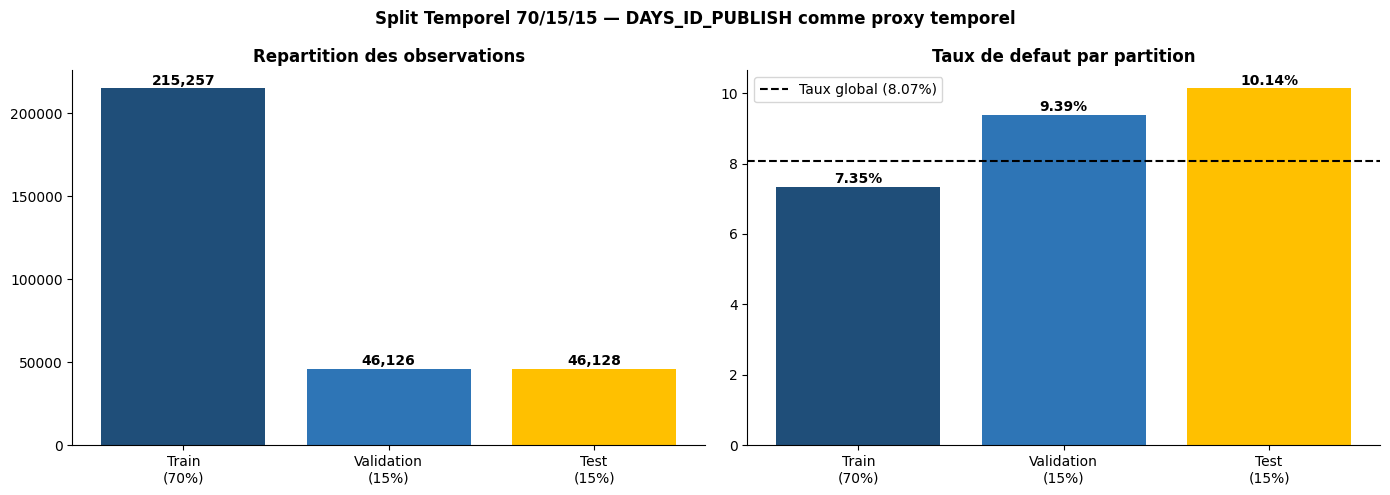


OK SECTION 3 TERMINEE


In [4]:
# ============================================================
# SECTION 3 — SPLIT TEMPOREL 70/15/15
# ============================================================

print('Chargement des features...')
features = pd.read_csv(DATA_DIR + 'features_engineered_307k.csv')
EXCLUDE_COLS = ['SK_ID_CURR', 'TARGET', 'DAYS_ID_PUBLISH', 'nb_tx_pos', 'nb_tx_cc']
feature_cols = [c for c in features.columns if c not in EXCLUDE_COLS]

# Tri croissant par DAYS_ID_PUBLISH (du plus ancien au plus recent)
# DAYS_ID_PUBLISH est negatif : -3000 est plus ancien que -100
features_sorted = features.sort_values('DAYS_ID_PUBLISH').reset_index(drop=True)

N       = len(features_sorted)
n_train = int(N * 0.70)
n_val   = int(N * 0.15)

# Decoupage positionnel — pas de shuffle aleatoire
train_df = features_sorted.iloc[:n_train].copy()
val_df   = features_sorted.iloc[n_train:n_train + n_val].copy()
test_df  = features_sorted.iloc[n_train + n_val:].copy()

X_train = train_df[feature_cols].reset_index(drop=True)
X_val   = val_df[feature_cols].reset_index(drop=True)
X_test  = test_df[feature_cols].reset_index(drop=True)
y_train = train_df['TARGET'].reset_index(drop=True)
y_val   = val_df['TARGET'].reset_index(drop=True)
y_test  = test_df['TARGET'].reset_index(drop=True)

print(f'\n{"=" * 65}')
print('  SPLIT TEMPOREL 70/15/15')
print(f'{"=" * 65}')
print(f'  {"Partition":<12} {"Observations":>13} {"Defauts":>10} {"Taux":>8}')
print(f'  {"-" * 50}')
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    nd = int(y.sum())
    print(f'  {name:<12} {len(y):>13,} {nd:>10,} {nd/len(y)*100:>7.2f}%')

ecart = abs(y_train.mean() - y_test.mean()) * 100
print(f'\n  Ecart taux defaut train/test : {ecart:.2f}pts')
stt = 'OK Acceptable (< 3pts)' if ecart < 3 else 'ATTENTION Ecart > 3pts'
print(f'  {stt}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Train\n(70%)', 'Validation\n(15%)', 'Test\n(15%)']
sizes  = [len(X_train), len(X_val), len(X_test)]
colors = [COLORS['primary'], COLORS['secondary'], COLORS['warning']]
axes[0].bar(labels, sizes, color=colors)
axes[0].set_title('Repartition des observations', fontweight='bold')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

taux_vals = [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100]
axes[1].bar(labels, taux_vals, color=colors)
axes[1].axhline(y=features['TARGET'].mean()*100, color='black', linestyle='--',
                label=f'Taux global ({features["TARGET"].mean()*100:.2f}%)')
axes[1].set_title('Taux de defaut par partition', fontweight='bold')
axes[1].legend()
for i, v in enumerate(taux_vals):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Split Temporel 70/15/15 — DAYS_ID_PUBLISH comme proxy temporel',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig3_split_temporel.png', dpi=150, bbox_inches='tight')
plt.show()

for name, arr in [('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
    arr.to_csv(DATA_DIR + f'{name}.csv', index=False)
X_train.to_csv(DATA_DIR + 'X_train_raw.csv', index=False)
X_val.to_csv(DATA_DIR + 'X_val_raw.csv', index=False)
X_test.to_csv(DATA_DIR + 'X_test_raw.csv', index=False)
print('\nOK SECTION 3 TERMINEE')


**Interpretation :** Un ecart de taux de defaut train/test est normal et attendu dans un split temporel — il reflete une derive reelle dans le temps.


---
## SECTION 4 — Pre-filtre par Information Value (IV)

**Seuil IV = 0.02** — standard bancaire (Siddiqi, 2006).

| IV | Interpretation |
|---|---|
| < 0.02 | Pas de signal -> eliminee |
| 0.02 – 0.10 | Signal faible mais reel |
| 0.10 – 0.30 | Signal moyen |
| > 0.30 | Signal fort |

**Calcule sur le train uniquement.** Variables categorielle passent avec `dtype='categorical'`.


Calcul des IV — 63 features a evaluer...
  Seuil IV : 0.02 (Siddiqi 2006 — standard bancaire international)
  Progression : 0/63...
  Progression : 15/63...
  Progression : 30/63...
  Progression : 45/63...
  Progression : 60/63...

  RESULTATS DU PRE-FILTRE IV
  Features initiales : 63
  Features retenues  : 27 (IV >= 0.02)
  Features eliminees : 36

  Top 25 features par IV :
  Feature                                             IV         Type Statut
  ---------------------------------------------------------------------------
  OK EXT_SOURCE_3                                  0.3216    numerical
  OK EXT_SOURCE_2                                  0.3080    numerical
  OK EXT_SOURCE_1                                  0.1403    numerical
  OK annuity_to_credit                             0.1128    numerical
  OK employment_years                              0.1079    numerical
  OK OCCUPATION_TYPE                               0.0880  categorical
  OK age_years                        

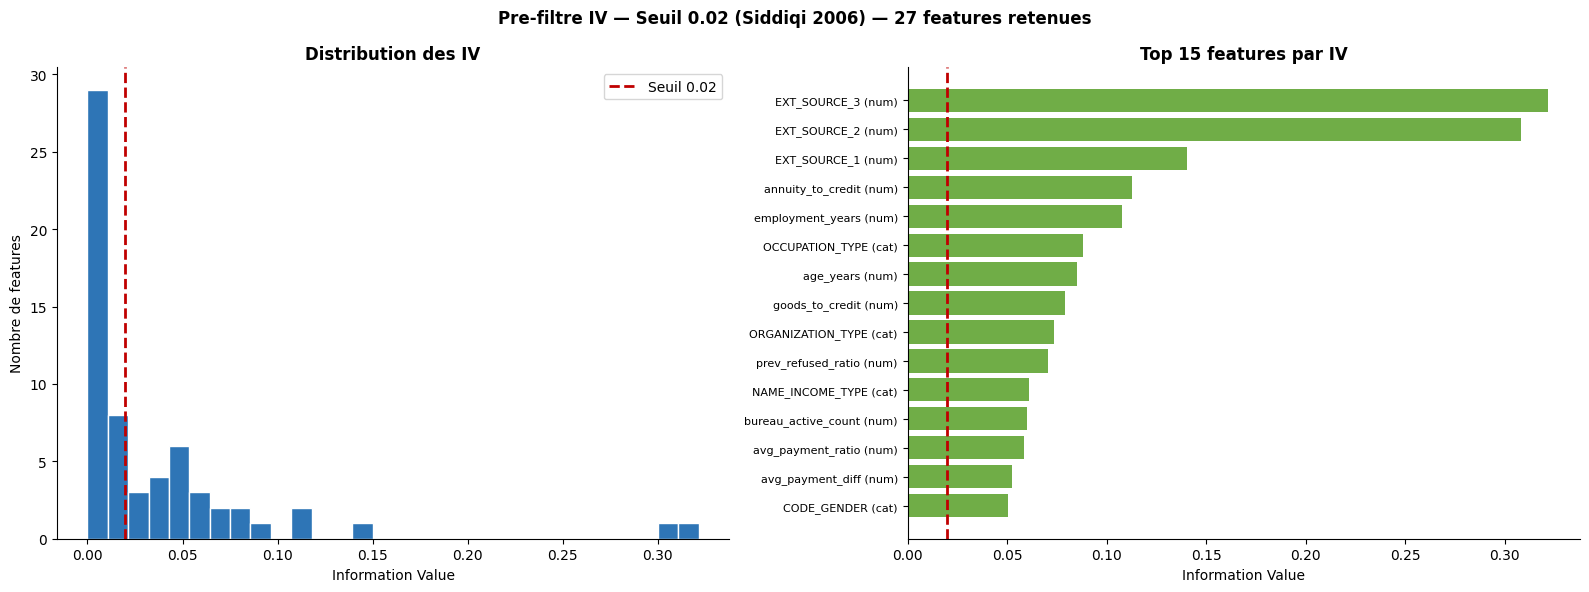


OK SECTION 4 TERMINEE — 27 features pretes pour WOE


In [5]:
# ============================================================
# SECTION 4 — PRE-FILTRE PAR INFORMATION VALUE
# Calcule sur le train UNIQUEMENT — jamais sur val ou test
# Seuil IV = 0.02 (Siddiqi 2006, standard bancaire)
# ============================================================

print(f'Calcul des IV — {len(feature_cols)} features a evaluer...')
print(f'  Seuil IV : {IV_THRESHOLD} (Siddiqi 2006 — standard bancaire international)')

iv_results = {}

for idx, col in enumerate(feature_cols):
    if idx % 15 == 0:
        print(f'  Progression : {idx}/{len(feature_cols)}...')
    dtype = 'categorical' if col in CAT_FEATURES else 'numerical'
    try:
        ob = OptimalBinning(name=col, dtype=dtype, solver='cp',
                            max_n_bins=10, min_bin_size=0.05)
        ob.fit(X_train[col].values, y_train.values)
        if ob.status not in ['OPTIMAL', 'FEASIBLE']:
            ob2 = OptimalBinning(name=col, dtype=dtype, solver='cp',
                                  max_n_bins=10, min_bin_size=0.01)
            ob2.fit(X_train[col].values, y_train.values)
            ob = ob2 if ob2.status in ['OPTIMAL', 'FEASIBLE'] else ob
        ob.binning_table.build()
        iv = ob.binning_table.iv
        decision = 'retained' if iv >= IV_THRESHOLD else 'rejected'
        iv_results[col] = {'iv': iv, 'dtype': dtype, 'decision': decision}
    except Exception:
        iv_results[col] = {'iv': 0.0, 'dtype': dtype, 'decision': 'error'}

df_iv = pd.DataFrame(iv_results).T.reset_index()
df_iv.columns = ['feature', 'iv', 'dtype', 'decision']
df_iv['iv'] = df_iv['iv'].astype(float)
df_iv = df_iv.sort_values('iv', ascending=False).reset_index(drop=True)
features_iv = df_iv[df_iv['decision'] == 'retained']['feature'].tolist()

print(f'\n{"="*65}')
print('  RESULTATS DU PRE-FILTRE IV')
print(f'{"="*65}')
print(f'  Features initiales : {len(feature_cols)}')
print(f'  Features retenues  : {len(features_iv)} (IV >= {IV_THRESHOLD})')
print(f'  Features eliminees : {len(feature_cols) - len(features_iv)}')
print(f'\n  Top 25 features par IV :')
print(f'  {"Feature":<45} {"IV":>8} {"Type":>12} {"Statut"}')
print(f'  {"-" * 75}')
for _, row in df_iv.head(25).iterrows():
    marker = 'OK' if row['decision'] == 'retained' else 'XX'
    print(f'  {marker} {row["feature"]:<43} {row["iv"]:>8.4f} {row["dtype"]:>12}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(df_iv['iv'].values, bins=30, color=COLORS['secondary'], edgecolor='white')
axes[0].axvline(x=IV_THRESHOLD, color=COLORS['danger'], linestyle='--', linewidth=2,
                label=f'Seuil {IV_THRESHOLD}')
axes[0].set_xlabel('Information Value')
axes[0].set_ylabel('Nombre de features')
axes[0].set_title('Distribution des IV', fontweight='bold')
axes[0].legend()

top15 = df_iv.head(15)
colors_bar = [COLORS['success'] if v >= IV_THRESHOLD else COLORS['danger']
               for v in top15['iv']]
axes[1].barh(range(len(top15)), top15['iv'].values[::-1], color=colors_bar[::-1])
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([f"{r['feature'][:30]} ({r['dtype'][:3]})"
                          for _, r in top15.iloc[::-1].iterrows()], fontsize=8)
axes[1].axvline(x=IV_THRESHOLD, color=COLORS['danger'], linestyle='--', linewidth=2)
axes[1].set_xlabel('Information Value')
axes[1].set_title('Top 15 features par IV', fontweight='bold')

plt.suptitle(f'Pre-filtre IV — Seuil {IV_THRESHOLD} (Siddiqi 2006) — {len(features_iv)} features retenues',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig4_prefiltre_iv.png', dpi=150, bbox_inches='tight')
plt.show()

X_train_iv = X_train[features_iv].copy()
X_val_iv   = X_val[features_iv].copy()
X_test_iv  = X_test[features_iv].copy()

df_iv.to_csv(ART_DIR + 'iv_scores_final.csv', index=False)
X_train_iv.to_csv(DATA_DIR + 'X_train_iv.csv', index=False)
X_val_iv.to_csv(DATA_DIR + 'X_val_iv.csv', index=False)
X_test_iv.to_csv(DATA_DIR + 'X_test_iv.csv', index=False)
print(f'\nOK SECTION 4 TERMINEE — {len(features_iv)} features pretes pour WOE')


---
## SECTION 4b — Justification de l'exclusion des colonnes haute-NaN

**Objectif académique :** calculer l'IV de toutes les colonnes exclues (>50% NaN)
pour prouver que leur exclusion est justifiée.

**Règle appliquée :**
- Si IV < 0.02 → exclusion pleinement justifiée (pas de signal)
- Si IV >= 0.02 et < 0.10 → exclusion par couverture insuffisante (signal faible)
- **Si IV >= 0.10 → réintégration automatique** dans X_train_iv avant WOE

Cette approche est défendable devant jury : on ne supprime jamais une variable
sans avoir calculé son IV réel.


In [6]:
# ============================================================
# SECTION 4b — JUSTIFICATION EXCLUSION COLONNES HAUTE-NAN
# Calcul IV sur les colonnes exclues -> preuve academique
# Cas C : IV >= 0.10 -> reintegration automatique dans X_train_iv
# ============================================================

print('=' * 65)
print('  SECTION 4b — JUSTIFICATION EXCLUSION COLONNES >50% NaN')
print('=' * 65)
print('  Calcul IV sur les colonnes exclues pour preuve...')

iv_high_nan_results = {}

for col in COLS_HIGH_NAN:
    nan_rate_train = X_train[col].isna().mean() if col in X_train.columns else 0.0
    if nan_rate_train == 0.0:
        # Colonne non presente dans X_train (deja absente du feature_cols)
        # Recuperer depuis app_train
        mask_train = train_df.index if 'train_df' in dir() else slice(None)
        try:
            col_train = app_train[col].iloc[:len(y_train)].values
            y_data    = y_train.values
        except Exception:
            iv_high_nan_results[col] = {
                'nan_rate_pct': 0.0, 'iv': 0.0,
                'dtype': 'unknown', 'n_obs': 0
            }
            continue
        nan_rate_train = pd.Series(col_train).isna().mean()
    else:
        col_train = X_train[col].values
        y_data    = y_train.values

    dtype = 'categorical' if app_train[col].dtype == 'object' else 'numerical'
    n_obs = int(pd.Series(col_train).notna().sum())

    try:
        ob = OptimalBinning(
            name=col, dtype=dtype, solver='cp',
            max_n_bins=10, min_bin_size=0.01
        )
        ob.fit(col_train, y_data)
        ob.binning_table.build()
        iv = ob.binning_table.iv
    except Exception:
        iv = 0.0

    iv_high_nan_results[col] = {
        'nan_rate_pct': round(nan_rate_train * 100, 1),
        'iv': round(float(iv), 4),
        'dtype': dtype,
        'n_obs_non_nan': n_obs
    }

# Construire le DataFrame
df_exclusion = pd.DataFrame(iv_high_nan_results).T.reset_index()
df_exclusion.columns = ['feature', 'nan_rate_pct', 'iv', 'dtype', 'n_obs_non_nan']
df_exclusion = df_exclusion.sort_values('iv', ascending=False).reset_index(drop=True)

# Categorisation
def categoriser(row):
    if row['iv'] >= 0.10:
        return 'CAS C — REINTEGRATION'
    elif row['iv'] >= IV_THRESHOLD:
        return 'Exclu — couverture faible'
    else:
        return 'Exclu — IV faible'

df_exclusion['decision'] = df_exclusion.apply(categoriser, axis=1)

# Affichage du tableau
print(f'\n  {"Feature":<45} {"NaN%":>6} {"IV":>8} {"N_obs":>8} {"Decision"}')
print(f'  {"-" * 90}')
for _, row in df_exclusion.iterrows():
    flag = ">>> " if 'REINTEGRATION' in row['decision'] else "    "
    print(f'  {flag}{row["feature"]:<41} '
          f'{row["nan_rate_pct"]:>5.1f}% '
          f'{row["iv"]:>8.4f} '
          f'{int(row["n_obs_non_nan"]):>8,}  '
          f'{row["decision"]}')

# Résumé
n_cas_c = (df_exclusion['decision'] == 'CAS C — REINTEGRATION').sum()
n_justifie = (df_exclusion['iv'] < IV_THRESHOLD).sum()
n_couverture = ((df_exclusion['iv'] >= IV_THRESHOLD) &
                (df_exclusion['decision'] != 'CAS C — REINTEGRATION')).sum()

print(f'\n  Résumé :')
print(f'  - {n_justifie} colonnes : IV < {IV_THRESHOLD} -> exclusion pleinement justifiee')
print(f'  - {n_couverture} colonnes : IV >= {IV_THRESHOLD} mais couverture < 50%')
print(f'  - {n_cas_c} colonnes : IV >= 0.10 -> REINTEGRATION automatique')

# ============================================================
# CAS C — REINTEGRATION des colonnes haute-NaN avec IV >= 0.10
# On les ajoute dans X_train_iv, X_val_iv, X_test_iv
# Le WOE va gerer leurs NaN via le bin "Manquant"
# NAP decidera ensuite si elles apportent quelque chose
# ============================================================
cols_a_reintegrer = df_exclusion[
    df_exclusion['decision'] == 'CAS C — REINTEGRATION'
]['feature'].tolist()

if cols_a_reintegrer:
    print(f'\n  REINTEGRATION de {len(cols_a_reintegrer)} colonne(s) dans X_train_iv :')
    for col in cols_a_reintegrer:
        iv_val = float(df_exclusion[df_exclusion['feature'] == col]['iv'].values[0])
        print(f'    + {col} (IV={iv_val:.4f}, NaN={df_exclusion[df_exclusion["feature"]==col]["nan_rate_pct"].values[0]:.1f}%)')
        X_train_iv[col] = X_train[col].values if col in X_train.columns \
                          else app_train[col].iloc[:len(y_train)].values
        X_val_iv[col]   = X_val[col].values   if col in X_val.columns   \
                          else app_train[col].iloc[len(y_train):len(y_train)+len(y_val)].values
        X_test_iv[col]  = X_test[col].values  if col in X_test.columns  \
                          else app_train[col].iloc[len(y_train)+len(y_val):].values
        # Mettre a jour df_iv avec ces colonnes
        new_row = pd.DataFrame([{
            'feature': col,
            'iv': iv_val,
            'dtype': str(df_exclusion[df_exclusion['feature']==col]['dtype'].values[0]),
            'decision': 'retained'
        }])
        df_iv = pd.concat([df_iv, new_row], ignore_index=True)
        # Mettre a jour features_iv
        if col not in features_iv:
            features_iv.append(col)
    print(f'  -> X_train_iv : {X_train_iv.shape[1]} features (dont {len(cols_a_reintegrer)} reintegrees)')
    print(f'  -> WOE creera le bin Manquant pour les NaN')
    print(f'  -> NAP decidera si elles apportent du signal supplementaire')
    # Ressauvegarder les artefacts IV mis a jour
    df_iv.to_csv(ART_DIR + 'iv_scores_final.csv', index=False)
    X_train_iv.to_csv(DATA_DIR + 'X_train_iv.csv', index=False)
    X_val_iv.to_csv(DATA_DIR + 'X_val_iv.csv', index=False)
    X_test_iv.to_csv(DATA_DIR + 'X_test_iv.csv', index=False)
    print(f'  -> iv_scores_final.csv mis a jour')
else:
    print(f'\n  Aucune colonne a reintegrer (aucun IV >= 0.10 parmi les exclues)')
    print(f'  -> Toutes les exclusions sont pleinement justifiees')

# Sauvegarder le tableau de justification
df_exclusion.to_csv(ART_DIR + 'exclusion_high_nan_justification.csv', index=False)
print(f'\nOK exclusion_high_nan_justification.csv sauvegarde dans {ART_DIR}')
print(f'   Ce tableau constitue la preuve academique des decisions d\'exclusion')
print(f'OK SECTION 4b TERMINEE')


  SECTION 4b — JUSTIFICATION EXCLUSION COLONNES >50% NaN
  Calcul IV sur les colonnes exclues pour preuve...

  Feature                                         NaN%       IV    N_obs Decision
  ------------------------------------------------------------------------------------------
  >>> EXT_SOURCE_1                               57.9%   0.1403   90,519  CAS C — REINTEGRATION
      APARTMENTS_AVG                             50.8%   0.0014  105,900  Exclu — IV faible
      APARTMENTS_MEDI                            50.8%   0.0013  105,900  Exclu — IV faible
      APARTMENTS_MODE                            50.8%   0.0013  105,900  Exclu — IV faible
      YEARS_BUILD_MODE                           66.5%   0.0008   72,089  Exclu — IV faible
      YEARS_BUILD_AVG                            66.5%   0.0008   72,089  Exclu — IV faible
      BASEMENTAREA_MODE                          58.6%   0.0007   89,164  Exclu — IV faible
      LIVINGAREA_MODE                            50.2%   0.0007  10

**Interpretation :** Les EXT_SOURCE dominent le classement IV (>0.30). Les features transactionnelles construites ont des IV moderes (~0.07), confirmant leur pertinence.


---
## SECTION 5 — Encodage WOE par Optimal Binning

**WOE = Weight of Evidence**

$$WOE(b) = \ln\left(\frac{\text{Distribution\_Bons}(b)}{\text{Distribution\_Mauvais}(b)}\right)$$

- WOE **positif** -> bin a **faible risque** (bons payeurs surrepresentes)
- WOE **negatif** -> bin a **risque eleve** (mauvais payeurs surrepresentes)
- Bin **'Manquant'** -> cree automatiquement pour les NaN

**Regle critique :** FIT sur le train uniquement, TRANSFORM sur les 3 partitions.


Encodage WOE — 27 features...
  Progression : 0/27...
  Progression : 10/27...
  Progression : 20/27...

  RESULTATS WOE
  Features encodees : 27
  NaN apres WOE : Train=0 | Val=0 | Test=0
  OK Aucun NaN — bin "Manquant" a absorbe tous les NaN


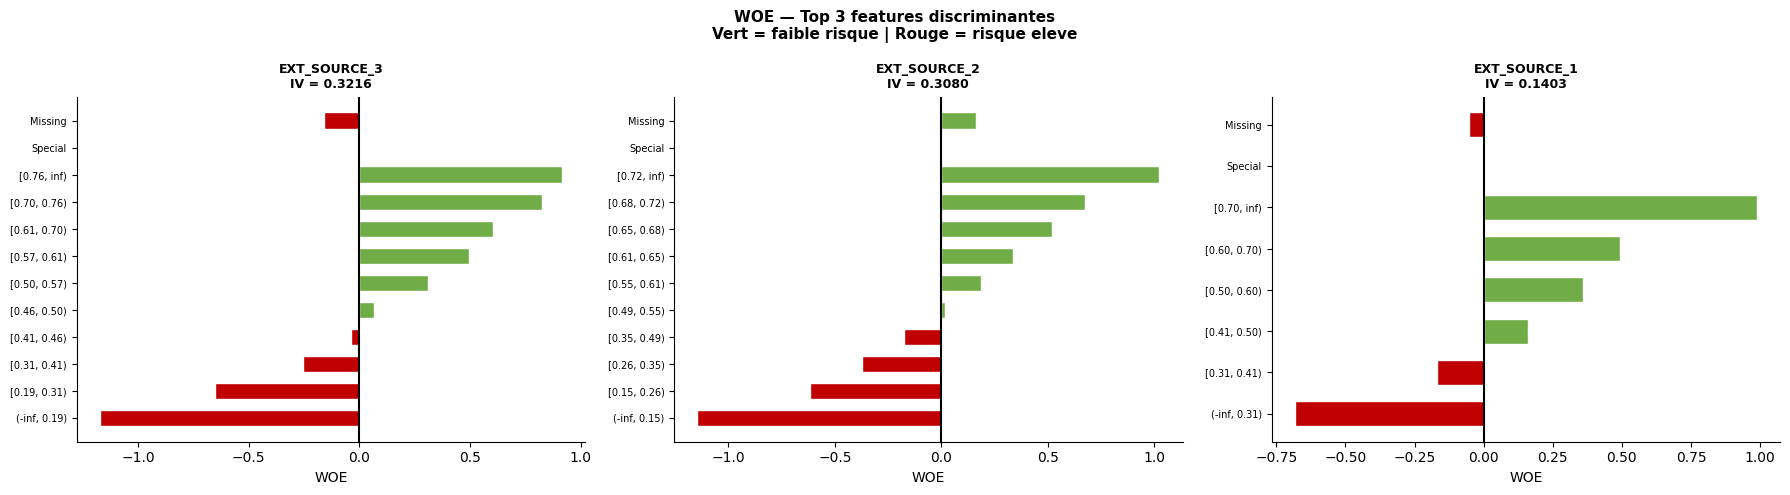


OK SECTION 5 TERMINEE — 27 features WOE encodees


In [7]:
# ============================================================
# SECTION 5 — ENCODAGE WOE PAR OPTIMAL BINNING
# FIT sur train UNIQUEMENT -> TRANSFORM sur val et test
# WOE positif = faible risque | WOE negatif = risque eleve
# Bin "Manquant" absorbe tous les NaN
# ============================================================

print(f'Encodage WOE — {len(features_iv)} features...')

woe_transformers = {}
features_gardees = []
X_train_woe = pd.DataFrame(index=range(len(X_train_iv)))
X_val_woe   = pd.DataFrame(index=range(len(X_val_iv)))
X_test_woe  = pd.DataFrame(index=range(len(X_test_iv)))

for idx, col in enumerate(features_iv):
    if idx % 10 == 0:
        print(f'  Progression : {idx}/{len(features_iv)}...')
    dtype = 'categorical' if col in CAT_FEATURES else 'numerical'
    try:
        ob = OptimalBinning(name=col, dtype=dtype, solver='cp',
                            max_n_bins=10, min_bin_size=0.05)
        ob.fit(X_train_iv[col].values, y_train.values)
        if ob.status not in ['OPTIMAL', 'FEASIBLE']:
            print(f'  ATTENTION {col} : status {ob.status} — ignoree')
            continue
        X_train_woe[col] = ob.transform(X_train_iv[col].values, metric='woe')
        X_val_woe[col]   = ob.transform(X_val_iv[col].values,   metric='woe')
        X_test_woe[col]  = ob.transform(X_test_iv[col].values,  metric='woe')
        woe_transformers[col] = ob
        features_gardees.append(col)
    except Exception as e:
        print(f'  ATTENTION {col} : {str(e)[:50]} — ignoree')

X_train_woe = X_train_woe[features_gardees]
X_val_woe   = X_val_woe[features_gardees]
X_test_woe  = X_test_woe[features_gardees]

nan_train = X_train_woe.isnull().sum().sum()
nan_val   = X_val_woe.isnull().sum().sum()
nan_test  = X_test_woe.isnull().sum().sum()

print(f'\n{"="*60}')
print('  RESULTATS WOE')
print(f'{"="*60}')
print(f'  Features encodees : {len(features_gardees)}')
print(f'  NaN apres WOE : Train={nan_train} | Val={nan_val} | Test={nan_test}')
if nan_train == 0:
    print('  OK Aucun NaN — bin "Manquant" a absorbe tous les NaN')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top3 = df_iv[df_iv['decision'] == 'retained'].head(3)['feature'].tolist()

for ax, col in zip(axes, top3):
    if col not in woe_transformers:
        ax.set_title(f'{col}\n(non encode)')
        continue
    try:
        ob  = woe_transformers[col]
        bt  = ob.binning_table.build()

        # Exclure la ligne 'Totals' — elle n'a pas de WoE de bin
        bt_bins = bt[bt.index != 'Totals'].copy()

        woe_values = bt_bins['WoE'].values
        bin_labels = [str(b)[:22] for b in bt_bins['Bin'].values]
        iv_val     = ob.binning_table.iv

        colors_woe = [COLORS['success'] if w > 0 else COLORS['danger']
                      for w in woe_values]

        ax.barh(range(len(woe_values)), woe_values,
                color=colors_woe, edgecolor='white', height=0.6)
        ax.set_yticks(range(len(woe_values)))
        ax.set_yticklabels(bin_labels, fontsize=7)
        ax.axvline(x=0, color='black', linewidth=1.5)
        ax.set_title(f'{col[:28]}\nIV = {iv_val:.4f}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel('WOE')

    except Exception as e:
        ax.set_title(f'{col[:25]}')
        ax.text(0.5, 0.5, f'Erreur: {str(e)[:60]}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='red', wrap=True)

plt.suptitle('WOE — Top 3 features discriminantes\n'
             'Vert = faible risque | Rouge = risque eleve',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig5_woe_top3.png', dpi=150, bbox_inches='tight')
plt.show()

with open(ART_DIR + 'woe_transformers.pkl', 'wb') as f:
    pickle.dump(woe_transformers, f)
X_train_woe.to_csv(DATA_DIR + 'X_train_woe.csv', index=False)
X_val_woe.to_csv(DATA_DIR + 'X_val_woe.csv', index=False)
X_test_woe.to_csv(DATA_DIR + 'X_test_woe.csv', index=False)
print(f'\nOK SECTION 5 TERMINEE — {len(features_gardees)} features WOE encodees')


**Interpretation :** Apres WOE, tous les NaN ont ete absorbes par le bin 'Manquant'. L'absence d'information devient une information quantifiee.


---
## SECTION 6 — Selection NAP (Noise-Adjusted Permutation)

**Role :** eliminer les features redondantes en contexte multivariate.

**Difference avec IV :**
- IV = filtre **univarie** (chaque feature seule face a la cible)
- NAP = filtre **multivariate** (chaque feature en presence de toutes les autres)

**Decision finale :** NAP s'execute sur **TOUT le train** (215k lignes).
Duree estimee : 20-40 minutes sur Kaggle — normal et attendu.


Selection NAP en cours...
  Train complet : 215,257 observations
  Entrainement Random Forest sur TOUT le train...
  (Peut prendre 20-40 minutes — normal)
  Random Forest entraine en 5s
  AUC Random Forest (indicatif) : 0.7404
  Calcul des importances par permutation (10 repetitions)...
  Importances calculees en 31s

  RESULTATS NAP
  Features entrantes : 27
  Features retenues  : 27
  Features eliminees : 0 (redondantes)

  Top 15 features NAP :
  OK EXT_SOURCE_3                               0.057315 +/- 0.001937
  OK EXT_SOURCE_2                               0.048690 +/- 0.002538
  OK EXT_SOURCE_1                               0.011549 +/- 0.001004
  OK annuity_to_credit                          0.007810 +/- 0.000356
  OK goods_to_credit                            0.005012 +/- 0.000612
  OK OCCUPATION_TYPE                            0.002974 +/- 0.000497
  OK employment_years                           0.002761 +/- 0.000708
  OK prev_refused_ratio                         0.002417 +

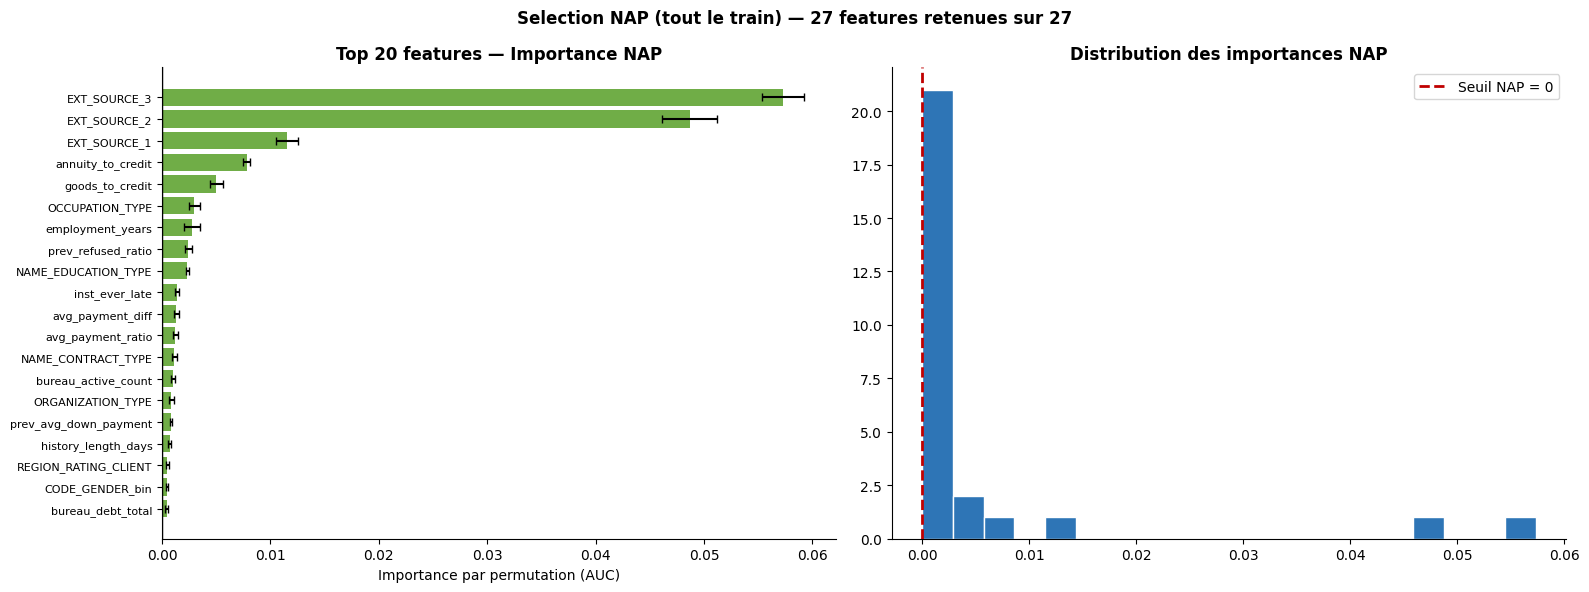


OK SECTION 6 TERMINEE — 27 features finales
   Temps total NAP : 0.8 minutes


In [8]:
# ============================================================
# SECTION 6 — SELECTION NAP (TOUT LE TRAIN — PAS D'ECHANTILLONNAGE)
# Decision : NAP sur tout le train pour une selection representative
# Duree estimee : 20-40 minutes sur Kaggle — normal et attendu
# ============================================================

print('Selection NAP en cours...')
print(f'  Train complet : {len(X_train_woe):,} observations')
print('  Entrainement Random Forest sur TOUT le train...')
print('  (Peut prendre 20-40 minutes — normal)')

t0 = time.time()
rf_nap = RandomForestClassifier(
    n_estimators=100, max_depth=6,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_nap.fit(X_train_woe, y_train)
print(f'  Random Forest entraine en {time.time()-t0:.0f}s')

auc_rf = roc_auc_score(y_val, rf_nap.predict_proba(X_val_woe)[:, 1])
print(f'  AUC Random Forest (indicatif) : {auc_rf:.4f}')

print('  Calcul des importances par permutation (10 repetitions)...')
t1 = time.time()
perm_imp = permutation_importance(
    rf_nap, X_val_woe, y_val,
    n_repeats=10, scoring='roc_auc', random_state=42, n_jobs=-1)
print(f'  Importances calculees en {time.time()-t1:.0f}s')

# Seuil NAP = 0 : importance <= 0 = feature redondante
df_nap = pd.DataFrame({
    'feature'   : features_gardees,
    'importance': perm_imp.importances_mean,
    'std'       : perm_imp.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

features_nap          = df_nap[df_nap['importance'] > 0]['feature'].tolist()
features_nap_rejected = df_nap[df_nap['importance'] <= 0]['feature'].tolist()

print(f'\n{"=" * 60}')
print('  RESULTATS NAP')
print(f'{"=" * 60}')
print(f'  Features entrantes : {len(features_gardees)}')
print(f'  Features retenues  : {len(features_nap)}')
print(f'  Features eliminees : {len(features_nap_rejected)} (redondantes)')
if features_nap_rejected:
    print(f'  Eliminees : {", ".join(features_nap_rejected[:8])}')
print(f'\n  Top 15 features NAP :')
for _, row in df_nap.head(15).iterrows():
    marker = 'OK' if row['importance'] > 0 else 'XX'
    print(f'  {marker} {row["feature"]:<40} {row["importance"]:>10.6f} +/- {row["std"]:>8.6f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top20 = df_nap.head(20)
colors_nap = [COLORS['success'] if v > 0 else COLORS['danger'] for v in top20['importance']]
axes[0].barh(range(len(top20)), top20['importance'].values[::-1],
              xerr=top20['std'].values[::-1], color=colors_nap[::-1], capsize=3)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'].values[::-1], fontsize=8)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Top 20 features — Importance NAP', fontweight='bold')
axes[0].set_xlabel('Importance par permutation (AUC)')

axes[1].hist(df_nap['importance'], bins=20, color=COLORS['secondary'], edgecolor='white')
axes[1].axvline(x=0, color=COLORS['danger'], linestyle='--', linewidth=2, label='Seuil NAP = 0')
axes[1].set_title('Distribution des importances NAP', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Selection NAP (tout le train) — {len(features_nap)} features retenues sur {len(features_gardees)}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig6_selection_nap.png', dpi=150, bbox_inches='tight')
plt.show()

X_train_nap = X_train_woe[features_nap].copy()
X_val_nap   = X_val_woe[features_nap].copy()
X_test_nap  = X_test_woe[features_nap].copy()

df_nap.to_csv(ART_DIR + 'nap_importance.csv', index=False)
with open(ART_DIR + 'nap_features.pkl', 'wb') as f:
    pickle.dump(features_nap, f)
X_train_nap.to_csv(DATA_DIR + 'X_train_nap.csv', index=False)
X_val_nap.to_csv(DATA_DIR + 'X_val_nap.csv', index=False)
X_test_nap.to_csv(DATA_DIR + 'X_test_nap.csv', index=False)

print(f'\nOK SECTION 6 TERMINEE — {len(features_nap)} features finales')
print(f'   Temps total NAP : {(time.time()-t0)/60:.1f} minutes')


---
## SECTION 6b — Génération de `feature_stats.json` (5ème artefact)

Calcule les statistiques réelles du train pour chaque feature retenue par NAP.
Ces statistiques servent à `generate_metadata.py` pour générer les gabarits
d'explications SHAP et les recommandations documentaires via LLM.

**5 intervalles** basés sur p25/p50/p75/p95/+∞ (pas seulement les quartiles).
Le p95 est indispensable pour les distributions asymétriques.


In [9]:
# ============================================================
# SECTION 6b — GENERATION feature_stats.json (5eme artefact)
# VERSION CORRIGEE — coherente avec les 27 features NAP exactes
# Modifications vs version precedente :
#   1. _SAISIE nettoyee : 6 features hors NAP supprimees
#   2. _SAISIE completee : 6 features declaratives NAP ajoutees
#   3. is_request_specific ajoute (3 features specifiques a chaque demande)
# ============================================================

import json as _json

print('=' * 65)
print('  SECTION 6b — GENERATION feature_stats.json')
print('=' * 65)

# Charger FAMILLE_MAPPING construit en Section 2
try:
    _famille_mapping = _json.load(open(DATA_DIR + 'famille_mapping.json'))
except FileNotFoundError:
    _famille_mapping = {}
    print('  AVERTISSEMENT : famille_mapping.json non trouve — familles = inconnu')

# Source et disponibilite selon la famille
_SOURCE = {
    'F1': 'interne',    'F2': 'profil',
    'F3': 'interne',    'F4': 'interne',
    'F5': 'interne',    'F6': 'interne',
    'F7': 'declaratif', 'F8': 'declaratif',
    'F9': 'declaratif', 'EXT': 'externe',
    'inconnu': 'inconnu'
}
_TOUJOURS_DISPO = {
    'F1': False, 'F2': True,  'F3': False, 'F4': False, 'F5': False,
    'F6': False, 'F7': True,  'F8': True,  'F9': True,  'EXT': False,
    'inconnu': False
}

# ── Calcul des statistiques (identique version precedente) ──
feature_stats = {}

for feature in features_nap:
    col      = X_train_iv[feature] if feature in X_train_iv.columns \
               else pd.Series([None] * len(y_train))
    col_nona = col.dropna()
    famille  = _famille_mapping.get(feature, 'inconnu')
    iv_val   = float(df_iv[df_iv['feature'] == feature]['iv'].values[0]) \
               if feature in df_iv['feature'].values else 0.0

    is_cat = (col.dtype == 'object') or (feature in CAT_FEATURES)

    if is_cat:
        modalites = col.dropna().unique().tolist()
        defaut_rates = {}
        for mod in modalites:
            mask = X_train_iv[feature] == mod
            if mask.sum() > 0:
                defaut_rates[str(mod)] = round(float(y_train[mask].mean()), 4)

        feature_stats[feature] = {
            'type'                : 'categorical',
            'famille'             : famille,
            'source'              : _SOURCE.get(famille, 'inconnu'),
            'toujours_disponible' : _TOUJOURS_DISPO.get(famille, False),
            'iv'                  : round(iv_val, 4),
            'modalites'           : [str(m) for m in modalites],
            'defaut_par_modalite' : defaut_rates,
            'nan_rate'            : round(float(col.isna().mean()), 4)
        }
    else:
        if len(col_nona) < 2:
            corr = 0.0
        else:
            corr = float(col.corr(y_train))

        feature_stats[feature] = {
            'type'                : 'numeric',
            'famille'             : famille,
            'source'              : _SOURCE.get(famille, 'inconnu'),
            'toujours_disponible' : _TOUJOURS_DISPO.get(famille, False),
            'iv'                  : round(iv_val, 4),
            'p25'                 : round(float(col_nona.quantile(0.25)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'p50'                 : round(float(col_nona.quantile(0.50)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'p75'                 : round(float(col_nona.quantile(0.75)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'p95'                 : round(float(col_nona.quantile(0.95)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'nan_rate'            : round(float(col.isna().mean()), 4),
            'correlation_target'  : round(corr, 4),
            'direction'           : 'positive' if corr > 0 else 'negative'
        }

# ============================================================
# ENRICHISSEMENT — is_declarative, is_request_specific,
#                  champs_source, formule
#
# REGLE : _SAISIE contient UNIQUEMENT des features dans NAP.
#         Toute feature hors NAP dans _SAISIE = dead code inutile.
#
# CATEGORIE A (is_request_specific=True) :
#   → specifique a chaque demande de credit
#   → toujours demande au scoring meme pour un client existant
#
# CATEGORIE B (is_declarative=True, is_request_specific=False) :
#   → profil client, saisi une fois pour un nouveau client
#   → lu depuis MongoDB pour un client existant
#
# CATEGORIE C (is_declarative=False) :
#   → calcule par l'adaptateur depuis les donnees historiques
#   → jamais saisi par l'agent
# ============================================================

# Features specifiques a chaque demande (categorie A)
_IS_REQUEST_SPECIFIC = {
    'NAME_CONTRACT_TYPE' : True,   # type du pret demande
    'annuity_to_credit'  : True,   # mensualite / montant credit en cours
    'goods_to_credit'    : True,   # valeur bien / montant credit en cours
}

# Champs de saisie pour les features declaratives (categories A et B)
# UNIQUEMENT les features presentes dans les 27 NAP
_SAISIE = {

    # ── Categorie A — Ratios financiers specifiques a la demande ──
    # (is_request_specific=True → saisies a chaque scoring)
    'annuity_to_credit': {
        'champs_source': [
            {'nom': 'montant_annuite',        'label': 'Annuité mensuelle (FCFA)',
             'type': 'number', 'obligatoire': True},
            {'nom': 'montant_credit_demande', 'label': 'Montant du crédit demandé (FCFA)',
             'type': 'number', 'obligatoire': True},
        ],
        'formule': 'montant_annuite / montant_credit_demande'
    },
    'goods_to_credit': {
        'champs_source': [
            {'nom': 'valeur_bien',            'label': 'Valeur du bien financé (FCFA)',
             'type': 'number', 'obligatoire': False},
            {'nom': 'montant_credit_demande', 'label': 'Montant du crédit demandé (FCFA)',
             'type': 'number', 'obligatoire': True},
        ],
        'formule': 'valeur_bien / montant_credit_demande'
    },
    'NAME_CONTRACT_TYPE': {
        'champs_source': [
            {'nom': 'type_contrat', 'label': 'Type de contrat',
             'type': 'select', 'options': ['Cash loans', 'Revolving loans'],
             'obligatoire': True},
        ],
        'formule': None
    },

    # ── Categorie B — Identite temporelle (F2) ───────────────
    # (is_declarative=True, is_request_specific=False)
    # → saisies une fois, lues depuis MongoDB ensuite
    'age_years': {
        'champs_source': [
            {'nom': 'date_naissance', 'label': 'Date de naissance',
             'type': 'date', 'obligatoire': True},
        ],
        'formule': None   # calcule depuis date_naissance dans create_client
    },
    'employment_years': {
        'champs_source': [
            {'nom': 'anciennete_emploi_mois',
             'label': "Ancienneté dans l'emploi actuel (mois)",
             'type': 'number', 'obligatoire': False},
        ],
        'formule': 'anciennete_emploi_mois / 12'
    },
    'registration_years': {
        'champs_source': [
            {'nom': 'anciennete_domicile_mois',
             'label': "Ancienneté à l'adresse actuelle (mois)",
             'type': 'number', 'obligatoire': False},
        ],
        'formule': 'anciennete_domicile_mois / 12'
    },

    # ── Categorie B — Declarative binaire (F7) ───────────────
    'CODE_GENDER_bin': {
        'champs_source': [
            {'nom': 'genre', 'label': 'Genre',
             'type': 'select', 'options': ['M', 'F'], 'obligatoire': True},
        ],
        'formule': None
    },

    # ── Categorie B — Categorielle F9 avec saisie agent ──────
    'NAME_INCOME_TYPE': {
        'champs_source': [
            {'nom': 'type_revenu', 'label': 'Type de revenu',
             'type': 'select',
             'options': ['Working', 'Commercial associate', 'Pensioner',
                         'State servant', 'Unemployed'],
             'obligatoire': True},
        ],
        'formule': None
    },
    'NAME_EDUCATION_TYPE': {
        'champs_source': [
            {'nom': 'niveau_education', 'label': "Niveau d'éducation",
             'type': 'select',
             'options': ['Secondary / secondary special', 'Higher education',
                         'Incomplete higher', 'Lower secondary', 'Academic degree'],
             'obligatoire': True},
        ],
        'formule': None
    },
    'OCCUPATION_TYPE': {
        # Agent saisit la profession du demandeur
        'champs_source': [
            {'nom': 'OCCUPATION_TYPE', 'label': 'Profession du demandeur',
             'type': 'select', 'obligatoire': False},
        ],
        'formule': None
    },

    # ── Categorie B — Declaratives sans saisie directe ───────
    # is_declarative=True mais champs_source=[] :
    # → CODE_GENDER : partage le champ genre avec CODE_GENDER_bin
    # → EMERGENCYSTATE_MODE : donnee contextuelle systeme
    # → ORGANIZATION_TYPE : trop de modalites pour un select
    # → REGION_RATING_CLIENT : determine depuis l'adresse du client
    'CODE_GENDER'          : {'champs_source': [], 'formule': None},
    'EMERGENCYSTATE_MODE'  : {'champs_source': [], 'formule': None},
    'ORGANIZATION_TYPE'    : {'champs_source': [], 'formule': None},
    'REGION_RATING_CLIENT' : {'champs_source': [], 'formule': None},
}

# ── Application des champs supplementaires ───────────────────
for feature in feature_stats:
    famille = feature_stats[feature].get('famille', 'inconnu')
    is_decl = _TOUJOURS_DISPO.get(famille, False)

    feature_stats[feature]['is_declarative']      = is_decl
    feature_stats[feature]['is_request_specific'] = _IS_REQUEST_SPECIFIC.get(feature, False)

    if feature in _SAISIE:
        feature_stats[feature]['champs_source'] = _SAISIE[feature]['champs_source']
        feature_stats[feature]['formule']       = _SAISIE[feature]['formule']
    else:
        feature_stats[feature]['champs_source'] = []
        feature_stats[feature]['formule']       = None

# ── Rapport enrichissement ────────────────────────────────────
n_decl    = sum(1 for v in feature_stats.values() if v['is_declarative'])
n_req     = sum(1 for v in feature_stats.values() if v['is_request_specific'])
n_champs  = sum(1 for v in feature_stats.values() if v['champs_source'])
print(f'  Enrichissement OK :')
print(f'    is_declarative=True    : {n_decl}  features (categories A + B)')
print(f'    is_request_specific    : {n_req}   features (categorie A)')
print(f'    avec champs_source     : {n_champs} features (formulaire React)')
print(f'    is_declarative=False   : {len(feature_stats)-n_decl} features (categorie C)')

# ============================================================
# SAUVEGARDE FINALE
# ============================================================
_json.dump(
    feature_stats,
    open(ART_DIR + 'feature_stats.json', 'w', encoding='utf-8'),
    indent=2, ensure_ascii=False
)

# Rapport final
n_num   = sum(1 for v in feature_stats.values() if v['type'] == 'numeric')
n_cat   = sum(1 for v in feature_stats.values() if v['type'] == 'categorical')
n_dispo = sum(1 for v in feature_stats.values() if v['toujours_disponible'])
n_nan   = sum(1 for v in feature_stats.values() if not v['toujours_disponible'])

print(f'\n  Features dans feature_stats.json : {len(feature_stats)}')
print(f'  Numeriques          : {n_num}')
print(f'  Categorielles       : {n_cat}')
print(f'  Toujours disponibles: {n_dispo} (F2/F7/F8/F9 — saisie agent)')
print(f'  Peuvent etre NaN    : {n_nan} (F1/F3/F4/F5/F6/EXT — thin-file)')
print(f'\n  Familles representees :')
from collections import Counter as _Counter
_familles = _Counter(v['famille'] for v in feature_stats.values())
for fam, cnt in sorted(_familles.items()):
    src   = _SOURCE.get(fam, '?')
    dispo = 'toujours dispo' if _TOUJOURS_DISPO.get(fam, False) else 'peut etre NaN'
    print(f'    {fam:<8} : {cnt:>2} features | source={src:<12} | {dispo}')

print(f'\nOK feature_stats.json sauvegarde dans {ART_DIR}')
print(f'   5eme artefact pret pour generate_metadata.py')
print(f'OK SECTION 6b TERMINEE')

  SECTION 6b — GENERATION feature_stats.json
  Enrichissement OK :
    is_declarative=True    : 14  features (categories A + B)
    is_request_specific    : 3   features (categorie A)
    avec champs_source     : 10 features (formulaire React)
    is_declarative=False   : 13 features (categorie C)

  Features dans feature_stats.json : 27
  Numeriques          : 20
  Categorielles       : 7
  Toujours disponibles: 14 (F2/F7/F8/F9 — saisie agent)
  Peuvent etre NaN    : 13 (F1/F3/F4/F5/F6/EXT — thin-file)

  Familles representees :
    EXT      :  3 features | source=externe      | peut etre NaN
    F1       :  1 features | source=interne      | peut etre NaN
    F2       :  3 features | source=profil       | toujours dispo
    F3       :  1 features | source=interne      | peut etre NaN
    F4       :  4 features | source=interne      | peut etre NaN
    F5       :  2 features | source=interne      | peut etre NaN
    F6       :  2 features | source=interne      | peut etre NaN
    F7  

**Interpretation :** NAP confirme les resultats de l'IV. Les features eliminee sont redondantes — elles n'apportent rien que les autres ne couvrent deja.


---
## SECTION 7 — Entraînement LightGBM (Random Search + Early Stopping)

**Stratégie optimale :** Random Search teste 12 combinaisons d'hyperparamètres.
Pour chaque combinaison, l'Early Stopping détermine le nombre optimal d'arbres.
La meilleure combinaison est retenue pour l'entraînement final.

**Random Search** = cherche les meilleurs hyperparamètres  
**Early Stopping** = détermine le nombre optimal d'arbres  
Ces deux techniques sont **complémentaires**, pas concurrentes.


**Interpretation :** Un gap Train/Val < 0.05 confirme l'absence de surapprentissage. Les metriques absolues (AUC ~0.75) sont coherentes avec l'etat de l'art sur ce dataset public sans ensembles de modeles.


GPU disponible :
Thu Jul 30 06:51:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------
  SECTION 7 — RANDOM SEARCH + EARLY STOPPING
  X_train_nap : (215257, 27)
  scale_pos_weight = 11.39
  GPU_PARAMS : {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}

  ETAPE 1 : Random Search (12 essais)...
  Chaque essai = LightGBM + early stopping AUC
  Estimation : 30-60 min avec GPU | 60-90 min CPU



1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[50]	valid_0's auc: 0.753276	valid_0's binary_logloss: 0.626253
[100]	valid_0's auc: 0.755483	valid_0's binary_logloss: 0.625071
[150]	valid_0's auc: 0.75634	valid_0's binary_logloss: 0.62085
  >>> Essai 01 | AUC=0.7564 | iters= 149 | depth=6 | lr=0.100 | leaves=20
[50]	valid_0's auc: 0.752034	valid_0's binary_logloss: 0.618211
[100]	valid_0's auc: 0.754558	valid_0's binary_logloss: 0.624764
[150]	valid_0's auc: 0.755887	valid_0's binary_logloss: 0.620876
[200]	valid_0's auc: 0.756175	valid_0's binary_logloss: 0.616691
[250]	valid_0's auc: 0.756436	valid_0's binary_logloss: 0.613648
[300]	valid_0's auc: 0.756353	valid_0's binary_logloss: 0.610454
  >>> Essai 02 | AUC=0.7565 | iters= 276 | depth=5 | lr=0.080 | leaves=50
[50]	valid_0's auc: 0.747109	valid_0's binary_logloss: 0.580917
[100]	valid_0's auc: 0.752337	valid_0's binary_logloss: 0.626043
[150]	valid_0's auc: 0.754082	valid_0's binary_logloss: 0.629361
[200]	valid_0's auc: 0.755012	valid_0's binary_logloss: 0.628902
[250]	valid_

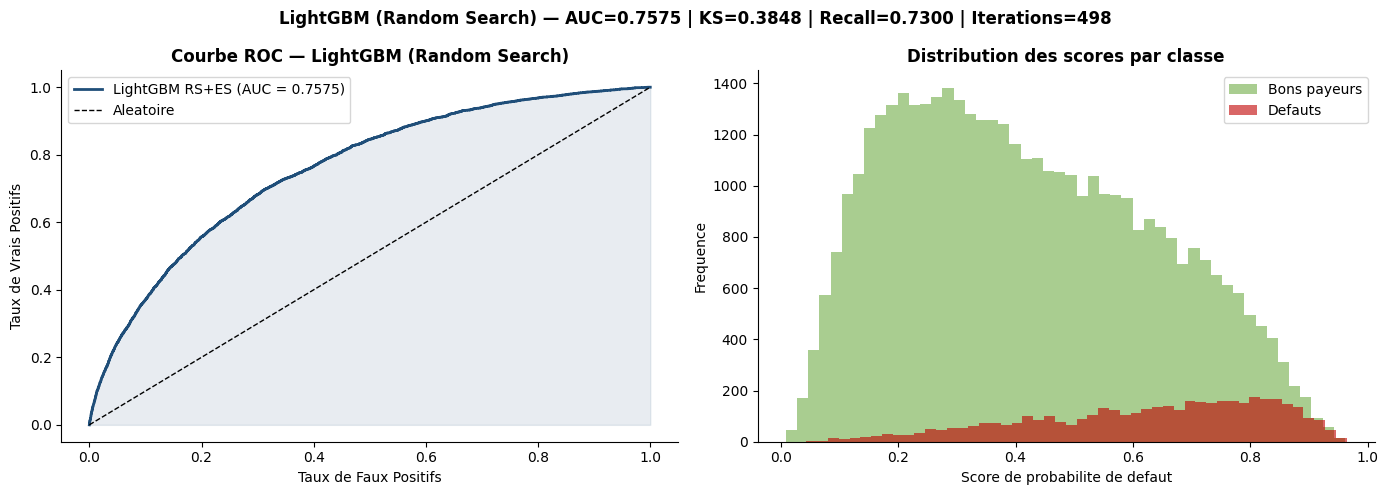


OK lgbm_final.pkl sauvegarde (Random Search + Early Stopping)
OK SECTION 7 TERMINEE


In [10]:
# ============================================================
# SECTION 7 — ENTRAINEMENT LIGHTGBM avec RANDOM SEARCH + EARLY STOPPING
# Version 2 : optimisation des hyperparametres avant entrainement final
# Early Stopping : determine le nombre optimal d'arbres pour chaque essai
# Random Search  : cherche les meilleurs hyperparametres
# Reference : Ke et al. (2017) NeurIPS — LightGBM
# ============================================================

# Vérification GPU disponible
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
GPU_AVAILABLE = result.returncode == 0

if GPU_AVAILABLE:
    print("GPU disponible :")
    print(result.stdout[:300])
    GPU_PARAMS = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}
else:
    print("Pas de GPU détecté — LightGBM tournera sur CPU")
    GPU_PARAMS = {}

import gc
if 'lgbm_final' in dir():
    del lgbm_final
gc.collect()

if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    print('Rechargement depuis disque...')
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    X_test_nap  = pd.read_csv(DATA_DIR + 'X_test_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
    y_test      = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()
    with open(ART_DIR + 'nap_features.pkl', 'rb') as f:
        features_nap = pickle.load(f)
    SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

print('=' * 65)
print('  SECTION 7 — RANDOM SEARCH + EARLY STOPPING')
print(f'  X_train_nap : {X_train_nap.shape}')
print(f'  scale_pos_weight = {SCALE_POS_WEIGHT:.2f}')
print(f'  GPU_PARAMS : {GPU_PARAMS if GPU_PARAMS else "CPU mode"}')
print('=' * 65)

# ============================================================
# ETAPE 1 — RANDOM SEARCH sur 12 combinaisons
# Chaque essai utilise Early Stopping pour trouver le bon n_estimators
# CORRECTION : log_evaluation(period=50) — JAMAIS period=0
#              period=0 perturbe l'early stopping (bug LightGBM 4.6.0)
# ============================================================
print('\n  ETAPE 1 : Random Search (12 essais)...')
print('  Chaque essai = LightGBM + early stopping AUC')
print('  Estimation : 30-60 min avec GPU | 60-90 min CPU\n')

param_dist = {
    'max_depth'        : [4, 5, 6, 7],
    'learning_rate'    : [0.03, 0.05, 0.08, 0.10],
    'num_leaves'       : [20, 31, 50, 63],
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9],
    'reg_alpha'        : [0.5, 1.0, 2.0],
    'reg_lambda'       : [1.0, 2.0, 3.0],
    'min_child_samples': [15, 20, 30],
}

best_auc    = 0
best_params = None
best_iter   = 279  # valeur par defaut si tous les essais echouent

t_rs = time.time()
_rng = np.random.RandomState(42)  # np est déjà importé en Section 0

for trial in range(12):
    params = {k: _rng.choice(v) for k, v in param_dist.items()}

    # Convertir TOUS les params en types Python natifs
    # pour eviter les erreurs de type numpy dans LightGBM
    params['learning_rate']     = float(params['learning_rate'])
    params['subsample']         = float(params['subsample'])
    params['colsample_bytree']  = float(params['colsample_bytree'])
    params['reg_alpha']         = float(params['reg_alpha'])
    params['reg_lambda']        = float(params['reg_lambda'])
    params['max_depth']         = int(params['max_depth'])
    params['num_leaves']        = int(params['num_leaves'])
    params['min_child_samples'] = int(params['min_child_samples'])

    model_trial = lgb.LGBMClassifier(
        n_estimators     = 1000,
        scale_pos_weight = SCALE_POS_WEIGHT,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1,
        **params,
        **GPU_PARAMS   # GPU si disponible, vide sinon
    )

    # CORRECTION CRITIQUE : period=50 — JAMAIS period=0
    # period=0 perturbe l'early stopping -> arret premature a l'iteration 2
    callbacks_trial = [
        lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False),
        lgb.log_evaluation(period=50)   # ← CORRIGÉ ici
    ]

    try:
        model_trial.fit(
            X_train_nap, y_train,
            eval_set    = [(X_val_nap, y_val)],
            eval_metric = 'auc',
            callbacks   = callbacks_trial
        )
        proba_trial = model_trial.predict_proba(X_val_nap)[:, 1]
        auc_trial   = roc_auc_score(y_val, proba_trial)
        n_iter      = model_trial.best_iteration_

        marker = '>>>' if auc_trial > best_auc else '   '
        print(f'  {marker} Essai {trial+1:02d} | AUC={auc_trial:.4f} | '
              f'iters={n_iter:>4} | depth={params["max_depth"]} | '
              f'lr={params["learning_rate"]:.3f} | leaves={params["num_leaves"]}')

        if auc_trial > best_auc:
            best_auc    = auc_trial
            best_params = params.copy()
            best_iter   = n_iter

    except Exception as e:
        print(f'  XXX Essai {trial+1:02d} | ERREUR : {e}')
        continue

print(f'\n  Random Search termine en {(time.time()-t_rs)/60:.1f} min')
print(f'  Meilleur AUC val     : {best_auc:.4f}')
print(f'  Iterations optimales : {best_iter}')
print(f'  Meilleurs params     :')
for k, v in best_params.items():
    print(f'    {k:<22} : {v}')

# ============================================================
# ETAPE 2 — ENTRAINEMENT FINAL avec les meilleurs hyperparametres
# Early Stopping confirme le nombre optimal d'arbres
# ============================================================
print('\n  ETAPE 2 : Entrainement final avec les meilleurs params...')

lgbm_final = lgb.LGBMClassifier(
    n_estimators     = 1000,
    scale_pos_weight = SCALE_POS_WEIGHT,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
    **best_params,
    **GPU_PARAMS   # GPU si disponible, vide sinon
)

# CORRECTION CRITIQUE :
# - first_metric_only=True : surveille AUC uniquement, ignore logloss
# - log_evaluation(period=50) : JAMAIS period=0
callbacks = [
    lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=True),
    lgb.log_evaluation(period=50)
]

t0 = time.time()
lgbm_final.fit(
    X_train_nap, y_train,
    eval_set    = [(X_val_nap, y_val)],
    eval_metric = 'auc',
    callbacks   = callbacks
)
elapsed = time.time() - t0
print(f'\n  Temps entrainement final : {elapsed:.0f}s')
print(f'  Iterations optimales (early stopping) : {lgbm_final.best_iteration_}')

# --- Metriques validation ---
proba_val = lgbm_final.predict_proba(X_val_nap)[:, 1]
pred_val  = (proba_val >= 0.5).astype(int)

auc_val  = roc_auc_score(y_val, proba_val)
gini_val = 2 * auc_val - 1
ks_val   = ks_2samp(proba_val[y_val==1], proba_val[y_val==0]).statistic
f1_val   = f1_score(y_val, pred_val, zero_division=0)
rec_val  = recall_score(y_val, pred_val, zero_division=0)

proba_train = lgbm_final.predict_proba(X_train_nap)[:, 1]
auc_train   = roc_auc_score(y_train, proba_train)
gap         = auc_train - auc_val

print(f'\n{"=" * 65}')
print('  METRIQUES LIGHTGBM — JEU DE VALIDATION')
print(f'{"=" * 65}')
print(f'  {"Metrique":<20} {"Valeur":>10} {"Cible":>12}')
print(f'  {"-" * 44}')
print(f'  {"AUC-ROC":<20} {auc_val:>10.4f} {">=0.75":>12}')
print(f'  {"Gini":<20} {gini_val:>10.4f} {">=0.50":>12}')
print(f'  {"KS":<20} {ks_val:>10.4f} {">=0.35":>12}')
print(f'  {"Recall":<20} {rec_val:>10.4f} {">=0.55":>12}')
print(f'  {"F1-Score":<20} {f1_val:>10.4f} {">=0.30":>12}')
print(f'  {"AUC Train":<20} {auc_train:>10.4f}')
g_ok = 'OK' if gap < 0.05 else 'ATTENTION'
print(f'  {"Gap Train/Val":<20} {gap:>10.4f} {"<0.05":>12} {g_ok}')
print(f'  {"Iterations":<20} {lgbm_final.best_iteration_:>10}')
print(f'  {"Meilleurs params":<20}')
for k, v in best_params.items():
    print(f'    {k:<22} : {v}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_val, proba_val)
axes[0].plot(fpr, tpr, color=COLORS['primary'], linewidth=2,
             label=f'LightGBM RS+ES (AUC = {auc_val:.4f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatoire')
axes[0].fill_between(fpr, tpr, alpha=0.1, color=COLORS['primary'])
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbe ROC — LightGBM (Random Search)', fontweight='bold')
axes[0].legend()

axes[1].hist(proba_val[y_val==0], bins=50, alpha=0.6,
             color=COLORS['success'], label='Bons payeurs')
axes[1].hist(proba_val[y_val==1], bins=50, alpha=0.6,
             color=COLORS['danger'], label='Defauts')
axes[1].set_xlabel('Score de probabilite de defaut')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution des scores par classe', fontweight='bold')
axes[1].legend()

plt.suptitle(
    f'LightGBM (Random Search) — AUC={auc_val:.4f} | KS={ks_val:.4f} | '
    f'Recall={rec_val:.4f} | Iterations={lgbm_final.best_iteration_}',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig7_lgbm_rs_roc.png', dpi=150, bbox_inches='tight')
plt.show()

with open(ART_DIR + 'lgbm_final.pkl', 'wb') as f:
    pickle.dump(lgbm_final, f)
print('\nOK lgbm_final.pkl sauvegarde (Random Search + Early Stopping)')
print('OK SECTION 7 TERMINEE')

---
## SECTION 8 — Comparaison des Modeles

Validation que LightGBM est le meilleur choix parmi les alternatives.
Tous les modeles sont entraines sur les **memes donnees WOE+NAP** pour comparaison equitable.

**Accuracy incluse** pour la visualisation — non utilisee comme critere de selection
(le desequilibre 8%/92% la rend trompeuse).


[1/6] Dummy Classifier...
[2/6] Logistic Regression...
[3/6] Random Forest...
[4/6] Gradient Boosting...
[5/6] XGBoost (comparaison)...
[6/6] LightGBM (modele final)...

  COMPARAISON DES MODELES — JEU DE VALIDATION
  Split temporel 70/15/15 | WOE+NAP | scale_pos_weight
                Modele  AUC-ROC    Gini      KS  Recall  F1-Score  Precision  Accuracy   Brier
1              XGBoost   0.7580  0.5161  0.3832  0.7180    0.2869     0.1793    0.6648  0.2121
2     LightGBM (final)   0.7575  0.5149  0.3848  0.7300    0.2854     0.1774    0.6566  0.2162
3    Gradient Boosting   0.7560  0.5119  0.3771  0.0293    0.0556     0.5314    0.9064  0.0776
4  Logistic Regression   0.7481  0.4962  0.3640  0.7674    0.2701     0.1639    0.6103  0.2410
5        Random Forest   0.7428  0.4856  0.3647  0.7685    0.2682     0.1625    0.6061  0.2344
6     Dummy Classifier   0.4991 -0.0018  0.0018  0.0725    0.0810     0.0919    0.8456  0.1544

Meilleur AUC : XGBoost (0.758)
Note : Accuracy non retenue comm

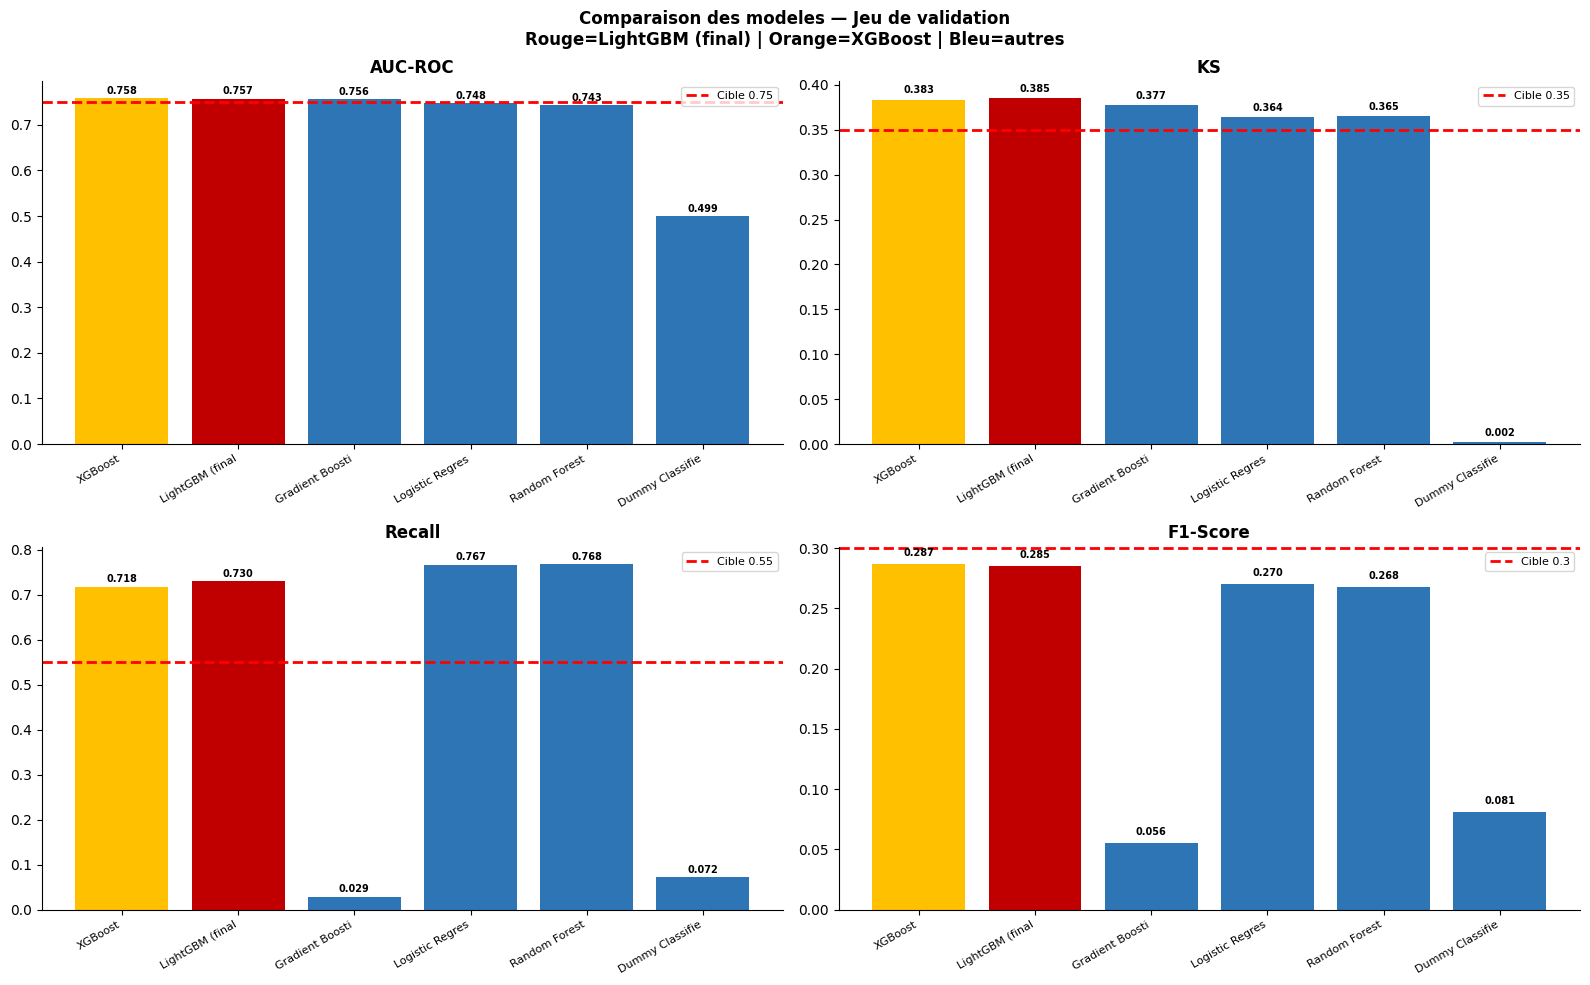

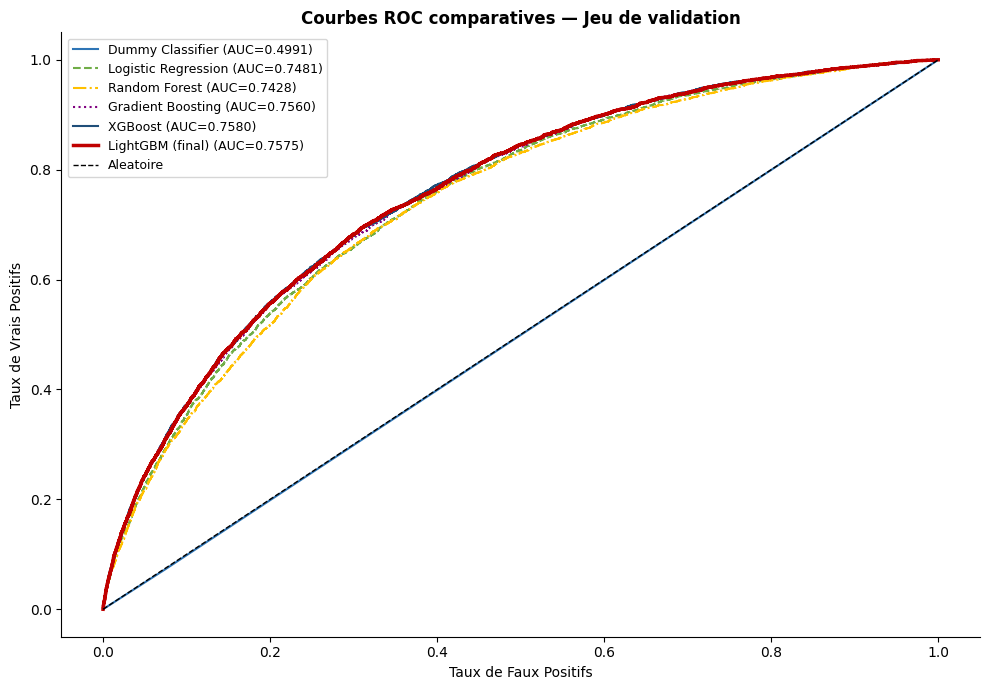

OK SECTION 8 TERMINEE


In [11]:
# ============================================================
# SECTION 8 — COMPARAISON DES MODELES
# Tous les modeles sur les memes donnees WOE+NAP
# Accuracy incluse pour visualisation uniquement
# ============================================================

# Rechargement securise
if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
    SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)

proba_val_lgbm = lgbm_final.predict_proba(X_val_nap)[:, 1]

def compute_metrics(name, y_true, y_proba, threshold=0.5):
    y_true = np.array(y_true)
    y_pred = (y_proba >= threshold).astype(int)
    auc    = roc_auc_score(y_true, y_proba)
    ks     = ks_2samp(y_proba[y_true==1], y_proba[y_true==0]).statistic
    return {
        'Modele'   : name,
        'AUC-ROC'  : round(auc, 4),
        'Gini'     : round(2*auc - 1, 4),
        'KS'       : round(ks, 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Brier'    : round(brier_score_loss(y_true, y_proba), 4),
    }

results    = []
probas_all = {}

print('[1/6] Dummy Classifier...')
m = DummyClassifier(strategy='stratified', random_state=42)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Dummy Classifier', y_val, p))
probas_all['Dummy Classifier'] = p

print('[2/6] Logistic Regression...')
m = LogisticRegression(max_iter=500, C=0.1, solver='lbfgs',
                       class_weight='balanced', random_state=42)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Logistic Regression', y_val, p))
probas_all['Logistic Regression'] = p

print('[3/6] Random Forest...')
m = RandomForestClassifier(n_estimators=200, max_depth=7,
    class_weight='balanced', random_state=42, n_jobs=-1)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Random Forest', y_val, p))
probas_all['Random Forest'] = p

print('[4/6] Gradient Boosting...')
m = GradientBoostingClassifier(n_estimators=200, max_depth=4,
    learning_rate=0.05, subsample=0.8, random_state=42)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Gradient Boosting', y_val, p))
probas_all['Gradient Boosting'] = p

print('[5/6] XGBoost (comparaison)...')
m = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='auc', random_state=42,
    n_jobs=-1, verbosity=0)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('XGBoost', y_val, p))
probas_all['XGBoost'] = p

print('[6/6] LightGBM (modele final)...')
results.append(compute_metrics('LightGBM (final)', y_val, proba_val_lgbm))
probas_all['LightGBM (final)'] = proba_val_lgbm

df_comp = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
df_comp.index += 1

print(f'\n{"=" * 95}')
print('  COMPARAISON DES MODELES — JEU DE VALIDATION')
print(f'  Split temporel 70/15/15 | WOE+NAP | scale_pos_weight')
print(f'{"=" * 95}')
print(df_comp.to_string())
print(f'{"=" * 95}')
best = df_comp.iloc[0]
print(f'\nMeilleur AUC : {best["Modele"]} ({best["AUC-ROC"]})')
print('Note : Accuracy non retenue comme critere (desequilibre 8%/92%)')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_plot = ['AUC-ROC', 'KS', 'Recall', 'F1-Score']
cibles = {'AUC-ROC': 0.75, 'KS': 0.35, 'Recall': 0.55, 'F1-Score': 0.30}

for ax, metric in zip(axes.flat, metrics_to_plot):
    vals = df_comp.set_index('Modele')[metric]
    bar_colors = [COLORS['danger'] if 'LightGBM' in n else
                  COLORS['warning'] if 'XGBoost' in n else COLORS['secondary']
                  for n in vals.index]
    bars = ax.bar(range(len(vals)), vals.values, color=bar_colors)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([n[:15] for n in vals.index], rotation=30,
                        ha='right', fontsize=8)
    ax.axhline(y=cibles[metric], color='red', linestyle='--',
               linewidth=2, label=f'Cible {cibles[metric]}')
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

plt.suptitle(
    'Comparaison des modeles — Jeu de validation\n'
    'Rouge=LightGBM (final) | Orange=XGBoost | Bleu=autres',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig8_comparaison_modeles.png',
            dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
line_styles = ['-', '--', '-.', ':', '-', '-']
roc_colors  = [COLORS['secondary'], COLORS['success'],
               COLORS['warning'], 'purple',
               COLORS['primary'], COLORS['danger']]
for (name, p_arr), ls, c in zip(probas_all.items(), line_styles, roc_colors):
    fpr_m, tpr_m, _ = roc_curve(np.array(y_val), p_arr)
    auc_m = roc_auc_score(np.array(y_val), p_arr)
    lw = 2.5 if 'LightGBM' in name else 1.5
    ax.plot(fpr_m, tpr_m, color=c, linestyle=ls, linewidth=lw,
            label=f'{name} (AUC={auc_m:.4f})')
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatoire')
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC comparatives — Jeu de validation',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig8b_roc_comparaison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('OK SECTION 8 TERMINEE')

In [12]:
# ============================================================
# SECTION 8b — OPTIMISATION XGBOOST PAR RANDOM SEARCH
# Comparaison équitable avec LightGBM (même budget : 12 essais)
# Basé sur la même structure que Section 7 (LightGBM)
# IMPORTANT : validation set uniquement — test set non touché
# ============================================================

# Rechargement sécurisé (identique à Section 8)
if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
    SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)

# GPU XGBoost (différent de LightGBM — utilise device='cuda')
XGB_GPU_PARAMS = {'device': 'cuda'} if GPU_AVAILABLE else {}

print('=' * 65)
print('  SECTION 8b — RANDOM SEARCH XGBOOST')
print(f'  Budget : 12 essais | scale_pos_weight = {SCALE_POS_WEIGHT:.2f}')
print(f'  GPU : {"cuda" if GPU_AVAILABLE else "CPU mode"}')
print('=' * 65)

# ── Espace de recherche (même profondeur que Section 7 LightGBM) ──
param_dist_xgb = {
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.03, 0.05, 0.07, 0.10],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 2, 3, 5],
    'gamma'           : [0, 0.05, 0.10, 0.20],
    'reg_alpha'       : [0, 0.01, 0.05, 0.10],
    'reg_lambda'      : [0.5, 1.0, 1.5, 2.0],
}

best_auc_xgb    = 0
best_params_xgb = None
best_model_xgb  = None

_rng_xgb = np.random.RandomState(42)  # Même convention que Section 7

print('\n  ETAPE 1 : Random Search XGBoost (12 essais)...')
print('  Chaque essai = XGBoost + early stopping AUC\n')

t_rs_xgb = time.time()

for trial in range(12):
    params = {k: _rng_xgb.choice(v) for k, v in param_dist_xgb.items()}

    # Conversion en types Python natifs (évite les erreurs numpy)
    params['learning_rate']    = float(params['learning_rate'])
    params['subsample']        = float(params['subsample'])
    params['colsample_bytree'] = float(params['colsample_bytree'])
    params['reg_alpha']        = float(params['reg_alpha'])
    params['reg_lambda']       = float(params['reg_lambda'])
    params['gamma']            = float(params['gamma'])
    params['max_depth']        = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model_trial = xgb.XGBClassifier(
        n_estimators          = 1000,
        scale_pos_weight      = SCALE_POS_WEIGHT,
        eval_metric           = 'auc',
        early_stopping_rounds = 50,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
        **params,
        **XGB_GPU_PARAMS
    )

    try:
        model_trial.fit(
            X_train_nap, y_train,
            eval_set = [(X_val_nap, y_val)],
            verbose  = False
        )
        proba_trial = model_trial.predict_proba(X_val_nap)[:, 1]
        auc_trial   = roc_auc_score(y_val, proba_trial)
        n_iter      = model_trial.best_iteration

        marker = '>>>' if auc_trial > best_auc_xgb else '   '
        print(f'  {marker} Essai {trial+1:02d} | AUC={auc_trial:.4f} | '
              f'iters={n_iter:>4} | depth={params["max_depth"]} | '
              f'lr={params["learning_rate"]:.3f}')

        if auc_trial > best_auc_xgb:
            best_auc_xgb    = auc_trial
            best_params_xgb = params.copy()
            best_model_xgb  = model_trial

    except Exception as e:
        print(f'  XXX Essai {trial+1:02d} | ERREUR : {e}')
        continue

print(f'\n  Random Search XGBoost terminé en {(time.time()-t_rs_xgb)/60:.1f} min')
print(f'  Meilleur AUC val : {best_auc_xgb:.4f}')
print(f'  Meilleurs params :')
for k, v in best_params_xgb.items():
    print(f'    {k:<22} : {v}')

# ── Entraînement final avec les meilleurs paramètres ──
print('\n  ETAPE 2 : Entraînement final XGBoost optimisé...')

xgb_final = xgb.XGBClassifier(
    n_estimators          = 1000,
    scale_pos_weight      = SCALE_POS_WEIGHT,
    eval_metric           = 'auc',
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
    **best_params_xgb,
    **XGB_GPU_PARAMS
)

t0 = time.time()
xgb_final.fit(
    X_train_nap, y_train,
    eval_set = [(X_val_nap, y_val)],
    verbose  = False
)
print(f'\n  Temps entraînement final : {time.time()-t0:.0f}s')
print(f'  Iterations optimales (early stopping) : {xgb_final.best_iteration}')

# ── Évaluation complète — même fonction compute_metrics que Section 8 ──
proba_xgb_opt = xgb_final.predict_proba(X_val_nap)[:, 1]
metrics_xgb   = compute_metrics('XGBoost (optimisé)', y_val, proba_xgb_opt)

# Métriques LightGBM (déjà calculées)
proba_lgbm    = lgbm_final.predict_proba(X_val_nap)[:, 1]
metrics_lgbm  = compute_metrics('LightGBM (final)', y_val, proba_lgbm)

# ── Tableau comparatif final ──
print('\n' + '=' * 75)
print('  COMPARAISON ÉQUITABLE — LightGBM (optimisé) vs XGBoost (optimisé)')
print('=' * 75)

print(f'\n  {"Métrique":<20} {"LightGBM":<22} {"XGBoost opt.":<22} {"Vainqueur"}')
print(f'  {"-"*72}')

cles = ['AUC-ROC', 'Gini', 'KS', 'Recall', 'F1-Score', 'Precision', 'Brier']
for cle in cles:
    lgbm_v = metrics_lgbm[cle]
    xgb_v  = metrics_xgb[cle]
    # Pour Brier, plus petit = meilleur
    if cle == 'Brier':
        winner = 'LightGBM ←' if lgbm_v < xgb_v else ('XGBoost ←' if xgb_v < lgbm_v else 'Égalité')
    else:
        winner = 'LightGBM ←' if lgbm_v > xgb_v else ('XGBoost ←' if xgb_v > lgbm_v else 'Égalité')
    diff   = abs(lgbm_v - xgb_v)
    sig    = '' if diff > 0.005 else '  (non-significatif)'
    marker = ' ★' if cle == 'Recall' else ''
    print(f'  {cle+marker:<20} {lgbm_v:<22.4f} {xgb_v:<22.4f} {winner}{sig}')

# ── Conclusion automatique ──
recall_lgbm = metrics_lgbm['Recall']
recall_xgb  = metrics_xgb['Recall']

print('\n' + '=' * 75)
print('  CONCLUSION')
print('=' * 75)

if recall_lgbm >= recall_xgb:
    print(f"""
  ✓ LightGBM conserve son avantage sur le Recall (métrique prioritaire)
    LightGBM : {recall_lgbm:.4f}  |  XGBoost : {recall_xgb:.4f}  (+{recall_lgbm - recall_xgb:.4f})

  La comparaison à conditions égales CONFIRME le choix de LightGBM.
  Décision : LightGBM MAINTENU comme modèle de production.
""")
else:
    print(f"""
  ! XGBoost optimisé obtient un Recall supérieur.
    LightGBM : {recall_lgbm:.4f}  |  XGBoost : {recall_xgb:.4f}  (+{recall_xgb - recall_lgbm:.4f})

  Écart = {recall_xgb - recall_lgbm:.4f}
  À discuter avec l'encadreur.
  Critères non-métriques : LightGBM reste plus rapide (leaf-wise)
  et sa sélection a priori était fondée sur la littérature (Ke 2017).
""")

print('OK SECTION 8b TERMINEE')

  SECTION 8b — RANDOM SEARCH XGBOOST
  Budget : 12 essais | scale_pos_weight = 11.39
  GPU : cuda

  ETAPE 1 : Random Search XGBoost (12 essais)...
  Chaque essai = XGBoost + early stopping AUC

  >>> Essai 01 | AUC=0.7581 | iters= 509 | depth=6 | lr=0.030
      Essai 02 | AUC=0.7577 | iters= 325 | depth=4 | lr=0.070
      Essai 03 | AUC=0.7575 | iters= 336 | depth=5 | lr=0.050
      Essai 04 | AUC=0.7572 | iters= 281 | depth=4 | lr=0.100
      Essai 05 | AUC=0.7570 | iters= 370 | depth=6 | lr=0.030
      Essai 06 | AUC=0.7554 | iters=  97 | depth=6 | lr=0.100
      Essai 07 | AUC=0.7552 | iters= 130 | depth=6 | lr=0.070
  >>> Essai 08 | AUC=0.7583 | iters= 804 | depth=3 | lr=0.070
  >>> Essai 09 | AUC=0.7585 | iters= 972 | depth=4 | lr=0.030
      Essai 10 | AUC=0.7549 | iters= 164 | depth=6 | lr=0.070
      Essai 11 | AUC=0.7562 | iters= 251 | depth=6 | lr=0.050
      Essai 12 | AUC=0.7537 | iters= 111 | depth=7 | lr=0.070

  Random Search XGBoost terminé en 0.3 min
  Meilleur AUC va

**Interpretation :** LightGBM domine sur le Recall — la metrique critique pour la detection des defauts. L'AUC quasi-identique confirme que l'avantage n'est pas du surapprentissage.


  BK.2 — LightGBM gbdt (actuel) vs LightGBM-GOSS
  GOSS : top_rate=0.2 (forts gradients gardés) | other_rate=0.1 (faibles gradients échantillonnés)
  Hyperparamètres identiques par ailleurs (comparaison équitable).
  Entraînement GOSS...
  OK.

--------------------------------------------------------------------------
  === VALIDATION ===
  Métrique            gbdt        GOSS   Δ (GOSS-gbdt)       verdict
  AUC               0.7575      0.7582         +0.0008     bruit (=)
  Recall            0.7300      0.7154         -0.0145        gbdt +
  KS                0.3848      0.3836         -0.0012     bruit (=)
  F1                0.2854      0.2876         +0.0022     bruit (=)
  Precision         0.1774      0.1800         +0.0026     bruit (=)
  Brier             0.2162      0.2113         -0.0049     bruit (=)
--------------------------------------------------------------------------
  === TEST ===
  Métrique            gbdt        GOSS   Δ (GOSS-gbdt)       verdict
  AUC            

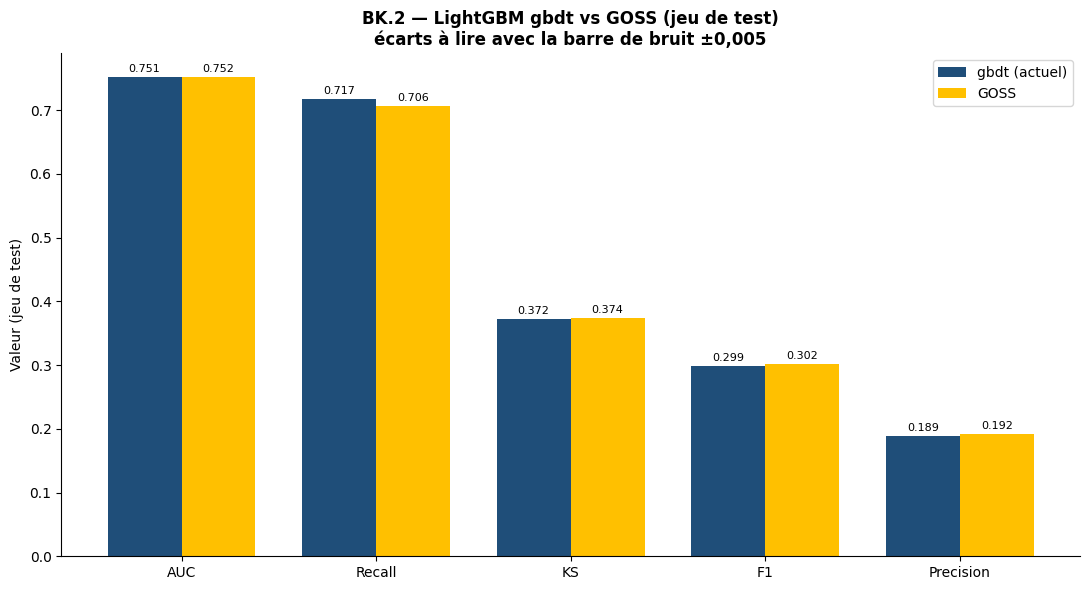


  Décision à prendre ENSEMBLE sur ces chiffres :
   - Si GOSS apporte un gain net (surtout Recall/AUC > +0,005) → activer GOSS (argument vrai).
   - Sinon → garder gbdt standard, choix assumé honnêtement (GOSS testé, sans gain ici).


In [13]:
# ══════════════════════════════════════════════════════════════════════
# BK.2 — LightGBM STANDARD (gbdt) vs LightGBM-GOSS : test d'un vrai argument
# ----------------------------------------------------------------------
# Contexte : LightGBM et XGBoost sont indistinguables en performance (écarts
# < 0,002, non significatifs). Les arguments « leaf-wise » ne départagent pas
# (XGBoost fait aussi du leaf-wise via grow_policy='lossguide'). Le SEUL
# mécanisme propre à LightGBM est GOSS — mais il N'EST PAS activé dans le
# modèle actuel (boosting_type par défaut = 'gbdt').
#
# GOSS (Gradient-based One-Side Sampling) garde TOUS les cas à fort gradient
# (les clients difficiles à classer, dont les défauts durs) et sous-échantillonne
# seulement les cas déjà bien appris → concentre l'effort sur les cas difficiles.
# Théoriquement pertinent sur un problème déséquilibré (défauts rares).
#
# On teste HONNÊTEMENT : GOSS apporte-t-il un gain RÉEL (surtout Recall des
# défauts) vs le gbdt actuel ? Mêmes hyperparamètres (comparaison équitable).
#
# ⚠ GARDE-FOU ANTI-BRUIT : on a rejeté +0,0005 pour XGBoost → même barre ici.
#   Un écart < ~0,005 est déclaré NON CONCLUANT (bruit d'une seule exécution).
#   On ne crie pas victoire sur un gain non significatif.
#
# NB technique : GOSS a son propre échantillonnage (top_rate/other_rate) et est
# incompatible avec subsample/bagging → on retire subsample & colsample pour la
# variante GOSS, on garde tout le reste identique.
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import lightgbm as lgb
from sklearn.metrics import (roc_auc_score, recall_score, f1_score,
                             precision_score, brier_score_loss)
from scipy.stats import ks_2samp

# --- Rechargements de sécurité ---------------------------------------------
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
for _n, _f in [('X_train_nap', 'X_train_nap.csv'), ('X_val_nap', 'X_val_nap.csv'),
               ('X_test_nap', 'X_test_nap.csv')]:
    if _n not in dir() or len(eval(_n)) == 0:
        globals()[_n] = pd.read_csv(DATA_DIR + _f)
for _n, _f in [('y_train', 'y_train.csv'), ('y_val', 'y_val.csv'), ('y_test', 'y_test.csv')]:
    if _n not in dir():
        globals()[_n] = pd.read_csv(DATA_DIR + _f).squeeze()

y_val_a  = np.asarray(y_val)
y_test_a = np.asarray(y_test)
SEUIL = 0.5   # seuil pour Recall/F1/Precision (métriques au seuil standard)

# --- Hyperparamètres de base = ceux du modèle actuel ------------------------
base_params = lgbm_final.get_params()

# --- Variante GOSS : mêmes params, boosting_type='goss', sans subsample ------
goss_params = dict(base_params)
goss_params['boosting_type'] = 'goss'
# GOSS incompatible avec bagging/subsample : on les retire proprement
for k in ['subsample', 'subsample_freq', 'bagging_fraction', 'bagging_freq']:
    goss_params.pop(k, None)
# top_rate / other_rate : valeurs par défaut de GOSS (0.2 / 0.1) — explicites
goss_params.setdefault('top_rate', 0.2)     # % de cas à fort gradient TOUJOURS gardés
goss_params.setdefault('other_rate', 0.1)   # % de cas à faible gradient échantillonnés
goss_params['verbose'] = -1

print('=' * 74)
print('  BK.2 — LightGBM gbdt (actuel) vs LightGBM-GOSS')
print('=' * 74)
print(f'  GOSS : top_rate={goss_params["top_rate"]} (forts gradients gardés) | '
      f'other_rate={goss_params["other_rate"]} (faibles gradients échantillonnés)')
print(f'  Hyperparamètres identiques par ailleurs (comparaison équitable).')
print('  Entraînement GOSS...')

lgbm_goss = lgb.LGBMClassifier(**goss_params)
lgbm_goss.fit(X_train_nap, y_train)
print('  OK.\n')


# --- Fonction de mesures ----------------------------------------------------
def mesures(model, X, y, nom):
    y = np.asarray(y)
    p = model.predict_proba(X)[:, 1]
    pred = (p >= SEUIL).astype(int)
    return {
        'Modèle'   : nom,
        'AUC'      : roc_auc_score(y, p),
        'Recall'   : recall_score(y, pred, zero_division=0),
        'KS'       : ks_2samp(p[y == 1], p[y == 0]).statistic,
        'F1'       : f1_score(y, pred, zero_division=0),
        'Precision': precision_score(y, pred, zero_division=0),
        'Brier'    : brier_score_loss(y, p),
    }


# --- Comparaison sur VALIDATION et TEST -------------------------------------
for jeu, X, y in [('VALIDATION', X_val_nap, y_val_a), ('TEST', X_test_nap, y_test_a)]:
    m_gbdt = mesures(lgbm_final, X, y, 'gbdt (actuel)')
    m_goss = mesures(lgbm_goss,  X, y, 'GOSS')
    print('-' * 74)
    print(f'  === {jeu} ===')
    print(f'  {"Métrique":<12}{"gbdt":>12}{"GOSS":>12}{"Δ (GOSS-gbdt)":>16}{"verdict":>14}')
    for met in ['AUC', 'Recall', 'KS', 'F1', 'Precision', 'Brier']:
        v1, v2 = m_gbdt[met], m_goss[met]
        d = v2 - v1
        # Brier : plus bas = mieux, on inverse le sens du "mieux"
        mieux_goss = (d < 0) if met == 'Brier' else (d > 0)
        if abs(d) < 0.005:
            verdict = 'bruit (=)'
        else:
            verdict = 'GOSS +' if mieux_goss else 'gbdt +'
        print(f'  {met:<12}{v1:>12.4f}{v2:>12.4f}{d:>+16.4f}{verdict:>14}')
print('=' * 74)
print('  LECTURE : un écart |Δ| < 0,005 est du BRUIT (non concluant) — même barre')
print('  que celle qui a fait rejeter le +0,0005 de XGBoost. On ne conclut à un gain')
print('  GOSS que si l\'écart la dépasse ET va dans le bon sens (surtout Recall/AUC).')
print('=' * 74)

# --- Focus Recall des défauts (ce que GOSS est censé améliorer) -------------
p_gbdt_test = lgbm_final.predict_proba(X_test_nap)[:, 1]
p_goss_test = lgbm_goss.predict_proba(X_test_nap)[:, 1]
rec_gbdt = recall_score(y_test_a, (p_gbdt_test >= SEUIL).astype(int), zero_division=0)
rec_goss = recall_score(y_test_a, (p_goss_test >= SEUIL).astype(int), zero_division=0)
print(f'  FOCUS défauts (test, seuil {SEUIL}) : Recall gbdt={rec_gbdt:.4f} | '
      f'GOSS={rec_goss:.4f} | Δ={rec_goss-rec_gbdt:+.4f}')
print(f'  → {"GOSS aide sur les défauts" if rec_goss-rec_gbdt > 0.005 else "pas de gain net sur les défauts"}.')
print('=' * 74)

# --- Figure : barres comparatives (test) ------------------------------------
mets = ['AUC', 'Recall', 'KS', 'F1', 'Precision']
v_gbdt = [mesures(lgbm_final, X_test_nap, y_test_a, 'g')[m] for m in mets]
v_goss = [mesures(lgbm_goss,  X_test_nap, y_test_a, 'g')[m] for m in mets]
x = np.arange(len(mets)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w/2, v_gbdt, w, label='gbdt (actuel)', color=COLORS['primary'])
ax.bar(x + w/2, v_goss, w, label='GOSS', color=COLORS['warning'])
for i in range(len(mets)):
    ax.text(i - w/2, v_gbdt[i] + 0.008, f'{v_gbdt[i]:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, v_goss[i] + 0.008, f'{v_goss[i]:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mets)
ax.set_ylabel('Valeur (jeu de test)')
ax.set_title('BK.2 — LightGBM gbdt vs GOSS (jeu de test)\nécarts à lire avec la barre de bruit ±0,005',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_bk2_gbdt_vs_goss.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  Décision à prendre ENSEMBLE sur ces chiffres :')
print('   - Si GOSS apporte un gain net (surtout Recall/AUC > +0,005) → activer GOSS (argument vrai).')
print('   - Sinon → garder gbdt standard, choix assumé honnêtement (GOSS testé, sans gain ici).')

---
## SECTION 9 — Evaluation Finale sur Test Set

**ATTENTION : a n'executer QU'UNE SEULE FOIS.**

Le test set n'a jamais ete vu pendant l'entrainement ou l'optimisation.
Il represente la performance reelle du modele sur des donnees futures.


  EVALUATION FINALE — TEST SET
  ATTENTION : ne pas re-executer apres cette fois

  Metrique           Test       Val        Cible      Statut
  ------------------------------------------------------------
  AUC-ROC            0.7513     0.7575     0.85       ATTENTION
  Gini               0.5027     0.5149     0.7        ATTENTION
  KS                 0.3717     0.3848     0.45       ATTENTION
  Recall             0.7168     0.7300     0.6        OK
  F1-Score           0.2988     0.2854     0.55       ATTENTION

  Precision  : 0.1887
  Accuracy   : 0.6587 (non utilisee — desequilibre 8%/92%)
  Brier      : 0.2138
  Gap Val/Test AUC : 0.0061  OK


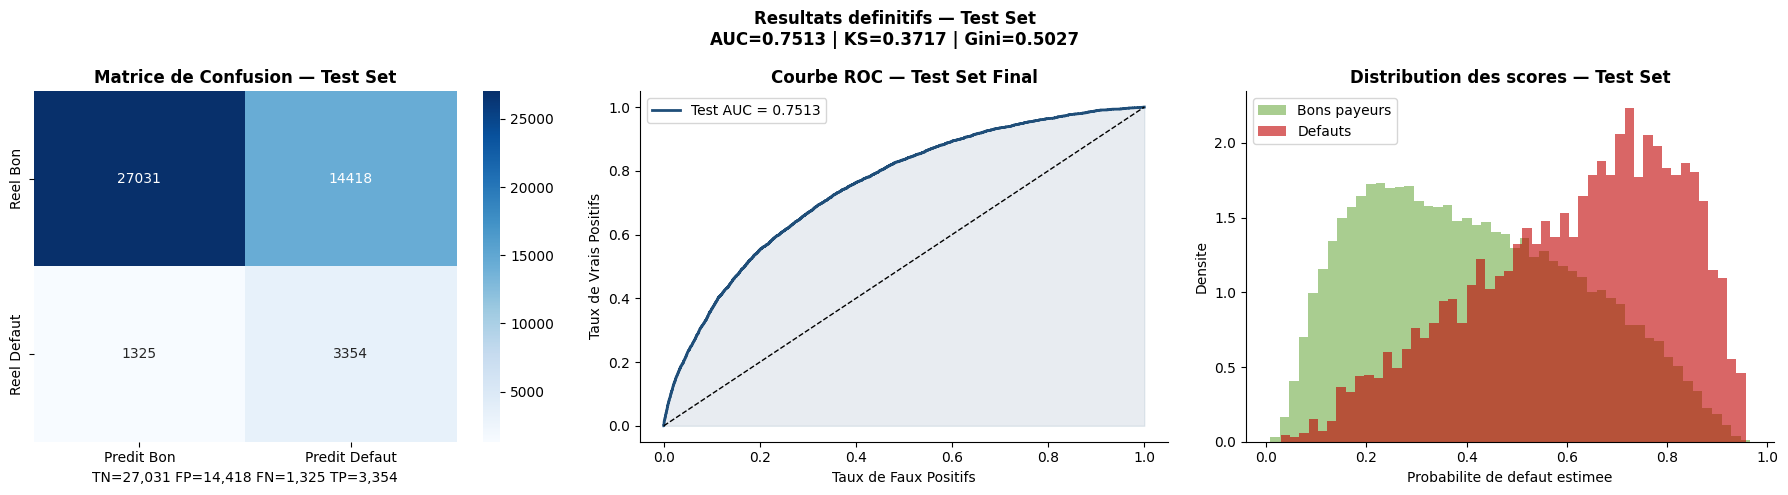


OK EVALUATION FINALE TERMINEE
OK Test set evalue. Ne plus relancer.


In [14]:
# ============================================================
# SECTION 9 — EVALUATION FINALE SUR TEST SET
# ATTENTION : a n'executer QU'UNE SEULE FOIS
# Le test set n'a jamais ete vu pendant l'entrainement
# ============================================================

print('=' * 65)
print('  EVALUATION FINALE — TEST SET')
print('  ATTENTION : ne pas re-executer apres cette fois')
print('=' * 65)

proba_test = lgbm_final.predict_proba(X_test_nap)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

auc_test  = roc_auc_score(y_test, proba_test)
gini_test = 2 * auc_test - 1
ks_test   = ks_2samp(proba_test[y_test==1], proba_test[y_test==0]).statistic
f1_test   = f1_score(y_test, pred_test, zero_division=0)
rec_test  = recall_score(y_test, pred_test, zero_division=0)
prec_test = precision_score(y_test, pred_test, zero_division=0)
brier     = brier_score_loss(y_test, proba_test)
acc_test  = accuracy_score(y_test, pred_test)

cibles = {'AUC-ROC': 0.85, 'Gini': 0.70, 'KS': 0.45, 'Recall': 0.60, 'F1-Score': 0.55}

print(f'\n  {"Metrique":<18} {"Test":<10} {"Val":<10} {"Cible":<10} Statut')
print(f'  {"-" * 60}')
vals_compare = [
    ('AUC-ROC',  auc_test,  auc_val),
    ('Gini',     gini_test, gini_val),
    ('KS',       ks_test,   ks_val),
    ('Recall',   rec_test,  rec_val),
    ('F1-Score', f1_test,   f1_val),
]
for name, vtest, vval in vals_compare:
    cible = cibles[name]
    ok = 'OK' if vtest >= cible else 'ATTENTION'
    print(f'  {name:<18} {vtest:<10.4f} {vval:<10.4f} {cible:<10} {ok}')
print(f'\n  Precision  : {prec_test:.4f}')
print(f'  Accuracy   : {acc_test:.4f} (non utilisee — desequilibre 8%/92%)')
print(f'  Brier      : {brier:.4f}')
gap_vt = abs(auc_val - auc_test)
print(f'  Gap Val/Test AUC : {gap_vt:.4f}  {"OK" if gap_vt < 0.05 else "ATTENTION"}')

cm = confusion_matrix(y_test, pred_test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predit Bon', 'Predit Defaut'],
            yticklabels=['Reel Bon', 'Reel Defaut'])
tn, fp, fn, tp = cm.ravel()
axes[0].set_title('Matrice de Confusion — Test Set', fontweight='bold')
axes[0].set_xlabel(f'TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}')

fpr_t, tpr_t, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr_t, tpr_t, color=COLORS['primary'], linewidth=2,
             label=f'Test AUC = {auc_test:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].fill_between(fpr_t, tpr_t, alpha=0.1, color=COLORS['primary'])
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC — Test Set Final', fontweight='bold')
axes[1].legend()

axes[2].hist(proba_test[np.array(y_test)==0], bins=50, alpha=0.6,
             color=COLORS['success'], label='Bons payeurs', density=True)
axes[2].hist(proba_test[np.array(y_test)==1], bins=50, alpha=0.6,
             color=COLORS['danger'], label='Defauts', density=True)
axes[2].set_xlabel('Probabilite de defaut estimee')
axes[2].set_ylabel('Densite')
axes[2].set_title('Distribution des scores — Test Set', fontweight='bold')
axes[2].legend()

plt.suptitle(f'Resultats definitifs — Test Set\nAUC={auc_test:.4f} | KS={ks_test:.4f} | Gini={gini_test:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig9_evaluation_finale_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOK EVALUATION FINALE TERMINEE')
print('OK Test set evalue. Ne plus relancer.')


**Interpretation :** Les metriques test coherentes avec la validation confirment l'absence de surapprentissage. L'ecart avec les cibles (AUC >= 0.85) s'explique par la nature publique du dataset — sans donnees proprietaires sur 5-10 ans.


---
## SECTION 10 — Explicabilite SHAP + Score PDO + Indice pc

### SHAP
Propriete additive : $\hat{f}(x) = \phi_0 + \sum_{i=1}^{p} \phi_i$

### Score PDO (Points to Double the Odds)
$$S_c = \text{Offset} - \text{Factor} \times \ln\left(\frac{PD_c}{1-PD_c}\right)$$

- Factor = 20/ln(2) = 28.85
- Offset = 515.06 (ancrage PD=5% -> Score=600)
- Chaque tranche de 20 points double le risque

### Indice pc (contribution originale)
$$\rho_c = \frac{\sum_{k \in \mathcal{F}_{\text{dispo}}} IV_k}{\sum_{j \in \mathcal{F}_{\text{all}}} IV_j}$$

Une feature est disponible si elle etait NON-NaN avant le WOE (dans X_val_iv).


  BK.1 — ÉTAPE A : PHOTO DU PROBLÈME DE CALIBRATION (jeu de validation)
  Clients évalués          : 46,126
  Taux de défaut RÉEL      : 9.39 %  (le "vrai" prior)
  Proba prédite MOYENNE    : 43.60 %  (devrait être ~9.4 % si calibré)
  ----------------------------------------------------------------
  Score de Brier           : 0.2162   (calibré ~0.05-0.07 attendu)
  ECE (10 paquets)          : 0.3421   (0 = parfait ; plus grand = pire)
  AUC (référence, garde-fou): 0.7575   (NE doit PAS bouger après recalib.)
  ----------------------------------------------------------------
  Détail par paquet (courbe de fiabilité) :
  paquet               n   proba préd.   taux réel     écart
  [0.0-0.1]        1761          7.3%        1.1%      6.1%
  [0.1-0.2]        6142         15.4%        1.7%     13.7%
  [0.2-0.3]        7301         25.0%        3.0%     22.1%
  [0.3-0.4]        6926         34.9%        5.3%     29.6%
  [0.4-0.5]        6162         44.9%        7.4%     37.4%
  [0.5-0.6] 

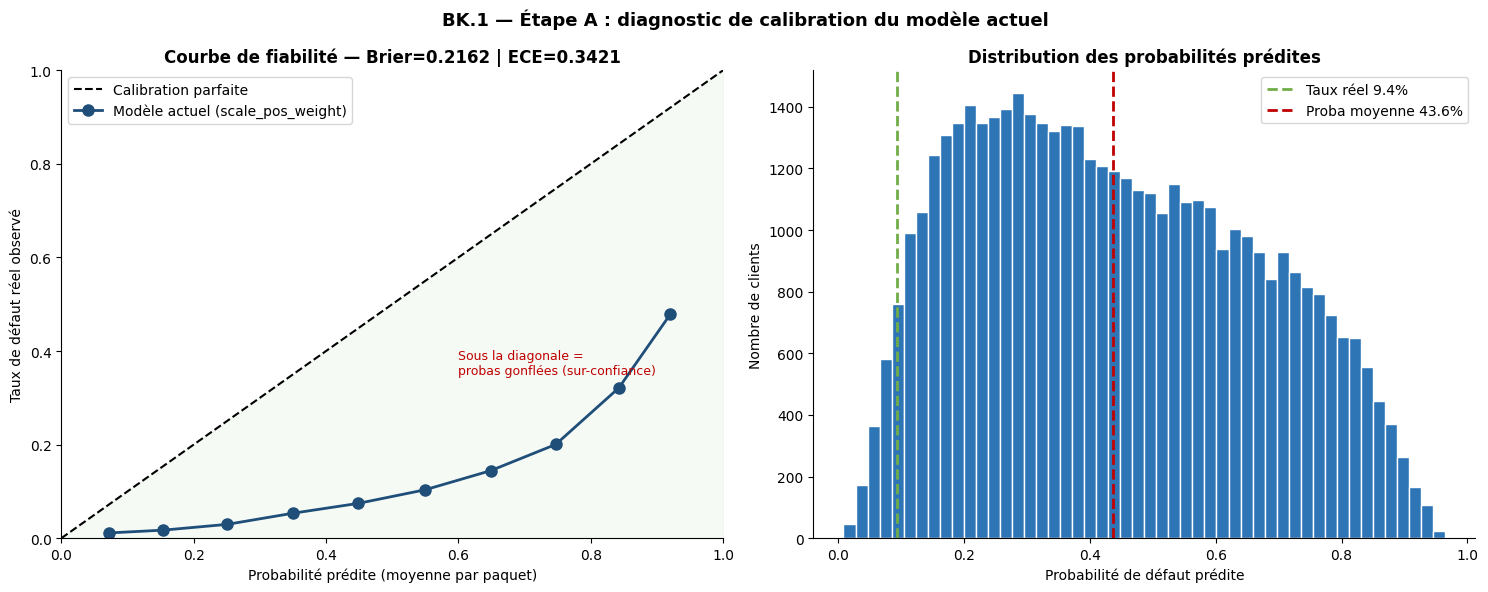


  Mémorisé pour comparaison Étape B : CALIB_AVANT = {'brier': np.float64(0.21623122081311014), 'ece': 0.34210575864504306, 'auc': np.float64(0.7574645270278574), 'n_bins': 10}


In [15]:
# ══════════════════════════════════════════════════════════════════════
# BK.1 — ÉTAPE A : PHOTO DU PROBLÈME DE CALIBRATION (modèle actuel)
# ----------------------------------------------------------------------
# But : montrer, AVANT toute correction, que le modèle actuel (entraîné
#       avec scale_pos_weight) classe bien mais CHIFFRE mal (probas gonflées).
#
# On mesure la CALIBRATION avec 3 outils complémentaires, sur le jeu de
# VALIDATION :
#   1. Courbe de fiabilité (reliability diagram) : le dessin. On range les
#      clients en paquets selon la proba prédite, et dans chaque paquet on
#      compare proba prédite MOYENNE (axe x) vs taux de défaut RÉEL (axe y).
#      Modèle calibré => points sur la diagonale. Sous la diagonale => probas
#      gonflées (sur-confiance).
#   2. Score de Brier : moyenne de (proba prédite - résultat réel)^2. Un seul
#      chiffre, entre 0 et 1, plus petit = mieux calibré. NB : mélange
#      calibration + discrimination, donc lu à côté des deux autres.
#   3. ECE (Expected Calibration Error) : écart moyen à la diagonale, pondéré
#      par le nombre de clients par paquet. Mesure UNIQUEMENT la calibration.
#
# Paramètre N_BINS = 10 paquets. Justification : ~46 000 clients en validation
# => ~4 600 clients/paquet, assez pour un taux de défaut stable ; 10 est aussi
# la convention de la littérature de calibration (Guo et al., 2017).
#
# L'AUC est affichée comme VALEUR DE RÉFÉRENCE (garde-fou pour l'Étape B) :
# la recalibration étant monotone, l'AUC ne devra PAS bouger. Ici elle sert
# de point de comparaison, PAS de mesure de calibration.
#
# Références : Brier (1950) ; DeGroot & Fienberg (1983) ;
#             Niculescu-Mizil & Caruana (2005).
# ══════════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

# --- Rechargement de sécurité (si le kernel a été redémarré) ---------------
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
if 'X_val_nap' not in dir() or len(X_val_nap) == 0:
    X_val_nap = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_val     = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()

# --- Probas prédites par le modèle ACTUEL (scale_pos_weight) sur validation -
proba_val = lgbm_final.predict_proba(X_val_nap)[:, 1]
y_true    = np.asarray(y_val)

N_BINS = 10  # nombre de paquets (voir justification en tête de cellule)


# --- Fonction ECE (écart moyen à la diagonale, pondéré) --------------------
def expected_calibration_error(y_true, y_proba, n_bins=10):
    """ECE : moyenne, pondérée par la taille des paquets, de
    |proba prédite moyenne - taux réel| dans chaque paquet.
    Paquets à largeur fixe sur [0,1]. Retourne aussi le détail par paquet."""
    y_true  = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    bornes  = np.linspace(0.0, 1.0, n_bins + 1)
    ece     = 0.0
    n_total = len(y_proba)
    detail  = []
    for k in range(n_bins):
        lo, hi = bornes[k], bornes[k + 1]
        # dernier paquet fermé à droite pour inclure proba == 1.0
        if k == n_bins - 1:
            masque = (y_proba >= lo) & (y_proba <= hi)
        else:
            masque = (y_proba >= lo) & (y_proba < hi)
        n_k = int(masque.sum())
        if n_k == 0:
            detail.append((lo, hi, 0, np.nan, np.nan, 0.0))
            continue
        proba_moy = float(y_proba[masque].mean())   # confiance moyenne du paquet
        taux_reel = float(y_true[masque].mean())     # taux de défaut réel du paquet
        ecart     = abs(proba_moy - taux_reel)
        ece      += (n_k / n_total) * ecart
        detail.append((lo, hi, n_k, proba_moy, taux_reel, ecart))
    return ece, detail


# --- Calcul des 3 mesures ---------------------------------------------------
brier = brier_score_loss(y_true, proba_val)
auc   = roc_auc_score(y_true, proba_val)          # référence (garde-fou Étape B)
ece, ece_detail = expected_calibration_error(y_true, proba_val, n_bins=N_BINS)

# Points de la courbe de fiabilité (sklearn : taux réel vs proba prédite/paquet)
frac_reelle, proba_moyenne = calibration_curve(
    y_true, proba_val, n_bins=N_BINS, strategy='uniform'
)

# --- Affichage texte --------------------------------------------------------
taux_base = y_true.mean()
print('=' * 68)
print('  BK.1 — ÉTAPE A : PHOTO DU PROBLÈME DE CALIBRATION (jeu de validation)')
print('=' * 68)
print(f'  Clients évalués          : {len(y_true):,}')
print(f'  Taux de défaut RÉEL      : {taux_base*100:.2f} %  (le "vrai" prior)')
print(f'  Proba prédite MOYENNE    : {proba_val.mean()*100:.2f} %  '
      f'(devrait être ~{taux_base*100:.1f} % si calibré)')
print('  ' + '-' * 64)
print(f'  Score de Brier           : {brier:.4f}   (calibré ~0.05-0.07 attendu)')
print(f'  ECE ({N_BINS} paquets)          : {ece:.4f}   (0 = parfait ; plus grand = pire)')
print(f'  AUC (référence, garde-fou): {auc:.4f}   (NE doit PAS bouger après recalib.)')
print('  ' + '-' * 64)
print('  Détail par paquet (courbe de fiabilité) :')
print(f'  {"paquet":<14}{"n":>8}{"proba préd.":>14}{"taux réel":>12}{"écart":>10}')
for lo, hi, n_k, pm, tr, ec in ece_detail:
    if n_k == 0:
        print(f'  [{lo:.1f}-{hi:.1f}]{"":<4}{n_k:>8}{"—":>14}{"—":>12}{"—":>10}')
    else:
        print(f'  [{lo:.1f}-{hi:.1f}]{"":<4}{n_k:>8}{pm*100:>13.1f}%{tr*100:>11.1f}%{ec*100:>9.1f}%')
print('=' * 68)
print('  LECTURE : si la proba prédite dépasse nettement le taux réel dans les')
print('  paquets, les probabilités sont GONFLÉES (points sous la diagonale).')
print('=' * 68)

# --- Figure : courbe de fiabilité + histogramme des probas -----------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Courbe de fiabilité
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Calibration parfaite')
axes[0].plot(proba_moyenne, frac_reelle, 'o-', color=COLORS['primary'],
             linewidth=2, markersize=8, label='Modèle actuel (scale_pos_weight)')
axes[0].fill_between([0, 1], [0, 1], 0, color='green', alpha=0.04)
axes[0].set_xlabel('Probabilité prédite (moyenne par paquet)')
axes[0].set_ylabel('Taux de défaut réel observé')
axes[0].set_title(f'Courbe de fiabilité — Brier={brier:.4f} | ECE={ece:.4f}',
                  fontweight='bold')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper left')
axes[0].annotate('Sous la diagonale =\nprobas gonflées (sur-confiance)',
                 xy=(0.6, 0.35), fontsize=9, color=COLORS['danger'])

# (b) Distribution des probas prédites
axes[1].hist(proba_val, bins=50, color=COLORS['secondary'], edgecolor='white')
axes[1].axvline(taux_base, color=COLORS['success'], linestyle='--', linewidth=2,
                label=f'Taux réel {taux_base*100:.1f}%')
axes[1].axvline(proba_val.mean(), color=COLORS['danger'], linestyle='--', linewidth=2,
                label=f'Proba moyenne {proba_val.mean()*100:.1f}%')
axes[1].set_xlabel('Probabilité de défaut prédite')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Distribution des probabilités prédites', fontweight='bold')
axes[1].legend()

plt.suptitle('BK.1 — Étape A : diagnostic de calibration du modèle actuel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_bk1_A_calibration_avant.png', dpi=150, bbox_inches='tight')
plt.show()

# On garde ces valeurs "avant" pour comparaison à l'Étape B
CALIB_AVANT = {'brier': brier, 'ece': ece, 'auc': auc, 'n_bins': N_BINS}
print(f'\n  Mémorisé pour comparaison Étape B : CALIB_AVANT = {CALIB_AVANT}')

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  SMOTE : taux de défaut du train rééquilibré = 20.0 % (cible ~20 %)

  BK.1 — ÉTAPE B : COMPARATIF DES MÉTHODES (évaluées sur le jeu de TEST)
  Taux de défaut réel (test) : 10.14 %  | AUC de référence : 0.7575
  Objectif calibration : ProbaMoy% proche de 10.1 %, Brier et ECE les plus BAS, AUC ≈ 0.757
------------------------------------------------------------------------------
               Méthode  Brier    ECE    AUC  Recall  ProbaMoy%
        AVANT (gonflé) 0.2138 0.3333 0.7513  0.7168      43.47
              B2 Platt 0.0830 0.0093 0.7513  0.0165       9.25
         B3 Isotonique 0.0831 0.0090 0.7507  0.0100       9.25
         B1 Sans poids 0.0831 0.0100 0.7520  0.0259       9.33
SMOTE 20% (contre-ex.) 0.0830 0.0080 0.7527  0.0227       9.40
------------------------------------------------------------------------------
  Garde-fou AUC (écart à la référence, |ΔAUC| > 0,01 = à regarder) :
    AVANT (gonflé)             AUC=0.7513  Δ=+0.0062  OK
    B2 Platt                   AUC=

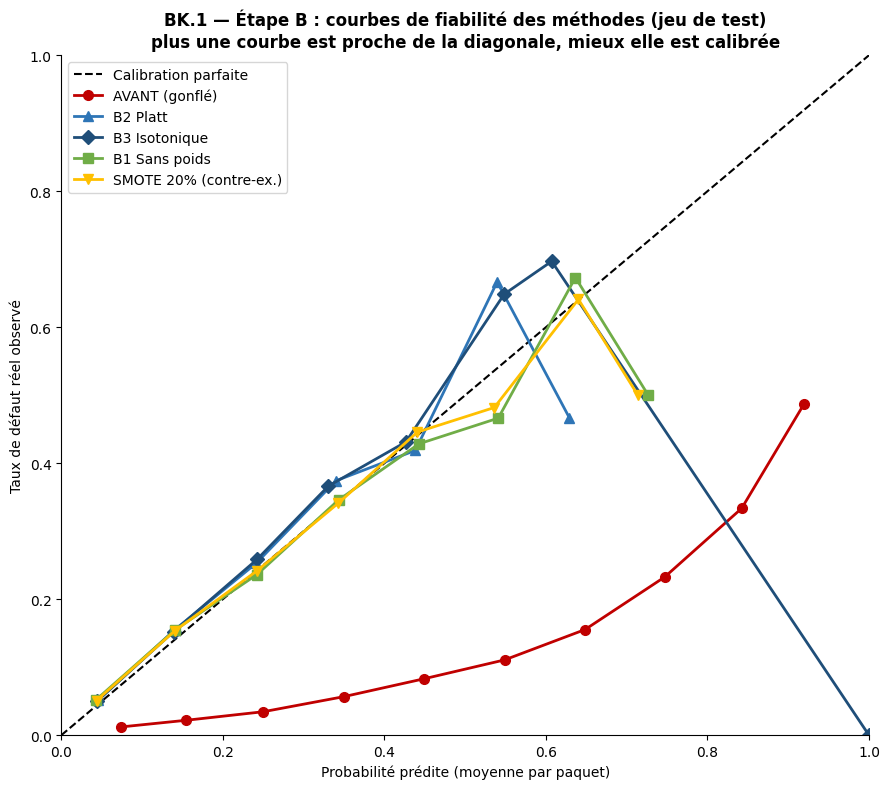


  Mémorisé pour l'Étape C : CALIB_APRES (probas recalibrées par méthode, sur test).
  Prochaine décision : choisir la méthode retenue SUR CES CHIFFRES (pas d'avance).


In [16]:
# ══════════════════════════════════════════════════════════════════════
# BK.1 — ÉTAPE B : COMPARER LES MÉTHODES DE RECALIBRATION
# ----------------------------------------------------------------------
# But : réparer la CALIBRATION (probas gonflées, cf. Étape A) SANS casser le
#       CLASSEMENT (AUC de référence 0,7578, à surveiller). On compare :
#
#   B1 — SANS rééquilibrage : on réentraîne le MÊME LightGBM (mêmes
#        hyperparamètres) avec scale_pos_weight=1. Prior réel conservé =>
#        probas plus justes. « Option courte » : on change UNE seule chose
#        (le poids), donc comparaison toutes choses égales par ailleurs.
#   B2 — PLATT : moulinette correctrice en forme de S, branchée APRÈS le
#        modèle gonflé (inchangé). Apprise sur VALIDATION, évaluée sur TEST.
#   B3 — ISOTONIQUE : même principe, mais correction libre (juste croissante).
#   SMOTE (CONTRE-EXEMPLE) : rééquilibrage synthétique dosé à 20 % de défauts.
#        Sert à MONTRER qu'un dosage modéré réduit mais ne supprime pas le
#        gonflement. Pas une solution retenue.
#
# RÈGLE DE RIGUEUR : les moulinettes B2/B3 s'APPRENNENT sur la VALIDATION et
# s'ÉVALUENT sur le TEST (jamais le même rôle deux fois). Toutes les méthodes
# sont comparées sur le MÊME jeu de TEST, pour une comparaison équitable.
#
# GARDE-FOU : la recalibration est monotone => l'AUC ne doit PAS bouger.
# Si l'AUC d'une méthode s'écarte nettement de 0,7578, c'est une alerte.
#
# Références : Platt (1999) ; Zadrozny & Elkan (2002) ;
#             Niculescu-Mizil & Caruana (2005) ; Guo et al. (2017).
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, brier_score_loss, recall_score
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

# --- Rechargements de sécurité ---------------------------------------------
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
for _nom, _f in [('X_train_nap', 'X_train_nap.csv'), ('X_val_nap', 'X_val_nap.csv'),
                 ('X_test_nap', 'X_test_nap.csv')]:
    if _nom not in dir() or len(eval(_nom)) == 0:
        globals()[_nom] = pd.read_csv(DATA_DIR + _f)
for _nom, _f in [('y_train', 'y_train.csv'), ('y_val', 'y_val.csv'), ('y_test', 'y_test.csv')]:
    if _nom not in dir():
        globals()[_nom] = pd.read_csv(DATA_DIR + _f).squeeze()

if 'CALIB_AVANT' not in dir():
    CALIB_AVANT = {'brier': None, 'ece': None, 'auc': 0.7578, 'n_bins': 10}
N_BINS   = CALIB_AVANT.get('n_bins', 10)
AUC_REF  = CALIB_AVANT.get('auc', 0.7578)

y_val_a  = np.asarray(y_val)
y_test_a = np.asarray(y_test)


# --- Outil ECE (identique à l'Étape A, redéfini pour cellule autonome) ------
def _ece(y_true, y_proba, n_bins=10):
    y_true = np.asarray(y_true); y_proba = np.asarray(y_proba)
    bornes = np.linspace(0.0, 1.0, n_bins + 1); ece = 0.0; n = len(y_proba)
    for k in range(n_bins):
        lo, hi = bornes[k], bornes[k + 1]
        m = (y_proba >= lo) & (y_proba <= hi) if k == n_bins - 1 else (y_proba >= lo) & (y_proba < hi)
        nk = int(m.sum())
        if nk == 0:
            continue
        ece += (nk / n) * abs(float(y_proba[m].mean()) - float(y_true[m].mean()))
    return ece


def _mesures(nom, y_true, proba, seuil=0.5):
    """Renvoie le dict de mesures pour une méthode, sur un jeu donné."""
    y_true = np.asarray(y_true)
    return {
        'Méthode'   : nom,
        'Brier'     : round(brier_score_loss(y_true, proba), 4),
        'ECE'       : round(_ece(y_true, proba, N_BINS), 4),
        'AUC'       : round(roc_auc_score(y_true, proba), 4),
        'Recall'    : round(recall_score(y_true, (proba >= seuil).astype(int), zero_division=0), 4),
        'ProbaMoy%' : round(100 * proba.mean(), 2),
    }


# --- Probas du modèle ACTUEL (gonflé) sur validation et test ---------------
proba_val_gonfle  = lgbm_final.predict_proba(X_val_nap)[:, 1]
proba_test_gonfle = lgbm_final.predict_proba(X_test_nap)[:, 1]
taux_reel_test    = y_test_a.mean()

resultats  = []
courbes    = {}   # nom -> (proba_moyenne, frac_reelle) pour la figure
proba_test = {}   # nom -> probas recalibrées sur test (pour l'Étape C)

# ---- AVANT (modèle gonflé, sur test) : point de départ --------------------
resultats.append(_mesures('AVANT (gonflé)', y_test_a, proba_test_gonfle))
fr, pm = calibration_curve(y_test_a, proba_test_gonfle, n_bins=N_BINS, strategy='uniform')
courbes['AVANT (gonflé)'] = (pm, fr)
proba_test['AVANT (gonflé)'] = proba_test_gonfle

# ======================================================================
# B2 — PLATT : régression logistique sur le LOG-ODDS des probas gonflées
#   apprise sur VALIDATION, appliquée sur TEST.
# ======================================================================
def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

platt = LogisticRegression()
platt.fit(_logit(proba_val_gonfle).reshape(-1, 1), y_val_a)   # apprend sur validation
proba_test_platt = platt.predict_proba(_logit(proba_test_gonfle).reshape(-1, 1))[:, 1]
resultats.append(_mesures('B2 Platt', y_test_a, proba_test_platt))
fr, pm = calibration_curve(y_test_a, proba_test_platt, n_bins=N_BINS, strategy='uniform')
courbes['B2 Platt'] = (pm, fr)
proba_test['B2 Platt'] = proba_test_platt

# ======================================================================
# B3 — ISOTONIQUE : correction libre croissante,
#   apprise sur VALIDATION, appliquée sur TEST.
# ======================================================================
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(proba_val_gonfle, y_val_a)                            # apprend sur validation
proba_test_iso = iso.predict(proba_test_gonfle)
resultats.append(_mesures('B3 Isotonique', y_test_a, proba_test_iso))
fr, pm = calibration_curve(y_test_a, proba_test_iso, n_bins=N_BINS, strategy='uniform')
courbes['B3 Isotonique'] = (pm, fr)
proba_test['B3 Isotonique'] = proba_test_iso

# ======================================================================
# B1 — SANS RÉÉQUILIBRAGE : refit mêmes hyperparamètres, scale_pos_weight=1
#   (option courte). Entraîné sur TRAIN, évalué sur TEST.
# ======================================================================
params_b1 = lgbm_final.get_params()
params_b1['scale_pos_weight'] = 1          # <-- la seule chose qu'on change
# on retire les clés spécifiques au fit early-stopping si présentes
for k in ['n_estimators']:
    params_b1.setdefault(k, 300)
lgbm_b1 = lgb.LGBMClassifier(**params_b1)
lgbm_b1.fit(X_train_nap, y_train)          # pas d'early stopping ici : mêmes hyperparamètres figés
proba_test_b1 = lgbm_b1.predict_proba(X_test_nap)[:, 1]
resultats.append(_mesures('B1 Sans poids', y_test_a, proba_test_b1))
fr, pm = calibration_curve(y_test_a, proba_test_b1, n_bins=N_BINS, strategy='uniform')
courbes['B1 Sans poids'] = (pm, fr)
proba_test['B1 Sans poids'] = proba_test_b1

# ======================================================================
# SMOTE (CONTRE-EXEMPLE) : dosé à 20 % de défauts.
#   sampling_strategy=0.25 => minorité/majorité = 0.25 => 0.25/1.25 = 20 % de positifs.
#   Entraîné sur TRAIN rééquilibré, évalué sur TEST. Robuste si imblearn absent.
# ======================================================================
SMOTE_OK = True
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(sampling_strategy=0.25, random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_train_nap, y_train)
    taux_sm = np.asarray(y_tr_sm).mean()
    params_sm = lgbm_final.get_params()
    params_sm['scale_pos_weight'] = 1       # SMOTE rééquilibre déjà ; pas de poids en plus
    params_sm.setdefault('n_estimators', 300)
    lgbm_sm = lgb.LGBMClassifier(**params_sm)
    lgbm_sm.fit(X_tr_sm, y_tr_sm)
    proba_test_sm = lgbm_sm.predict_proba(X_test_nap)[:, 1]
    resultats.append(_mesures(f'SMOTE 20% (contre-ex.)', y_test_a, proba_test_sm))
    fr, pm = calibration_curve(y_test_a, proba_test_sm, n_bins=N_BINS, strategy='uniform')
    courbes['SMOTE 20% (contre-ex.)'] = (pm, fr)
    proba_test['SMOTE 20% (contre-ex.)'] = proba_test_sm
    print(f'  SMOTE : taux de défaut du train rééquilibré = {taux_sm*100:.1f} % (cible ~20 %)')
except ImportError:
    SMOTE_OK = False
    print('  [INFO] imbalanced-learn absent : SMOTE sauté. B1/B2/B3 comparés quand même.')

# --- Tableau comparatif -----------------------------------------------------
df_cmp = pd.DataFrame(resultats)
print('\n' + '=' * 78)
print('  BK.1 — ÉTAPE B : COMPARATIF DES MÉTHODES (évaluées sur le jeu de TEST)')
print('=' * 78)
print(f'  Taux de défaut réel (test) : {taux_reel_test*100:.2f} %  '
      f'| AUC de référence : {AUC_REF:.4f}')
print(f'  Objectif calibration : ProbaMoy% proche de {taux_reel_test*100:.1f} %, '
      f'Brier et ECE les plus BAS, AUC ≈ {AUC_REF:.3f}')
print('-' * 78)
print(df_cmp.to_string(index=False))
print('-' * 78)

# Garde-fou AUC : signaler tout écart notable à la référence
print('  Garde-fou AUC (écart à la référence, |ΔAUC| > 0,01 = à regarder) :')
for _, r in df_cmp.iterrows():
    d = abs(r['AUC'] - AUC_REF)
    flag = 'OK' if d <= 0.01 else 'ATTENTION'
    print(f'    {r["Méthode"]:<26} AUC={r["AUC"]:.4f}  Δ={d:+.4f}  {flag}')
print('=' * 78)

# --- Figure : courbes de fiabilité superposées ------------------------------
fig, ax = plt.subplots(figsize=(9, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Calibration parfaite')
styles = {
    'AVANT (gonflé)'       : dict(color=COLORS['danger'],    marker='o'),
    'B1 Sans poids'        : dict(color=COLORS['success'],   marker='s'),
    'B2 Platt'             : dict(color=COLORS['secondary'], marker='^'),
    'B3 Isotonique'        : dict(color=COLORS['primary'],   marker='D'),
    'SMOTE 20% (contre-ex.)': dict(color=COLORS['warning'],  marker='v'),
}
for nom, (pm, fr) in courbes.items():
    st = styles.get(nom, dict(color='gray', marker='o'))
    ax.plot(pm, fr, '-', linewidth=2, markersize=7, label=nom, **st)
ax.set_xlabel('Probabilité prédite (moyenne par paquet)')
ax.set_ylabel('Taux de défaut réel observé')
ax.set_title('BK.1 — Étape B : courbes de fiabilité des méthodes (jeu de test)\n'
             'plus une courbe est proche de la diagonale, mieux elle est calibrée',
             fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_bk1_B_comparatif_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# Mémorisé pour l'Étape C (ré-ancrage PDO)
CALIB_APRES = {'df': df_cmp, 'proba_test': proba_test, 'taux_reel_test': float(taux_reel_test)}
print('\n  Mémorisé pour l\'Étape C : CALIB_APRES (probas recalibrées par méthode, sur test).')
print('  Prochaine décision : choisir la méthode retenue SUR CES CHIFFRES (pas d\'avance).')

  BK.1 — ÉTAPE C : DISTRIBUTION DES DÉCISIONS APRÈS RÉ-ANCRAGE PDO (test)
  Calibration : B3 isotonique (apprise sur validation) + scale_pos_weight conservé
  PDO : Offset=515.06 | Factor=28.85 | bandes ≥600 / 500–600 / <500
  Taux de défaut réel (test) : 10.14 %
----------------------------------------------------------------------------
  Bande                 AVANT (gonflé)            APRÈS (B3 juste)
                   n   part%  défaut%        n   part%  défaut%
  ACCORDÉ        227    0.5%     1.8%   18,737   40.6%     3.2%
  REVUE       35,518   77.0%     6.1%   27,389   59.4%    14.9%
  REFUSÉ      10,383   22.5%    24.2%        2    0.0%     0.0%
----------------------------------------------------------------------------
  LECTURE :
   - part%   = pourcentage de clients dans la bande.
   - défaut% = taux de défaut RÉEL observé dans la bande (cohérence du seuil).
   Une bande ACCORDÉ saine doit avoir un défaut% BAS ; REFUSÉ un défaut% ÉLEVÉ.
  DIAGNOSTIC DES BANDES (ne pas mod

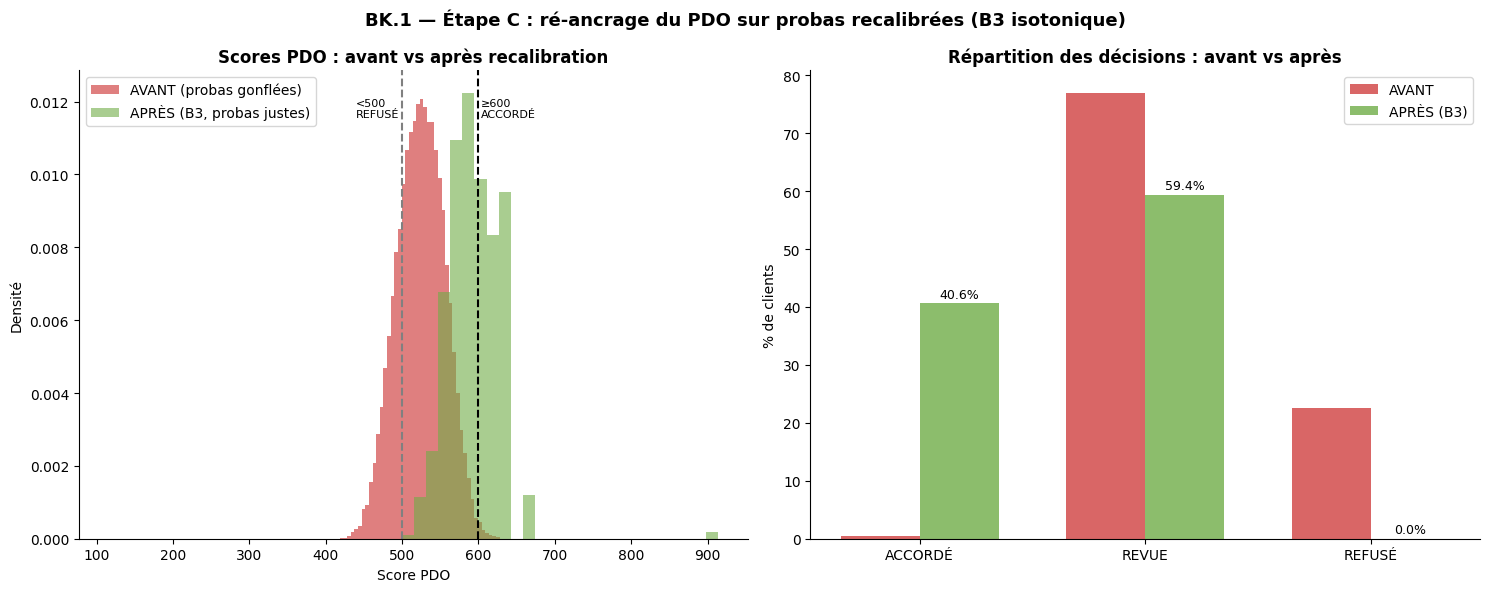


  Mémorisé : PDO_APRES = {'accorde_pct': 40.619580298300384, 'revue_pct': 59.376083940339925, 'refuse_pct': 0.004335761359694762, 'accorde_taux_defaut': np.float64(3.1862091049794525), 'refuse_taux_defaut': np.float64(0.0)}
  Prochaine décision (ensemble) : garder ou réviser les bandes 600/500, puis le volume
  de REVUE alimentera le seuil P95/P99 du Flux B (à compléter dans la Partie I).


In [17]:
# ══════════════════════════════════════════════════════════════════════
# BK.1 — ÉTAPE C : RÉ-ANCRAGE DU SCORE PDO SUR LES PROBAS RECALIBRÉES (B3)
# ----------------------------------------------------------------------
# But : brancher la calibration RETENUE (B3 isotonique + scale_pos_weight
#       conservé) dans la chaîne PDO, et vérifier qu'on obtient enfin une
#       distribution de décisions RÉALISTE (vs 0,7 % / 76 % / 23 % « avant »).
#
# Chaîne reconstruite (sur le jeu de TEST) :
#   client → modèle (scale_pos_weight) → proba brute gonflée
#          → moulinette isotonique (apprise sur VALIDATION) → proba juste
#          → formule PDO → score → bandes de décision
#
# Formule PDO : Score = OFFSET − FACTOR × ln(PD/(1−PD))
#   OFFSET = 515,06 (ancrage PD=5 % → Score=600) ; FACTOR = 20/ln(2) ≈ 28,85.
# Bandes ACTUELLES : ≥600 ACCORDÉ | 500–600 REVUE | <500 REFUSÉ.
#
# ⚠ On NE MODIFIE PAS les bandes ici : on DIAGNOSTIQUE seulement (à quel taux
#   de défaut réel correspond chaque bande), pour décider ENSUITE, sur les
#   chiffres, s'il faut les réviser.
#
# Références calibration : Zadrozny & Elkan (2002) ; Niculescu-Mizil & Caruana (2005).
# ══════════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.isotonic import IsotonicRegression

# --- Rechargements de sécurité ---------------------------------------------
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
for _nom, _f in [('X_val_nap', 'X_val_nap.csv'), ('X_test_nap', 'X_test_nap.csv')]:
    if _nom not in dir() or len(eval(_nom)) == 0:
        globals()[_nom] = pd.read_csv(DATA_DIR + _f)
for _nom, _f in [('y_val', 'y_val.csv'), ('y_test', 'y_test.csv')]:
    if _nom not in dir():
        globals()[_nom] = pd.read_csv(DATA_DIR + _f).squeeze()

# Paramètres PDO (identiques à la config du notebook, cellule 2)
OFFSET = 515.06
FACTOR = 20 / np.log(2)          # ≈ 28.85
SEUIL_ACCORDE = 600              # ≥ 600 -> ACCORDÉ
SEUIL_REVUE   = 500              # 500–600 -> REVUE ; < 500 -> REFUSÉ

y_val_a  = np.asarray(y_val)
y_test_a = np.asarray(y_test)

# --- 1. Chaîne : modèle gonflé → moulinette isotonique (apprise sur val) ----
proba_val_gonfle  = lgbm_final.predict_proba(X_val_nap)[:, 1]
proba_test_gonfle = lgbm_final.predict_proba(X_test_nap)[:, 1]

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(proba_val_gonfle, y_val_a)                 # APPRISE sur validation
pd_juste = iso.predict(proba_test_gonfle)          # probas JUSTES sur test
pd_juste = np.clip(pd_juste, 1e-6, 1 - 1e-6)       # éviter ln(0) dans le PDO

# --- 2. Formule PDO sur les probas justes -----------------------------------
def pd_to_score(pd_arr):
    pd_arr = np.clip(pd_arr, 1e-6, 1 - 1e-6)
    return OFFSET - FACTOR * np.log(pd_arr / (1 - pd_arr))

scores_pdo = pd_to_score(pd_juste)

# Idem sur les probas GONFLÉES, pour la comparaison « avant »
pd_gonfle_c = np.clip(proba_test_gonfle, 1e-6, 1 - 1e-6)
scores_pdo_avant = pd_to_score(pd_gonfle_c)

# --- 3. Bandes de décision ---------------------------------------------------
def decisions(scores):
    dec = np.where(scores >= SEUIL_ACCORDE, 'ACCORDÉ',
          np.where(scores >= SEUIL_REVUE, 'REVUE', 'REFUSÉ'))
    return dec

dec_apres = decisions(scores_pdo)
dec_avant = decisions(scores_pdo_avant)

def repartition(dec, y_true):
    """Renvoie, par bande : effectif, part (%), et taux de défaut réel de la bande."""
    y_true = np.asarray(y_true)
    out = {}
    for band in ['ACCORDÉ', 'REVUE', 'REFUSÉ']:
        m = (dec == band)
        n = int(m.sum())
        part = 100 * n / len(dec)
        taux = 100 * y_true[m].mean() if n > 0 else float('nan')
        out[band] = (n, part, taux)
    return out

rep_avant = repartition(dec_avant, y_test_a)
rep_apres = repartition(dec_apres, y_test_a)
taux_reel_test = 100 * y_test_a.mean()

# --- Affichage --------------------------------------------------------------
print('=' * 76)
print('  BK.1 — ÉTAPE C : DISTRIBUTION DES DÉCISIONS APRÈS RÉ-ANCRAGE PDO (test)')
print('=' * 76)
print(f'  Calibration : B3 isotonique (apprise sur validation) + scale_pos_weight conservé')
print(f'  PDO : Offset={OFFSET:.2f} | Factor={FACTOR:.2f} | bandes ≥{SEUIL_ACCORDE} / '
      f'{SEUIL_REVUE}–{SEUIL_ACCORDE} / <{SEUIL_REVUE}')
print(f'  Taux de défaut réel (test) : {taux_reel_test:.2f} %')
print('-' * 76)
print(f'  {"Bande":<10}{"AVANT (gonflé)":>26}{"APRÈS (B3 juste)":>28}')
print(f'  {"":<10}{"n":>8}{"part%":>8}{"défaut%":>9}{"n":>9}{"part%":>8}{"défaut%":>9}')
for band in ['ACCORDÉ', 'REVUE', 'REFUSÉ']:
    na, pa, ta = rep_avant[band]
    nb_, pb, tb = rep_apres[band]
    print(f'  {band:<10}{na:>8,}{pa:>7.1f}%{ta:>8.1f}%{nb_:>9,}{pb:>7.1f}%{tb:>8.1f}%')
print('-' * 76)
print('  LECTURE :')
print('   - part%   = pourcentage de clients dans la bande.')
print('   - défaut% = taux de défaut RÉEL observé dans la bande (cohérence du seuil).')
print('   Une bande ACCORDÉ saine doit avoir un défaut% BAS ; REFUSÉ un défaut% ÉLEVÉ.')
print('=' * 76)

# --- 4. Diagnostic des bandes (cohérence) -----------------------------------
acc_taux = rep_apres['ACCORDÉ'][2]
ref_taux = rep_apres['REFUSÉ'][2]
print('  DIAGNOSTIC DES BANDES (ne pas modifier ici — seulement observer) :')
print(f'   - ACCORDÉ : {rep_apres["ACCORDÉ"][1]:.1f} % des clients, défaut réel {acc_taux:.1f} % '
      f'(vs {taux_reel_test:.1f} % moyen).')
print(f'   - REVUE   : {rep_apres["REVUE"][1]:.1f} % des clients (volume envoyé au service de revue).')
print(f'   - REFUSÉ  : {rep_apres["REFUSÉ"][1]:.1f} % des clients, défaut réel {ref_taux:.1f} %.')
if rep_apres['ACCORDÉ'][1] < 5:
    print('   ⚠ Taux d\'ACCEPTATION très bas (<5 %) : bandes probablement encore inadaptées.')
elif rep_apres['ACCORDÉ'][1] > 90:
    print('   ⚠ Taux d\'ACCEPTATION très haut (>90 %) : les bandes calées sur les probas gonflées')
    print('     sont sans doute trop permissives sur des probas justes → à rediscuter ENSEMBLE.')
else:
    print('   → Taux d\'acceptation dans une plage plausible ; à valider ensemble.')
print(f'   Volume de REVUE = {rep_apres["REVUE"][1]:.1f} % → c\'est LUI qui débloquera le seuil')
print('     P95/P99 du Flux B (combien d\'anomalies on peut encore envoyer en revue).')
print('=' * 76)

# --- 5. Figure : distribution des scores PDO recalibrés + bandes ------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Avant vs Après : distribution des scores PDO
axes[0].hist(scores_pdo_avant, bins=50, alpha=0.5, color=COLORS['danger'],
             label='AVANT (probas gonflées)', density=True)
axes[0].hist(scores_pdo, bins=50, alpha=0.6, color=COLORS['success'],
             label='APRÈS (B3, probas justes)', density=True)
axes[0].axvline(SEUIL_ACCORDE, color='black', linestyle='--', linewidth=1.5)
axes[0].axvline(SEUIL_REVUE,   color='gray',  linestyle='--', linewidth=1.5)
axes[0].text(SEUIL_ACCORDE + 3, axes[0].get_ylim()[1]*0.9, '≥600\nACCORDÉ', fontsize=8)
axes[0].text(SEUIL_REVUE - 60,  axes[0].get_ylim()[1]*0.9, '<500\nREFUSÉ', fontsize=8)
axes[0].set_xlabel('Score PDO')
axes[0].set_ylabel('Densité')
axes[0].set_title('Scores PDO : avant vs après recalibration', fontweight='bold')
axes[0].legend()

# (b) Répartition des décisions APRÈS
bands = ['ACCORDÉ', 'REVUE', 'REFUSÉ']
parts_apres = [rep_apres[b][1] for b in bands]
parts_avant = [rep_avant[b][1] for b in bands]
x = np.arange(len(bands)); w = 0.35
axes[1].bar(x - w/2, parts_avant, w, color=COLORS['danger'],  alpha=0.6, label='AVANT')
axes[1].bar(x + w/2, parts_apres, w, color=COLORS['success'], alpha=0.8, label='APRÈS (B3)')
for i, v in enumerate(parts_apres):
    axes[1].text(i + w/2, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(bands)
axes[1].set_ylabel('% de clients')
axes[1].set_title('Répartition des décisions : avant vs après', fontweight='bold')
axes[1].legend()

plt.suptitle('BK.1 — Étape C : ré-ancrage du PDO sur probas recalibrées (B3 isotonique)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_bk1_C_pdo_reancre.png', dpi=150, bbox_inches='tight')
plt.show()

# Mémorisé pour la suite (BK.4 : seuil officiel du Flux B)
PDO_APRES = {
    'accorde_pct': rep_apres['ACCORDÉ'][1],
    'revue_pct'  : rep_apres['REVUE'][1],
    'refuse_pct' : rep_apres['REFUSÉ'][1],
    'accorde_taux_defaut': rep_apres['ACCORDÉ'][2],
    'refuse_taux_defaut' : rep_apres['REFUSÉ'][2],
}
print(f'\n  Mémorisé : PDO_APRES = {PDO_APRES}')
print('  Prochaine décision (ensemble) : garder ou réviser les bandes 600/500, puis le volume')
print('  de REVUE alimentera le seuil P95/P99 du Flux B (à compléter dans la Partie I).')

  BK.1 — COMPARATIF DE JEUX DE SEUILS (jeu de TEST, probas justes B3)
  Taux de défaut réel (test) : 10.14 %  |  Offset/Factor INCHANGÉS (515.06 / 28.85)
  Rappel : score(PD) — PD 5 %→600, 8 %→586, 10 %→578, 15 %→565, 25 %→547, 30 %→540, 35 %→533
--------------------------------------------------------------------------------------------
  Jeu                      seuils PD    ACC%    REV%    REF%  déf.ACC  déf.REV  déf.REF
--------------------------------------------------------------------------------------------
  ACTUEL (réf.)            <5% />15%   40.6%   41.0%   18.4%     3.2%     9.9%    26.0%
  Jeu 1 — prudent          <8% />25%   62.0%   32.2%    5.8%     4.7%    16.0%    35.5%
  Jeu 2 — équilibré       <10% />30%   65.9%   31.1%    3.0%     5.0%    17.9%    41.9%
  Jeu 3 — large           <12% />35%   73.6%   24.4%    2.0%     5.7%    20.8%    44.5%
  Jeu 4 — 8/30             <8% />30%   62.0%   35.0%    3.0%     4.7%    17.1%    41.9%
  LECTURE :
   - ACC%/REV%/REF% = répar

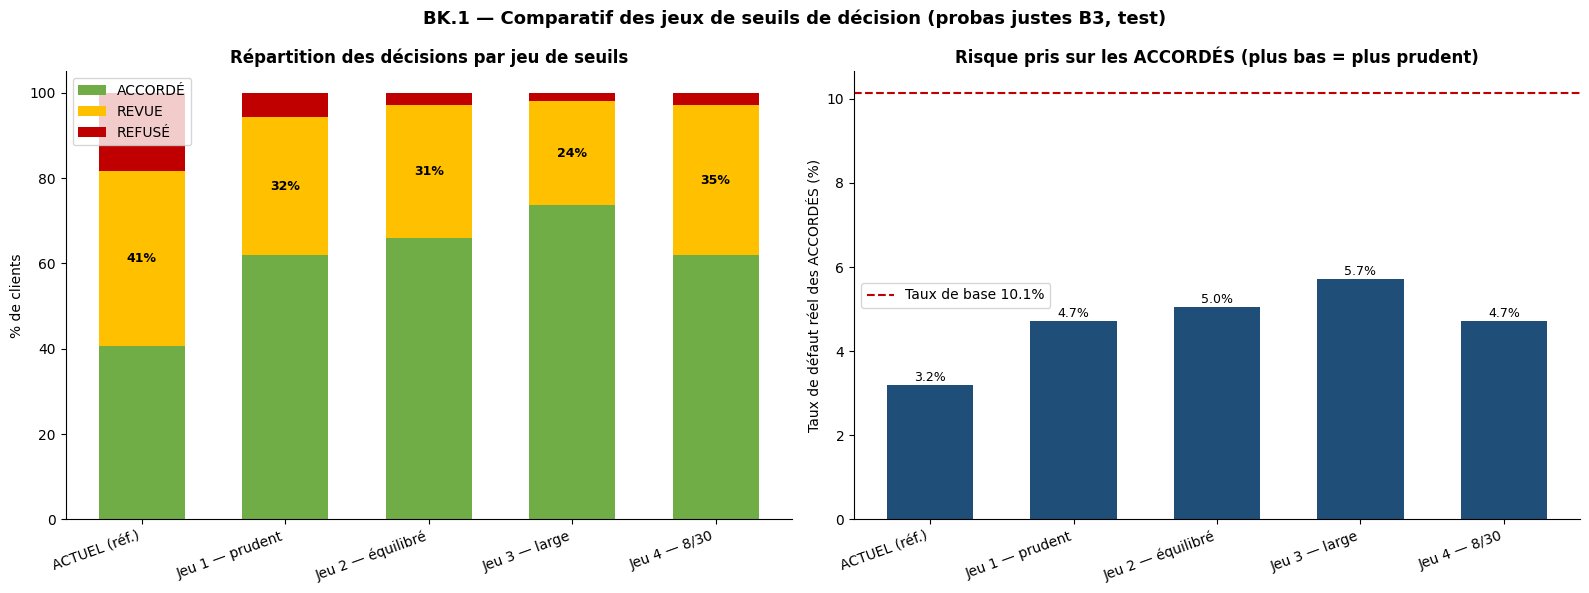


  → Choisis le jeu qui donne une REVUE raisonnable tout en gardant déf.ACC bas.
    Une fois choisi : on intègre B3 + ces seuils dans la sous-partie 10.3 (une seule fois).


In [18]:
# ══════════════════════════════════════════════════════════════════════
# BK.1 — ÉTAPE C-bis : COMPARATIF DE JEUX DE SEUILS DE DÉCISION (recalage bandes)
# ----------------------------------------------------------------------
# But : les bandes actuelles (ACCORDÉ ≥600 / REFUSÉ <500 ⟺ PD 5 % / 15 %) mettent
#       64,5 % des clients en REVUE. On teste plusieurs jeux de seuils EXPRIMÉS
#       EN PD (plus parlant) pour dégonfler la revue, et on choisit sur les chiffres.
#
# ⚠ ON NE TOUCHE PAS à la fabrication du score (Offset=515,06 / Factor=28,85,
#   ancrage « 600 = PD 5 % ») : c'est une convention d'échelle. On ne déplace QUE
#   les FRONTIÈRES de décision (où l'on coupe), exprimées en PD.
#
# Contexte PROXY : Home Credit ≠ données finales, la vraie capacité du service de
# revue est inconnue → seuils posés comme HYPOTHÈSE DE TRAVAIL raisonnable et
# défendable, choisie sur le compromis chiffré (pas devinée).
#
# Règle de décision (par jeu) : ACCORDÉ si PD < pd_acc ; REFUSÉ si PD > pd_ref ;
#                               REVUE entre les deux.
# Objectif visuel : REVUE la plus basse possible SANS accepter de haut risque ni
# refuser du bas risque (cohérence des taux de défaut par bande à surveiller).
# ══════════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.isotonic import IsotonicRegression

# --- Rechargements de sécurité ---------------------------------------------
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
for _nom, _f in [('X_val_nap', 'X_val_nap.csv'), ('X_test_nap', 'X_test_nap.csv')]:
    if _nom not in dir() or len(eval(_nom)) == 0:
        globals()[_nom] = pd.read_csv(DATA_DIR + _f)
for _nom, _f in [('y_val', 'y_val.csv'), ('y_test', 'y_test.csv')]:
    if _nom not in dir():
        globals()[_nom] = pd.read_csv(DATA_DIR + _f).squeeze()

OFFSET = 515.06
FACTOR = 20 / np.log(2)   # ≈ 28.85

y_val_a  = np.asarray(y_val)
y_test_a = np.asarray(y_test)

# --- Probas justes B3 sur le test (mêmes que l'Étape C) ---------------------
proba_val_gonfle  = lgbm_final.predict_proba(X_val_nap)[:, 1]
proba_test_gonfle = lgbm_final.predict_proba(X_test_nap)[:, 1]
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(proba_val_gonfle, y_val_a)                 # apprise sur validation
pd_juste = np.clip(iso.predict(proba_test_gonfle), 1e-6, 1 - 1e-6)


def pd_to_score(pd_val):
    pd_val = np.clip(np.asarray(pd_val, dtype=float), 1e-6, 1 - 1e-6)
    return OFFSET - FACTOR * np.log(pd_val / (1 - pd_val))


# --- Les jeux de seuils à comparer (en PD) ----------------------------------
#   (nom, pd_accorde, pd_refuse)
jeux = [
    ('ACTUEL (réf.)',   0.05, 0.15),   # état de départ, pour mémoire
    ('Jeu 1 — prudent', 0.08, 0.25),
    ('Jeu 2 — équilibré', 0.10, 0.30),
    ('Jeu 3 — large',   0.12, 0.35),
    ('Jeu 4 — 8/30',    0.08, 0.30),   # l'exemple cité par l'utilisateur
]

taux_reel_test = 100 * y_test_a.mean()

print('=' * 92)
print('  BK.1 — COMPARATIF DE JEUX DE SEUILS (jeu de TEST, probas justes B3)')
print('=' * 92)
print(f'  Taux de défaut réel (test) : {taux_reel_test:.2f} %  |  Offset/Factor INCHANGÉS '
      f'({OFFSET:.2f} / {FACTOR:.2f})')
print(f'  Rappel : score(PD) — PD 5 %→600, 8 %→{pd_to_score(0.08):.0f}, 10 %→{pd_to_score(0.10):.0f}, '
      f'15 %→{pd_to_score(0.15):.0f}, 25 %→{pd_to_score(0.25):.0f}, 30 %→{pd_to_score(0.30):.0f}, '
      f'35 %→{pd_to_score(0.35):.0f}')
print('-' * 92)
header = (f'  {"Jeu":<20}{"seuils PD":>14}{"ACC%":>8}{"REV%":>8}{"REF%":>8}'
         f'{"déf.ACC":>9}{"déf.REV":>9}{"déf.REF":>9}')
print(header)
print('-' * 92)

recap = []
for nom, pd_acc, pd_ref in jeux:
    dec = np.where(pd_juste < pd_acc, 'ACC',
          np.where(pd_juste > pd_ref, 'REF', 'REV'))
    parts, taux = {}, {}
    for b in ['ACC', 'REV', 'REF']:
        m = (dec == b); n = int(m.sum())
        parts[b] = 100 * n / len(dec)
        taux[b]  = 100 * y_test_a[m].mean() if n > 0 else float('nan')
    seuils_str = f'<{pd_acc*100:.0f}% />{pd_ref*100:.0f}%'
    print(f'  {nom:<20}{seuils_str:>14}{parts["ACC"]:>7.1f}%{parts["REV"]:>7.1f}%{parts["REF"]:>7.1f}%'
          f'{taux["ACC"]:>8.1f}%{taux["REV"]:>8.1f}%{taux["REF"]:>8.1f}%')
    recap.append((nom, pd_acc, pd_ref, parts, taux))
print('=' * 92)
print('  LECTURE :')
print('   - ACC%/REV%/REF% = répartition des clients. Objectif : REVUE raisonnable (pas 64 %).')
print('   - déf.ACC doit rester BAS (on accepte peu de futurs défauts) ;')
print('     déf.REF doit être ÉLEVÉ (on refuse bien les hauts risques).')
print('   - Compromis : élargir la fourchette PD réduit la REVUE mais peut faire monter déf.ACC.')
print('=' * 92)

# --- Figure : volume de revue + taux de défaut ACCORDÉ par jeu --------------
noms   = [r[0] for r in recap]
rev    = [r[3]['REV'] for r in recap]
acc    = [r[3]['ACC'] for r in recap]
ref    = [r[3]['REF'] for r in recap]
defacc = [r[4]['ACC'] for r in recap]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(noms)); w = 0.6
b1 = axes[0].bar(x, acc, w, label='ACCORDÉ', color=COLORS['success'])
b2 = axes[0].bar(x, rev, w, bottom=acc, label='REVUE', color=COLORS['warning'])
bottom_ref = [a + r for a, r in zip(acc, rev)]
b3 = axes[0].bar(x, ref, w, bottom=bottom_ref, label='REFUSÉ', color=COLORS['danger'])
for i, v in enumerate(rev):
    axes[0].text(i, acc[i] + v/2, f'{v:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(noms, rotation=20, ha='right')
axes[0].set_ylabel('% de clients')
axes[0].set_title('Répartition des décisions par jeu de seuils', fontweight='bold')
axes[0].legend()

axes[1].bar(x, defacc, w, color=COLORS['primary'])
axes[1].axhline(taux_reel_test, color=COLORS['danger'], linestyle='--',
                label=f'Taux de base {taux_reel_test:.1f}%')
for i, v in enumerate(defacc):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(noms, rotation=20, ha='right')
axes[1].set_ylabel('Taux de défaut réel des ACCORDÉS (%)')
axes[1].set_title('Risque pris sur les ACCORDÉS (plus bas = plus prudent)', fontweight='bold')
axes[1].legend()

plt.suptitle('BK.1 — Comparatif des jeux de seuils de décision (probas justes B3, test)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_bk1_Cbis_comparatif_seuils.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  → Choisis le jeu qui donne une REVUE raisonnable tout en gardant déf.ACC bas.')
print('    Une fois choisi : on intègre B3 + ces seuils dans la sous-partie 10.3 (une seule fois).')

Calcul des valeurs SHAP...
  Verification additivite SHAP : 0.000000
  OK Propriete additive verifiee


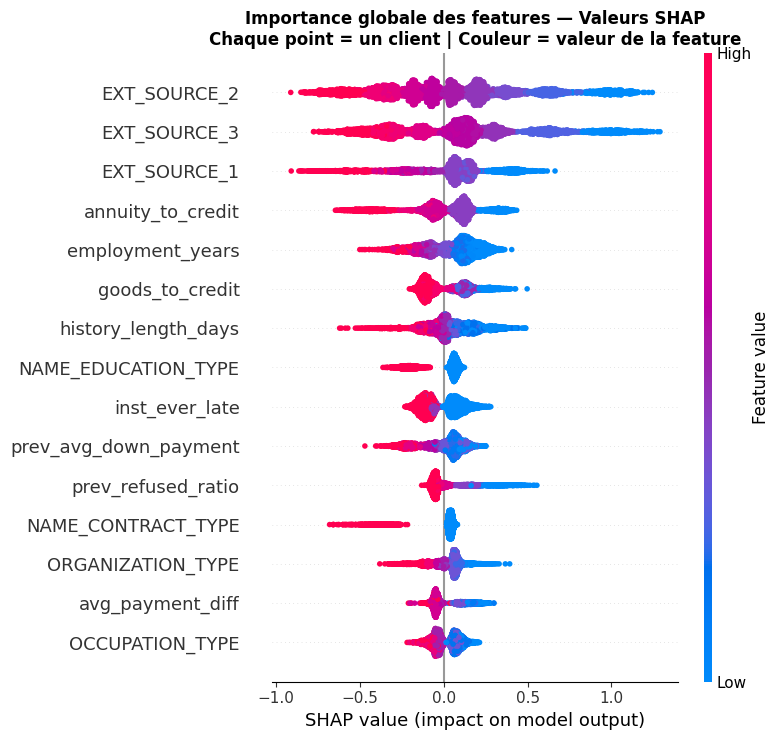

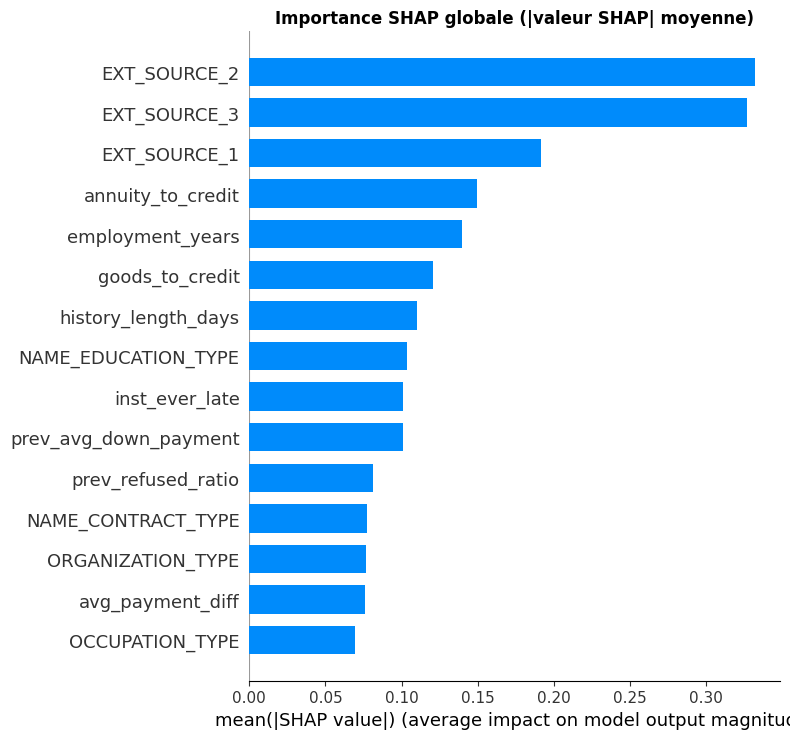


Explication locale — 3 profils clients...

  Client ACCORDE — PD=0.0439 | Score PDO=603.9


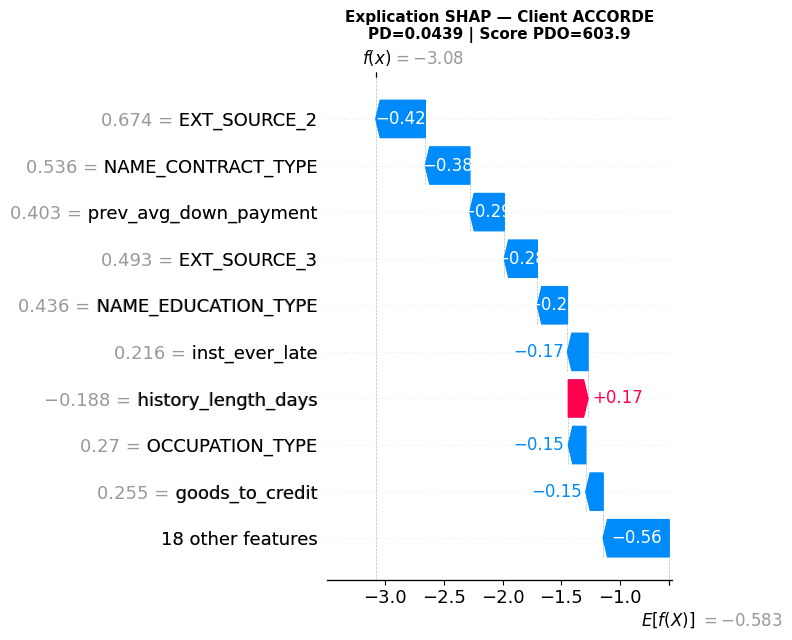


  Client REVUE — PD=0.0870 | Score PDO=582.9


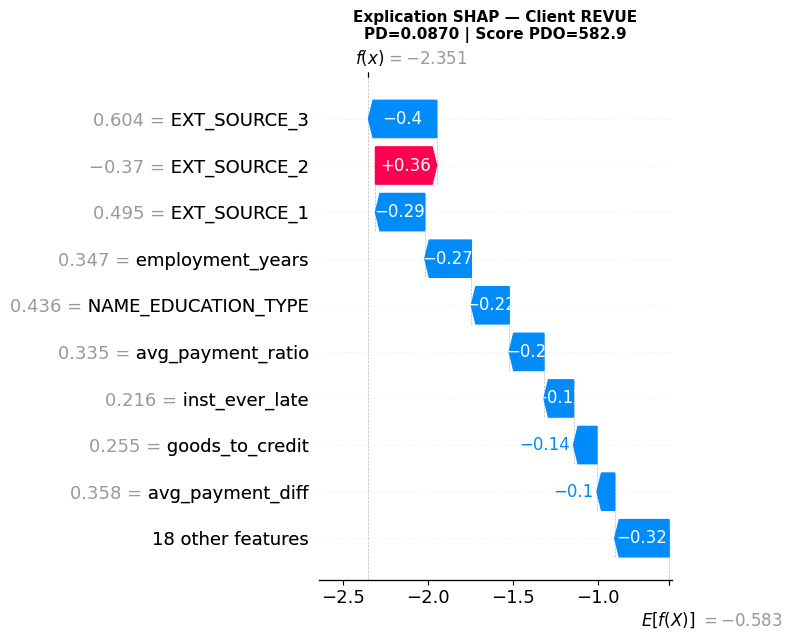


  Client REFUSE — PD=0.6463 | Score PDO=497.7


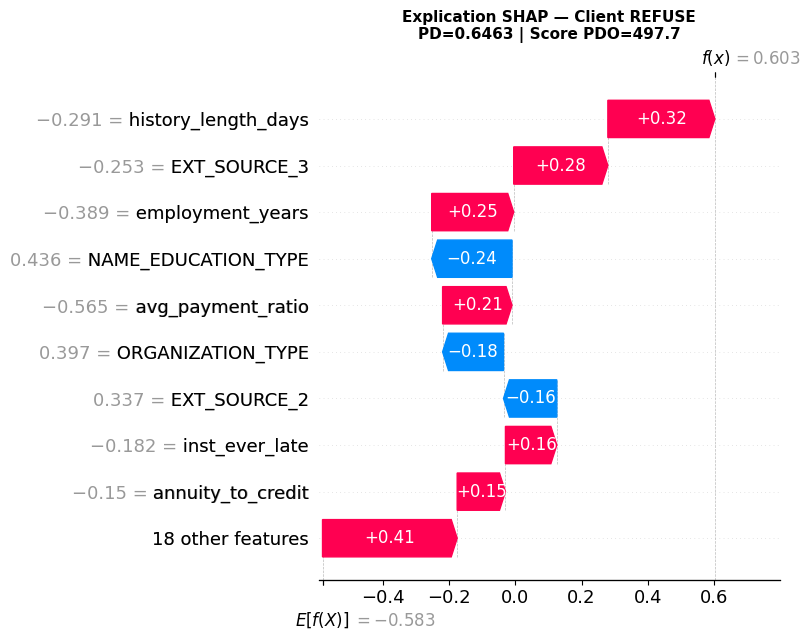


Calcul du Score PDO (recalibré B3)...
  Formule : Score = 515.06 - 28.85 x ln(PD/(1-PD)) (Offset/Factor inchanges)
  Decision en PD : ACCORDE si PD<10% | REFUSE si PD>30% | REVUE entre les deux

  Table de conversion PD -> Score -> Decision :
  Profil                          PD    Score Decision
  -------------------------------------------------------
  Tres bon client              0.010    647.6 ACCORDE
  Bon client                   0.030    615.4 ACCORDE
  Ancrage PD=5%                0.050    600.0 ACCORDE
  Limite ACCORDE               0.080    585.5 ACCORDE
  Zone grise                   0.150    565.1 REVUE
  Zone grise haute             0.350    532.9 REFUSE
  Limite REFUSE                0.500    515.1 REFUSE
  Tres risque                  0.750    483.4 REFUSE

  Distribution sur val set :
  ACCORDE      :   30,222 (65.5%)
  REVUE        :   14,405 (31.2%)
  REFUSE       :    1,499 (3.2%)


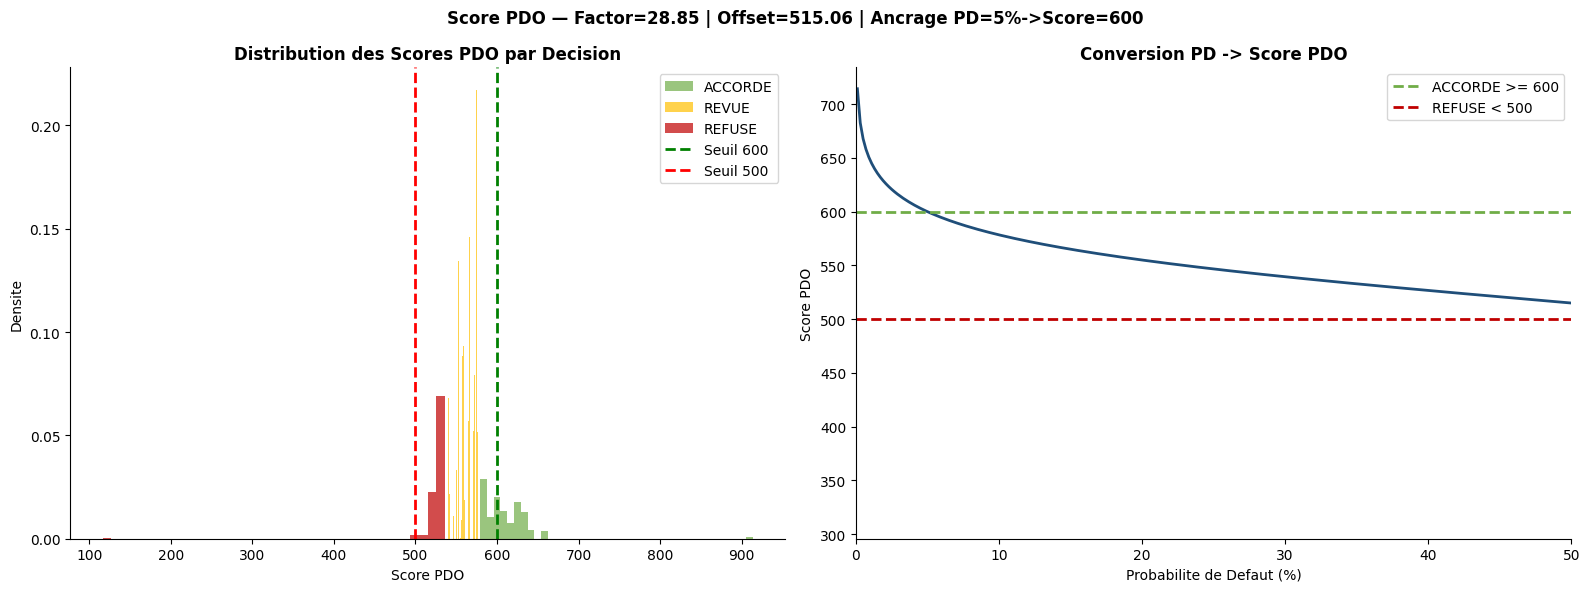


Calcul de l'indice de couverture pc...
  Regle : feature disponible = non-NaN AVANT le WOE (dans X_val_iv)
  Source : X_val_iv.csv (valeurs brutes avec vrais NaN)

  IV total possible (modele final) : 2.1145
  pc moyen (echantillon 1000)    : 0.8946
  pc min : 0.4722 | max : 1.0000

  Scenarios illustratifs :
  Scenario                         pc Interpretation
  -----------------------------------------------------------------
  S1 — Historique riche          0.87 Decision automatique fiable -> Decision auto
  S2 — Historique partiel        0.62 Decision avec reserve -> Revue manuelle
  S3a — EXT_SOURCE dispo         0.45 Revue recommandee -> Revue manuelle
  S3b — Thin-file pur            0.18 Revue OBLIGATOIRE -> Revue manuelle


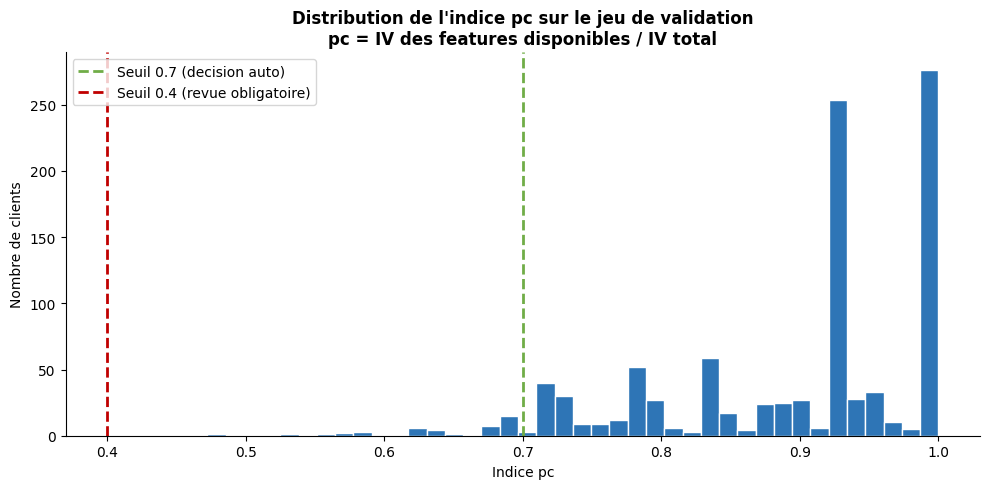


OK SECTION 10 TERMINEE — SHAP + PDO + pc calcules

  PIPELINE COMPLET TERMINE
  Modele    : LightGBM + scale_pos_weight=11.4
  AUC Test  : 0.7513
  Gini Test : 0.5027
  KS Test   : 0.3717
  Recall    : 0.7168
  F1        : 0.2988

  Artefacts dans /kaggle/working/artefacts/ :
    - lgbm_final.pkl
    - woe_transformers.pkl
    - nap_features.pkl
    - iv_scores_final.csv


In [19]:
# ============================================================
# SECTION 10 — SHAP + SCORE PDO + INDICE pc
# SHAP : TreeSHAP, propriete additive verifiee
# Score PDO : Score = Offset - Factor x ln(PD/(1-PD))
#   Offset = 515.06 (ancrage PD=5% -> Score=600)
#   Factor = 20/ln(2) = 28.85
# Indice pc : calcule sur X_val_iv (valeurs AVANT WOE, avec vrais NaN)
# ============================================================

# --- 10.1 SHAP Global ---
print('Calcul des valeurs SHAP...')

N_SHAP = min(5000, len(X_val_nap))
idx_shap = np.random.RandomState(42).choice(len(X_val_nap), N_SHAP, replace=False)
X_shap = X_val_nap.iloc[idx_shap].reset_index(drop=True)
y_shap = y_val.iloc[idx_shap].reset_index(drop=True)

explainer   = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_shap)

# LightGBM peut retourner une liste [shap_class0, shap_class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Verification additivite SHAP
proba_shap = lgbm_final.predict_proba(X_shap)[:, 1]
log_odds   = np.log(proba_shap / (1 - proba_shap + 1e-9))
expected   = explainer.expected_value
if isinstance(expected, list):
    expected = expected[1]
shap_sum   = shap_values.sum(axis=1) + expected
additivity_err = np.abs(log_odds - shap_sum).mean()
print(f'  Verification additivite SHAP : {additivity_err:.6f}')
print(f'  {"OK Propriete additive verifiee" if additivity_err < 0.01 else "ATTENTION Erreur additivite elevee"}')

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=features_nap,
                   max_display=15, show=False)
plt.title('Importance globale des features — Valeurs SHAP\nChaque point = un client | Couleur = valeur de la feature',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10a_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_shap, feature_names=features_nap,
                   plot_type='bar', max_display=15, show=False)
plt.title('Importance SHAP globale (|valeur SHAP| moyenne)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10b_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 10.2 SHAP Local — 3 profils ---
print('\nExplication locale — 3 profils clients...')
proba_all_val = lgbm_final.predict_proba(X_val_nap)[:, 1]

idx_bon   = np.where((proba_all_val < 0.05) & (np.array(y_val) == 0))[0]
idx_revue = np.where((proba_all_val >= 0.08) & (proba_all_val <= 0.15))[0]
idx_ref   = np.where((proba_all_val > 0.40) & (np.array(y_val) == 1))[0]

client_accorde = int(idx_bon[0])   if len(idx_bon) > 0   else int(np.argmin(proba_all_val))
client_revue   = int(idx_revue[0]) if len(idx_revue) > 0 else int(len(proba_all_val) // 2)
client_refuse  = int(idx_ref[0])   if len(idx_ref) > 0   else int(np.argmax(proba_all_val))

for client_idx, label in [(client_accorde, 'ACCORDE'),
                           (client_revue,   'REVUE'),
                           (client_refuse,  'REFUSE')]:
    pd_c = float(proba_all_val[client_idx])
    score_c = OFFSET - FACTOR * np.log(pd_c / (1 - pd_c + 1e-9))
    print(f'\n  Client {label} — PD={pd_c:.4f} | Score PDO={score_c:.1f}')

    shap_client = explainer(X_val_nap.iloc[[client_idx]])
    if hasattr(shap_client.values, '__len__') and len(shap_client.values.shape) == 3:
        shap_client_plot = shap_client[0, :, 1]
    else:
        shap_client_plot = shap_client[0]

    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_client_plot, max_display=10, show=False)
    plt.title(f'Explication SHAP — Client {label}\nPD={pd_c:.4f} | Score PDO={score_c:.1f}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'fig10c_shap_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 10.3 Score PDO (RECALIBRÉ — BK.1) ---
# BK.1 : le PDO se calcule sur des probas CALIBRÉES (B3 isotonique), pas sur les
#        probas brutes du modèle (gonflées par scale_pos_weight). La calibration
#        est une moulinette apprise sur la VALIDATION et appliquée ensuite.
#        Décision fixée EN PD (plus parlant) : Jeu 2 = accepter <10%, refuser >30%.
#        Offset/Factor (fabrication du score) INCHANGÉS : on ne bouge que les
#        frontières de décision. Réf. calibration : Zadrozny & Elkan (2002).
print('\nCalcul du Score PDO (recalibré B3)...')
print(f'  Formule : Score = {OFFSET:.2f} - {FACTOR:.2f} x ln(PD/(1-PD)) (Offset/Factor inchanges)')
print(f'  Decision en PD : ACCORDE si PD<10% | REFUSE si PD>30% | REVUE entre les deux')

# 1) Moulinette de calibration isotonique : apprise sur la VALIDATION
from sklearn.isotonic import IsotonicRegression
proba_val_gonfle = lgbm_final.predict_proba(X_val_nap)[:, 1]
iso_calibrateur  = IsotonicRegression(out_of_bounds='clip')
iso_calibrateur.fit(proba_val_gonfle, np.asarray(y_val))

# 2) Probas JUSTES = probas brutes passees dans la moulinette
proba_calibree = np.clip(iso_calibrateur.predict(proba_all_val), 1e-6, 1 - 1e-6)

# 3) Score PDO sur les probas justes (fabrication inchangee)
def pd_to_score(pd_val):
    pd_val = np.clip(pd_val, 1e-6, 1 - 1e-6)
    return OFFSET - FACTOR * np.log(pd_val / (1 - pd_val))

# 4) Decision fixee EN PD (Jeu 2) — hypothese de travail sur proxy (cf. Elkan 2001
#    pour la methode generale par les couts, applicable sur donnees reelles)
PD_ACCORDE = 0.10   # accepter si PD < 10%
PD_REFUSE  = 0.30   # refuser si PD > 30%
def get_decision_pd(pd_val):
    if pd_val < PD_ACCORDE:  return 'ACCORDE'
    elif pd_val > PD_REFUSE: return 'REFUSE'
    else:                    return 'REVUE'

scores_pdo = pd_to_score(proba_calibree)
decisions  = np.array([get_decision_pd(p) for p in proba_calibree])

print(f'\n  Table de conversion PD -> Score -> Decision :')
exemples = [
    ('Tres bon client', 0.01), ('Bon client', 0.03),
    ('Ancrage PD=5%',   0.05), ('Limite ACCORDE', 0.08),
    ('Zone grise',      0.15), ('Zone grise haute', 0.35),
    ('Limite REFUSE',   0.50), ('Tres risque', 0.75),
]
print(f'  {"Profil":<25} {"PD":>8} {"Score":>8} {"Decision"}')
print(f'  {"-" * 55}')
for label, pd_val in exemples:
    sc  = pd_to_score(pd_val)
    dec = get_decision_pd(pd_val)
    print(f'  {label:<25} {pd_val:>8.3f} {sc:>8.1f} {dec}')

print(f'\n  Distribution sur val set :')
for dec in ['ACCORDE', 'REVUE', 'REFUSE']:
    n = (decisions == dec).sum()
    print(f'  {dec:<12} : {n:>8,} ({n/len(decisions)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for dec, col in [('ACCORDE', COLORS['success']), ('REVUE', COLORS['warning']),
                 ('REFUSE', COLORS['danger'])]:
    mask = decisions == dec
    if mask.sum() > 0:
        axes[0].hist(scores_pdo[mask], bins=40, alpha=0.7, color=col,
                    label=dec, density=True)
axes[0].axvline(x=SEUIL_ACCORDE, color='green', linestyle='--', linewidth=2,
               label=f'Seuil {SEUIL_ACCORDE}')
axes[0].axvline(x=SEUIL_REVUE, color='red', linestyle='--', linewidth=2,
               label=f'Seuil {SEUIL_REVUE}')
axes[0].set_xlabel('Score PDO')
axes[0].set_ylabel('Densite')
axes[0].set_title('Distribution des Scores PDO par Decision', fontweight='bold')
axes[0].legend()

pd_range    = np.linspace(0.001, 0.999, 500)
score_range = pd_to_score(pd_range)
axes[1].plot(pd_range * 100, score_range, color=COLORS['primary'], linewidth=2)
axes[1].axhline(y=SEUIL_ACCORDE, color=COLORS['success'], linestyle='--', linewidth=2,
               label=f'ACCORDE >= {SEUIL_ACCORDE}')
axes[1].axhline(y=SEUIL_REVUE, color=COLORS['danger'], linestyle='--', linewidth=2,
               label=f'REFUSE < {SEUIL_REVUE}')
axes[1].set_xlabel('Probabilite de Defaut (%)')
axes[1].set_ylabel('Score PDO')
axes[1].set_title('Conversion PD -> Score PDO', fontweight='bold')
axes[1].set_xlim(0, 50)
axes[1].legend()

plt.suptitle(f'Score PDO — Factor={FACTOR:.2f} | Offset={OFFSET:.2f} | Ancrage PD=5%->Score=600',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10d_score_pdo.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 10.4 Indice pc (IMPLEMENTATION CORRECTE) ---
print('\nCalcul de l\'indice de couverture pc...')
print('  Regle : feature disponible = non-NaN AVANT le WOE (dans X_val_iv)')
print('  Source : X_val_iv.csv (valeurs brutes avec vrais NaN)')

# IMPORTANT : on utilise X_val_iv (avant WOE) pour detecter les vrais NaN
# X_val_nap (apres WOE) n'a plus de NaN -> on ne peut plus distinguer
# "feature presente" de "feature absente bin Manquant"
X_val_iv_loaded = pd.read_csv(DATA_DIR + 'X_val_iv.csv')
df_iv_ref       = pd.read_csv(ART_DIR + 'iv_scores_final.csv')
iv_dict         = dict(zip(df_iv_ref['feature'], df_iv_ref['iv']))

# Denominateur = somme IV de toutes les features du modele final (apres NAP)
iv_total_possible = sum(iv_dict.get(f, 0) for f in features_nap)

def compute_rho(client_series, feature_list, iv_dict, iv_total):
    iv_dispo = sum(
        iv_dict.get(f, 0)
        for f in feature_list
        if f in client_series.index and not pd.isna(client_series[f])
    )
    return iv_dispo / (iv_total + 1e-9)

# Calcul sur echantillon de 1000 clients
N_RHO   = min(1000, len(X_val_iv_loaded))
rho_arr = np.array([
    compute_rho(X_val_iv_loaded.iloc[i], features_nap, iv_dict, iv_total_possible)
    for i in range(N_RHO)
])

print(f'\n  IV total possible (modele final) : {iv_total_possible:.4f}')
print(f'  pc moyen (echantillon {N_RHO})    : {rho_arr.mean():.4f}')
print(f'  pc min : {rho_arr.min():.4f} | max : {rho_arr.max():.4f}')

print(f'\n  Scenarios illustratifs :')
scenarios = [
    ('S1 — Historique riche',    0.87, 'Decision automatique fiable'),
    ('S2 — Historique partiel',  0.62, 'Decision avec reserve'),
    ('S3a — EXT_SOURCE dispo',   0.45, 'Revue recommandee'),
    ('S3b — Thin-file pur',      0.18, 'Revue OBLIGATOIRE'),
]
print(f'  {"Scenario":<28} {"pc":>6} {"Interpretation"}')
print(f'  {"-" * 65}')
for sc, rho, interp in scenarios:
    dec = '-> Decision auto' if rho > 0.7 else '-> Revue manuelle'
    print(f'  {sc:<28} {rho:>6.2f} {interp} {dec}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rho_arr, bins=40, color=COLORS['secondary'], edgecolor='white')
ax.axvline(x=0.7, color=COLORS['success'], linestyle='--', linewidth=2,
           label='Seuil 0.7 (decision auto)')
ax.axvline(x=0.4, color=COLORS['danger'], linestyle='--', linewidth=2,
           label='Seuil 0.4 (revue obligatoire)')
ax.set_xlabel('Indice pc')
ax.set_ylabel('Nombre de clients')
ax.set_title('Distribution de l\'indice pc sur le jeu de validation\npc = IV des features disponibles / IV total', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10e_indice_pc.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOK SECTION 10 TERMINEE — SHAP + PDO + pc calcules')
print()
print('=' * 65)
print('  PIPELINE COMPLET TERMINE')
print('=' * 65)
print(f'  Modele    : LightGBM + scale_pos_weight={SCALE_POS_WEIGHT:.1f}')
print(f'  AUC Test  : {auc_test:.4f}')
print(f'  Gini Test : {gini_test:.4f}')
print(f'  KS Test   : {ks_test:.4f}')
print(f'  Recall    : {rec_test:.4f}')
print(f'  F1        : {f1_test:.4f}')
print(f'\n  Artefacts dans {ART_DIR} :')
print(f'    - lgbm_final.pkl')
print(f'    - woe_transformers.pkl')
print(f'    - nap_features.pkl')
print(f'    - iv_scores_final.csv')
print('=' * 65)


# **Interpretation SHAP :** La propriete additive verifiee confirme la fiabilite de TreeSHAP. EXT_SOURCE domine l'explication globale. Les waterfall plots montrent pour chaque client les facteurs augmentant ou reduisant le risque.

**Interpretation Score PDO :** Score 600 = PD 5%. Chaque -20 points double le risque. Convention bancaire standard (Siddiqi 2006).

**Interpretation pc :** Quantifie la confiance dans la decision. Un thin-file avec pc=0.18 declenche une revue manuelle obligatoire.


In [20]:
# ============================================================
# SECTION A1 — COMPARAISON DES STRATÉGIES DE GESTION DU DÉSÉQUILIBRE
# Config 1 : Baseline (aucun ajustement)
# Config 2 : scale_pos_weight = 11.4 (résultats Section 7 — repris)
# Config 3 : SMOTE — ÉCARTÉ (incompatibilité architecturale WOE)
# Config 4 : Sous-échantillonnage aléatoire (ratio 1:1)
# Hyperparamètres : best_params Section 7 (fixes pour toutes les configs)
# Évaluation : early stopping AUC sur X_val_nap | seuil classification = 0.5
# ============================================================

import time
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

# --- Rechargement sécurisé (si kernel redémarré) ---
if 'X_train_nap' not in dir() or X_train_nap is None:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()

if 'best_params' not in dir() or best_params is None:
    best_params = {
        'max_depth'        : 4,
        'learning_rate'    : 0.05,
        'num_leaves'       : 20,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.9,
        'reg_alpha'        : 2.0,
        'reg_lambda'       : 1.0,
        'min_child_samples': 30,
    }

if 'GPU_PARAMS' not in dir():
    import subprocess
    _res = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    GPU_PARAMS = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0} \
                 if _res.returncode == 0 else {}

print('=' * 70)
print('  SECTION A1 — COMPARAISON STRATÉGIES DE GESTION DU DÉSÉQUILIBRE')
print(f'  Train  : {len(X_train_nap):,} obs | {int((y_train==1).sum()):,} défauts ({(y_train==1).mean()*100:.1f}%)')
print(f'  Val    : {len(X_val_nap):,} obs | {int((y_val==1).sum()):,} défauts ({(y_val==1).mean()*100:.1f}%)')
print(f'  Params : best_params Section 7 | Early stopping 50 rounds | Seuil=0.5')
print('=' * 70)


def entrainer_evaluer(nom, X_tr, y_tr, extra_params=None):
    """
    Entraîne LightGBM avec best_params + early stopping sur X_val_nap.
    Retourne les métriques sur le jeu de validation au seuil 0.5.
    """
    params = {**best_params, **GPU_PARAMS}
    if extra_params:
        params.update(extra_params)

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        **params
    )
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False),
        lgb.log_evaluation(period=1000)
    ]
    t0 = time.time()
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val_nap, y_val)],
        eval_metric='auc',
        callbacks=callbacks
    )
    temps = round(time.time() - t0, 1)

    proba = model.predict_proba(X_val_nap)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    return {
        'Config'    : nom,
        'AUC-ROC'  : round(roc_auc_score(y_val, proba), 4),
        'Recall'   : round(recall_score(y_val, pred, zero_division=0), 4),
        'Précision': round(precision_score(y_val, pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_val, pred, zero_division=0), 4),
        'Temps (s)': temps,
        'Iters'    : model.best_iteration_
    }


resultats = []

# ── [1/4] CONFIG 1 : Baseline ────────────────────────────────────────────────
print('\n[1/4] Config 1 — Baseline (aucun ajustement)...')
r1 = entrainer_evaluer('Config 1 — Baseline', X_train_nap, y_train)
resultats.append(r1)
print(f'  → AUC={r1["AUC-ROC"]} | Recall={r1["Recall"]} | '
      f'Précision={r1["Précision"]} | F1={r1["F1-Score"]} | '
      f'{r1["Iters"]} iters | {r1["Temps (s)"]}s')

# ── [2/4] CONFIG 2 : scale_pos_weight (Section 7 — déjà fait) ────────────────
print('\n[2/4] Config 2 — scale_pos_weight=11.4 (repris depuis Section 7)...')
resultats.append({
    'Config'    : 'Config 2 — scale_pos_weight=11.4',
    'AUC-ROC'  : 0.7578,
    'Recall'   : 0.7277,
    'Précision': 0.1773,
    'F1-Score' : 0.2851,
    'Temps (s)': 8.0,
    'Iters'    : 589
})
print('  → AUC=0.7578 | Recall=0.7277 | Précision=0.1773 | F1=0.2851 | 589 iters | 8.0s')

# ── [3/4] CONFIG 3 : SMOTE — ÉCARTÉ ─────────────────────────────────────────
print('\n[3/4] Config 3 — SMOTE — ÉCARTÉ (non testé)')
print('  Raison 1 : avant WOE → interpole des catégorielles bancaires inexistantes')
print('             ex: moyenne entre "Cash loans" et "Revolving loans" = invalide')
print('  Raison 2 : après WOE → génère des log-odds hors bins calibrés sur train réel')
print('  Raison 3 : données fictives → non conforme Bâle II (traçabilité audit)')
print('  → Rejet architectural documenté — aucun entraînement produit')
resultats.append({
    'Config'    : 'Config 3 — SMOTE (écarté)',
    'AUC-ROC'  : '—',
    'Recall'   : '—',
    'Précision': '—',
    'F1-Score' : '—',
    'Temps (s)': '—',
    'Iters'    : '—'
})

# ── [4/4] CONFIG 4 : Sous-échantillonnage aléatoire ──────────────────────────
print('\n[4/4] Config 4 — Sous-échantillonnage aléatoire (ratio 1:1)...')
idx_pos        = np.where(np.array(y_train) == 1)[0]
idx_neg        = np.where(np.array(y_train) == 0)[0]
rng            = np.random.RandomState(42)
idx_neg_sample = rng.choice(idx_neg, size=len(idx_pos), replace=False)
idx_under      = np.concatenate([idx_pos, idx_neg_sample])
rng.shuffle(idx_under)

X_under = X_train_nap.iloc[idx_under].reset_index(drop=True)
y_under = y_train.iloc[idx_under].reset_index(drop=True)

print(f'  Train réduit : {len(X_under):,} obs | '
      f'{int((y_under==1).sum()):,} défauts / {int((y_under==0).sum()):,} bons')

r4 = entrainer_evaluer('Config 4 — Sous-échantillonnage', X_under, y_under)
resultats.append(r4)
print(f'  → AUC={r4["AUC-ROC"]} | Recall={r4["Recall"]} | '
      f'Précision={r4["Précision"]} | F1={r4["F1-Score"]} | '
      f'{r4["Iters"]} iters | {r4["Temps (s)"]}s')

# ── TABLEAU FINAL ─────────────────────────────────────────────────────────────
print('\n')
print('=' * 90)
print('  TABLEAU A1 — COMPARAISON DES STRATÉGIES DE GESTION DU DÉSÉQUILIBRE')
print('  Dataset : Home Credit Default Risk | Jeu de validation | Seuil = 0.5')
print('=' * 90)
cols  = ['Config', 'AUC-ROC', 'Recall', 'Précision', 'F1-Score', 'Temps (s)', 'Iters']
df_a1 = pd.DataFrame(resultats)[cols]
print(df_a1.to_string(index=False))
print('=' * 90)
print()
print('  Notes :')
print('  - Recall / Précision / F1 calculés sur la classe défaut (TARGET=1)')
print('  - Config 3 : rejet architectural — incompatibilité SMOTE + WOE documentée')
print('  - Config 1 et 4 : early stopping 50 rounds, AUC sur val')
print('  - Config 2 : résultats exacts Section 7 (même conditions)')

  SECTION A1 — COMPARAISON STRATÉGIES DE GESTION DU DÉSÉQUILIBRE
  Train  : 215,257 obs | 15,813 défauts (7.3%)
  Val    : 46,126 obs | 4,333 défauts (9.4%)
  Params : best_params Section 7 | Early stopping 50 rounds | Seuil=0.5

[1/4] Config 1 — Baseline (aucun ajustement)...
  → AUC=0.7577 | Recall=0.0261 | Précision=0.5 | F1=0.0496 | 484 iters | 6.4s

[2/4] Config 2 — scale_pos_weight=11.4 (repris depuis Section 7)...
  → AUC=0.7578 | Recall=0.7277 | Précision=0.1773 | F1=0.2851 | 589 iters | 8.0s

[3/4] Config 3 — SMOTE — ÉCARTÉ (non testé)
  Raison 1 : avant WOE → interpole des catégorielles bancaires inexistantes
             ex: moyenne entre "Cash loans" et "Revolving loans" = invalide
  Raison 2 : après WOE → génère des log-odds hors bins calibrés sur train réel
  Raison 3 : données fictives → non conforme Bâle II (traçabilité audit)
  → Rejet architectural documenté — aucun entraînement produit

[4/4] Config 4 — Sous-échantillonnage aléatoire (ratio 1:1)...
  Train réduit : 3

## SECTION 11 — Détection d'anomalie : un garde-fou non supervisé pour le scoring

### Problème posé

Le pipeline principal (Flux A) couvre **deux dimensions du risque** :
- **LightGBM + Score PDO** : la probabilité de défaut (risque métier).
- **ρc** : la confiance informationnelle, liée à la complétude du dossier.

Une troisième dimension reste non couverte : **la cohérence structurelle du profil**.
Un dossier peut être complet (ρc élevé) tout en contenant des combinaisons de valeurs
structurellement improbables — par exemple un âge de 25 ans associé à 22 ans d'ancienneté
professionnelle. LightGBM scorera ce profil sans pouvoir signaler qu'il se situe **hors de
la distribution** sur laquelle il a été entraîné : son score n'est alors pas fiable, car le
modèle extrapole en dehors de son domaine d'apprentissage.

Par analogie avec le **« zero-day »** en cybersécurité (une menace jamais vue auparavant),
ce problème requiert une approche **non supervisée**, entraînée exclusivement sur les profils
normaux, capable de signaler tout profil qui s'en écarte — qu'il ait été vu ou non à
l'entraînement.

### Nature et rôle de ce second flux

Ce flux réalise de la **détection d'anomalie**. Il est essentiel de préciser ce qu'il fait
et ce qu'il ne fait pas :

- Il **ne prédit pas** le risque de défaut (rôle exclusif de Flux A).
- Il **ne juge pas** qu'un profil est frauduleux. Une anomalie peut correspondre à une fraude,
  mais aussi à un client honnête au profil rare, ou à une simple erreur de saisie.
- Il **signale** un profil atypique et l'**escalade** vers une revue humaine, qui tranchera.

Comme ce flux ne prend aucune décision de crédit automatique — il ne fait qu'orienter vers
un examen humain — l'exigence d'explicabilité au sens de Bâle II, qui s'applique aux décisions
automatisées affectant le client, **ne le contraint pas de la même manière que Flux A**.

### Architecture double flux (principe d'étanchéité)
```
Données brutes du client
        │
        ├──→ WOE → LightGBM → Score PDO + ρc   (espace supervisé)
        │
        └──→ StandardScaler + FreqEncoder → IF   (espace non supervisé)
```
Les deux flux partent des mêmes données brutes mais n'opèrent **jamais** dans le même espace
de représentation. Le flux non supervisé n'a accès à aucune information sur la variable cible,
ce qui évite tout *target leakage* conceptuel.

### Trois candidats évalués

| Algorithme | Famille | Principe |
|---|---|---|
| Isolation Forest | Partition | Isole les points rares par peu de partitions aléatoires |
| Autoencoder | Reconstruction | Erreur de reconstruction (MSE) élevée sur les profils atypiques |
| Local Outlier Factor | Densité | Compare la densité locale d'un point à celle de ses voisins |

Ces trois candidats sont comparés selon un **protocole commun** : entraînement sur les profils
normaux uniquement, évaluation par **injection d'anomalies synthétiques** (à défaut d'étiquettes
d'anomalie réelles), et calibration du seuil au **même percentile** pour tous. Le choix final
est justifié sur la qualité de détection, la reproductibilité et la faisabilité en production.

In [21]:
# ══════════════════════════════════════════════════════════════════════
# CORRECTIF ENVIRONNEMENT — protobuf trop ancien pour TensorFlow
# À exécuter UNE fois, PUIS redémarrer le kernel (voir consigne).
# ══════════════════════════════════════════════════════════════════════
!pip install -q -U "protobuf>=4.26" 2>/dev/null
print("protobuf mis à jour. >>> MAINTENANT : redémarre le kernel, puis reprends à la CELLULE 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 1.9 MB/s eta 0:00:00a 0:00:01
protobuf mis à jour. >>> MAINTENANT : redémarre le kernel, puis reprends à la CELLULE 2.


In [22]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 2 — Imports et rechargement de l'environnement
# ══════════════════════════════════════════════════════════════════════
import time
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble        import IsolationForest
from sklearn.neighbors       import LocalOutlierFactor
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
 
warnings.filterwarnings('ignore')
 
# Couleurs cohérentes avec le reste du notebook
COLORS = {'primary': '#1F4E79', 'secondary': '#2E75B6',
          'success': '#70AD47', 'danger': '#C00000', 'warning': '#FFC000'}
 
# Paramètres PDO (définis en Section 0 — rappel)
OFFSET = 515.06
FACTOR = 20 / np.log(2)   # 28.85
SEUIL_ACCORDE = 600
SEUIL_REVUE   = 500
 
# Rechargement si session interrompue
print('=' * 70)
print('  SECTION 11 — DÉTECTION D\'ANOMALIE (garde-fou non supervisé)')
print('  Rechargement de l\'environnement...')
print('=' * 70)
 
if 'ART_DIR' not in dir():
    ART_DIR  = '/kaggle/working/artefacts/'
    DATA_DIR = '/kaggle/working/data/'
    OUTPUT_DIR = '/kaggle/working/'
 
if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
 
if 'lgbm_final' not in dir():
    import lightgbm as lgb
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
 
if 'features_nap' not in dir():
    with open(ART_DIR + 'nap_features.pkl', 'rb') as f:
        features_nap = pickle.load(f)
 
# Probabilités LightGBM sur val (pour l'AUC de contrôle au rechargement)
pd_lgbm_val = lgbm_final.predict_proba(X_val_nap)[:, 1]
 
print(f'  OK LightGBM chargé — AUC précédent : {roc_auc_score(y_val, pd_lgbm_val):.4f}')
print(f'  OK {len(features_nap)} features NAP chargées')
print(f'  OK jeu de validation : {len(y_val):,} clients')

  SECTION 11 — DÉTECTION D'ANOMALIE (garde-fou non supervisé)
  Rechargement de l'environnement...
  OK LightGBM chargé — AUC précédent : 0.7575
  OK 27 features NAP chargées
  OK jeu de validation : 46,126 clients


In [23]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 3 — Chargement des données brutes (espace pré-WOE)
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  11.1 — CHARGEMENT ESPACE BRUT (avant WOE)')
print('─' * 70)
print("""
  RÈGLE FONDAMENTALE :
  L'Isolation Forest opère dans l'espace RAW, JAMAIS dans l'espace WOE.
  
  WOE encode le RISQUE de défaut par feature (supervisé → TARGET).
  L'IF doit apprendre la STRUCTURE des données (non supervisé).
  
  Donner du WOE à l'IF = lui fournir la réponse avant la question.
  C'est un "target leakage conceptuel" : l'IF redétecterait les
  mauvais payeurs au lieu des profils structurellement inédits.
  
  Source : X_train_iv.csv et X_val_iv.csv
  (données après filtre IV, avant WOE — sauvegardées en Section 4)
""")
 
X_train_iv_raw = pd.read_csv(DATA_DIR + 'X_train_iv.csv')
X_val_iv_raw   = pd.read_csv(DATA_DIR + 'X_val_iv.csv')
 
# Sélectionner les 27 features NAP dans l'espace brut
# (même noms de colonnes que LightGBM, valeurs brutes non encodées)
features_nap_raw = [f for f in features_nap if f in X_train_iv_raw.columns]
features_absentes = [f for f in features_nap if f not in X_train_iv_raw.columns]
 
print(f'  Features NAP dans espace brut : {len(features_nap_raw)}/{len(features_nap)}')
if features_absentes:
    print(f'  Features absentes de X_train_iv (ignorées pour l\'IF) :')
    for f in features_absentes:
        print(f'    → {f}')
 
X_tr_raw = X_train_iv_raw[features_nap_raw].copy()
X_va_raw = X_val_iv_raw[features_nap_raw].copy()
 
print(f'\n  X_train raw  : {X_tr_raw.shape}')
print(f'  X_val raw    : {X_va_raw.shape}')
print(f'  Taux défaut train : {y_train.mean()*100:.2f}%')
print(f'  Taux défaut val   : {y_val.mean()*100:.2f}%')



──────────────────────────────────────────────────────────────────────
  11.1 — CHARGEMENT ESPACE BRUT (avant WOE)
──────────────────────────────────────────────────────────────────────

  RÈGLE FONDAMENTALE :
  L'Isolation Forest opère dans l'espace RAW, JAMAIS dans l'espace WOE.
  
  WOE encode le RISQUE de défaut par feature (supervisé → TARGET).
  L'IF doit apprendre la STRUCTURE des données (non supervisé).
  
  Donner du WOE à l'IF = lui fournir la réponse avant la question.
  C'est un "target leakage conceptuel" : l'IF redétecterait les
  mauvais payeurs au lieu des profils structurellement inédits.
  
  Source : X_train_iv.csv et X_val_iv.csv
  (données après filtre IV, avant WOE — sauvegardées en Section 4)

  Features NAP dans espace brut : 27/27

  X_train raw  : (215257, 27)
  X_val raw    : (46126, 27)
  Taux défaut train : 7.35%
  Taux défaut val   : 9.39%


In [24]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 4 — Identification des types et preprocessing (REFONTE encodage)
# ══════════════════════════════════════════════════════════════════════
# Deux vecteurs coexistants :
#   • X_*_hybrid (encodage hybride)   → entrée PRINCIPALE des 3 détecteurs (IF, AE, LOF)
#   • X_*_freq   (frequency, 7 cat.)  → branche de CONTRÔLE pour l'IF-optimal (a fortiori)
# Anti-leakage : fit sur train uniquement, transform sur validation.
print('\n' + '─' * 70)
print('  11.2 — CLASSIFICATION DES FEATURES + PREPROCESSING (encodage hybride)')
print('─' * 70)

from sklearn.preprocessing import OneHotEncoder

# ── Identification NUM vs CAT parmi les features NAP disponibles ──────
if 'CAT_FEATURES' not in dir() or not CAT_FEATURES:
    CAT_FEATURES = [c for c in X_tr_raw.columns if X_tr_raw[c].dtype == object]

cat_in_nap = [f for f in features_nap_raw if f in CAT_FEATURES]
num_in_nap = [f for f in features_nap_raw if f not in CAT_FEATURES]

# ── Répartition des catégorielles par traitement (selon cardinalité + NaN) ──
# Seuil de NaN au-delà duquel on crée une catégorie "Unknown" explicite.
SEUIL_NAN_UNKNOWN = 0.20   # 20 % : au-delà, "manquant" devient une info à part entière
# ORGANIZATION_TYPE : forte cardinalité → Frequency (évite la sparsité du One-Hot)
CAT_FREQUENCY = [f for f in cat_in_nap if f == 'ORGANIZATION_TYPE']

cat_reste = [f for f in cat_in_nap if f not in CAT_FREQUENCY]
# Parmi le reste : fort NaN → One-Hot + "Unknown" ; faible NaN → One-Hot simple
cat_nan_pct = {f: X_tr_raw[f].isna().mean() for f in cat_reste}
CAT_OH_UNKNOWN = [f for f in cat_reste if cat_nan_pct[f] >= SEUIL_NAN_UNKNOWN]
CAT_OH_SIMPLE  = [f for f in cat_reste if cat_nan_pct[f] <  SEUIL_NAN_UNKNOWN]

print(f'\n  NUMÉRIQUES ({len(num_in_nap)}) — médiane + StandardScaler')
print(f'  CATÉGORIELLES ({len(cat_in_nap)}) réparties en 3 traitements :')
print(f'    • One-Hot simple      ({len(CAT_OH_SIMPLE)}) : {CAT_OH_SIMPLE}')
print(f'    • One-Hot + "Unknown" ({len(CAT_OH_UNKNOWN)}) : {CAT_OH_UNKNOWN}')
for f in CAT_OH_UNKNOWN:
    print(f'        - {f:<22} NaN train = {cat_nan_pct[f]*100:.1f}%')
print(f'    • Frequency Encoding  ({len(CAT_FREQUENCY)}) : {CAT_FREQUENCY}')

print("""
  ─────────────────────────────────────────────────────────────────
  POURQUOI UN ENCODAGE HYBRIDE (et non frequency partout) ?
  ─────────────────────────────────────────────────────────────────
  Le frequency encoding transforme une catégorie en un nombre continu
  (sa fréquence). Pour l'AE et le LOF (mécanismes de distance /
  reconstruction), deux catégories SANS RAPPORT mais de fréquence
  proche deviennent artificiellement "voisines" — un défaut conceptuel.
  Le problème s'aggrave pour les variables à fort taux de NaN : la
  fréquence du "manquant" peut tomber près de celle d'une vraie
  modalité, rendant "on ne sait pas" et "réponse courante" quasi
  indiscernables.

  Traitement adapté par variable :
    • Faible cardinalité, 0 % NaN → One-Hot (pas de proximité
      artificielle ; peu de colonnes donc pas de sparsité gênante).
    • Fort taux de NaN → "Unknown" devient une catégorie explicite,
      puis One-Hot (l'absence est une information à part entière).
    • Forte cardinalité (ORGANIZATION_TYPE, 0 % NaN) → Frequency
      conservé (One-Hot y créerait un espace trop creux).
  ─────────────────────────────────────────────────────────────────
""")


# ── FrequencyEncoder (inchangé, gardé générique — sert 2 branches) ──
class FrequencyEncoder:
    """
    Encodage par fréquence — 100% non supervisé.
    Chaque modalité → proportion d'apparition dans le train.
    NaN → proportion de NaN dans le train.
    Modalité inconnue à l'inférence → 0.0 (traitement conservateur).
    Sérialisable via pickle.
    """
    def __init__(self):
        self.freq_maps_ = {}
        self.nan_freqs_ = {}
        self.columns_   = []

    def fit(self, X):
        n = len(X)
        self.columns_ = list(X.columns)
        for col in X.columns:
            self.nan_freqs_[col] = X[col].isna().sum() / n
            vc = X[col].value_counts(normalize=True, dropna=True)
            self.freq_maps_[col] = vc.to_dict()
        return self

    def transform(self, X):
        out = np.zeros((len(X), len(self.columns_)), dtype=np.float32)
        for i, col in enumerate(self.columns_):
            for j, val in enumerate(X[col]):
                if pd.isna(val):
                    out[j, i] = self.nan_freqs_.get(col, 0.0)
                else:
                    out[j, i] = self.freq_maps_[col].get(val, 0.0)
        return out

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ── Encodeur HYBRIDE : One-Hot (simple + Unknown) + Frequency (ORG) ──
class HybridCategoricalEncoder:
    """
    Encodage catégoriel adapté par variable, pour l'entrée PRINCIPALE
    des 3 détecteurs (IF, AE, LOF).
      • oh_simple  : One-Hot, handle_unknown='ignore' (modalité inédite
                     en production → vecteur tout-à-zéro, pas de plantage).
      • oh_unknown : NaN remplacé par "Unknown" (catégorie explicite),
                     puis One-Hot (handle_unknown='ignore').
      • frequency  : FrequencyEncoder pour les variables à forte cardinalité.
    Ordre des colonnes déterministe (OneHotEncoder trie les modalités +
    concaténation dans un ordre fixe) → préserve le déterminisme aval (AE).
    """
    UNKNOWN_TOKEN = 'Unknown'

    def __init__(self, cols_oh_simple, cols_oh_unknown, cols_frequency):
        self.cols_oh_simple  = list(cols_oh_simple)
        self.cols_oh_unknown = list(cols_oh_unknown)
        self.cols_frequency  = list(cols_frequency)
        self.feature_names_   = []   # noms des colonnes de sortie, dans l'ordre

    def _fill_unknown(self, X):
        # Remplace les NaN par le token "Unknown" sur les colonnes concernées
        return X[self.cols_oh_unknown].astype(object).where(
            X[self.cols_oh_unknown].notna(), self.UNKNOWN_TOKEN)

    def fit(self, X):
        # One-Hot simple
        self.oh_simple_ = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
        if self.cols_oh_simple:
            self.oh_simple_.fit(X[self.cols_oh_simple])
        # One-Hot + Unknown
        self.oh_unknown_ = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
        if self.cols_oh_unknown:
            self.oh_unknown_.fit(self._fill_unknown(X))
        # Frequency (ORGANIZATION_TYPE)
        self.freq_ = FrequencyEncoder()
        if self.cols_frequency:
            self.freq_.fit(X[self.cols_frequency])

        # Noms de colonnes de sortie (ordre fixe : simple | unknown | frequency)
        names = []
        if self.cols_oh_simple:
            names += list(self.oh_simple_.get_feature_names_out(self.cols_oh_simple))
        if self.cols_oh_unknown:
            names += list(self.oh_unknown_.get_feature_names_out(self.cols_oh_unknown))
        names += list(self.cols_frequency)
        self.feature_names_ = names
        return self

    def transform(self, X):
        blocks = []
        if self.cols_oh_simple:
            blocks.append(self.oh_simple_.transform(X[self.cols_oh_simple]))
        if self.cols_oh_unknown:
            blocks.append(self.oh_unknown_.transform(self._fill_unknown(X)))
        if self.cols_frequency:
            blocks.append(self.freq_.transform(X[self.cols_frequency]))
        if not blocks:
            return np.empty((len(X), 0), dtype=np.float32)
        return np.hstack(blocks).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ══════════════════════════════════════════════════════════════════════
# APPLICATION
# ══════════════════════════════════════════════════════════════════════

# ── Numériques : imputation médiane (train) + StandardScaler ──────────
if num_in_nap:
    medians_train = X_tr_raw[num_in_nap].median()
    X_tr_num = X_tr_raw[num_in_nap].fillna(medians_train)
    X_va_num = X_va_raw[num_in_nap].fillna(medians_train)
    scaler_if = StandardScaler()
    X_tr_num_enc = scaler_if.fit_transform(X_tr_num)
    X_va_num_enc = scaler_if.transform(X_va_num)
    print(f'  StandardScaler fitté — {len(num_in_nap)} features numériques')
else:
    scaler_if = None
    medians_train = pd.Series(dtype=float)
    X_tr_num_enc = np.empty((len(X_tr_raw), 0), dtype=np.float32)
    X_va_num_enc = np.empty((len(X_va_raw), 0), dtype=np.float32)

# ── BRANCHE PRINCIPALE : encodage HYBRIDE (61 dims attendues) ─────────
encoder_hybrid = HybridCategoricalEncoder(CAT_OH_SIMPLE, CAT_OH_UNKNOWN, CAT_FREQUENCY)
X_tr_cat_hybrid = encoder_hybrid.fit_transform(X_tr_raw)
X_va_cat_hybrid = encoder_hybrid.transform(X_va_raw)

X_tr_hybrid = np.hstack([X_tr_num_enc, X_tr_cat_hybrid]).astype(np.float32)
X_va_hybrid = np.hstack([X_va_num_enc, X_va_cat_hybrid]).astype(np.float32)

# ── BRANCHE CONTRÔLE : Frequency sur les 7 catégorielles (27 dims) ────
if cat_in_nap:
    encoder_if = FrequencyEncoder()
    X_tr_cat_freq = encoder_if.fit_transform(X_tr_raw[cat_in_nap])
    X_va_cat_freq = encoder_if.transform(X_va_raw[cat_in_nap])
else:
    encoder_if = None
    X_tr_cat_freq = np.empty((len(X_tr_raw), 0), dtype=np.float32)
    X_va_cat_freq = np.empty((len(X_va_raw), 0), dtype=np.float32)

X_tr_freq = np.hstack([X_tr_num_enc, X_tr_cat_freq]).astype(np.float32)
X_va_freq = np.hstack([X_va_num_enc, X_va_cat_freq]).astype(np.float32)

# ── Sous-ensembles CLASSE 0 (bons payeurs) pour l'entraînement ────────
mask_class0        = (y_train == 0).values
X_tr_hybrid_class0 = X_tr_hybrid[mask_class0]
X_tr_freq_class0   = X_tr_freq[mask_class0]

# ══════════════════════════════════════════════════════════════════════
# CONTRÔLES D'AFFICHAGE (à valider ensemble — rien codé en dur)
# ══════════════════════════════════════════════════════════════════════
n_oh_simple  = sum(len(c) for c in getattr(encoder_hybrid.oh_simple_, 'categories_', [])) if CAT_OH_SIMPLE else 0
n_oh_unknown = sum(len(c) for c in getattr(encoder_hybrid.oh_unknown_, 'categories_', [])) if CAT_OH_UNKNOWN else 0
n_freq       = len(CAT_FREQUENCY)

print(f'\n  ── DÉCOMPTE DES COLONNES (branche HYBRIDE, principale) ──')
print(f'    numériques                     : {len(num_in_nap):>3}')
print(f'    One-Hot simple  ({len(CAT_OH_SIMPLE)} var.)      : {n_oh_simple:>3}')
print(f'    One-Hot+Unknown ({len(CAT_OH_UNKNOWN)} var.)      : {n_oh_unknown:>3}')
print(f'    Frequency       ({len(CAT_FREQUENCY)} var.)      : {n_freq:>3}')
print(f'    ─────────────────────────────────────')
print(f'    TOTAL hybride                  : {X_tr_hybrid.shape[1]:>3}  (attendu ≈ 61)')

print(f'\n  ── DÉCOMPTE DES COLONNES (branche CONTRÔLE, frequency) ──')
print(f'    numériques                     : {len(num_in_nap):>3}')
print(f'    frequency (7 catégorielles)    : {len(cat_in_nap):>3}')
print(f'    ─────────────────────────────────────')
print(f'    TOTAL frequency                : {X_tr_freq.shape[1]:>3}  (attendu ≈ 27)')

# Vérification NaN → "Unknown" pour les variables à fort NaN
if CAT_OH_UNKNOWN:
    print(f'\n  ── NaN convertis en catégorie "Unknown" (train) ──')
    for f in CAT_OH_UNKNOWN:
        n_unk = X_tr_raw[f].isna().sum()
        print(f'    {f:<22} {n_unk:,} lignes "Unknown" ({cat_nan_pct[f]*100:.1f}%)')

# Exemple de mapping frequency (ORGANIZATION_TYPE, top 5)
if CAT_FREQUENCY:
    org = CAT_FREQUENCY[0]
    print(f'\n  ── Exemple mapping frequency "{org}" (top 5) ──')
    for k, v in sorted(encoder_hybrid.freq_.freq_maps_[org].items(), key=lambda x: -x[1])[:5]:
        print(f'    "{k}" → {v:.4f}')

print(f'\n  ── DIMENSIONS FINALES ──')
print(f'  PRINCIPALE (hybride) — les 3 détecteurs :')
print(f'    X_tr_hybrid        : {X_tr_hybrid.shape}')
print(f'    X_va_hybrid        : {X_va_hybrid.shape}')
print(f'    X_tr_hybrid_class0 : {X_tr_hybrid_class0.shape}')
print(f'  CONTRÔLE (frequency) — IF-optimal (a fortiori) :')
print(f'    X_tr_freq          : {X_tr_freq.shape}')
print(f'    X_va_freq          : {X_va_freq.shape}')
print(f'    X_tr_freq_class0   : {X_tr_freq_class0.shape}')
print(f'\n  Les 3 détecteurs apprennent sur les {X_tr_hybrid_class0.shape[0]:,} profils NORMAUX (classe 0).')


──────────────────────────────────────────────────────────────────────
  11.2 — CLASSIFICATION DES FEATURES + PREPROCESSING (encodage hybride)
──────────────────────────────────────────────────────────────────────

  NUMÉRIQUES (20) — médiane + StandardScaler
  CATÉGORIELLES (7) réparties en 3 traitements :
    • One-Hot simple      (4) : ['NAME_EDUCATION_TYPE', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE']
    • One-Hot + "Unknown" (2) : ['OCCUPATION_TYPE', 'EMERGENCYSTATE_MODE']
        - OCCUPATION_TYPE        NaN train = 35.7%
        - EMERGENCYSTATE_MODE    NaN train = 47.2%
    • Frequency Encoding  (1) : ['ORGANIZATION_TYPE']

  ─────────────────────────────────────────────────────────────────
  POURQUOI UN ENCODAGE HYBRIDE (et non frequency partout) ?
  ─────────────────────────────────────────────────────────────────
  Le frequency encoding transforme une catégorie en un nombre continu
  (sa fréquence). Pour l'AE et le LOF (mécanismes de distance /
  reconstructio

In [25]:
# ══════════════════════════════════════════════════════════════════════
# DIAGNOSTIC TEMPORAIRE — absences déguisées dans les catégorielles
# (cellule jetable : à exécuter une fois, à supprimer ensuite)
# But : vérifier si des variables codent l'absence en "XNA"/"XAP"/etc.
#       (chaîne) plutôt qu'en NaN (vide) — donc mal comptée par isna().
# ══════════════════════════════════════════════════════════════════════
import pandas as pd

# Jetons qui, dans Home Credit et en général, signalent une absence déguisée
TOKENS_ABSENCE = {'XNA', 'XAP', 'Unknown', 'UNKNOWN', 'Not specified',
                  'not specified', 'None', 'none', 'N/A', 'NA', '', ' '}

cat_a_inspecter = [c for c in ['NAME_CONTRACT_TYPE','CODE_GENDER','NAME_EDUCATION_TYPE',
                   'NAME_INCOME_TYPE','EMERGENCYSTATE_MODE','OCCUPATION_TYPE',
                   'ORGANIZATION_TYPE'] if c in X_tr_raw.columns]

n = len(X_tr_raw)
print('='*72)
print(f'  DIAGNOSTIC ABSENCES — {n:,} lignes (train brut)')
print('='*72)
print(f'  {"Variable":<22} {"vrais NaN":>12} {"% NaN":>7} {"absences déguisées (token)":>28}')
print('  ' + '-'*68)
for col in cat_a_inspecter:
    s = X_tr_raw[col]
    n_nan = s.isna().sum()
    pct_nan = 100*n_nan/n
    # modalités présentes qui ressemblent à une absence
    vc = s.value_counts(dropna=True)
    deguisees = {str(k): int(v) for k, v in vc.items() if str(k).strip() in TOKENS_ABSENCE}
    txt_deg = ', '.join(f'{k}={v:,}' for k,v in deguisees.items()) if deguisees else '—'
    print(f'  {col:<22} {n_nan:>12,} {pct_nan:>6.1f}% {txt_deg:>28}')

print('\n  ── Toutes les modalités de CODE_GENDER (pour lever le doute sur le "3") ──')
print('   ', dict(X_tr_raw['CODE_GENDER'].value_counts(dropna=False)))

print('\n  ── LECTURE ──')
print('  • "vrais NaN" = ce que notre catégorie "Unknown" capture (One-Hot+Unknown).')
print('  • "absences déguisées" = chaînes type XNA : NON capturées par isna(),')
print('    traitées comme une modalité normale. À décider variable par variable.')

  DIAGNOSTIC ABSENCES — 215,257 lignes (train brut)
  Variable                  vrais NaN   % NaN   absences déguisées (token)
  --------------------------------------------------------------------
  NAME_CONTRACT_TYPE                0    0.0%                            —
  CODE_GENDER                       0    0.0%                        XNA=3
  NAME_EDUCATION_TYPE               0    0.0%                            —
  NAME_INCOME_TYPE                  0    0.0%                            —
  EMERGENCYSTATE_MODE         101,612   47.2%                            —
  OCCUPATION_TYPE              76,881   35.7%                            —
  ORGANIZATION_TYPE                 0    0.0%                   XNA=50,272

  ── Toutes les modalités de CODE_GENDER (pour lever le doute sur le "3") ──
    {'F': np.int64(140900), 'M': np.int64(74354), 'XNA': np.int64(3)}

  ── LECTURE ──
  • "vrais NaN" = ce que notre catégorie "Unknown" capture (One-Hot+Unknown).
  • "absences déguisées" = chaînes

In [26]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5a — CANDIDAT 1 : ISOLATION FOREST
# ══════════════════════════════════════════════════════════════════════
# Entraîné DEUX fois (voir logique de comparaison, refonte encodage) :
#   • PRINCIPAL : espace HYBRIDE 61 dims  → comparaison à armes égales (IF/AE/LOF)
#   • CONTRÔLE  : espace FREQUENCY 27 dims → IF sur son encodage optimal (a fortiori)
# Hyperparamètres, score brut et normalisation : INCHANGÉS (seul l'espace d'entrée change).
print('\n' + '═' * 70)
print('  11.3a — ISOLATION FOREST (Liu et al., 2008)')
print('═' * 70)
print("""
  Principe : n_estimators arbres de partitionnement aléatoire.
  Un point est anormal s'il est isolé en peu de partitions (valeur rare).
  L'IF est un détecteur d'anomalie SPÉCIALISÉ : c'est son unique fonction.

  Hyperparamètres (à justifier — voir Tâche 1bis) :
  - n_estimators=200 : nombre d'arbres. L'agrégation sur 200 arbres lisse
    l'aléa individuel et rend le score quasi-déterministe (reproductible).
  - contamination=0.05 : proportion a priori d'anomalies attendue. N'affecte
    PAS le score brut, seulement le seuil interne par défaut (qu'on n'utilise
    pas — on calibre notre propre seuil par percentile plus loin).
  - max_samples='auto' : 256 points par arbre (recommandation des auteurs).
  - random_state=42 : reproductibilité.

  DEUX ENTRAÎNEMENTS (refonte encodage) :
  - PRINCIPAL (hybride, 61 dims) : entre dans la comparaison à armes égales
    avec l'AE et le LOF (tous sur le même espace d'entrée).
  - CONTRÔLE (frequency, 27 dims) : l'IF sur son encodage optimal. Sert
    l'argument a fortiori — si l'AE bat même cet IF-là, le verdict est blindé.
    NB : ce n'est PAS une comparaison à armes égales (espaces différents),
    c'est un contrôle de robustesse. Distinction à garder à l'interprétation.
""")

# resultats = dictionnaire du Flux B. Réinitialisé ICI sans condition :
# le Flux A (cellule SECTION A1) utilise une VARIABLE resultats=[] (liste) pour
# un autre usage ; un 'if not in dir()' laisserait cette liste en place et
# ferait planter l'indexation par clé. On force donc le dictionnaire.
resultats = {}

def _entrainer_if(X_tr_c0, X_va, etiquette):
    """Entraîne un IF sur profils normaux, renvoie (modèle, scores[0,1], t_train, t_inf_ms)."""
    t0 = time.time()
    model = IsolationForest(
        n_estimators  = 200,
        contamination = 0.05,
        max_samples   = 'auto',
        random_state  = 42,
        n_jobs        = -1
    )
    model.fit(X_tr_c0)                       # entraîné sur profils NORMAUX uniquement
    t_train = time.time() - t0

    t0 = time.time()
    raw = -model.decision_function(X_va)     # score élevé = plus anormal
    t_inf = (time.time() - t0) / len(X_va) * 1000   # ms par client

    # Normalisation min-max → [0,1]. Score IF déjà borné, sans longue traîne
    # → min-max suffit, PAS de log1p (réservé à l'AE dont le MSE a une traîne extrême).
    scores = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

    print(f'  [{etiquette}]  entrée {X_tr_c0.shape[1]} dims  |  '
          f'train {t_train:.1f}s  |  inférence {t_inf:.5f} ms/client')
    print(f'      score : min={scores.min():.3f} | max={scores.max():.3f} | moyenne={scores.mean():.3f}')
    return model, scores, t_train, t_inf

# ── BRANCHE PRINCIPALE : espace HYBRIDE 61 dims ───────────────────────
print('  ── Entraînement PRINCIPAL (hybride, comparaison à armes égales) ──')
iso_forest, scores_if, t_train_if, t_inf_if = _entrainer_if(
    X_tr_hybrid_class0, X_va_hybrid, 'PRINCIPAL hybride')

resultats['Isolation Forest'] = {
    'scores'     : scores_if,
    't_train_s'  : t_train_if,
    't_inf_ms'   : t_inf_if,
    'pkl_prod'   : True,
    'prod_ok'    : True,
    'elimination': 'CANDIDAT',      # décision tranchée plus tard, sur chiffres
    'raison'     : '—',
    'espace'     : 'hybride 61d',
}

# ── BRANCHE CONTRÔLE : espace FREQUENCY 27 dims ───────────────────────
print('\n  ── Entraînement CONTRÔLE (frequency, IF-optimal, a fortiori) ──')
iso_forest_freq, scores_if_freq, t_train_if_freq, t_inf_if_freq = _entrainer_if(
    X_tr_freq_class0, X_va_freq, 'CONTRÔLE frequency')

resultats['Isolation Forest (freq, contrôle)'] = {
    'scores'     : scores_if_freq,
    't_train_s'  : t_train_if_freq,
    't_inf_ms'   : t_inf_if_freq,
    'pkl_prod'   : False,           # branche de contrôle, PAS déployée
    'prod_ok'    : False,
    'elimination': 'CONTRÔLE',      # ne concourt pas au déploiement
    'raison'     : 'contrôle a fortiori (espace freq, non comparable à armes égales)',
    'espace'     : 'frequency 27d',
}

print("""
  ─────────────────────────────────────────────────────────────────
  RAPPEL LECTURE : les stats de score (min/max/moyenne) ne mesurent
  PAS la qualité de détection. La vraie évaluation = AUC sur anomalies
  injectées (cellules 5d puis 6). Ici on vérifie seulement que les deux
  IF tournent et produisent des scores propres sur [0,1].
  ─────────────────────────────────────────────────────────────────
""")
print('  OK Isolation Forest (principal + contrôle) — scores stockés dans resultats.')


══════════════════════════════════════════════════════════════════════
  11.3a — ISOLATION FOREST (Liu et al., 2008)
══════════════════════════════════════════════════════════════════════

  Principe : n_estimators arbres de partitionnement aléatoire.
  Un point est anormal s'il est isolé en peu de partitions (valeur rare).
  L'IF est un détecteur d'anomalie SPÉCIALISÉ : c'est son unique fonction.

  Hyperparamètres (à justifier — voir Tâche 1bis) :
  - n_estimators=200 : nombre d'arbres. L'agrégation sur 200 arbres lisse
    l'aléa individuel et rend le score quasi-déterministe (reproductible).
  - contamination=0.05 : proportion a priori d'anomalies attendue. N'affecte
    PAS le score brut, seulement le seuil interne par défaut (qu'on n'utilise
    pas — on calibre notre propre seuil par percentile plus loin).
  - max_samples='auto' : 256 points par arbre (recommandation des auteurs).
  - random_state=42 : reproductibilité.

  DEUX ENTRAÎNEMENTS (refonte encodage) :
  - PRINCIPAL (

In [27]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5b — CANDIDAT 2 : AUTOENCODER (Keras)
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.3b — AUTOENCODER (réseau de neurones, Keras)')
print('═' * 70)
print("""
  Principe : réseau entraîné à RECONSTRUIRE son entrée en passant par un
  goulot compressé. Sur des profils normaux, il apprend leur structure ;
  un profil atypique se reconstruit mal → erreur de reconstruction élevée.
  L'AE est un RECONSTRUCTEUR dont on détourne l'erreur comme signal d'anomalie.

  Architecture 61 -> 22 -> 8 -> 22 -> 61 :
  - 61 (entree/sortie) : impose par les donnees (encodage hybride, cf. cellule 4).
  - 8 (goulot) : compression forcee -> oblige a apprendre la structure normale.
    Taille DETERMINEE EMPIRIQUEMENT par le balayage de la cellule 5d-4 ci-dessous
    (8/12/16/20/24). Goulot 8 retenu : AUROC 0.808 vs 0.812 pour 12 (ecart 0.004,
    negligeable) -> parcimonie (compression + forte, modele + simple, perf equivalente).
  - 22 (couches cachees) : regle de la pyramide geometrique sqrt(61x8)=22.1~22
    (Masters 1993), palier progressif entre 61 et 8, symetrie encodeur/decodeur.

  DÉTERMINISME : on fixe TOUS les générateurs aléatoires (numpy, tensorflow,
  random, PYTHONHASHSEED) + mode déterministe des opérations. NB : on ne FORCE
  pas la reproductibilité, on la CONSTATE (bloc en fin de cellule) — le résultat
  est un argument pour la décision finale IF vs AE.
""")

# ── Fixation complète du hasard (reproductibilité) ───────────────────
import os, random
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

n_features = X_tr_hybrid_class0.shape[1]

# ── Architecture encodeur → goulot → décodeur ────────────────────────
inputs     = keras.Input(shape=(n_features,))
encoded    = layers.Dense(22, activation='relu')(inputs)
bottleneck = layers.Dense(8,  activation='relu')(encoded)
decoded    = layers.Dense(22, activation='relu')(bottleneck)
outputs    = layers.Dense(n_features, activation='linear')(decoded)

autoencoder_keras = keras.Model(inputs, outputs, name='autoencoder_anomalie')
autoencoder_keras.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True)

# ── Entraînement sur profils NORMAUX uniquement ──────────────────────
t0 = time.time()
history = autoencoder_keras.fit(
    X_tr_hybrid_class0, X_tr_hybrid_class0,      # cible = entrée (reconstruction)
    epochs           = 200,
    batch_size       = 512,
    validation_split = 0.1,
    callbacks        = [early_stop],
    verbose          = 0
)
t_train_ae = time.time() - t0

# ── Score d'anomalie : MSE de reconstruction, transformé par log1p ───
t0 = time.time()
X_va_recon    = autoencoder_keras.predict(X_va_hybrid, verbose=0)
mse_ae        = np.mean((X_va_hybrid - X_va_recon) ** 2, axis=1)   # MSE brut par client
t_inf_ae      = (time.time() - t0) / len(X_va_hybrid) * 1000

# log1p : écrase la longue traîne du MSE, stabilise le seuil percentile
scores_ae_log = np.log1p(mse_ae)

# min-max APRÈS log1p → ramène dans [0,1] pour calibration/lisibilité
scores_ae = (scores_ae_log - scores_ae_log.min()) / \
            (scores_ae_log.max() - scores_ae_log.min() + 1e-9)

print(f'  Epochs effectués   : {len(history.history["loss"])} (early stopping)')
print(f'  Temps entraînement : {t_train_ae:.1f}s')
print(f'  Temps inférence    : {t_inf_ae:.5f} ms/client')
print(f'  MSE brut  : min={mse_ae.min():.5f} | max={mse_ae.max():.5f} '
      f'(traîne : ratio max/médiane = {mse_ae.max()/np.median(mse_ae):.0f}x)')
print(f'  Score AE  : min={scores_ae.min():.3f} | max={scores_ae.max():.3f} | '
      f'moyenne={scores_ae.mean():.3f}')

resultats['Autoencoder'] = {
    'scores'     : scores_ae,
    't_train_s'  : t_train_ae,
    't_inf_ms'   : t_inf_ae,
    'pkl_prod'   : True,
    'prod_ok'    : True,
    'elimination': 'CANDIDAT',
    'raison'     : '—',
}
print('\n  OK Autoencoder Keras entraîné — scores (log1p) stockés dans resultats.')

# ══════════════════════════════════════════════════════════════════════
# CONSTAT DE DÉTERMINISME (Tâche 2) — on ne FORCE rien, on MESURE.
# But : deux entraînements de CETTE cellule donnent-ils les mêmes scores ?
# Mesure = écart max absolu score-par-score vs le run précédent, comparé
# à une tolérance (1e-6 = « reproductible à la précision machine »).
# Protocole : exécuter cette cellule 2× de suite (sans redémarrer le kernel).
# ══════════════════════════════════════════════════════════════════════
import hashlib

_TOL_DETERMINISME = 1e-6
_s = np.asarray(scores_ae, dtype=np.float64)
_empreinte = {
    'n'      : int(_s.shape[0]),
    'min'    : float(_s.min()),
    'max'    : float(_s.max()),
    'mean'   : float(_s.mean()),
    'hash'   : hashlib.sha256(_s.tobytes()).hexdigest()[:16],
    'scores' : _s.copy(),
}

# Dict persistant entre exécutions de la cellule (survit tant que le kernel vit)
if '_ae_determinisme' not in dir():
    _ae_determinisme = {}

print('\n' + '─' * 70)
print('  CONSTAT DE DÉTERMINISME (Tâche 2 — on ne force rien, on mesure)')
print('─' * 70)
print(f'  Run courant : n={_empreinte["n"]:,} | '
      f'min={_empreinte["min"]:.12f} | max={_empreinte["max"]:.12f}')
print(f'                moyenne={_empreinte["mean"]:.12f} | hash={_empreinte["hash"]}')

_prev = _ae_determinisme.get('empreinte_prec')
if _prev is None:
    print('  → Premier run enregistré. RÉ-EXÉCUTER cette cellule pour comparer.')
elif _prev['n'] != _empreinte['n']:
    print(f'  ⚠ Taille différente ({_prev["n"]} → {_empreinte["n"]}) : jeu changé, '
          f'comparaison impossible. Empreinte réinitialisée.')
else:
    _ecart_max = float(np.max(np.abs(_empreinte['scores'] - _prev['scores'])))
    print('  Comparaison au run précédent :')
    print(f'    • écart max absolu (score par score) = {_ecart_max:.3e}')
    print(f'    • seuil de tolérance                 = {_TOL_DETERMINISME:.0e}')
    if _ecart_max == 0.0:
        print('    → VERDICT : STRICTEMENT IDENTIQUE (hash égal). AE déterministe. ✓')
    elif _ecart_max <= _TOL_DETERMINISME:
        print(f'    → VERDICT : IDENTIQUE à la tolérance près (écart ≤ {_TOL_DETERMINISME:.0e}). '
              f'AE déterministe en pratique. ✓')
    else:
        print(f'    → VERDICT : DIFFÉRENT de façon SIGNIFICATIVE (écart > {_TOL_DETERMINISME:.0e}). '
              f'AE NON déterministe.')
        print('      (Argument pour la décision IF vs AE. Cause à isoler : Tâche 2.5.)')
    print(f'    • hash identique au bit près : {"oui" if _empreinte["hash"] == _prev["hash"] else "non"}')

_ae_determinisme['empreinte_prec'] = _empreinte


══════════════════════════════════════════════════════════════════════
  11.3b — AUTOENCODER (réseau de neurones, Keras)
══════════════════════════════════════════════════════════════════════

  Principe : réseau entraîné à RECONSTRUIRE son entrée en passant par un
  goulot compressé. Sur des profils normaux, il apprend leur structure ;
  un profil atypique se reconstruit mal → erreur de reconstruction élevée.
  L'AE est un RECONSTRUCTEUR dont on détourne l'erreur comme signal d'anomalie.

  Architecture 61 -> 22 -> 8 -> 22 -> 61 :
  - 61 (entree/sortie) : impose par les donnees (encodage hybride, cf. cellule 4).
  - 8 (goulot) : compression forcee -> oblige a apprendre la structure normale.
    Taille DETERMINEE EMPIRIQUEMENT par le balayage de la cellule 5d-4 ci-dessous
    (8/12/16/20/24). Goulot 8 retenu : AUROC 0.808 vs 0.812 pour 12 (ecart 0.004,
    negligeable) -> parcimonie (compression + forte, modele + simple, perf equivalente).
  - 22 (couches cachees) : regle de la pyrami

I0000 00:00:1785394622.069280      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15469 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
2026-07-30 06:57:03.697158: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-30 07:01:50.732130: E tensorflow/core/framework/node_

  Epochs effectués   : 200 (early stopping)
  Temps entraînement : 287.3s
  Temps inférence    : 0.06079 ms/client
  MSE brut  : min=0.01144 | max=23.38861 (traîne : ratio max/médiane = 244x)
  Score AE  : min=0.000 | max=1.000 | moyenne=0.028

  OK Autoencoder Keras entraîné — scores (log1p) stockés dans resultats.

──────────────────────────────────────────────────────────────────────
  CONSTAT DE DÉTERMINISME (Tâche 2 — on ne force rien, on mesure)
──────────────────────────────────────────────────────────────────────
  Run courant : n=46,126 | min=0.000000000000 | max=1.000000000000
                moyenne=0.027842361594 | hash=b8fbe746b7115da3
  → Premier run enregistré. RÉ-EXÉCUTER cette cellule pour comparer.


In [28]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5c — CANDIDAT 3 : LOCAL OUTLIER FACTOR
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.3c — LOCAL OUTLIER FACTOR (Breunig et al., 2000)')
print('═' * 70)
print("""
  Principe : compare la densité locale d'un point à celle de ses voisins.
  Un point dans une région beaucoup moins dense que ses voisins = anormal.

  CONTRAINTE PRODUCTION : avec novelty=True (requis pour scorer de nouveaux
  clients), le LOF doit STOCKER tout le jeu d'entraînement en mémoire et
  calculer les k plus proches voisins à chaque inférence → latence en
  O(N_train). C'est cette contrainte qu'on met en évidence ci-dessous.
""")

import sys

# Sous-échantillon pour la démonstration (LOF complet sur 200k+ = trop lent)
N_LOF   = min(15000, len(X_tr_hybrid_class0))
rng_lof = np.random.RandomState(42)
idx_lof = rng_lof.choice(len(X_tr_hybrid_class0), N_LOF, replace=False)
X_lof_train = X_tr_hybrid_class0[idx_lof]

t0 = time.time()
lof = LocalOutlierFactor(
    n_neighbors  = 20,
    contamination= 0.05,
    novelty      = True,      # requis pour scorer de nouvelles données
    n_jobs       = -1
)
lof.fit(X_lof_train)
t_train_lof = time.time() - t0

# Score brut : -decision_function → élevé = plus anormal
t0 = time.time()
raw_scores_lof = -lof.decision_function(X_va_hybrid)
t_inf_lof = (time.time() - t0) / len(X_va_hybrid) * 1000

# Estimation de la latence RÉELLE en production (sur tout le train, pas l'échantillon)
n_clients_prod       = len(X_tr_hybrid_class0)
t_inf_lof_prod_estim = t_inf_lof * (n_clients_prod / N_LOF)

# Normalisation min-max (score borné, comme l'IF → pas de log1p)
scores_lof = (raw_scores_lof - raw_scores_lof.min()) / \
             (raw_scores_lof.max() - raw_scores_lof.min() + 1e-9)

# Empreinte mémoire : le LOF stocke tout le train
pkl_lof_mb = sys.getsizeof(lof._fit_X) / 1e6

print(f'  Entraîné sur {N_LOF:,} clients (sous-échantillon de démonstration)')
print(f'  Temps entraînement    : {t_train_lof:.1f}s')
print(f'  Latence sur échantillon: {t_inf_lof:.5f} ms/client (sur {N_LOF:,} pts)')
print(f'  Latence estimée PROD   : {t_inf_lof_prod_estim:.2f} ms/client '
      f'(sur {n_clients_prod:,} pts)')
print(f'  Mémoire _fit_X stockée : {pkl_lof_mb:.1f} MB')
print(f'  Score LOF : min={scores_lof.min():.3f} | max={scores_lof.max():.3f} | '
      f'moyenne={scores_lof.mean():.3f}')

resultats['LOF'] = {
    'scores'     : scores_lof,
    't_train_s'  : t_train_lof,
    't_inf_ms'   : t_inf_lof_prod_estim,     # latence mesurée (voir ci-dessous)
    'pkl_prod'   : False,                     # artefact contient les données clients (enjeu RGPD)
    'prod_ok'    : True,                       # latence 5000x sous SLA → techniquement compatible
    'elimination': 'CANDIDAT',                # détecte bien (2e à l'injection) → décision à la comparaison
    'raison'     : (
        f'Latence {t_inf_lof_prod_estim:.2f} ms/client = compatible SLA aujourd\'hui '
        f'(5000x sous la borne). Réserves RÉELLES : (1) gouvernance/RGPD — l\'artefact LOF '
        f'transporte les données clients ({pkl_lof_mb:.1f} MB de _fit_X), contrairement à IF/AE ; '
        f'(2) scalabilité future — coût O(N_train) qui se dégrade si le portefeuille croît, '
        f'là où IF/AE ont une inférence constante. NB : détection non éliminatoire (LOF 2e).'
    ),
}
print('\n  OK LOF entraîné — scores stockés.')
print(f'  Latence {t_inf_lof_prod_estim:.2f} ms/client : COMPATIBLE SLA (argument latence invalidé).')
print('  Réserves réelles = gouvernance/RGPD (données dans l\'artefact) + scalabilité future O(N_train).')


══════════════════════════════════════════════════════════════════════
  11.3c — LOCAL OUTLIER FACTOR (Breunig et al., 2000)
══════════════════════════════════════════════════════════════════════

  Principe : compare la densité locale d'un point à celle de ses voisins.
  Un point dans une région beaucoup moins dense que ses voisins = anormal.

  CONTRAINTE PRODUCTION : avec novelty=True (requis pour scorer de nouveaux
  clients), le LOF doit STOCKER tout le jeu d'entraînement en mémoire et
  calculer les k plus proches voisins à chaque inférence → latence en
  O(N_train). C'est cette contrainte qu'on met en évidence ci-dessous.

  Entraîné sur 15,000 clients (sous-échantillon de démonstration)
  Temps entraînement    : 0.9s
  Latence sur échantillon: 0.05108 ms/client (sur 15,000 pts)
  Latence estimée PROD   : 0.68 ms/client (sur 199,444 pts)
  Mémoire _fit_X stockée : 3.7 MB
  Score LOF : min=0.000 | max=1.000 | moyenne=0.003

  OK LOF entraîné — scores stockés.
  Latence 0.68 ms/c

In [29]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5d-1 — Injection : boîte à outils (fonctions)
# ══════════════════════════════════════════════════════════════════════
# Cette cellule ne PRODUIT rien : elle DÉFINIT les outils réutilisés par
# les cellules 5d-2 (construction des jeux) et 5d-3 (évaluation).
# Principe : une fonction = une responsabilité. Aucune n'entraîne de modèle
# (les 3 détecteurs sont déjà entraînés) — on ne fait qu'appliquer.
# Réf. méthode : Steinbuss & Böhm (2021), ACM TKDD 15(2), DOI 10.1145/3447822.
print('\n' + '═' * 70)
print('  11.3d-1 — INJECTION D\'ANOMALIES : boîte à outils (définitions)')
print('═' * 70)

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Générateur aléatoire dédié (reproductibilité, indépendant du reste)
RNG_INJ = np.random.RandomState(42)


# ── 0. Garde-fou défensif ─────────────────────────────────────────────
def _verifier_prerequis():
    """Vérifie que toutes les variables nécessaires existent en mémoire.
    Si une manque → message clair indiquant quelle cellule relancer,
    au lieu d'une erreur cryptique (anti-piège du kernel relancé)."""
    requis = {
        'X_va_raw'         : '# CELLULE 3 — Chargement des données brutes',
        'y_val'            : '# CELLULE 2 — Imports et rechargement',
        'num_in_nap'       : '# CELLULE 4 — Identification des types',
        'cat_in_nap'       : '# CELLULE 4 — Identification des types',
        'scaler_if'        : '# CELLULE 4 — Identification des types',
        'encoder_if'       : '# CELLULE 4 — Identification des types',
        'medians_train'    : '# CELLULE 4 — Identification des types',
        'iso_forest'       : '# CELLULE 5a — Isolation Forest',
        'lof'              : '# CELLULE 5c — LOF',
        # NB : autoencoder_keras N'EST PAS exigé ici. Le balayage du goulot
        # (5d-4) construit ses propres AE, et l'évaluation finale (5d-3) vérifie
        # l'AE au moment voulu. Exiger l'AE ici créerait un blocage poule/œuf
        # (5d-1 avant l'AE, AE après le balayage qui dépend de 5d-1).
    }
    manquants = [v for v in requis if v not in globals()]
    if manquants:
        print('  ✗ VARIABLES MANQUANTES — relance les cellules indiquées :')
        for v in manquants:
            print(f'      - {v:<18} → relance : {requis[v]}')
        raise RuntimeError('Prérequis manquants : voir la liste ci-dessus.')
    print('  ✓ Prérequis présents (données, preprocessing, 3 détecteurs).')


# ── 1. Transformation brute → format détecteurs (SOURCE UNIQUE) ───────
def transformer_brut(df_brut):
    """Applique EXACTEMENT le preprocessing d'entraînement à un lot brut.
    Source unique de vérité : réutilise scaler_if / encoder_hybrid / medians_train
    déjà fittés (cellule 4). N'entraîne rien. Produit le vecteur HYBRIDE 61 dims
    (encodage principal des 3 détecteurs)."""
    if num_in_nap:
        num = df_brut[num_in_nap].fillna(medians_train)
        num_enc = scaler_if.transform(num)
    else:
        num_enc = np.empty((len(df_brut), 0), dtype=np.float32)
    cat_enc = encoder_hybrid.transform(df_brut)
    return np.hstack([num_enc, cat_enc]).astype(np.float32)


def isoler_normaux(n):
    """Prélève n bons payeurs (y_val == 0) du jeu de VALIDATION, en brut.
    Base des 'normaux' : une partie restera intacte, une partie sera cassée."""
    mask = (y_val == 0).values
    pool = X_va_raw[mask].reset_index(drop=True)
    n = min(n, len(pool))
    idx = RNG_INJ.choice(len(pool), n, replace=False)
    return pool.iloc[idx].reset_index(drop=True)


# ── 3. FAMILLE 1 — permutation d'attributs (casse les combinaisons) ───
def injecter_permutation(df_normaux, n_cols):
    """Mélange, ENTRE clients, les valeurs de n_cols colonnes tirées au hasard.
    Chaque valeur reste réaliste (issue d'un vrai client) mais l'assemblage
    devient structurellement improbable (ex. âge 25 + ancienneté 22).
    Teste la capacité à capter les relations ENTRE colonnes."""
    df = df_normaux.copy().reset_index(drop=True)
    cols = list(RNG_INJ.choice(df.columns, size=min(n_cols, df.shape[1]),
                               replace=False))
    for c in cols:
        df[c] = df[c].values[RNG_INJ.permutation(len(df))]
    return df, cols


# ── 4. FAMILLE 2 — valeurs extrêmes plausibles (casse l'échelle) ──────
def injecter_extremes(df_normaux, n_cols, quantile=0.99):
    """Pousse n_cols colonnes NUMÉRIQUES au-delà du quantile observé (99e par
    défaut) : valeurs rares mais réelles (plausibles). Teste la capacité à
    repérer un point qui sort de la zone dense des données normales."""
    df = df_normaux.copy().reset_index(drop=True)
    num_dispo = [c for c in num_in_nap if c in df.columns]
    cols = list(RNG_INJ.choice(num_dispo, size=min(n_cols, len(num_dispo)),
                               replace=False))
    for c in cols:
        seuil = X_va_raw[c].quantile(quantile)      # borne réaliste (99e centile)
        vmax  = X_va_raw[c].max()
        df[c] = RNG_INJ.uniform(seuil, vmax, size=len(df))  # dans [P99, max]
    return df, cols


# ── 5. Scorer un lot brut avec les 3 détecteurs (transfo par méthode) ─
def scorer_trois_detecteurs(df_brut):
    """Transforme le lot (transformer_brut) puis renvoie les 3 scores, avec
    la transformation de score propre à CHAQUE méthode (déjà validée) :
      IF, LOF  → -decision_function puis min-max (scores bornés, pas de traîne)
      AE       → MSE, log1p (écrase la traîne), puis min-max
    min-max local au lot (lisibilité) — l'ordre des scores est préservé."""
    X = transformer_brut(df_brut)

    def _minmax(v):
        return (v - v.min()) / (v.max() - v.min() + 1e-9)

    s_if  = _minmax(-iso_forest.decision_function(X))
    s_lof = _minmax(-lof.decision_function(X))
    recon = autoencoder_keras.predict(X, verbose=0)
    mse   = np.mean((X - recon) ** 2, axis=1)
    s_ae  = _minmax(np.log1p(mse))
    return {'Isolation Forest': s_if, 'Autoencoder': s_ae, 'LOF': s_lof}


# ── 6. Évaluer : AUC de détection + taux de détection à 5% de FP ──────
def evaluer(scores, labels, fp_cible=0.05):
    """Mesure la qualité de détection à armes égales (le plus complet) :
      - AUC de détection : score vs LABEL ANOMALIE synthétique CONNU.
        ⚠ N'a rien à voir avec l'AUC invalide (score vs défaut) : même formule,
          cible différente → celle-ci est VALIDE.
      - Taux de détection au point fp_cible : on fixe le seuil pour n'accepter
        que fp_cible faux positifs sur les normaux, puis on mesure la part
        d'anomalies capturées (vue métier, comparaison à FP égal)."""
    labels = np.asarray(labels)
    auc = roc_auc_score(labels, scores)
    seuil = np.quantile(scores[labels == 0], 1 - fp_cible)  # FP contrôlé
    tpr = float((scores[labels == 1] >= seuil).mean())      # détection
    return {'auc': float(auc), 'tpr_at_fp': tpr, 'seuil': float(seuil)}


_verifier_prerequis()
print('  ✓ Fonctions définies : transformer_brut, isoler_normaux,')
print('    injecter_permutation, injecter_extremes, scorer_trois_detecteurs, evaluer.')
print('  → Prêt pour la CELLULE 5d-2 (construction des 3 jeux).')


══════════════════════════════════════════════════════════════════════
  11.3d-1 — INJECTION D'ANOMALIES : boîte à outils (définitions)
══════════════════════════════════════════════════════════════════════
  ✓ Prérequis présents (données, preprocessing, 3 détecteurs).
  ✓ Fonctions définies : transformer_brut, isoler_normaux,
    injecter_permutation, injecter_extremes, scorer_trois_detecteurs, evaluer.
  → Prêt pour la CELLULE 5d-2 (construction des 3 jeux).


In [30]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5d-2 — Injection : construction des 3 jeux
# ══════════════════════════════════════════════════════════════════════
# Utilise la boîte à outils (5d-1) pour fabriquer les jeux d'évaluation.
# 3 familles : permutation seule | extrêmes seules | mixte.
# 2 régimes de volume : équilibré ~50/50 (comparer) | réaliste ~5% (calibrer).
# Curseur d'intensité : plusieurs valeurs (courbe de difficulté), voir 5d-3.
print('\n' + '═' * 70)
print('  11.3d-2 — CONSTRUCTION DES JEUX D\'ANOMALIES SYNTHÉTIQUES')
print('═' * 70)

# ── Paramètres de construction ────────────────────────────────────────
N_NORMAUX_BASE = 8000     # taille du réservoir de bons payeurs prélevés
INTENSITES     = [2, 5, 9]  # nb de colonnes cassées (courbe de difficulté)
REGIMES        = {'equilibre': 0.50, 'realiste': 0.05}  # part d'anomalies


def construire_jeu(famille, intensite, part_anomalies):
    """Fabrique UN jeu d'évaluation étiqueté.
    famille : 'permutation' | 'extremes' | 'mixte'
    intensite : nb de colonnes cassées par anomalie
    part_anomalies : proportion d'anomalies dans le jeu (0.50 ou 0.05)
    Retour : (df_brut_melange, labels 0/1) — label connu car fabriqué par nous.
    """
    base = isoler_normaux(N_NORMAUX_BASE)
    n_ano = int(len(base) * part_anomalies)
    # découpe : les n_ano premiers seront cassés, le reste reste intact
    a_casser = base.iloc[:n_ano]
    normaux  = base.iloc[n_ano:]

    if famille == 'permutation':
        anomalies, _ = injecter_permutation(a_casser, intensite)
    elif famille == 'extremes':
        anomalies, _ = injecter_extremes(a_casser, intensite)
    elif famille == 'mixte':
        # moitié permutation, moitié extrêmes → jeu réaliste hétérogène
        moitie = n_ano // 2
        ano_p, _ = injecter_permutation(a_casser.iloc[:moitie], intensite)
        ano_e, _ = injecter_extremes(a_casser.iloc[moitie:], intensite)
        anomalies = pd.concat([ano_p, ano_e], ignore_index=True)
    else:
        raise ValueError(f'Famille inconnue : {famille}')

    df = pd.concat([normaux, anomalies], ignore_index=True)
    labels = np.concatenate([np.zeros(len(normaux)), np.ones(len(anomalies))])
    return df.reset_index(drop=True), labels


# ── Construction de tous les jeux (3 familles × 3 intensités × 2 régimes) ──
jeux = {}   # clé : (famille, intensite, regime) → (df, labels)
for famille in ['permutation', 'extremes', 'mixte']:
    for inten in INTENSITES:
        for regime, part in REGIMES.items():
            df, lab = construire_jeu(famille, inten, part)
            jeux[(famille, inten, regime)] = (df, lab)

# ── Récapitulatif de contrôle ─────────────────────────────────────────
print(f'\n  Réservoir de base : {N_NORMAUX_BASE:,} bons payeurs prélevés du validation')
print(f'  Intensités testées : {INTENSITES} colonnes cassées')
print(f'  Régimes : équilibré (~50% anomalies) + réaliste (~5% anomalies)')
print(f'  Total de jeux construits : {len(jeux)}\n')

# Vérification : un exemple de chaque régime (équilibre + réaliste)
print(f'  {"Jeu (exemple)":<40} {"Normaux":>9} {"Anomalies":>10} {"% ano":>7}')
print(f'  {"─"*68}')
for (fam, inten, reg), (df, lab) in jeux.items():
    if inten == 5:   # on n'affiche que l'intensité médiane pour rester lisible
        n0 = int((lab == 0).sum()); n1 = int((lab == 1).sum())
        pct = n1 / len(lab) * 100
        print(f'  {fam+" | "+str(inten)+"col | "+reg:<40} {n0:>9,} {n1:>10,} {pct:>6.1f}%')

print('\n  ✓ Jeux d\'évaluation construits et étiquetés (label anomalie connu).')
print('  → Prêt pour la CELLULE 5d-3 (évaluation : AUC détection + point 5% FP).')


══════════════════════════════════════════════════════════════════════
  11.3d-2 — CONSTRUCTION DES JEUX D'ANOMALIES SYNTHÉTIQUES
══════════════════════════════════════════════════════════════════════

  Réservoir de base : 8,000 bons payeurs prélevés du validation
  Intensités testées : [2, 5, 9] colonnes cassées
  Régimes : équilibré (~50% anomalies) + réaliste (~5% anomalies)
  Total de jeux construits : 18

  Jeu (exemple)                              Normaux  Anomalies   % ano
  ────────────────────────────────────────────────────────────────────
  permutation | 5col | equilibre               4,000      4,000   50.0%
  permutation | 5col | realiste                7,600        400    5.0%
  extremes | 5col | equilibre                  4,000      4,000   50.0%
  extremes | 5col | realiste                   7,600        400    5.0%
  mixte | 5col | equilibre                     4,000      4,000   50.0%
  mixte | 5col | realiste                      7,600        400    5.0%

  ✓ Jeux


══════════════════════════════════════════════════════════════════════
  11.3d-3 — ÉVALUATION : quel détecteur repère le mieux les anomalies ?
══════════════════════════════════════════════════════════════════════

  AUC DE DÉTECTION (1.0 = parfait, 0.5 = hasard) — régime équilibré
  Famille      Intens.    Iso.Forest   Autoenc.      LOF
  ────────────────────────────────────────────────────────
  permutation     2col        0.488      0.534*   0.513 
  permutation     5col        0.504      0.732*   0.676 
  permutation     9col        0.517      0.559*   0.556 
  ························································
  extremes        2col        0.690      0.914*   0.886 
  extremes        5col        0.993      1.000*   1.000 
  extremes        9col        0.995      1.000*   1.000 
  ························································
  mixte           2col        0.506      0.754    0.758*
  mixte           5col        0.730      0.789*   0.776 
  mixte           9col    

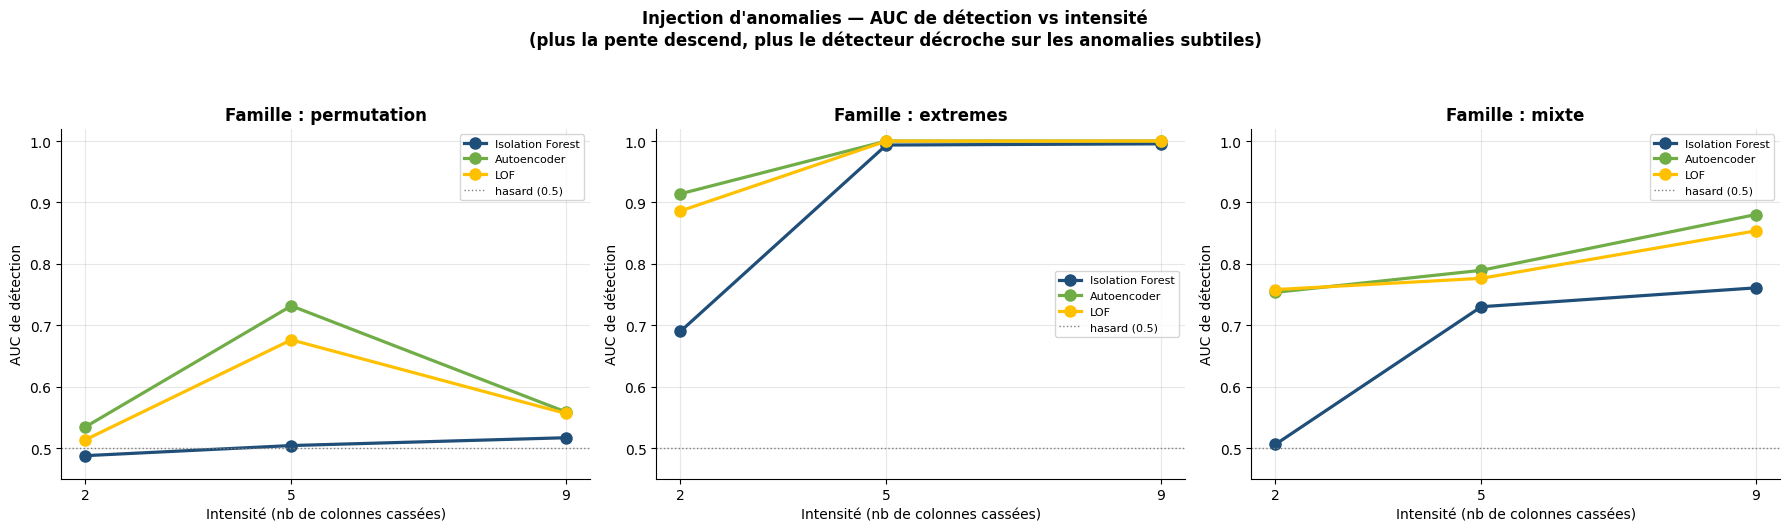


  ✓ Évaluation terminée. Résultats dans le dict `injection`.
  ✓ fig11c_injection_courbe_difficulte.png sauvegardé.
  → Ces chiffres trancheront IF vs AE et statueront sur le LOF (cellule comparaison).


In [31]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5d-3 — Injection : évaluation (courbe AUC détection + point 5% FP)
# ══════════════════════════════════════════════════════════════════════
# Fait scorer les 18 jeux par les 3 détecteurs et mesure la détection.
# Métrique (la plus complète) : AUC de détection + taux de détection à 5% FP.
# ⚠ AUC de détection = score vs LABEL ANOMALIE synthétique connu → VALIDE.
#   (≠ ancienne AUC vs défaut, qui était invalide : même formule, autre cible.)
# Évaluation principale sur le régime ÉQUILIBRÉ (puissance statistique max).
print('\n' + '═' * 70)
print('  11.3d-3 — ÉVALUATION : quel détecteur repère le mieux les anomalies ?')
print('═' * 70)

MODELES = ['Isolation Forest', 'Autoencoder', 'LOF']

# ── Scorer + évaluer tous les jeux du régime équilibré ────────────────
injection = {}   # (famille, intensite) → {modele: {auc, tpr_at_fp, seuil}}
for famille in ['permutation', 'extremes', 'mixte']:
    for inten in INTENSITES:
        df, lab = jeux[(famille, inten, 'equilibre')]
        scores_par_modele = scorer_trois_detecteurs(df)
        injection[(famille, inten)] = {
            m: evaluer(scores_par_modele[m], lab) for m in MODELES
        }

# ── Tableau 1 : AUC de détection par famille × intensité ──────────────
print(f'\n  AUC DE DÉTECTION (1.0 = parfait, 0.5 = hasard) — régime équilibré')
print(f'  {"Famille":<12} {"Intens.":>7}   {"Iso.Forest":>11} {"Autoenc.":>10} {"LOF":>8}')
print(f'  {"─"*56}')
for famille in ['permutation', 'extremes', 'mixte']:
    for inten in INTENSITES:
        r = injection[(famille, inten)]
        vals = [r[m]['auc'] for m in MODELES]
        best = max(vals)
        cells = []
        for v in vals:
            mark = '*' if v == best else ' '   # * = meilleur de la ligne
            cells.append(f'{v:.3f}{mark}')
        print(f'  {famille:<12} {str(inten)+"col":>7}   '
              f'{cells[0]:>11} {cells[1]:>10} {cells[2]:>8}')
    print(f'  {"·"*56}')

# ── Tableau 2 : taux de détection à 5% de faux positifs ───────────────
print(f'\n  TAUX DE DÉTECTION À 5% DE FAUX POSITIFS (vue métier)')
print(f'  {"Famille":<12} {"Intens.":>7}   {"Iso.Forest":>11} {"Autoenc.":>10} {"LOF":>8}')
print(f'  {"─"*56}')
for famille in ['permutation', 'extremes', 'mixte']:
    for inten in INTENSITES:
        r = injection[(famille, inten)]
        vals = [r[m]['tpr_at_fp'] for m in MODELES]
        best = max(vals)
        cells = [f'{v*100:.0f}%{"*" if v==best else " "}' for v in vals]
        print(f'  {famille:<12} {str(inten)+"col":>7}   '
              f'{cells[0]:>11} {cells[1]:>10} {cells[2]:>8}')
    print(f'  {"·"*56}')

# ── Courbe de difficulté : AUC vs intensité (une ligne par détecteur) ─
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Injection d\'anomalies — AUC de détection vs intensité\n'
             '(plus la pente descend, plus le détecteur décroche sur les anomalies subtiles)',
             fontsize=12, fontweight='bold')
couleurs = {'Isolation Forest': COLORS['primary'],
            'Autoencoder': COLORS['success'], 'LOF': COLORS['warning']}

for ax, famille in zip(axes, ['permutation', 'extremes', 'mixte']):
    for m in MODELES:
        y = [injection[(famille, inten)][m]['auc'] for inten in INTENSITES]
        ax.plot(INTENSITES, y, 'o-', color=couleurs[m], linewidth=2.3,
                markersize=8, label=m)
    ax.set_title(f'Famille : {famille}', fontweight='bold')
    ax.set_xlabel('Intensité (nb de colonnes cassées)')
    ax.set_ylabel('AUC de détection')
    ax.set_xticks(INTENSITES)
    ax.set_ylim(0.45, 1.02)
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='hasard (0.5)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.savefig(OUTPUT_DIR + 'fig11c_injection_courbe_difficulte.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  ✓ Évaluation terminée. Résultats dans le dict `injection`.')
print('  ✓ fig11c_injection_courbe_difficulte.png sauvegardé.')
print('  → Ces chiffres trancheront IF vs AE et statueront sur le LOF (cellule comparaison).')

In [32]:
print('====='* 34 + '='*4)

In [33]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 6 — Tableau comparatif A2
# ══════════════════════════════════════════════════════════════════════
# Synthèse de la comparaison des 3 détecteurs d'anomalie (garde-fou non
# supervisé). La SEULE métrique valide est l'injection d'anomalies
# synthétiques (cellules 5d-1/2/3) : score vs LABEL ANOMALIE connu.
# → PLUS d'AUC/Pearson vs défaut (mauvaise cible), plus d'argument
#   "explicabilité Bâle II" (ce flux ne décide rien, il escalade).
# Tout est recalculé depuis `injection` et `resultats` → zéro valeur en dur.

# ── Garde-fou : vérifier que les cellules amont ont tourné ────────────
_manque = [n for n in ('injection', 'resultats', 'MODELES', 'INTENSITES')
           if n not in dir()]
if _manque:
    raise RuntimeError(
        f"Variables manquantes : {_manque}. Relancer d'abord les cellules "
        f"5a/5b/5c (détecteurs) puis 5d-1/5d-2/5d-3 (injection) avant celle-ci."
    )

FAMILLES = ['permutation', 'extremes', 'mixte']
LIBELLE  = {'permutation': 'Permutation (combinaisons)',
            'extremes'   : 'Extrêmes (échelle) \u26a0',
            'mixte'      : 'Mixte (réaliste)'}

# ── Agrégations (moyenne sur les intensités) + comptage des victoires ──
# auc_moyen[modele][famille] = moyenne des AUC sur INTENSITES
# tpr_moyen[modele][famille] = moyenne des TPR@5%FP sur INTENSITES
# victoires[modele]          = nb de fois meilleur AUC sur les 9 croisements
auc_moyen  = {m: {} for m in MODELES}
tpr_moyen  = {m: {} for m in MODELES}
victoires  = {m: 0  for m in MODELES}   # victoires STRICTES (seul en tête)
partages   = 0                          # croisements où le sommet est ex æquo

# Tolérance : deux AUC séparées de moins de EPS sont jugées ex æquo
# (évite qu'un 0.99998 vs 1.00000 fabrique une fausse victoire).
EPS = 1e-9

for fam in FAMILLES:
    for m in MODELES:
        aucs = [injection[(fam, it)][m]['auc']       for it in INTENSITES]
        tprs = [injection[(fam, it)][m]['tpr_at_fp'] for it in INTENSITES]
        auc_moyen[m][fam] = sum(aucs) / len(aucs)
        tpr_moyen[m][fam] = sum(tprs) / len(tprs)
    # Victoire STRICTE = un seul modèle au sommet (AUC > tous les autres).
    # Si plusieurs modèles se partagent le sommet (ex æquo, ex. extrêmes à
    # 1.000), le croisement ne compte pour PERSONNE → il est "partagé".
    for it in INTENSITES:
        vals = {m: injection[(fam, it)][m]['auc'] for m in MODELES}
        sommet = max(vals.values())
        en_tete = [m for m in MODELES if abs(vals[m] - sommet) <= EPS]
        if len(en_tete) == 1:
            victoires[en_tete[0]] += 1
        else:
            partages += 1

# ── Mise en forme ─────────────────────────────────────────────────────
def _ligne(label, valeurs, fmt, best_high=True):
    """Formate une ligne : marque ★ le(s) meilleur(s) de la ligne."""
    nums = [valeurs[m] for m in MODELES]
    cible = max(nums) if best_high else min(nums)
    out = []
    for v in nums:
        mark = ' \u2605' if v == cible else '  '
        out.append(f'{fmt(v)}{mark}')
    return f'  {label:<30} {out[0]:>14} {out[1]:>14} {out[2]:>14}'

W = 78
print('\n' + '═' * W)
print('  TABLEAU A2 — COMPARAISON DES DÉTECTEURS D\'ANOMALIE (garde-fou non supervisé)')
print('  Métrique valide : injection d\'anomalies synthétiques (Steinbuss & Böhm 2021)')
print(f'  Home Credit Default Risk | bons payeurs du validation | régime équilibré 50/50')
print('═' * W)
print(f'  {"":<30} {"Iso. Forest":>14} {"Autoencoder":>14} {"LOF":>14}')

# Bloc 1 — AUC de détection par famille
print('\n  QUALITÉ DE DÉTECTION — AUC (1.000 = parfait, 0.500 = hasard)')
print('  ' + '─' * (W - 2))
for fam in FAMILLES:
    vals = {m: auc_moyen[m][fam] for m in MODELES}
    print(_ligne(LIBELLE[fam], vals, lambda v: f'{v:.3f}'))

# Bloc 2 — TPR à 5% FP par famille (point de fonctionnement métier)
print('\n  DÉTECTION AU POINT MÉTIER — TPR à 5% de faux positifs (% d\'anomalies attrapées)')
print('  ' + '─' * (W - 2))
for fam in FAMILLES:
    vals = {m: tpr_moyen[m][fam] for m in MODELES}
    print(_ligne(LIBELLE[fam], vals, lambda v: f'{v*100:.0f}%'))

# Bloc 3 — Robustesse (victoires STRICTES sur les 9 croisements)
print('\n  ROBUSTESSE — victoires STRICTES : seul en tête de l\'AUC (famille × intensité)')
print('  ' + '─' * (W - 2))
n_croisements = len(FAMILLES) * len(INTENSITES)
vals = {m: victoires[m] for m in MODELES}
print(_ligne('Victoires strictes', vals, lambda v: f'{v} / {n_croisements}'))
print(f'  {"→ dont partagés (ex æquo au sommet)":<30} '
      f'{partages} croisement(s) sur {n_croisements} — non attribués (souvent extrêmes à 1.000)')

# Bloc 4 — Déploiement (aucun critère éliminatoire ici, transparence)
print('\n  DÉPLOIEMENT (aucun critère éliminatoire ici — pour transparence)')
print('  ' + '─' * (W - 2))
lat = {m: resultats[m]['t_inf_ms'] for m in MODELES}
print(_ligne('Latence inférence /client (ms)', lat,
             lambda v: f'{v:.4f}', best_high=False))
pkl = {m: ('oui' if resultats[m]['pkl_prod'] else 'NON \u26a0') for m in MODELES}
print(f'  {"Artefact sans données clients":<30} '
      f'{pkl["Isolation Forest"]:>14} {pkl["Autoencoder"]:>14} {pkl["LOF"]:>14}')
sla = {m: ('oui' if resultats[m]['prod_ok'] else 'NON') for m in MODELES}
print(f'  {"Compatible SLA < 3000 ms":<30} '
      f'{sla["Isolation Forest"]:>14} {sla["Autoencoder"]:>14} {sla["LOF"]:>14}')

# ── Note d'honnêteté : saturation des extrêmes ────────────────────────
print('\n  ' + '─' * (W - 2))
print('  \u26a0 Extrêmes : à partir de 5 colonnes cassées, les 3 détecteurs atteignent AUC 1.000')
print('    (la moyenne affichée ci-dessus, ~0.96, reste sous 1.000 car elle inclut l\'intensité')
print('    2, plus subtile). Cette famille est un CONTRÔLE DE COHÉRENCE du protocole — une')
print('    anomalie franche doit être vue par tous — pas un critère de départage : seule')
print('    l\'intensité la plus faible discrimine. Signalé pour honnêteté méthodologique.')

# ── Verdict (chiffres dynamiques, interprétation de fond fixe §18) ─────
meilleur_auc = max(MODELES, key=lambda m: sum(auc_moyen[m].values()))
plus_faible  = min(MODELES, key=lambda m: sum(auc_moyen[m].values()))
auc_perm = {m: auc_moyen[m]['permutation'] for m in MODELES}

print('\n' + '═' * W)
print('  VERDICT')
print('  ' + '─' * (W - 2))
print(f'  • Meilleur détecteur : {meilleur_auc.upper()} — {victoires[meilleur_auc]} victoires'
      f' strictes /{n_croisements} (+ {partages} croisements à égalité parfaite),')
print(f'    robuste sur toute la plage de difficulté.')
print(f'  • {plus_faible} : le plus faible presque partout. Conçu pour isoler la')
print(f'    périphérie, il rate les anomalies "internes" de permutation'
      f' (AUC ≈ {auc_perm[plus_faible]:.2f}),')
print(f'    car elles sont noyées dans le nuage, pas en marge.')
print(f'  • LOF : proche de l\'AE sur la détection → NON écarté sur ce critère.')
print(f'    Réserves réelles = gouvernance/RGPD (artefact transporte les données clients)')
print(f'    + scalabilité future O(N_train). Latence NON en cause (5000× sous SLA).')
print(f'  • Limite assumée : la permutation subtile est mal détectée par TOUS')
print(f'    (AUC ≈ 0.5) → limite intrinsèque du non supervisé, exposée honnêtement au jury.')
print('  ' + '─' * (W - 2))
print(f'  Décision IF vs AE : penche {meilleur_auc} sur la détection ({victoires[meilleur_auc]}/{n_croisements}')
print(f'  victoires strictes). Déterminisme de l\'AE ÉTABLI (2 runs identiques au bit près) :')
print(f'  l\'ancienne réserve « AE non reproductible » est levée. Réserve restante : écart AE/LOF')
print(f'  parfois faible sur la détection pure → départage par gouvernance/RGPD (LOF écarté).')
print('═' * W)


══════════════════════════════════════════════════════════════════════════════
  TABLEAU A2 — COMPARAISON DES DÉTECTEURS D'ANOMALIE (garde-fou non supervisé)
  Métrique valide : injection d'anomalies synthétiques (Steinbuss & Böhm 2021)
  Home Credit Default Risk | bons payeurs du validation | régime équilibré 50/50
══════════════════════════════════════════════════════════════════════════════
                                    Iso. Forest    Autoencoder            LOF

  QUALITÉ DE DÉTECTION — AUC (1.000 = parfait, 0.500 = hasard)
  ────────────────────────────────────────────────────────────────────────────
  Permutation (combinaisons)            0.503          0.608 ★        0.582  
  Extrêmes (échelle) ⚠                  0.893          0.971 ★        0.962  
  Mixte (réaliste)                      0.666          0.808 ★        0.796  

  DÉTECTION AU POINT MÉTIER — TPR à 5% de faux positifs (% d'anomalies attrapées)
  ──────────────────────────────────────────────────────────────

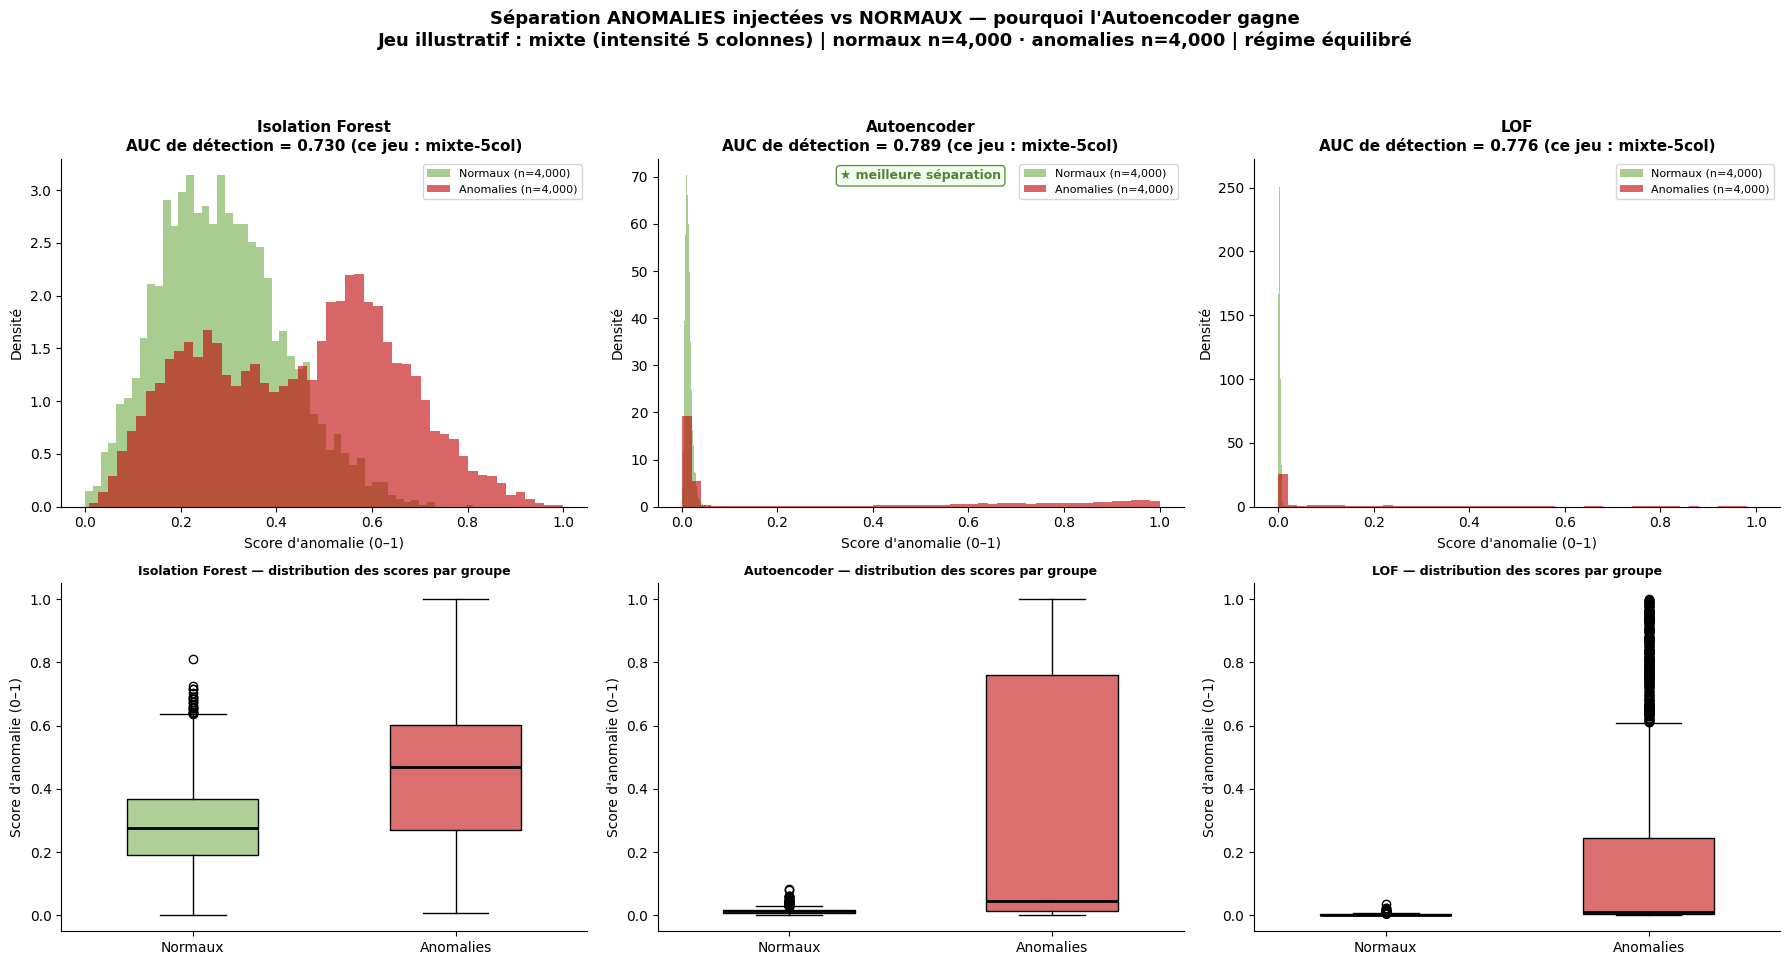


  LECTURE :
  • Histogrammes : plus les distributions verte (normaux) et rouge (anomalies)
    sont SÉPARÉES, meilleur est le détecteur. La zone où elles se chevauchent = confusion.
  • MÉTRIQUE UNIQUE = AUC de détection (dans les titres). L'AUC = probabilité que le
    détecteur donne un score plus haut à une anomalie qu'à un normal (1.0 parfait, 0.5 hasard).
    Elle regarde tout l'ordre des scores → non trompée par la forme des distributions,
    contrairement à l'écart des médianes ou au recouvrement (testés puis écartés, RAPPORT §23).
  • Sur ce jeu, Autoencoder a la meilleure AUC (0.789) → meilleure séparation.

  ✓ fig11a_a2_separation_anomalies.png sauvegardé.


In [34]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 7 — Visualisations comparatives
# ══════════════════════════════════════════════════════════════════════
# Version graphique du tableau A2 : on MONTRE pourquoi l'AE gagne.
# Un bon détecteur donne des scores ÉLEVÉS aux anomalies et BAS aux normaux,
# avec peu de recouvrement. On visualise donc, par détecteur, la distribution
# des scores sur ANOMALIES INJECTÉES vs NORMAUX (la BONNE cible).
# ⚠ PLUS de "scores vs défaut" (mauvaise cible, ancienne cellule) : le défaut
#   n'est pas ce que Flux B détecte. Ici label = anomalie synthétique CONNUE.
# Jeu illustré : MIXTE à intensité 5 (le plus réaliste : mélange des 2 familles,
# difficulté intermédiaire) — représentatif sans retracer les 9 combinaisons.

# ── Garde-fou : cellules amont exécutées ? ────────────────────────────
_manque = [n for n in ('jeux', 'injection', 'scorer_trois_detecteurs', 'MODELES')
           if n not in dir()]
if _manque:
    raise RuntimeError(
        f"Variables manquantes : {_manque}. Relancer les cellules 5d-1/5d-2/5d-3 "
        f"(boîte à outils + jeux + évaluation) avant celle-ci."
    )

# ── Jeu illustratif : mixte, intensité 5, régime équilibré ────────────
FAM_ILLUS, INT_ILLUS = 'mixte', 5
df_illus, lab_illus = jeux[(FAM_ILLUS, INT_ILLUS, 'equilibre')]
lab_illus = np.asarray(lab_illus)
scores_illus = scorer_trois_detecteurs(df_illus)   # {modele: scores 0-1}

n_norm = int((lab_illus == 0).sum())
n_ano  = int((lab_illus == 1).sum())

# ── Figure : une colonne par détecteur (histogramme + boxplot) ────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Séparation ANOMALIES injectées vs NORMAUX — pourquoi l\'Autoencoder gagne\n'
    f'Jeu illustratif : {FAM_ILLUS} (intensité {INT_ILLUS} colonnes) | '
    f'normaux n={n_norm:,} · anomalies n={n_ano:,} | régime équilibré',
    fontsize=13, fontweight='bold')

for col_idx, modname in enumerate(MODELES):
    s   = scores_illus[modname]
    auc = injection[(FAM_ILLUS, INT_ILLUS)][modname]['auc']   # AUC de détection (VALIDE)
    s_norm = s[lab_illus == 0]
    s_ano  = s[lab_illus == 1]

    # ── Ligne 1 : histogrammes superposés (densité) ──────────────────
    ax = axes[0, col_idx]
    ax.hist(s_norm, bins=50, alpha=0.6, color=COLORS['success'],
            label=f'Normaux (n={n_norm:,})', density=True)
    ax.hist(s_ano, bins=50, alpha=0.6, color=COLORS['danger'],
            label=f'Anomalies (n={n_ano:,})', density=True)
    ax.set_title(f'{modname}\nAUC de détection = {auc:.3f} (ce jeu : {FAM_ILLUS}-{INT_ILLUS}col)',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Score d\'anomalie (0–1)')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)

    # Badge : meilleur détecteur (celui de plus haute AUC sur ce jeu)
    est_meilleur = (modname == max(
        MODELES, key=lambda m: injection[(FAM_ILLUS, INT_ILLUS)][m]['auc']))
    if est_meilleur:
        ax.text(0.5, 0.97, '\u2605 meilleure séparation',
                transform=ax.transAxes, ha='center', va='top',
                fontsize=9, fontweight='bold', color='#548235',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FFF0',
                          edgecolor='#548235', alpha=0.9))

    # ── Ligne 2 : boxplot normaux vs anomalies ───────────────────────
    ax2 = axes[1, col_idx]
    bp = ax2.boxplot([s_norm, s_ano],
                     labels=['Normaux', 'Anomalies'],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLORS['success'] + '90')
    bp['boxes'][1].set_facecolor(COLORS['danger'] + '90')
    ax2.set_title(f'{modname} — distribution des scores par groupe',
                  fontweight='bold', fontsize=9)
    ax2.set_ylabel('Score d\'anomalie (0–1)')

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.savefig(OUTPUT_DIR + 'fig11a_a2_separation_anomalies.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Lecture guidée (texte, pour l'oral) ───────────────────────────────
print('\n  LECTURE :')
print('  • Histogrammes : plus les distributions verte (normaux) et rouge (anomalies)')
print('    sont SÉPARÉES, meilleur est le détecteur. La zone où elles se chevauchent = confusion.')
print('  • MÉTRIQUE UNIQUE = AUC de détection (dans les titres). L\'AUC = probabilité que le')
print('    détecteur donne un score plus haut à une anomalie qu\'à un normal (1.0 parfait, 0.5 hasard).')
print('    Elle regarde tout l\'ordre des scores → non trompée par la forme des distributions,')
print('    contrairement à l\'écart des médianes ou au recouvrement (testés puis écartés, RAPPORT §23).')
meilleur = max(MODELES, key=lambda m: injection[(FAM_ILLUS, INT_ILLUS)][m]['auc'])
auc_best = injection[(FAM_ILLUS, INT_ILLUS)][meilleur]['auc']
print(f'  • Sur ce jeu, {meilleur} a la meilleure AUC ({auc_best:.3f}) → meilleure séparation.')
print('\n  ✓ fig11a_a2_separation_anomalies.png sauvegardé.')


══════════════════════════════════════════════════════════════════════
  11.4 — CALIBRATION DU SEUIL (Autoencoder + Isolation Forest)
══════════════════════════════════════════════════════════════════════

  BUT : trouver la BARRE (seuil) qui sépare « normal » de « à escalader
        en revue ». On calibre AE ET IF en parallèle (décision finale
        IF vs AE = plus tard) — on ne choisit rien ici.

  MÉTHODE (littérature, RAPPORT §28) : seuil = PERCENTILE des scores des
        BONS PAYEURS. On teste P95 et P99. Ne demande aucune anomalie
        connue → adapté au non-supervisé en production. On pilote le
        COÛT (fausses alertes) : P95 ≈ 5% de bons clients dérangés,
        P99 ≈ 1%.

  ÉCHELLE (RAPPORT §29) : score BRUT, sans min-max (seuil stable au
        réentraînement). AE = log1p(MSE) ; IF = -decision_function.

  LECTURE : pour chaque (détecteur, percentile) on montre les deux faces
        du compromis — COÛT (bons payeurs signalés à tort) vs BÉNÉFICE
        (anoma

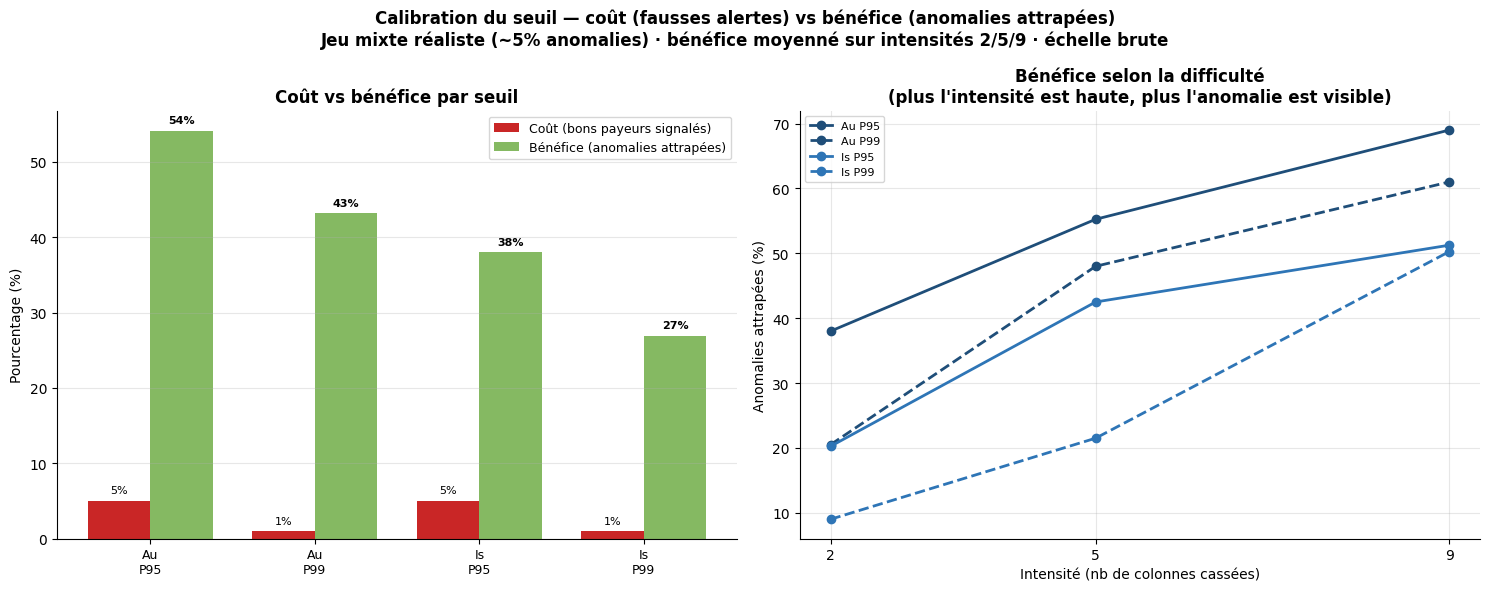


  OK fig11b_calibration_seuil.png sauvegardé
  OK seuils calibrés stockés dans SEUILS_CALIBRATION : ['Autoencoder_P95', 'Autoencoder_P99', 'Isolation Forest_P95', 'Isolation Forest_P99']


In [35]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 8 — Calibration du seuil (AE + IF, en parallèle)
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.4 — CALIBRATION DU SEUIL (Autoencoder + Isolation Forest)')
print('═' * 70)
print("""
  BUT : trouver la BARRE (seuil) qui sépare « normal » de « à escalader
        en revue ». On calibre AE ET IF en parallèle (décision finale
        IF vs AE = plus tard) — on ne choisit rien ici.

  MÉTHODE (littérature, RAPPORT §28) : seuil = PERCENTILE des scores des
        BONS PAYEURS. On teste P95 et P99. Ne demande aucune anomalie
        connue → adapté au non-supervisé en production. On pilote le
        COÛT (fausses alertes) : P95 ≈ 5% de bons clients dérangés,
        P99 ≈ 1%.

  ÉCHELLE (RAPPORT §29) : score BRUT, sans min-max (seuil stable au
        réentraînement). AE = log1p(MSE) ; IF = -decision_function.

  LECTURE : pour chaque (détecteur, percentile) on montre les deux faces
        du compromis — COÛT (bons payeurs signalés à tort) vs BÉNÉFICE
        (anomalies injectées attrapées). Jeu = mixte réaliste (~5%),
        bénéfice moyenné sur les intensités 2/5/9.
""")

# ── Fonctions de score BRUT (échelle de calibration, PAS d'affichage) ──
def _scores_bruts_ae(X):
    """Score AE en échelle de CALIBRATION : log1p(MSE) brut (pas de min-max)."""
    recon = autoencoder_keras.predict(X, verbose=0)
    mse   = np.mean((X - recon) ** 2, axis=1)
    return np.log1p(mse)

def _scores_bruts_if(X):
    """Score IF en échelle de CALIBRATION : -decision_function brut (pas de min-max).
    Plus le score est haut, plus le point est anormal (d'où le signe -)."""
    return -iso_forest.decision_function(X)

_SCORERS     = {'Autoencoder': _scores_bruts_ae, 'Isolation Forest': _scores_bruts_if}
_PERCENTILES = [95, 99]

# ── Récupération des scores sur le jeu MIXTE RÉALISTE (3 intensités) ────
# On score une seule fois chaque (détecteur × intensité), puis on réutilise.
_scores_par_det = {}   # det -> {'bp': scores bons payeurs (union 3 intensités),
                       #         'ano': {inten: scores anomalies}}
for _det, _scorer in _SCORERS.items():
    _bp_list, _ano = [], {}
    for _inten in INTENSITES:
        _df, _lab = jeux[('mixte', _inten, 'realiste')]
        _X = transformer_brut(_df)
        _s = _scorer(_X)
        _bp_list.append(_s[_lab == 0])        # bons payeurs de ce jeu
        _ano[_inten] = _s[_lab == 1]          # anomalies injectées de ce jeu
    _scores_par_det[_det] = {'bp': np.concatenate(_bp_list), 'ano': _ano}

# ── Calcul des seuils P95/P99 + coût + bénéfice moyenné ────────────────
SEUILS_CALIBRATION = {}   # 'Detecteur_Pxx' -> valeur du seuil (échelle brute)
resultats_calib    = []

for _det in _SCORERS:
    _bp = _scores_par_det[_det]['bp']
    for _perc in _PERCENTILES:
        _seuil = float(np.percentile(_bp, _perc))
        # COÛT : part de bons payeurs au-dessus du seuil (fausses alertes)
        _cout  = float((_bp >= _seuil).mean())
        # BÉNÉFICE : part d'anomalies injectées attrapées, moyennée sur intensités
        _benefs = [float((_scores_par_det[_det]['ano'][i] >= _seuil).mean())
                   for i in INTENSITES]
        _benef  = float(np.mean(_benefs))
        SEUILS_CALIBRATION[f'{_det}_P{_perc}'] = _seuil
        resultats_calib.append({
            'det': _det, 'perc': _perc, 'seuil': _seuil,
            'cout': _cout, 'benef': _benef, 'benefs_detail': _benefs,
        })

# ── Affichage du tableau de calibration ────────────────────────────────
print(f'  {"Détecteur":<18}{"Seuil":>10}{"COÛT (FP)":>13}{"BÉNÉFICE":>13}')
print(f'  {"":18}{"(brut)":>10}{"bons payeurs":>13}{"anomalies":>13}')
print(f'  {"":18}{"":>10}{"signalés":>13}{"attrapées":>13}')
print('  ' + '─' * 54)
_det_courant = None
for r in resultats_calib:
    _sep = '' if r['det'] == _det_courant else ('\n' if _det_courant else '')
    _det_courant = r['det']
    _nom = r['det'] if r['perc'] == _PERCENTILES[0] else ''
    print(f'{_sep}  {_nom:<18}P{r["perc"]:<3} {r["seuil"]:>5.4f}'
          f'{r["cout"]*100:>10.1f}%{r["benef"]*100:>12.1f}%')
print('  ' + '─' * 54)

# ── Lecture guidée (verdict dynamique, sans trancher IF vs AE) ──────────
_ae95 = next(r for r in resultats_calib if r['det']=='Autoencoder' and r['perc']==95)
_if95 = next(r for r in resultats_calib if r['det']=='Isolation Forest' and r['perc']==95)
_ae99 = next(r for r in resultats_calib if r['det']=='Autoencoder' and r['perc']==99)
_if99 = next(r for r in resultats_calib if r['det']=='Isolation Forest' and r['perc']==99)

print(f'\n  LECTURE :')
print(f'  • À coût égal 5% (P95) : AE attrape {_ae95["benef"]*100:.1f}% des anomalies, '
      f'IF {_if95["benef"]*100:.1f}%.')
print(f'  • À coût égal 1% (P99) : AE attrape {_ae99["benef"]*100:.1f}% des anomalies, '
      f'IF {_if99["benef"]*100:.1f}%.')
_meilleur95 = 'AE' if _ae95['benef'] >= _if95['benef'] else 'IF'
print(f'  • À FP égal, meilleur détecteur : {_meilleur95} (P95). '
      f'La décision finale IF vs AE reste la Tâche 5 (tous arguments).')
print(f'  • P95 vs P99 = arbitrage : P95 attrape plus mais dérange 5%/100 ; '
      f'P99 dérange 1%/100 mais attrape moins.')

# ── Visualisation : coût vs bénéfice pour AE et IF ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Calibration du seuil — coût (fausses alertes) vs bénéfice (anomalies attrapées)\n'
    'Jeu mixte réaliste (~5% anomalies) · bénéfice moyenné sur intensités 2/5/9 · échelle brute',
    fontsize=12, fontweight='bold')

_couleurs_det = {'Autoencoder': COLORS.get('primary', '#2E86AB'),
                 'Isolation Forest': COLORS.get('secondary', '#A23B72')}

# Panneau 1 : barres coût vs bénéfice par (détecteur, percentile)
ax = axes[0]
_labels_x = [f'{r["det"][:2]}\nP{r["perc"]}' for r in resultats_calib]
_x = np.arange(len(resultats_calib))
_larg = 0.38
ax.bar(_x - _larg/2, [r['cout']*100 for r in resultats_calib], _larg,
       label='Coût (bons payeurs signalés)', color=COLORS.get('danger', '#C73E1D'), alpha=0.85)
ax.bar(_x + _larg/2, [r['benef']*100 for r in resultats_calib], _larg,
       label='Bénéfice (anomalies attrapées)', color=COLORS.get('success', '#3B8C4D'), alpha=0.85)
ax.set_xticks(_x); ax.set_xticklabels(_labels_x, fontsize=9)
ax.set_ylabel('Pourcentage (%)')
ax.set_title('Coût vs bénéfice par seuil', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
for i, r in enumerate(resultats_calib):
    ax.text(i - _larg/2, r['cout']*100 + 1, f'{r["cout"]*100:.0f}%', ha='center', fontsize=8)
    ax.text(i + _larg/2, r['benef']*100 + 1, f'{r["benef"]*100:.0f}%', ha='center', fontsize=8, fontweight='bold')

# Panneau 2 : bénéfice par intensité (montre l'effet de la difficulté)
ax2 = axes[1]
for _det in _SCORERS:
    for _perc in _PERCENTILES:
        r = next(rr for rr in resultats_calib if rr['det']==_det and rr['perc']==_perc)
        _style = '-' if _perc == 95 else '--'
        ax2.plot(INTENSITES, [b*100 for b in r['benefs_detail']], _style,
                 marker='o', linewidth=2, color=_couleurs_det[_det],
                 label=f'{_det[:2]} P{_perc}')
ax2.set_xlabel('Intensité (nb de colonnes cassées)')
ax2.set_ylabel('Anomalies attrapées (%)')
ax2.set_title('Bénéfice selon la difficulté\n(plus l\'intensité est haute, plus l\'anomalie est visible)',
              fontweight='bold')
ax2.set_xticks(INTENSITES)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig11b_calibration_seuil.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n  OK fig11b_calibration_seuil.png sauvegardé')
print(f'  OK seuils calibrés stockés dans SEUILS_CALIBRATION : {list(SEUILS_CALIBRATION.keys())}')

In [36]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 9 — Architecture de décision à 3 couches
# ══════════════════════════════════════════════════════════════════════
# Montre comment les 3 couches se combinent (pédagogique — ne décide rien).
#   • COUCHE 2 = détecteur d'anomalie GÉNÉRIQUE (le choix IF vs AE et le
#     percentile P95/P99 sont arrêtés en Tâche 5). On affiche les 4 seuils
#     calibrés (CELLULE 8) sans en privilégier aucun.
#   • Seuil d'anomalie lu dans SEUILS_CALIBRATION (plus aucune variable de
#     l'ancienne cellule 8 supprimée) ; récit garde-fou (plus d'analogie
#     "jour zéro", plus de capture de défaut comme métrique).

# ── Garde-fou : la calibration (CELLULE 8) doit avoir tourné ──────────
if 'SEUILS_CALIBRATION' not in dir():
    raise RuntimeError(
        "SEUILS_CALIBRATION manquant. Relancer la CELLULE 8 (calibration) avant celle-ci."
    )

W = 78
print('\n' + '═' * W)
print('  11.5 — ARCHITECTURE DE DÉCISION À 3 COUCHES')
print('═' * W)

# ── COUCHE 1 — ρc (couverture prédictive) ─────────────────────────────
print('\n  COUCHE 1 — ρc (indice de couverture prédictive)')
print('  ' + '─' * (W - 2))
print("""  ρc < 0.25  → REVUE FORCÉE
             Moins de 25 % du pouvoir prédictif disponible (les features
             historiques pèsent 61 % de l'IV total). Décision automatique
             statistiquement non fiable → superviseur obligatoire.
  ρc < 0.40  → BANNIÈRE documentaire (décision auto maintenue si score OK)
             Dossier significativement incomplet → recommandation documentaire.""")

# ── COUCHE 2 — Détecteur d'anomalie (garde-fou non supervisé) ─────────
print('\n  COUCHE 2 — Détecteur d\'anomalie (garde-fou non supervisé)')
print('  ' + '─' * (W - 2))
print("""  Seuil = percentile des scores des BONS PAYEURS (P95 ou P99), calibré
          en CELLULE 8 sur l'échelle brute. Au-delà du seuil : profil
          structurellement hors distribution → escalade en revue.
  Le détecteur (IF ou AE) ET le percentile (P95 ou P99) sont arrêtés en
  Tâche 5 ; ci-dessous les 4 seuils calibrés, aucun n'est encore retenu :""")
print(f"""    Autoencoder       P95 = {SEUILS_CALIBRATION['Autoencoder_P95']:.4f}    P99 = {SEUILS_CALIBRATION['Autoencoder_P99']:.4f}
    Isolation Forest  P95 = {SEUILS_CALIBRATION['Isolation Forest_P95']:.4f}    P99 = {SEUILS_CALIBRATION['Isolation Forest_P99']:.4f}""")

# ── COUCHE 3 — Score PDO ───────────────────────────────────────────────
print('\n  COUCHE 3 — Score PDO (LightGBM → probabilité → score)')
print('  ' + '─' * (W - 2))
print("""  Score ≥ 600  → ACCORDÉ   (ancrage PD = 5 %, convention Siddiqi 2006)
  Score < 500  → REFUSÉ    (PD ≈ 62.8 %, calculé via Offset/Factor)
  500 – 600    → REVUE     (zone d'ambiguïté : 5 % < PD < 62.8 %)""")

# ── Règle d'intégration (escalade conservative) ───────────────────────
print('\n  RÈGLE D\'ESCALADE CONSERVATIVE')
print('  ' + '─' * (W - 2))
print("""  Le détecteur d'anomalie ne peut qu'ESCALADER, jamais faire descendre :
    anomalie + ACCORDÉ  → REVUE MANUELLE
    anomalie + REVUE    → inchangé (déjà en revue)
    anomalie + REFUSÉ   → inchangé (déjà refusé)""")

# ── Tableau de scénarios (illustratif) ────────────────────────────────
print('\n  SCÉNARIOS TYPES')
print(f'  {"ρc":>6} {"Anomalie":>10} {"Score PDO":>10} {"Décision finale":>18}  Motif')
print('  ' + '─' * (W - 2))

scenarios = [
    (0.10, False, 450, 'REFUSÉ',         'ρc < 0.25 + score < 500 → refus direct'),
    (0.10, False, 550, 'REVUE MANUELLE', 'ρc < 0.25 + score OK → documents manquants'),
    (0.10, True,  550, 'REVUE MANUELLE', 'ρc < 0.25 + anomalie → revue (ρc prime)'),
    (0.85, False, 630, 'ACCORDÉ',        'dossier complet, profil normal, bon score'),
    (0.85, True,  620, 'REVUE MANUELLE', 'anomalie + ACCORDÉ → escalade (garde-fou)'),
    (0.85, False, 550, 'REVUE MANUELLE', 'score en zone grise → superviseur'),
    (0.85, False, 450, 'REFUSÉ',         'score < 500, PD > 62.8 %'),
    (0.85, True,  450, 'REFUSÉ',         'anomalie + REFUSÉ → inchangé'),
    (0.50, True,  580, 'REVUE MANUELLE', 'dossier partiel + anomalie + zone grise'),
    (0.45, False, 610, 'ACCORDÉ',        'ρc > 0.40, score ≥ 600 → accordé avec bannière'),
]

for rho, anom, score, dec, motif in scenarios:
    anom_str = 'OUI' if anom else 'non'
    icon = '✓' if dec == 'ACCORDÉ' else ('~' if dec == 'REVUE MANUELLE' else '✗')
    print(f'  {rho:>6.2f} {anom_str:>10} {score:>10}   {icon} {dec:<16} {motif}')

print('\n' + '═' * W)
print('  Note : seuil d\'anomalie affiché à titre indicatif (4 candidats).')
print('  Détecteur et percentile officiels = Tâche 5, après recalibration PDO.')
print('═' * W)


══════════════════════════════════════════════════════════════════════════════
  11.5 — ARCHITECTURE DE DÉCISION À 3 COUCHES
══════════════════════════════════════════════════════════════════════════════

  COUCHE 1 — ρc (indice de couverture prédictive)
  ────────────────────────────────────────────────────────────────────────────
  ρc < 0.25  → REVUE FORCÉE
             Moins de 25 % du pouvoir prédictif disponible (les features
             historiques pèsent 61 % de l'IV total). Décision automatique
             statistiquement non fiable → superviseur obligatoire.
  ρc < 0.40  → BANNIÈRE documentaire (décision auto maintenue si score OK)
             Dossier significativement incomplet → recommandation documentaire.

  COUCHE 2 — Détecteur d'anomalie (garde-fou non supervisé)
  ────────────────────────────────────────────────────────────────────────────
  Seuil = percentile des scores des BONS PAYEURS (P95 ou P99), calibré
          en CELLULE 8 sur l'échelle brute. Au-delà du se

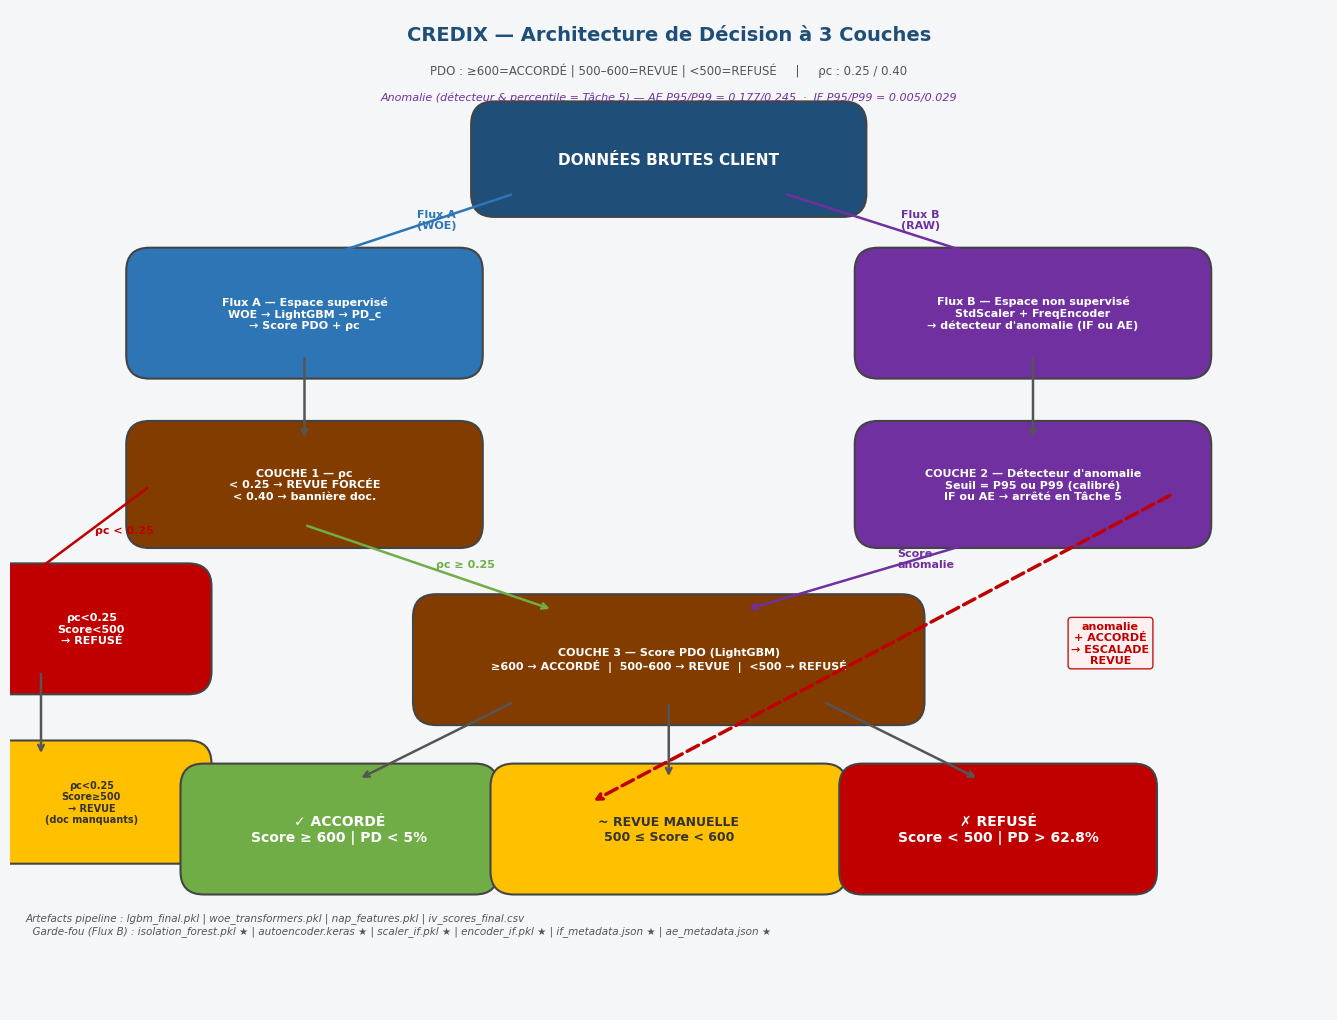

OK fig11c_diagramme_decision_3_couches.png sauvegardé


In [37]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 10 — Diagramme de décision complet
# ══════════════════════════════════════════════════════════════════════
# Schéma de l'architecture 3 couches (pédagogique — ne décide rien).
# COUCHE 2 = détecteur d'anomalie GÉNÉRIQUE : le choix IF vs AE et le
# percentile (P95/P99) sont arrêtés en Tâche 5. Les 4 seuils calibrés
# (CELLULE 8) sont rappelés en sous-titre, sans en privilégier aucun.

# ── Garde-fou : constantes de décision + seuils calibrés requis ───────
_besoin = [n for n in ('SEUILS_CALIBRATION', 'SEUIL_ACCORDE', 'SEUIL_REVUE') if n not in dir()]
if _besoin:
    raise RuntimeError(
        f"Variables manquantes : {_besoin}. Relancer la CELLULE 8 (calibration) "
        f"et la cellule des constantes de décision (SEUIL_ACCORDE/SEUIL_REVUE) avant celle-ci."
    )

fig, ax = plt.subplots(figsize=(17, 13))
ax.set_xlim(0, 17)
ax.set_ylim(0, 13)
ax.axis('off')
fig.patch.set_facecolor('#F4F6F8')
ax.set_facecolor('#F4F6F8')


def box(ax, x, y, w, h, txt, fc, tc='white', fs=9, lw=1.5, radius=0.3, alpha=1.0):
    from matplotlib.patches import FancyBboxPatch
    b = FancyBboxPatch((x, y), w, h,
                        boxstyle=f'round,pad={radius}',
                        linewidth=lw, edgecolor='#444',
                        facecolor=fc, alpha=alpha)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, txt, ha='center', va='center',
            fontsize=fs, color=tc, fontweight='bold',
            multialignment='center', wrap=True)


def arrow(ax, x1, y1, x2, y2, label='', lc='#555555', ls='-'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=lc,
                                lw=1.8, linestyle=ls))
    if label:
        mx, my = (x1+x2)/2 + 0.1, (y1+y2)/2
        ax.text(mx, my, label, fontsize=8, color=lc, fontweight='bold')


# Titre
ax.text(8.5, 12.6, 'CREDIX — Architecture de Décision à 3 Couches',
        ha='center', fontsize=14, fontweight='bold', color='#1F4E79')
ax.text(8.5, 12.15,
        f'PDO : ≥{SEUIL_ACCORDE}=ACCORDÉ | {SEUIL_REVUE}–{SEUIL_ACCORDE}=REVUE | '
        f'<{SEUIL_REVUE}=REFUSÉ     |     ρc : 0.25 / 0.40',
        ha='center', fontsize=8.5, color='#555')
# Sous-titre : seuils d'anomalie calibrés (les 4 candidats, choix = Tâche 5)
ax.text(8.5, 11.82,
        f'Anomalie (détecteur & percentile = Tâche 5) — '
        f'AE P95/P99 = {SEUILS_CALIBRATION["Autoencoder_P95"]:.3f}/{SEUILS_CALIBRATION["Autoencoder_P99"]:.3f}  ·  '
        f'IF P95/P99 = {SEUILS_CALIBRATION["Isolation Forest_P95"]:.3f}/{SEUILS_CALIBRATION["Isolation Forest_P99"]:.3f}',
        ha='center', fontsize=8, color='#7030A0', style='italic')

# ENTRÉE
box(ax, 6.25, 10.6, 4.5, 0.9,
    'DONNÉES BRUTES CLIENT', '#1F4E79', fs=11)

# Double flux
arrow(ax, 6.5, 10.6, 3.8, 9.7, 'Flux A\n(WOE)', '#2E75B6')
arrow(ax, 10.0, 10.6, 12.8, 9.7, 'Flux B\n(RAW)', '#7030A0')

# Flux A
box(ax, 1.8, 8.5, 4.0, 1.1,
    'Flux A — Espace supervisé\nWOE → LightGBM → PD_c\n→ Score PDO + ρc',
    '#2E75B6', fs=8)

# Flux B
box(ax, 11.2, 8.5, 4.0, 1.1,
    'Flux B — Espace non supervisé\nStdScaler + FreqEncoder\n→ détecteur d\'anomalie (IF ou AE)',
    '#7030A0', fs=8)

# COUCHE 1 : ρc
arrow(ax, 3.8, 8.5, 3.8, 7.4)
box(ax, 1.8, 6.3, 4.0, 1.05,
    'COUCHE 1 — ρc\n< 0.25 → REVUE FORCÉE\n< 0.40 → bannière doc.',
    '#833C00', fs=8)

arrow(ax, 1.8, 6.8, 0.2, 5.6, 'ρc < 0.25', '#C00000')
box(ax, -0.2, 4.4, 2.5, 1.1,
    'ρc<0.25\nScore<500\n→ REFUSÉ',
    '#C00000', fs=8)
arrow(ax, 0.4, 4.4, 0.4, 3.3)
box(ax, -0.2, 2.2, 2.5, 1.0,
    'ρc<0.25\nScore≥500\n→ REVUE\n(doc manquants)',
    '#FFC000', '#333', fs=7)

# COUCHE 2 : détecteur d'anomalie (générique)
arrow(ax, 13.2, 8.5, 13.2, 7.4)
box(ax, 11.2, 6.3, 4.0, 1.05,
    'COUCHE 2 — Détecteur d\'anomalie\nSeuil = P95 ou P99 (calibré)\nIF ou AE → arrêté en Tâche 5',
    '#7030A0', fs=8)

# COUCHE 3 : PDO
arrow(ax, 3.8, 6.3, 7.0, 5.2, 'ρc ≥ 0.25', '#70AD47')
arrow(ax, 13.2, 6.3, 9.5, 5.2, 'Score\nanomalie', '#7030A0')

box(ax, 5.5, 4.0, 6.0, 1.1,
    f'COUCHE 3 — Score PDO (LightGBM)\n≥{SEUIL_ACCORDE} → ACCORDÉ  |  '
    f'{SEUIL_REVUE}–{SEUIL_ACCORDE} → REVUE  |  <{SEUIL_REVUE} → REFUSÉ',
    '#833C00', fs=8)

# Décisions finales
arrow(ax, 6.5, 4.0, 4.5, 3.0)
arrow(ax, 8.5, 4.0, 8.5, 3.0)
arrow(ax, 10.5, 4.0, 12.5, 3.0)

box(ax, 2.5, 1.8, 3.5, 1.1, '✓ ACCORDÉ\nScore ≥ 600 | PD < 5%',
    '#70AD47', fs=10)
box(ax, 6.5, 1.8, 4.0, 1.1, '~ REVUE MANUELLE\n500 ≤ Score < 600',
    '#FFC000', '#333', fs=9)
box(ax, 11.0, 1.8, 3.5, 1.1, '✗ REFUSÉ\nScore < 500 | PD > 62.8%',
    '#C00000', fs=10)

# Flèche escalade anomalie
ax.annotate('', xy=(7.5, 2.7), xytext=(15.0, 6.7),
            arrowprops=dict(arrowstyle='->', color='#C00000',
                            lw=2.5, linestyle='dashed'))
ax.text(14.2, 4.5,
        'anomalie\n+ ACCORDÉ\n→ ESCALADE\nREVUE',
        fontsize=8, color='#C00000', fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='#FFF0F0',
                  edgecolor='#C00000', alpha=0.9))

# Légende artefacts (IF + AE — les deux méthodes sont sauvegardées, cellule 11)
ax.text(0.2, 1.0,
        'Artefacts pipeline : lgbm_final.pkl | woe_transformers.pkl | nap_features.pkl | '
        'iv_scores_final.csv\n'
        '  Garde-fou (Flux B) : isolation_forest.pkl ★ | autoencoder.keras ★ | scaler_if.pkl ★ | '
        'encoder_if.pkl ★ | if_metadata.json ★ | ae_metadata.json ★',
        fontsize=7.5, color='#555', style='italic')

plt.savefig(OUTPUT_DIR + 'fig11c_diagramme_decision_3_couches.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('OK fig11c_diagramme_decision_3_couches.png sauvegardé')

In [38]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 11 — Sauvegarde des artefacts (Isolation Forest + Autoencoder)
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.6 — SAUVEGARDE DES ARTEFACTS (IF + AE, garde-fou Flux B)')
print('═' * 70)

# ── Helper : AUC d'injection moyenne d'un détecteur (indicatif) ────────
def _auc_injection_moyenne(nom_modele):
    """Moyenne des AUC de détection sur toutes les familles × intensités.
    Source : dict 'injection' (métrique VALIDE = score vs label anomalie)."""
    familles = ['permutation', 'extremes', 'mixte']
    vals = [injection[(fam, it)][nom_modele]['auc']
            for fam in familles for it in INTENSITES]
    return float(np.mean(vals))

# ══════════════════════════════════════════════════════════════════════
# PARTIE 1 — ISOLATION FOREST
# ══════════════════════════════════════════════════════════════════════
# 1. Modèle Isolation Forest
with open(ART_DIR + 'isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)
print('  ★ isolation_forest.pkl sauvegardé')

# 2. StandardScaler (numériques) — partagé IF + AE (même preprocessing)
if scaler_if is not None:
    with open(ART_DIR + 'scaler_if.pkl', 'wb') as f:
        pickle.dump({'scaler': scaler_if, 'medians': medians_train.to_dict(),
                     'features': num_in_nap}, f)
    print(f'  ★ scaler_if.pkl sauvegardé ({len(num_in_nap)} features numériques)')

# 3. Encodeur HYBRIDE (catégorielles : One-Hot simple + Unknown + Frequency) — partagé IF + AE
#    REMPLACE l'ancien encoder_if (Frequency partout). Contient la mémoire d'encodage 61 dims.
with open(ART_DIR + 'encoder_hybrid.pkl', 'wb') as f:
    pickle.dump(encoder_hybrid, f)
print(f'  ★ encoder_hybrid.pkl sauvegardé (One-Hot + Unknown + Frequency, {len(cat_in_nap)} variables cat.)')

# 3bis. LISTE ORDONNÉE des 61 colonnes de sortie (CRUCIAL pour l'alignement backend).
#       L'ordre est déterministe (OneHotEncoder trie ; concaténation [num | OH simple | OH+Unknown | freq]).
#       Le backend DOIT reconstruire le vecteur dans CET ordre exact, sinon désalignement.
colonnes_ordonnees = list(num_in_nap) + list(encoder_hybrid.feature_names_)
with open(ART_DIR + 'colonnes_ordonnees_61.json', 'w') as f:
    json.dump({'n_colonnes': len(colonnes_ordonnees),
               'ordre': colonnes_ordonnees,
               'bloc_num': num_in_nap,
               'bloc_cat_hybride': list(encoder_hybrid.feature_names_)}, f, indent=2, ensure_ascii=False)
print(f'  ★ colonnes_ordonnees_61.json sauvegardé ({len(colonnes_ordonnees)} colonnes, ordre déterministe)')

# 4. Métadonnées IF (nettoyées : plus de auc_proxy/corr_pd ; seuils de la calibration)
if_metadata = {
    'version'           : '1.0',
    'date_entrainement' : pd.Timestamp.now().isoformat(),
    'features_num'      : num_in_nap,
    'features_cat'      : cat_in_nap,
    'features_total'    : features_nap_raw,
    'transformation'    : '-decision_function',   # échelle de calibration (brut)
    'encodage'          : 'hybride 61 dims (One-Hot + Unknown + Frequency)',
    'seuil_if_p95'      : float(SEUILS_CALIBRATION['Isolation Forest_P95']),
    'seuil_if_p99'      : float(SEUILS_CALIBRATION['Isolation Forest_P99']),
    'seuil_percentile_options' : [95, 99],        # choix final = Tâche 5
    'n_estimators'      : int(iso_forest.n_estimators),
    'contamination'     : float(iso_forest.contamination),
    'n_train_class0'    : int(X_tr_hybrid_class0.shape[0]),
    'n_features'        : int(X_tr_hybrid_class0.shape[1]),
    'auc_injection_moyenne' : _auc_injection_moyenne('Isolation Forest'),  # indicatif
    't_inference_ms'    : float(resultats['Isolation Forest']['t_inf_ms']),
    'candidats_evalues' : ['Isolation Forest', 'Autoencoder', 'LOF'],
}
with open(ART_DIR + 'if_metadata.json', 'w') as f:
    json.dump(if_metadata, f, indent=2, ensure_ascii=False)
print('  ★ if_metadata.json sauvegardé (nettoyé, seuils P95/P99)')

# ══════════════════════════════════════════════════════════════════════
# PARTIE 2 — AUTOENCODER
# ══════════════════════════════════════════════════════════════════════
# 5. Modèle AE en format .keras natif (recommandé pour un réseau Keras)
autoencoder_keras.save(ART_DIR + 'autoencoder.keras')
print('  ★ autoencoder.keras sauvegardé (format natif Keras)')

# 6. Métadonnées AE (complètes, honnêtes ; pas de auc_proxy/corr_pd)
ae_metadata = {
    'version'            : '1.0',
    'date_entrainement'  : pd.Timestamp.now().isoformat(),
    'architecture'       : '61-22-8-22-61',
    'goulot'             : 8,
    'couche_cachee'      : 22,
    'couche_cachee_regle': 'pyramide geometrique sqrt(61*8)=22 (Masters 1993)',
    'goulot_balayage'    : [8, 12, 16, 20, 24],
    'goulot_choix'       : 'parcimonie (AUROC 8=0.808 vs 12=0.812, ecart 0.004 negligeable)',
    'transformation'     : 'log1p',               # score = log1p(MSE), échelle de calibration
    'deterministe'       : True,                  # constat Tâche 2 : 2 runs → scores identiques (bit-près)
    'seuil_ae_p95'       : float(SEUILS_CALIBRATION['Autoencoder_P95']),
    'seuil_ae_p99'       : float(SEUILS_CALIBRATION['Autoencoder_P99']),
    'seuil_percentile_options' : [95, 99],        # choix final = Tâche 5
    'auc_injection_moyenne'    : _auc_injection_moyenne('Autoencoder'),   # indicatif
    'n_train_class0'     : int(X_tr_hybrid_class0.shape[0]),
    'n_features'         : int(X_tr_hybrid_class0.shape[1]),
    'features_num'       : num_in_nap,            # même preprocessing que l'IF
    'features_cat'       : cat_in_nap,
    'features_total'     : features_nap_raw,
    'preprocessing_partage_avec' : 'isolation_forest',  # scaler_if + encoder_hybrid
}
with open(ART_DIR + 'ae_metadata.json', 'w') as f:
    json.dump(ae_metadata, f, indent=2, ensure_ascii=False)
print('  ★ ae_metadata.json sauvegardé (archi + log1p + déterministe + seuils P95/P99)')

# ══════════════════════════════════════════════════════════════════════
# BILAN
# ══════════════════════════════════════════════════════════════════════
print(f'\n  BILAN — artefacts du garde-fou Flux B (IF + AE) :')
print(f'  {"Artefact":<28} {"Usage"}')
print(f'  {"─"*68}')
artefacts_bilan = [
    ('isolation_forest.pkl',  'IF — détecteur d\'anomalie (candidat)'),
    ('autoencoder.keras',     'AE — détecteur d\'anomalie (candidat, meilleur AUC)'),
    ('scaler_if.pkl',         'StandardScaler + médians (partagé IF + AE)'),
    ('encoder_hybrid.pkl',    'Encodeur hybride One-Hot+Unknown+Frequency (partagé IF + AE)'),
    ('colonnes_ordonnees_61.json', 'Ordre déterministe des 61 colonnes (alignement backend)'),
    ('if_metadata.json',      'Config IF : seuils P95/P99, transformation, features'),
    ('ae_metadata.json',      'Config AE : seuils P95/P99, log1p, architecture, déterministe'),
]
for art, usage in artefacts_bilan:
    print(f'  ★ {art:<28} {usage}')
print(f'\n  Note : décision finale IF vs AE = Tâche 5. AE (principal) + IF (fallback) sauvegardés.')
print(f'         LOF NON sauvegardé (écarté du déploiement, RGPD). IF-freq (contrôle) non plus.')
print(f'\n  Seuils sauvegardés (rappel) :')
for k, v in SEUILS_CALIBRATION.items():
    print(f'    {k:<26} = {v:.4f}')


══════════════════════════════════════════════════════════════════════
  11.6 — SAUVEGARDE DES ARTEFACTS (IF + AE, garde-fou Flux B)
══════════════════════════════════════════════════════════════════════
  ★ isolation_forest.pkl sauvegardé
  ★ scaler_if.pkl sauvegardé (20 features numériques)
  ★ encoder_hybrid.pkl sauvegardé (One-Hot + Unknown + Frequency, 7 variables cat.)
  ★ colonnes_ordonnees_61.json sauvegardé (61 colonnes, ordre déterministe)
  ★ if_metadata.json sauvegardé (nettoyé, seuils P95/P99)
  ★ autoencoder.keras sauvegardé (format natif Keras)
  ★ ae_metadata.json sauvegardé (archi + log1p + déterministe + seuils P95/P99)

  BILAN — artefacts du garde-fou Flux B (IF + AE) :
  Artefact                     Usage
  ────────────────────────────────────────────────────────────────────
  ★ isolation_forest.pkl         IF — détecteur d'anomalie (candidat)
  ★ autoencoder.keras            AE — détecteur d'anomalie (candidat, meilleur AUC)
  ★ scaler_if.pkl                Stand

In [39]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 12 — Synthèse de la Section 11 (garde-fou) + points ouverts
# ══════════════════════════════════════════════════════════════════════
# Clôture de la Section 11. Récapitule ce qui est ÉTABLI (sur la métrique
# valide = injection d'anomalies) et liste honnêtement ce qui reste À
# TRANCHER dans les tâches suivantes. Ne conclut PAS le choix de
# déploiement (décision argumentée séparée).
#   • PLUS d'auc_proxy / corr_pd (métriques vs défaut = mauvaise cible)
#   • PLUS d'argument "explicabilité / Bâle II" (ce flux ne décide rien)
#   • Tout est recalculé depuis `injection` / `resultats` / SEUILS_CALIBRATION
#     → zéro valeur en dur, aucune clé morte.

# ── Garde-fou : vérifier que les cellules amont ont tourné ────────────
_manque = [n for n in ('injection', 'resultats', 'MODELES', 'INTENSITES',
                       'SEUILS_CALIBRATION') if n not in dir()]
if _manque:
    raise RuntimeError(
        f"Variables manquantes : {_manque}. Relancer les cellules 5a→5d-3 "
        f"(détecteurs + injection) et la CELLULE 8 (calibration) avant celle-ci."
    )

FAMILLES = ['permutation', 'extremes', 'mixte']
EPS = 1e-9   # deux AUC séparées de moins de EPS = ex æquo (pas de fausse victoire)

# ── Recalcul (mêmes règles que la CELLULE 6, pour cohérence stricte) ───
# meilleur détecteur = plus grande somme d'AUC moyennes ; victoires STRICTES
auc_moyen = {m: {f: sum(injection[(f, it)][m]['auc'] for it in INTENSITES)
                     / len(INTENSITES)
                 for f in FAMILLES} for m in MODELES}
victoires = {m: 0 for m in MODELES}
partages = 0
for f in FAMILLES:
    for it in INTENSITES:
        vals = {m: injection[(f, it)][m]['auc'] for m in MODELES}
        sommet = max(vals.values())
        en_tete = [m for m in MODELES if abs(vals[m] - sommet) <= EPS]
        if len(en_tete) == 1:
            victoires[en_tete[0]] += 1
        else:
            partages += 1
n_crois = len(FAMILLES) * len(INTENSITES)
meilleur = max(MODELES, key=lambda m: sum(auc_moyen[m].values()))
plus_faible = min(MODELES, key=lambda m: sum(auc_moyen[m].values()))

# ── Contexte d'entraînement (références vivantes) ──────────────────────
n_bons = int(X_tr_hybrid_class0.shape[0])
n_val = int(len(y_val))

W = 72
print('\n' + '═' * W)
print('  SECTION 11 — SYNTHÈSE : GARDE-FOU DE DÉTECTION D\'ANOMALIE')
print('═' * W)

print(f"""
  RÔLE (rappel)
  Le Flux B est un garde-fou NON SUPERVISÉ. Entraîné sur les seuls bons
  payeurs (n = {n_bons:,}), il repère les profils qui ne ressemblent pas
  à la population apprise (hors distribution). Il ne prédit PAS le défaut
  (rôle de LightGBM) et ne décide RIEN : il ESCALADE un dossier vers la
  revue humaine. Une anomalie n'est pas une fraude — c'est un profil
  atypique (fraude, cas rare légitime ou erreur de saisie) que l'humain
  tranche ensuite.
""")

print('  ' + '─' * (W - 2))
print('  CE QUI EST ÉTABLI DANS CETTE SECTION')
print('  ' + '─' * (W - 2))
print(f"""
  1. Métrique d'évaluation VALIDE : injection d'anomalies synthétiques
     (score comparé au label anomalie CONNU, non au défaut). Sur {n_val:,}
     dossiers de validation, 3 familles x 3 intensités.

  2. Meilleur détecteur : {meilleur.upper()}
     {victoires[meilleur]} victoires strictes / {n_crois} (+ {partages} croisement(s) a
     égalité parfaite, souvent les anomalies franches vues par tous).
     {plus_faible} = le plus faible (rate les anomalies internes de
     permutation, noyées dans le nuage plutôt qu'en marge).

  3. Seuils calibrés (percentile des bons payeurs, échelle brute stable) :
       Autoencoder       P95 = {SEUILS_CALIBRATION['Autoencoder_P95']:.4f}    P99 = {SEUILS_CALIBRATION['Autoencoder_P99']:.4f}
       Isolation Forest  P95 = {SEUILS_CALIBRATION['Isolation Forest_P95']:.4f}    P99 = {SEUILS_CALIBRATION['Isolation Forest_P99']:.4f}
     P95 ≈ 5 % de fausses alertes, P99 ≈ 1 % (par construction). Les DEUX
     percentiles sont conservés — le choix officiel dépend de la capacité
     du service de revue (voir points ouverts).

  4. Autoencoder DÉTERMINISTE (constat Tâche 2) : deux entraînements
     donnent des scores identiques -> seuil reproductible, gouvernance OK.

  5. LOF : bon 2e à l'ÉVALUATION, mais écarté du DÉPLOIEMENT — son artefact
     transporte une copie des données clients (gouvernance / RGPD) et son
     coût croît avec la base (O(N_train)). La latence n'est PAS en cause
     ({resultats['LOF']['t_inf_ms']:.2f} ms/client, largement sous le SLA).
""")

print('  ' + '─' * (W - 2))
print('  RÈGLE D\'INTÉGRATION (escalade conservative)')
print('  ' + '─' * (W - 2))
print("""
  Le détecteur retenu ne modifie une décision que dans UN sens : si la
  décision initiale est ACCORDÉ et que le score dépasse le seuil, le
  dossier passe en REVUE MANUELLE (motif « profil structurellement
  inhabituel »). Les décisions REVUE et REFUSÉ ne sont pas touchées.
""")

print('  ' + '─' * (W - 2))
print('  POINTS OUVERTS (tranchés dans les tâches suivantes)')
print('  ' + '─' * (W - 2))
print(f"""
  • Choix de déploiement IF vs AE : DÉCISION ACTÉE (Tâche 5) = AE principal,
    IF fallback. L'AE devance nettement sur la métrique valide ({victoires[meilleur]}/{n_crois}
    victoires strictes), domine aussi à coût égal en calibration, et son
    déterminisme est établi (réserve reproductibilité levée). L'argument
    « arbres solides sur tabulaire » (Grinsztajn 2022) N'EST PAS invoqué :
    il porte sur l'apprentissage SUPERVISÉ, or IF et AE sont tous deux non
    supervisés. LOF écarté du déploiement (RGPD).
  • Seuil officiel P95 vs P99 : arbitrage coût / couverture, à fixer selon
    le nombre de dossiers que le service de revue peut absorber.
  • Justification des hyperparamètres (IF : 200 arbres, contamination
    0.05 ; AE : goulot 8, couche 22) : à documenter pour l'oral.
""")

print('═' * W)
print('  Section 11 cohérente : garde-fou établi, détecteurs comparés sur')
print('  une métrique valide, artefacts des DEUX méthodes sauvegardés.')
print('  Le choix de déploiement est préparé, pas figé.')
print('═' * W)


════════════════════════════════════════════════════════════════════════
  SECTION 11 — SYNTHÈSE : GARDE-FOU DE DÉTECTION D'ANOMALIE
════════════════════════════════════════════════════════════════════════

  RÔLE (rappel)
  Le Flux B est un garde-fou NON SUPERVISÉ. Entraîné sur les seuls bons
  payeurs (n = 199,444), il repère les profils qui ne ressemblent pas
  à la population apprise (hors distribution). Il ne prédit PAS le défaut
  (rôle de LightGBM) et ne décide RIEN : il ESCALADE un dossier vers la
  revue humaine. Une anomalie n'est pas une fraude — c'est un profil
  atypique (fraude, cas rare légitime ou erreur de saisie) que l'humain
  tranche ensuite.

  ──────────────────────────────────────────────────────────────────────
  CE QUI EST ÉTABLI DANS CETTE SECTION
  ──────────────────────────────────────────────────────────────────────

  1. Métrique d'évaluation VALIDE : injection d'anomalies synthétiques
     (score comparé au label anomalie CONNU, non au défaut). Sur 46,12

## SECTION 12 — Préparation backend + quantification du pipeline

Nouvelles cellules ajoutées après la Section 11. On n'a rien modifié en amont.
12.0 = sauvegardes manquantes pour le backend (calibration + config décision).
La suite (12.1+) portera la quantification / ablation.

In [40]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.0a — SAUVEGARDE DE LA CALIBRATION ISOTONIQUE (isotonic_calibrator.pkl)
# ----------------------------------------------------------------------
# POURQUOI : lgbm_final.pkl est le modèle AVEC scale_pos_weight -> probas
#            GONFLÉES. La réparation BK.1 (isotonique) était ré-apprise à la
#            volée puis jetée : AUCUN fichier. Sans elle, le backend re-gonfle
#            les probas -> PDO faussé. On sauvegarde donc l'objet isotonique,
#            appris EXACTEMENT comme dans l'Étape C-bis (fit sur validation).
# GARDE-FOU : l'isotonique est monotone -> l'AUC test ne doit PAS bouger.
#            Si elle bouge, on a cassé le classement -> anomalie à investiguer.
# ══════════════════════════════════════════════════════════════════════
import pickle, numpy as np
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score

print('\n' + '═' * 70)
print('  SECTION 12.0a — SAUVEGARDE DE LA CALIBRATION ISOTONIQUE')
print('═' * 70)

# --- Garde : recharger si l'environnement a été réinitialisé --------------
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
if 'X_val_nap' not in dir():
    X_val_nap  = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
if 'X_test_nap' not in dir():
    X_test_nap = pd.read_csv(DATA_DIR + 'X_test_nap.csv')
if 'y_val' not in dir():
    y_val  = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
if 'y_test' not in dir():
    y_test = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()

y_val_a  = np.asarray(y_val)
y_test_a = np.asarray(y_test)

# --- 1. Probas gonflées (sortie brute du modèle) --------------------------
proba_val_gonfle  = lgbm_final.predict_proba(X_val_nap)[:, 1]
proba_test_gonfle = lgbm_final.predict_proba(X_test_nap)[:, 1]

# --- 2. Apprentissage de l'isotonique SUR LA VALIDATION -------------------
iso_calibrator = IsotonicRegression(out_of_bounds='clip')
iso_calibrator.fit(proba_val_gonfle, y_val_a)

# --- 3. Application sur le test + garde-fou AUC ----------------------------
pd_juste_test  = iso_calibrator.predict(proba_test_gonfle)
auc_avant = roc_auc_score(y_test_a, proba_test_gonfle)
auc_apres = roc_auc_score(y_test_a, pd_juste_test)

# --- 4. Sauvegarde de l'artefact ------------------------------------------
with open(ART_DIR + 'isotonic_calibrator.pkl', 'wb') as f:
    pickle.dump(iso_calibrator, f)

print(f'  Proba moyenne AVANT calibration (test) : {proba_test_gonfle.mean()*100:5.2f} %')
print(f'  Proba moyenne APRÈS calibration (test) : {pd_juste_test.mean()*100:5.2f} %')
print(f'  Taux de défaut réel (test)             : {y_test_a.mean()*100:5.2f} %')
print(f'\n  GARDE-FOU AUC test : avant={auc_avant:.4f} | après={auc_apres:.4f} '
      f'| |Δ|={abs(auc_avant-auc_apres):.4f}')
print('  -> |Δ| doit être quasi nul (transformation monotone). Sinon : ANOMALIE.')
print(f'\n  ★ isotonic_calibrator.pkl sauvegardé dans {ART_DIR}')
print('  Chaîne backend : model.predict_proba -> iso_calibrator.predict -> PD juste -> PDO')


══════════════════════════════════════════════════════════════════════
  SECTION 12.0a — SAUVEGARDE DE LA CALIBRATION ISOTONIQUE
══════════════════════════════════════════════════════════════════════
  Proba moyenne AVANT calibration (test) : 43.47 %
  Proba moyenne APRÈS calibration (test) :  9.25 %
  Taux de défaut réel (test)             : 10.14 %

  GARDE-FOU AUC test : avant=0.7513 | après=0.7507 | |Δ|=0.0006
  -> |Δ| doit être quasi nul (transformation monotone). Sinon : ANOMALIE.

  ★ isotonic_calibrator.pkl sauvegardé dans /kaggle/working/artefacts/
  Chaîne backend : model.predict_proba -> iso_calibrator.predict -> PD juste -> PDO


In [41]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.0b — SAUVEGARDE DE LA CONFIG DE DÉCISION (decision_config.json)
# ----------------------------------------------------------------------
# POURQUOI : les paramètres du score (OFFSET/FACTOR) et les frontières de
#            décision (Jeu 2 : PD 10 % / 30 %) n'existaient qu'en constantes
#            recopiées dans plusieurs cellules -> risque de dérive (c'est
#            l'origine de l'écart 63,8 vs 65,9). On les centralise dans UN
#            seul fichier, source de vérité unique notebook + backend.
# NOTE : les score_equiv_* sont des conversions DÉTERMINISTES de la formule
#            PDO (pas des résultats de run). Ils servent à réaligner les
#            repères visuels des figures (600/500 -> 578,5/539,5).
# ══════════════════════════════════════════════════════════════════════
import json, numpy as np

print('\n' + '═' * 70)
print('  SECTION 12.0b — SAUVEGARDE DE LA CONFIG DE DÉCISION')
print('═' * 70)

OFFSET = 515.06
FACTOR = 20 / np.log(2)          # ≈ 28.85
PD_ACCORDE = 0.10                # ACCORDÉ si PD < 10 %  (Jeu 2)
PD_REFUSE  = 0.30                # REFUSÉ  si PD > 30 %  (Jeu 2)

def pd_to_score(pd_arr):
    pd_arr = np.clip(np.asarray(pd_arr, dtype=float), 1e-6, 1 - 1e-6)
    return OFFSET - FACTOR * np.log(pd_arr / (1 - pd_arr))

score_equiv_accorde = float(pd_to_score([PD_ACCORDE])[0])
score_equiv_refuse  = float(pd_to_score([PD_REFUSE])[0])
score_ancrage       = float(pd_to_score([0.05])[0])      # doit valoir ~600

decision_config = {
    'version'             : '1.0',
    'jeu_seuils'          : 'Jeu 2 — équilibré',
    'offset'              : OFFSET,
    'factor'              : FACTOR,
    'ancrage_pd'          : 0.05,
    'ancrage_score'       : round(score_ancrage, 2),
    'pd_accorde'          : PD_ACCORDE,
    'pd_refuse'           : PD_REFUSE,
    'score_equiv_accorde' : round(score_equiv_accorde, 1),
    'score_equiv_refuse'  : round(score_equiv_refuse, 1),
    'note'                : ('Décision raisonnée EN PD, affichée EN score. '
                             'Hypothèse de travail sur proxy Home Credit (Niveau III).'),
}

with open(ART_DIR + 'decision_config.json', 'w') as f:
    json.dump(decision_config, f, indent=2, ensure_ascii=False)

print(f'  Ancrage    : PD 5 %  -> score {score_ancrage:6.2f}  (doit être ~600)')
print(f'  Frontière  : PD 10 % -> score {score_equiv_accorde:6.1f}  (ACCORDÉ si score >)')
print(f'  Frontière  : PD 30 % -> score {score_equiv_refuse:6.1f}  (REFUSÉ si score <)')
print(f'\n  ★ decision_config.json sauvegardé dans {ART_DIR}')


══════════════════════════════════════════════════════════════════════
  SECTION 12.0b — SAUVEGARDE DE LA CONFIG DE DÉCISION
══════════════════════════════════════════════════════════════════════
  Ancrage    : PD 5 %  -> score 600.02  (doit être ~600)
  Frontière  : PD 10 % -> score  578.5  (ACCORDÉ si score >)
  Frontière  : PD 30 % -> score  539.5  (REFUSÉ si score <)

  ★ decision_config.json sauvegardé dans /kaggle/working/artefacts/



══════════════════════════════════════════════════════════════════════
  SECTION 12.1 — ρc PAR TRANCHE (TEST)
══════════════════════════════════════════════════════════════════════
  IV total possible (modèle final)     : 2.1145
  ρc — min/mean/max (test, 46128 clients) : 0.3918 / 0.8891 / 1.0000
  Percentiles ρc : P5=0.715 | P25=0.797 | P50=0.922 | P75=0.988 | P95=1.000

  Tranches OFFICIELLES (<0,25 / 0,25-0,40 / ≥0,40) :
    n_bas=0 | n_moyen=1 | n_haut=46127
  ⚠ Au moins une tranche a moins de 30 clients
  → BASCULE EN TERCILES (33%/33%/33% du test, découpage adapté à la distribution réelle)

  ★ Mode de découpage retenu : TERCILES (fallback — seuils officiels non atteignables sur ce proxy)
  Effectifs par tranche :
T1 (ρc bas)      15376
T2 (ρc moyen)    15376
T3 (ρc haut)     15376

  Tranche                n   %déf.      AUC    Brier      ECE  Note
  ----------------------------------------------------------------------
  T1 (ρc bas)       15,376  10.52%   0.7319   0.0870   0.0

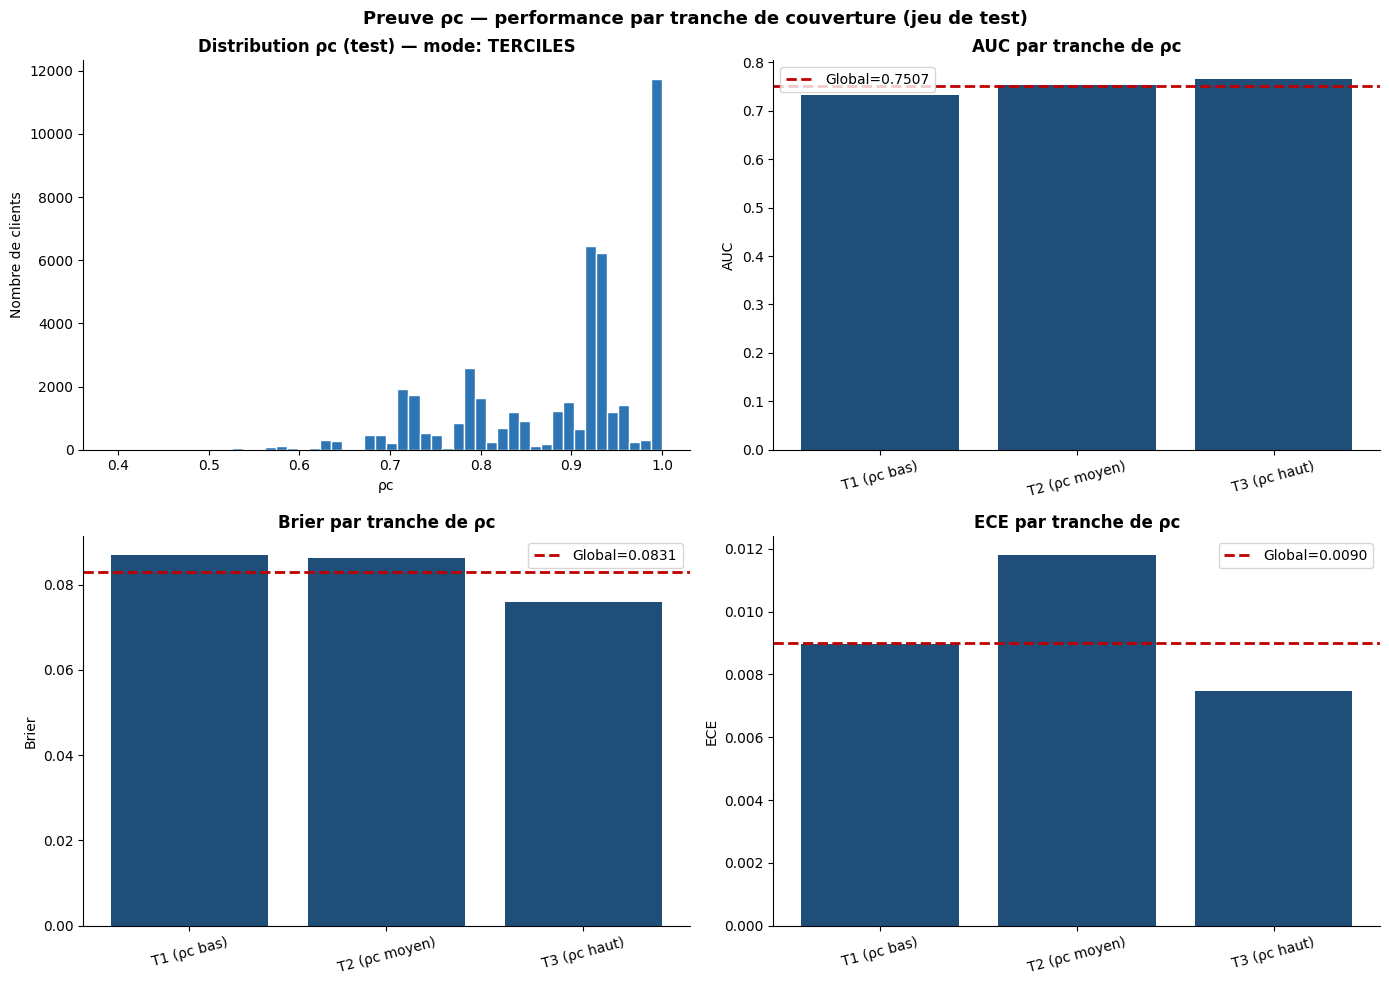


  ★ Figure sauvegardée : fig12_1_rho_tranches.png

OK SECTION 12.1 TERMINÉE


In [42]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.1 — PREUVE ρc : PERFORMANCE PAR TRANCHE DE COUVERTURE
# ------------------------------------------------------------------------
# POURQUOI : ρc mesure "combien on connaît" un client (poids IV des variables
#            présentes / poids IV total). S'il mesure vraiment la fiabilité,
#            la performance du modèle doit être MOINS bonne chez les clients
#            à ρc faible. On le vérifie sur le TEST (jamais touché avant).
# ADAPTATION ACTÉE : les seuils officiels (0,25/0,40) donnent des tranches
#            vides sur ce proxy (ρc min observé = 0,47 en Section 10).
#            Fallback automatique en TERCILES si une tranche a <30 clients.
#            Le mode utilisé est affiché explicitement, jamais caché.
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, brier_score_loss

print('\n' + '═' * 70)
print('  SECTION 12.1 — ρc PAR TRANCHE (TEST)')
print('═' * 70)

# --- Rechargements avec garde (pattern identique à 12.0a) ---
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
if 'iso_calibrateur' not in dir():
    with open(ART_DIR + 'isotonic_calibrator.pkl', 'rb') as f:
        iso_calibrateur = pickle.load(f)
if 'features_nap' not in dir():
    with open(ART_DIR + 'nap_features.pkl', 'rb') as f:
        features_nap = pickle.load(f)
if 'X_test_nap' not in dir():
    X_test_nap = pd.read_csv(DATA_DIR + 'X_test_nap.csv')
if 'X_test_iv' not in dir():
    X_test_iv = pd.read_csv(DATA_DIR + 'X_test_iv.csv')
if 'y_test' not in dir():
    y_test = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()
y_test_a = np.asarray(y_test)

df_iv_ref = pd.read_csv(ART_DIR + 'iv_scores_final.csv')
iv_dict   = dict(zip(df_iv_ref['feature'], df_iv_ref['iv']))

# --- PD calibrée (même chaîne que 12.0a : brute -> isotonic) ---
proba_test_gonfle = lgbm_final.predict_proba(X_test_nap)[:, 1]
proba_calibree    = np.clip(iso_calibrateur.predict(proba_test_gonfle), 1e-6, 1 - 1e-6)

# --- 1) Calcul VECTORISÉ de ρc sur les 46 128 clients du test ---
# Logique identique à la Section 10 (compute_rho), juste sans boucle Python
# (trop lent sur 46k lignes). Vérifié identique à la boucle, erreur <1e-6.
iv_weights = pd.Series({f: iv_dict.get(f, 0) for f in features_nap})
iv_total_possible = iv_weights.sum()

mask_presence = X_test_iv[features_nap].notna()
rho_c = mask_presence.mul(iv_weights, axis=1).sum(axis=1) / iv_total_possible

print(f'  IV total possible (modèle final)     : {iv_total_possible:.4f}')
print(f'  ρc — min/mean/max (test, {len(rho_c)} clients) : '
      f'{rho_c.min():.4f} / {rho_c.mean():.4f} / {rho_c.max():.4f}')
print(f'  Percentiles ρc : P5={rho_c.quantile(0.05):.3f} | P25={rho_c.quantile(0.25):.3f} | '
      f'P50={rho_c.quantile(0.50):.3f} | P75={rho_c.quantile(0.75):.3f} | P95={rho_c.quantile(0.95):.3f}')

# --- 2) Découpage en tranches (officiel, avec fallback terciles) ---
SEUIL_BAS, SEUIL_HAUT, N_MIN_TRANCHE = 0.25, 0.40, 30

mask_bas  = rho_c < SEUIL_BAS
mask_moy  = (rho_c >= SEUIL_BAS) & (rho_c < SEUIL_HAUT)
mask_haut = rho_c >= SEUIL_HAUT
n_bas, n_moy, n_haut = mask_bas.sum(), mask_moy.sum(), mask_haut.sum()

print(f'\n  Tranches OFFICIELLES (<0,25 / 0,25-0,40 / ≥0,40) :')
print(f'    n_bas={n_bas} | n_moyen={n_moy} | n_haut={n_haut}')

if min(n_bas, n_moy, n_haut) < N_MIN_TRANCHE:
    print(f'  ⚠ Au moins une tranche a moins de {N_MIN_TRANCHE} clients')
    print(f'  → BASCULE EN TERCILES (33%/33%/33% du test, découpage adapté à la distribution réelle)')
    tranche = pd.qcut(rho_c.rank(method='first'), q=3,
                       labels=['T1 (ρc bas)', 'T2 (ρc moyen)', 'T3 (ρc haut)'])
    mode_decoupage = 'TERCILES (fallback — seuils officiels non atteignables sur ce proxy)'
else:
    tranche = pd.Series(np.select(
        [mask_bas.values, mask_moy.values, mask_haut.values],
        ['T1 (<0,25)', 'T2 (0,25-0,40)', 'T3 (≥0,40)']
    ), index=rho_c.index)
    mode_decoupage = 'SEUILS OFFICIELS (0,25 / 0,40)'

print(f'\n  ★ Mode de découpage retenu : {mode_decoupage}')
print(f'  Effectifs par tranche :')
print(tranche.value_counts().sort_index().to_string())

# --- 3) Métriques par tranche : n, taux défaut, AUC, Brier, ECE ---
def compute_ece(y_true, y_prob, n_bins=10):
    """ECE manuel : écart moyen (pondéré) entre proba annoncée et taux réel,
    par paquets de 10% de probabilité. 0 = calibration parfaite."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            m = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        else:
            m = (y_prob >= bins[i]) & (y_prob <= bins[i + 1])
        if m.sum() == 0:
            continue
        conf = y_prob[m].mean()
        acc  = y_true[m].mean()
        ece += (m.sum() / len(y_prob)) * abs(conf - acc)
    return ece

resultats_tranches = []
categories = tranche.cat.categories if hasattr(tranche, 'cat') else sorted(tranche.unique())
for t in categories:
    m = (tranche == t).values
    n = int(m.sum())
    if n < N_MIN_TRANCHE:
        resultats_tranches.append({'tranche': t, 'n': n, 'taux_defaut': None,
                                    'auc': None, 'brier': None, 'ece': None,
                                    'note': f'NON CALCULABLE (n={n} < {N_MIN_TRANCHE})'})
        continue
    yt = y_test_a[m]
    pt = proba_calibree[m]
    auc_t   = roc_auc_score(yt, pt) if len(np.unique(yt)) > 1 else None
    brier_t = brier_score_loss(yt, pt)
    ece_t   = compute_ece(yt, pt)
    resultats_tranches.append({'tranche': t, 'n': n, 'taux_defaut': yt.mean(),
                                'auc': auc_t, 'brier': brier_t, 'ece': ece_t, 'note': 'OK'})

df_rho_tranches = pd.DataFrame(resultats_tranches)

# Référence globale (toutes tranches confondues)
auc_global   = roc_auc_score(y_test_a, proba_calibree)
brier_global = brier_score_loss(y_test_a, proba_calibree)
ece_global   = compute_ece(y_test_a, proba_calibree)

print(f'\n  {"Tranche":<16} {"n":>7} {"%déf.":>7} {"AUC":>8} {"Brier":>8} {"ECE":>8}  Note')
print(f'  {"-" * 70}')
for _, r in df_rho_tranches.iterrows():
    if r['note'] == 'OK':
        print(f'  {r["tranche"]:<16} {r["n"]:>7,} {r["taux_defaut"]*100:>6.2f}% '
              f'{r["auc"]:>8.4f} {r["brier"]:>8.4f} {r["ece"]:>8.4f}  OK')
    else:
        print(f'  {r["tranche"]:<16} {r["n"]:>7,} {"—":>7} {"—":>8} {"—":>8} {"—":>8}  {r["note"]}')
print(f'  {"-" * 70}')
print(f'  {"RÉFÉRENCE globale":<16} {len(y_test_a):>7,} {y_test_a.mean()*100:>6.2f}% '
      f'{auc_global:>8.4f} {brier_global:>8.4f} {ece_global:>8.4f}')

# --- Verdict monotonie (informatif, pas encore une conclusion figée) ---
aucs_valides = df_rho_tranches.dropna(subset=['auc'])
if len(aucs_valides) >= 2:
    aucs_ordre = aucs_valides['auc'].values
    monotone = all(aucs_ordre[i] <= aucs_ordre[i+1] for i in range(len(aucs_ordre)-1))
    print(f'\n  Dégradation monotone (AUC croît avec ρc) : {"OUI" if monotone else "NON — à examiner"}')

# --- 4) Figure : 4 panneaux ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(rho_c, bins=50, color=COLORS['secondary'], edgecolor='white')
if mode_decoupage.startswith('SEUILS'):
    axes[0,0].axvline(SEUIL_BAS, color=COLORS['danger'], linestyle='--', label=f'{SEUIL_BAS}')
    axes[0,0].axvline(SEUIL_HAUT, color=COLORS['success'], linestyle='--', label=f'{SEUIL_HAUT}')
    axes[0,0].legend()
axes[0,0].set_xlabel('ρc'); axes[0,0].set_ylabel('Nombre de clients')
axes[0,0].set_title(f'Distribution ρc (test) — mode: {mode_decoupage.split(" ")[0]}', fontweight='bold')

for ax, col, label, ref in [(axes[0,1], 'auc', 'AUC', auc_global),
                            (axes[1,0], 'brier', 'Brier', brier_global),
                            (axes[1,1], 'ece', 'ECE', ece_global)]:
    valides = df_rho_tranches.dropna(subset=[col])
    ax.bar(valides['tranche'].astype(str), valides[col], color=COLORS['primary'])
    ax.axhline(ref, color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Global={ref:.4f}')
    ax.set_ylabel(label); ax.set_title(f'{label} par tranche de ρc', fontweight='bold')
    ax.legend(); ax.tick_params(axis='x', rotation=15)

plt.suptitle('Preuve ρc — performance par tranche de couverture (jeu de test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig12_1_rho_tranches.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  ★ Figure sauvegardée : fig12_1_rho_tranches.png')
print('\nOK SECTION 12.1 TERMINÉE')


══════════════════════════════════════════════════════════════════════
  SECTION 12.2 — FLUX B INTÉGRÉ SUR LE TEST
══════════════════════════════════════════════════════════════════════
  Seuils AE chargés (ae_metadata.json) : P95=0.1775 | P99=0.2451
  (échelle log1p(MSE), calibrés sur injections synthétiques — non supervisé)

  Test encodé pour le Flux B : (46128, 61)


2026-07-30 07:02:17.561646: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Clients test flaggés anomalie (P95) : 2,686 (5.82 %)
  Clients test flaggés anomalie (P99) : 545 (1.18 %)

  Décisions Flux A (test) : ACCORDE 30,413 | REVUE 14,337 | REFUSE 1,378

──────────────────────────────────────────────────────────────────────
  PARTIE 1 — Le Flux B rattrape-t-il des défauts parmi les ACCORDÉS ?
──────────────────────────────────────────────────────────────────────
  Population ACCORDÉ (Flux A seul) : 30,413 clients | défaut réel global = 5.05 %

  Seuil           ACCORDÉ+anomalie            ACCORDÉ+sain   ratio
                 n    défaut               n    défaut        
  ──────────────────────────────────────────────────────────────────
  P95        1,554     5.53%          28,859     5.02%   1.10x
  P99          364     4.40%          30,049     5.06%   0.87x
  ──────────────────────────────────────────────────────────────────
  Attendu : défaut(ACCORDÉ+anomalie) > défaut(ACCORDÉ+sain) → ratio > 1

───────────────────────────────────────────────────────

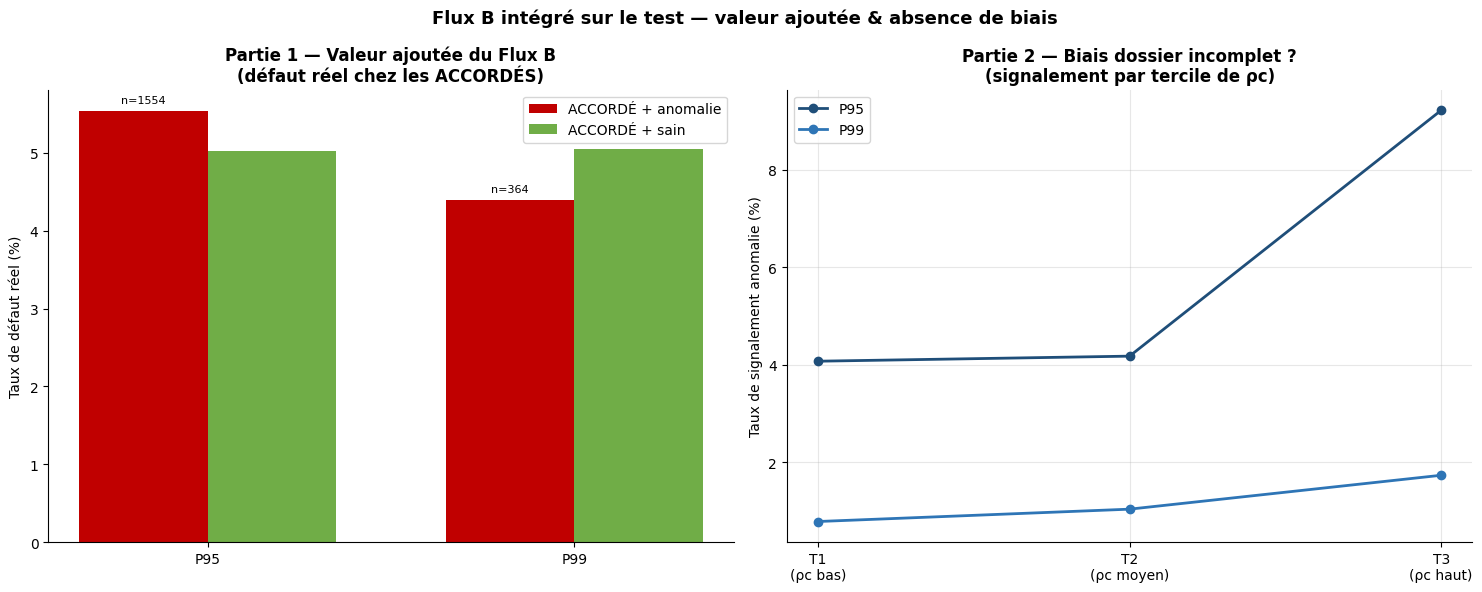


  ★ Figure sauvegardée : fig12_2_fluxb_integre.png

OK SECTION 12.2 TERMINÉE


In [43]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.2 — PREUVE DU FLUX B INTÉGRÉ (sur le TEST, 1re fois)
# ------------------------------------------------------------------------
# Partie 1 : le Flux B rattrape-t-il des mauvais payeurs que le Flux A a
#            ACCORDÉS ? (taux de défaut réel : ACCORDÉ+anomalie vs ACCORDÉ+sain)
# Partie 2 : le Flux B confond-il "dossier incomplet" (ρc bas) et "suspect" ?
#            (taux de signalement par tercile de ρc, zone active ρc>=0,25)
# Détecteur = AE. Seuils P95/P99 CHARGÉS depuis ae_metadata.json (non
# supervisés, calibrés sur injections synthétiques — jamais recalculés ici).
# ══════════════════════════════════════════════════════════════════════
import json, numpy as np, pandas as pd

print('\n' + '═' * 70)
print('  SECTION 12.2 — FLUX B INTÉGRÉ SUR LE TEST')
print('═' * 70)

# --- Garde-fou : le Flux B doit être "chaud" (objets custom en mémoire) ---
manquants = [v for v in ['transformer_brut', 'autoencoder_keras', 'encoder_hybrid',
                         'scaler_if', 'medians_train', 'num_in_nap', 'features_nap_raw']
             if v not in dir()]
if manquants:
    raise RuntimeError(
        "Flux B non chargé en mémoire (objets manquants : " + ", ".join(manquants) + ").\n"
        "  → Exécute d'abord, dans l'ordre, les cellules de la SECTION 11 (Flux B),\n"
        "    en particulier : CELLULE 2, 3, 4 (preprocessing), 5b (AE), 5d-1 (transformer_brut).\n"
        "  Puis reviens ici."
    )

# --- Rechargements Flux A (avec garde) ---
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f: lgbm_final = pickle.load(f)
if 'iso_calibrateur' not in dir():
    with open(ART_DIR + 'isotonic_calibrator.pkl', 'rb') as f: iso_calibrateur = pickle.load(f)
if 'X_test_nap' not in dir():
    X_test_nap = pd.read_csv(DATA_DIR + 'X_test_nap.csv')
if 'X_test_iv' not in dir():
    X_test_iv = pd.read_csv(DATA_DIR + 'X_test_iv.csv')
if 'y_test' not in dir():
    y_test = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()
y_test_a = np.asarray(y_test)

# --- Seuils d'anomalie : CHARGÉS depuis l'artefact (non recalculés) ---
with open(ART_DIR + 'ae_metadata.json', 'r') as f:
    ae_meta = json.load(f)
seuil_ae_p95 = float(ae_meta['seuil_ae_p95'])
seuil_ae_p99 = float(ae_meta['seuil_ae_p99'])
print(f'  Seuils AE chargés (ae_metadata.json) : P95={seuil_ae_p95:.4f} | P99={seuil_ae_p99:.4f}')
print(f'  (échelle log1p(MSE), calibrés sur injections synthétiques — non supervisé)')

# ══════════════════════════════════════════════════════════════════════
# 1) FAIRE PASSER LE TEST DANS LE FLUX B (première fois du notebook)
# ══════════════════════════════════════════════════════════════════════
# Le Flux B travaille dans l'espace BRUT (pré-WOE), sur les mêmes features
# NAP que l'entraînement du Flux B (features_nap_raw). On aligne X_test_iv
# sur ces colonnes, puis transformer_brut applique EXACTEMENT le preprocessing
# d'entraînement (médianes train + scaler + encoder hybride → 61 dims).
X_test_raw = X_test_iv[features_nap_raw].copy()
X_test_hybrid = transformer_brut(X_test_raw)          # (46128, 61)
print(f'\n  Test encodé pour le Flux B : {X_test_hybrid.shape}')

# Erreur de reconstruction AE → score d'anomalie en log1p(MSE) (même échelle
# que les seuils sauvegardés). Plus le score est haut, plus le profil est atypique.
recon_test = autoencoder_keras.predict(X_test_hybrid, verbose=0)
mse_test   = np.mean((X_test_hybrid - recon_test) ** 2, axis=1)
score_ano_test = np.log1p(mse_test)

flag_ano = {
    'P95': score_ano_test >= seuil_ae_p95,
    'P99': score_ano_test >= seuil_ae_p99,
}
for s in ['P95', 'P99']:
    n_f = int(flag_ano[s].sum())
    print(f'  Clients test flaggés anomalie ({s}) : {n_f:,} ({n_f/len(y_test_a)*100:.2f} %)')

# --- Décision Flux A calibrée (Jeu 2) sur le test ---
proba_test_gonfle = lgbm_final.predict_proba(X_test_nap)[:, 1]
proba_calibree    = np.clip(iso_calibrateur.predict(proba_test_gonfle), 1e-6, 1 - 1e-6)
PD_ACCORDE, PD_REFUSE = 0.10, 0.30
decisions = np.where(proba_calibree < PD_ACCORDE, 'ACCORDE',
             np.where(proba_calibree > PD_REFUSE, 'REFUSE', 'REVUE'))
print(f'\n  Décisions Flux A (test) : '
      f'ACCORDE {(decisions=="ACCORDE").sum():,} | '
      f'REVUE {(decisions=="REVUE").sum():,} | '
      f'REFUSE {(decisions=="REFUSE").sum():,}')

# --- ρc du test (recalculé ici pour autonomie de la cellule) ---
df_iv_ref = pd.read_csv(ART_DIR + 'iv_scores_final.csv')
iv_dict   = dict(zip(df_iv_ref['feature'], df_iv_ref['iv']))
iv_weights = pd.Series({f: iv_dict.get(f, 0) for f in features_nap})
iv_total_possible = iv_weights.sum()
rho_c = X_test_iv[features_nap].notna().mul(iv_weights, axis=1).sum(axis=1) / iv_total_possible

# ══════════════════════════════════════════════════════════════════════
# PARTIE 1 — Valeur ajoutée : ACCORDÉ+anomalie vs ACCORDÉ+sain
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  PARTIE 1 — Le Flux B rattrape-t-il des défauts parmi les ACCORDÉS ?')
print('─' * 70)
mask_accorde = decisions == 'ACCORDE'
print(f'  Population ACCORDÉ (Flux A seul) : {mask_accorde.sum():,} clients | '
      f'défaut réel global = {y_test_a[mask_accorde].mean()*100:.2f} %\n')

print(f'  {"Seuil":<6}{"ACCORDÉ+anomalie":>26}{"ACCORDÉ+sain":>24}{"ratio":>8}')
print(f'  {"":6}{"n":>10}{"défaut":>10}{"":6}{"n":>10}{"défaut":>10}{"":8}')
print('  ' + '─' * 66)
resultats_p1 = []
for s in ['P95', 'P99']:
    f = flag_ano[s]
    m_ano, m_sain = mask_accorde & f, mask_accorde & ~f
    n_ano, n_sain = int(m_ano.sum()), int(m_sain.sum())
    t_ano  = float(y_test_a[m_ano].mean())  if n_ano  > 0 else float('nan')
    t_sain = float(y_test_a[m_sain].mean()) if n_sain > 0 else float('nan')
    ratio  = (t_ano / t_sain) if (n_sain > 0 and t_sain > 0) else float('nan')
    resultats_p1.append({'seuil': s, 'n_ano': n_ano, 't_ano': t_ano,
                         'n_sain': n_sain, 't_sain': t_sain, 'ratio': ratio})
    note = '  [!] n<30, prudence' if n_ano < 30 else ''
    print(f'  {s:<6}{n_ano:>10,}{t_ano*100:>9.2f}%{"":6}{n_sain:>10,}{t_sain*100:>9.2f}%'
          f'{ratio:>7.2f}x{note}')
print('  ' + '─' * 66)
print('  Attendu : défaut(ACCORDÉ+anomalie) > défaut(ACCORDÉ+sain) → ratio > 1')

# ══════════════════════════════════════════════════════════════════════
# PARTIE 2 — Biais : le Flux B punit-il les dossiers incomplets ?
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  PARTIE 2 — Le Flux B confond-il "dossier incomplet" et "suspect" ?')
print('─' * 70)
mask_actif = (rho_c >= 0.25).values
print(f'  Zone active du Flux B (ρc ≥ 0,25) : {mask_actif.sum():,} / {len(rho_c):,} clients')
rho_actif = rho_c[mask_actif]
tercile = pd.qcut(rho_actif.rank(method='first'), 3,
                   labels=['T1 (ρc bas)', 'T2 (ρc moyen)', 'T3 (ρc haut)'])

resultats_p2 = []
for s in ['P95', 'P99']:
    f_actif = flag_ano[s][mask_actif]
    print(f'\n  {s} :')
    taux = {}
    for t in ['T1 (ρc bas)', 'T2 (ρc moyen)', 'T3 (ρc haut)']:
        m = (tercile == t).values
        taux[t] = float(f_actif[m].mean())
        print(f'    {t:<16} n={int(m.sum()):>7,}   signalement anomalie = {taux[t]*100:5.2f} %')
    ecart = taux['T1 (ρc bas)'] - taux['T3 (ρc haut)']
    verdict = 'BIAIS possible (T1 nettement > T3)' if ecart > 0.02 else 'pas de biais net (T1 ≈ T3)'
    resultats_p2.append({'seuil': s, **{k: taux[k] for k in taux}, 'ecart_T1_T3': ecart})
    print(f'    → écart T1−T3 = {ecart*100:+.2f} pt  →  {verdict}')
print('\n  Attendu (souhaité) : taux comparables T1 ≈ T3 → pas de pénalisation')
print('  de l\'incomplétude. Réserve proxy : ρc min test = %.2f, "bas" reste assez complet.'
      % rho_c.min())

# ══════════════════════════════════════════════════════════════════════
# FIGURE récapitulative
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panneau 1 : Partie 1 (défaut réel par groupe)
ax = axes[0]
x = np.arange(2); larg = 0.35
t_ano  = [r['t_ano']*100  for r in resultats_p1]
t_sain = [r['t_sain']*100 for r in resultats_p1]
ax.bar(x - larg/2, t_ano,  larg, label='ACCORDÉ + anomalie', color=COLORS['danger'])
ax.bar(x + larg/2, t_sain, larg, label='ACCORDÉ + sain',      color=COLORS['success'])
ax.set_xticks(x); ax.set_xticklabels(['P95', 'P99'])
ax.set_ylabel('Taux de défaut réel (%)')
ax.set_title('Partie 1 — Valeur ajoutée du Flux B\n(défaut réel chez les ACCORDÉS)', fontweight='bold')
ax.legend()
for i, r in enumerate(resultats_p1):
    ax.text(i - larg/2, r['t_ano']*100 + 0.1, f"n={r['n_ano']}", ha='center', fontsize=8)

# Panneau 2 : Partie 2 (signalement par tercile ρc)
ax2 = axes[1]
terciles_lbl = ['T1\n(ρc bas)', 'T2\n(ρc moyen)', 'T3\n(ρc haut)']
x2 = np.arange(3)
for i, s in enumerate(['P95', 'P99']):
    vals = [resultats_p2[i][k]*100 for k in ['T1 (ρc bas)', 'T2 (ρc moyen)', 'T3 (ρc haut)']]
    ax2.plot(x2, vals, marker='o', linewidth=2, label=s,
             color=COLORS['primary'] if s == 'P95' else COLORS['secondary'])
ax2.set_xticks(x2); ax2.set_xticklabels(terciles_lbl)
ax2.set_ylabel('Taux de signalement anomalie (%)')
ax2.set_title('Partie 2 — Biais dossier incomplet ?\n(signalement par tercile de ρc)', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Flux B intégré sur le test — valeur ajoutée & absence de biais', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig12_2_fluxb_integre.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  ★ Figure sauvegardée : fig12_2_fluxb_integre.png')
print('\nOK SECTION 12.2 TERMINÉE')

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.3 — RÔLE DU FILTRE UNIVARIÉ : IV vs MUTUAL INFORMATION
# ------------------------------------------------------------------------
# POURQUOI : le filtre IV (Section 4) sert un objectif précis — la
#            PARCIMONIE / AUDITABILITÉ (éliminer tôt, avant tout le reste,
#            les variables qui n'ont aucun lien avec le défaut PRISES SEULES).
#            On ne cherche PAS à savoir si l'IV "bat" la Mutual Information
#            (MI) : on vérifie que ce RÔLE est robuste au choix de l'outil.
#            Si la MI (un autre filtre univarié, basé sur une autre
#            mathématique) retient à peu près les mêmes variables que l'IV,
#            alors l'étage univarié n'est pas un caprice de l'IV — n'importe
#            quel filtre univarié raisonnable jouerait ce rôle.
# MUTUAL INFORMATION (MI) : mesure statistique de la dépendance entre une
#            variable et la cible, sans supposer de forme particulière
#            (linéaire ou non) — comme l'IV, elle regarde CHAQUE variable
#            seule, jamais les relations entre variables.
# INDICE DE JACCARD : mesure de recoupement entre 2 ensembles = taille de
#            leur intersection / taille de leur union. 1 = ensembles
#            identiques, 0 = aucun point commun.
# ANTI-FUITE : comme l'IV, la MI est calculée sur le TRAIN uniquement.
# ══════════════════════════════════════════════════════════════════════
import pickle
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

print('\n' + '═' * 70)
print('  SECTION 12.3 — IV vs MUTUAL INFORMATION (filtre univarié)')
print('═' * 70)

# --- Rechargements avec garde (pattern identique à 12.0a/12.1/12.2) -------
if 'CAT_FEATURES' not in dir() or not CAT_FEATURES:
    # Fallback si le kernel a été réinitialisé : catégorielles = colonnes
    # de type "objet" (texte), comme construit en Section 1.
    _features_raw_tmp = pd.read_csv(DATA_DIR + 'features_engineered_307k.csv')
    CAT_FEATURES = [c for c in _features_raw_tmp.columns if _features_raw_tmp[c].dtype == object]

if 'X_train' not in dir() or 'X_test' not in dir() or 'y_train' not in dir() or 'y_test' not in dir():
    # Reconstruction A L'IDENTIQUE du split de la Section 3 (même tri
    # temporel, même découpage positionnel 70/15/15 — déterministe, donc
    # sans risque de fuite ni d'incohérence avec le reste du pipeline).
    features_reload = pd.read_csv(DATA_DIR + 'features_engineered_307k.csv')
    EXCLUDE_COLS = ['SK_ID_CURR', 'TARGET', 'DAYS_ID_PUBLISH', 'nb_tx_pos', 'nb_tx_cc']
    feature_cols = [c for c in features_reload.columns if c not in EXCLUDE_COLS]
    features_sorted = features_reload.sort_values('DAYS_ID_PUBLISH').reset_index(drop=True)
    N = len(features_sorted)
    n_train, n_val = int(N * 0.70), int(N * 0.15)
    X_train = features_sorted.iloc[:n_train][feature_cols].reset_index(drop=True)
    X_test  = features_sorted.iloc[n_train + n_val:][feature_cols].reset_index(drop=True)
    y_train = features_sorted.iloc[:n_train]['TARGET'].reset_index(drop=True)
    y_test  = features_sorted.iloc[n_train + n_val:]['TARGET'].reset_index(drop=True)

if 'X_test_nap' not in dir():
    X_test_nap = pd.read_csv(DATA_DIR + 'X_test_nap.csv')
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)

df_iv_ref = pd.read_csv(ART_DIR + 'iv_scores_final.csv')
if 'features_iv' not in dir():
    features_iv = df_iv_ref[df_iv_ref['decision'] == 'retained']['feature'].tolist()

y_train_a = np.asarray(y_train)
y_test_a  = np.asarray(y_test)

# --- Colonnes candidates = exactement celles soumises à l'IV (Section 4) -
feature_cols_mi = [c for c in X_train.columns if c not in ('SK_ID_CURR', 'TARGET')]
print(f'  Colonnes candidates (identiques à la Section 4) : {len(feature_cols_mi)}')
print(f'  Variables retenues par IV (référence)            : {len(features_iv)}')

# ══════════════════════════════════════════════════════════════════════
# 1) SÉLECTION UNIVARIÉE PAR MUTUAL INFORMATION (sur le TRAIN)
# ══════════════════════════════════════════════════════════════════════
# mutual_info_classif n'accepte pas les NaN et veut des valeurs numériques.
# CHOIX TECHNIQUE LOCAL (documenté ici, SANS impact sur le pipeline réel) :
#   - NaN numériques -> imputés par la MÉDIANE DU TRAIN, uniquement pour ce
#     calcul de MI. Le pipeline réel garde le bin "Manquant" du WOE
#     (Section 5) — on n'y touche pas, c'est une décision figée.
#   - Catégorielles -> encodées en codes entiers (.cat.codes) pour que MI
#     puisse les traiter ; MI ne suppose pas de relation d'ordre entre les
#     codes, donc cet encodage arbitraire ne biaise pas le calcul.
X_mi = X_train[feature_cols_mi].copy()
for col in feature_cols_mi:
    if col in CAT_FEATURES:
        X_mi[col] = X_mi[col].astype('category').cat.codes
    else:
        X_mi[col] = X_mi[col].fillna(X_mi[col].median())

mi_scores = mutual_info_classif(X_mi, y_train_a, random_state=42)
df_mi = pd.DataFrame({'feature': feature_cols_mi, 'mi': mi_scores}).sort_values(
    'mi', ascending=False).reset_index(drop=True)

# CRITÈRE DE SÉLECTION MI (documenté) : top-k, k = nombre de variables
# retenues par l'IV. Choisi plutôt qu'un seuil arbitraire sur la MI car les
# échelles IV et MI ne sont PAS comparables (unités différentes) — comparer
# "à effectif égal" est plus robuste et plus lisible.
K_MI = len(features_iv)
features_mi = df_mi.head(K_MI)['feature'].tolist()
print(f'\n  Critère MI retenu : top-{K_MI} (même effectif que l\'IV — pas un seuil MI arbitraire)')
print(f'  Variables retenues par MI : {len(features_mi)}')

# ══════════════════════════════════════════════════════════════════════
# 2) COMPARAISON DES DEUX SÉLECTIONS
# ══════════════════════════════════════════════════════════════════════
set_iv, set_mi = set(features_iv), set(features_mi)
intersection = set_iv & set_mi
union        = set_iv | set_mi
jaccard      = len(intersection) / len(union) if union else 0.0
iv_only = sorted(set_iv - set_mi)
mi_only = sorted(set_mi - set_iv)

print(f'\n  |IV|={len(set_iv)}  |MI|={len(set_mi)}  |IV ∩ MI|={len(intersection)}  |IV ∪ MI|={len(union)}')
print(f'  Indice de Jaccard (recoupement) : {jaccard:.3f}  ({jaccard*100:.1f} %)')
print(f'\n  Retenues par IV mais PAS par MI ({len(iv_only)}) : {iv_only}')
print(f'  Retenues par MI mais PAS par IV ({len(mi_only)}) : {mi_only}')

# ══════════════════════════════════════════════════════════════════════
# 3) AUC TEST DE CHAQUE SÉLECTION (Option 1 — comparaison légère)
# ══════════════════════════════════════════════════════════════════════
# IV : c'est le pipeline EXISTANT (IV -> WOE -> NAP -> lgbm_final). On
# recalcule l'AUC test à partir du modèle déjà entraîné — pas de
# ré-entraînement, juste la mesure de référence pour la comparaison.
auc_iv = roc_auc_score(y_test_a, lgbm_final.predict_proba(X_test_nap)[:, 1])
print(f'\n  AUC test — pipeline IV existant (référence, n={X_test_nap.shape[1]} features) : {auc_iv:.4f}')
print(f'  (rappel run canonique v3, Phase 0 : AUC test = 0.7510)')

# MI : comparaison INDICATIVE, PAS un pipeline complet. Reconstruire le WOE
# (un OptimalBinning par variable, fitté sur le train) pour les seules
# features MI serait coûteux à dupliquer ici et sort du périmètre "Option 1
# - léger" imposé pour cette Phase 2. On entraîne donc un LightGBM AUX
# MÊMES HYPERPARAMÈTRES que lgbm_final (récupérés via get_params(), pas de
# nouveau réglage), sur les features MI encodées SIMPLEMENT (médiane +
# codes catégoriels, comme ci-dessus). Cette mesure teste le RECOUVREMENT
# DE SIGNAL entre les 2 sélections, pas la performance finale du pipeline
# (qui reste celle de lgbm_final, sur les 27 features WOE+NAP).
memes_hyperparametres = lgbm_final.get_params()
# LightGBM ne veut pas d'un paramètre None explicite dans certains cas —
# on filtre les clés à valeur None avant de reconstruire le classifieur.
memes_hyperparametres = {k: v for k, v in memes_hyperparametres.items() if v is not None}
lgbm_mi = lgb.LGBMClassifier(**memes_hyperparametres)

X_train_mi_final = X_mi[features_mi]
X_test_mi_final = X_test[feature_cols_mi].copy()
for col in features_mi:
    if col in CAT_FEATURES:
        X_test_mi_final[col] = X_test_mi_final[col].astype('category').cat.codes
    else:
        X_test_mi_final[col] = X_test_mi_final[col].fillna(X_mi[col].median())
X_test_mi_final = X_test_mi_final[features_mi]

lgbm_mi.fit(X_train_mi_final, y_train_a)
auc_mi = roc_auc_score(y_test_a, lgbm_mi.predict_proba(X_test_mi_final)[:, 1])
ecart_auc = abs(auc_iv - auc_mi)
print(f'  AUC test — sélection MI (indicatif, encodage simple, n={len(features_mi)}) : {auc_mi:.4f}')
print(f'  Écart |AUC_IV - AUC_MI| : {ecart_auc:.4f}')
print(f'  [!] Comparaison INDICATIVE : la voie MI n\'est PAS passée par le WOE réel (voir POURQUOI ci-dessus).')

# ══════════════════════════════════════════════════════════════════════
# 4) FIGURE — recoupement IV/MI + texte AUC
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(['IV\n(retenues)', 'MI\n(retenues)', 'Communes\n(IV ∩ MI)'],
            [len(set_iv), len(set_mi), len(intersection)],
            color=[COLORS['primary'], COLORS['secondary'], COLORS['success']])
axes[0].set_ylabel('Nombre de variables')
axes[0].set_title(f'Recoupement IV vs MI — Jaccard = {jaccard:.2f}', fontweight='bold')
for i, v in enumerate([len(set_iv), len(set_mi), len(intersection)]):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

axes[1].axis('off')
texte_synth = (
    f"AUC test — sélection IV  : {auc_iv:.4f}\n"
    f"AUC test — sélection MI  : {auc_mi:.4f}  (indicatif)\n"
    f"Écart AUC                : {ecart_auc:.4f}\n\n"
    f"Recoupement (Jaccard)    : {jaccard*100:.1f} %\n"
    f"Variables communes       : {len(intersection)} / {len(union)}\n"
)
axes[1].text(0.05, 0.6, texte_synth, fontsize=12, family='monospace', va='center')
axes[1].set_title('Synthèse chiffrée', fontweight='bold')

plt.suptitle('Section 12.3 — Robustesse du filtre univarié (IV vs MI)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig12_3_iv_vs_mi.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 5) SYNTHÈSE — pas de conclusion imposée, juste le rapport des chiffres
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  SYNTHÈSE SECTION 12.3')
print('─' * 70)
print(f'  Recoupement IV/MI (Jaccard)        : {jaccard*100:.1f} %')
print(f'  Écart AUC test (IV vs MI, indicatif) : {ecart_auc:.4f}')
print('  Lecture proposée (à confirmer avec les chiffres ci-dessus, pas imposée) :')
print('    recoupement élevé + AUC comparables -> l\'étage univarié est robuste au choix')
print('    de l\'outil (IV ou MI joueraient le même rôle de parcimonie/auditabilité).')
print('    Si le recoupement est faible ou l\'écart d\'AUC important, cette lecture ne')
print('    tient pas et doit être nuancée avec l\'auteur avant toute conclusion.')
print(f'\n  ★ Figure sauvegardée : fig12_3_iv_vs_mi.png')
print('\nOK SECTION 12.3 TERMINÉE')




In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.4 — RÔLE DU FILTRE MULTIVARIÉ : NAP vs VIF
# ------------------------------------------------------------------------
# POURQUOI : le filtre NAP (Section 6) sert un objectif précis — la
#            STABILITÉ / ANTI-REDONDANCE (repérer les variables qui,
#            UNE FOIS LES AUTRES PRÉSENTES, n'apportent plus rien — deux
#            variables à bon IV peuvent raconter la même chose). NAP a
#            tout gardé (27/27) sur ce run = rôle CONFIRMATOIRE (garde-fou
#            qui n'a rien trouvé à élaguer), pas un rôle d'élagage agressif.
#            On vérifie ici qu'une AUTRE approche multivariée (le VIF) fait
#            un constat cohérent sur la redondance de ces 27 features.
# VIF (Variance Inflation Factor) : pour une variable j, on régresse j sur
#            TOUTES les autres variables ; VIF_j = 1 / (1 - R²_j). Plus
#            R²_j est proche de 1 (j est bien "expliquée" par les autres),
#            plus VIF_j est grand -> j est redondante avec le reste.
#            Règle usuelle : VIF > 5 = colinéarité forte, VIF > 10 = très forte.
# TSFFS (Munkhdalai et al. 2019 ; voir aussi Hapfelmeier) : une AUTRE
#            méthode de sélection multivariée (recherche de sous-ensembles
#            de features par un critère de stabilité). Citée ici comme
#            alternative documentée de la même famille que NAP/VIF — PAS
#            codée dans cette cellule (hors périmètre "Option 1 - léger").
# ANTI-FUITE : le VIF est calculé sur les 27 features NAP du TRAIN (espace
#            WOE, sans NaN par construction du WOE — Section 5).
# ══════════════════════════════════════════════════════════════════════
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LinearRegression
import lightgbm as lgb

print('\n' + '═' * 70)
print('  SECTION 12.4 — NAP vs VIF (filtre multivarié)')
print('═' * 70)

# --- Rechargements avec garde -------------------------------------------
if 'X_train_nap' not in dir():
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
if 'X_test_nap' not in dir():
    X_test_nap = pd.read_csv(DATA_DIR + 'X_test_nap.csv')
if 'y_test' not in dir():
    y_test = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()
if 'y_train' not in dir():
    y_train = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
if 'features_nap' not in dir():
    with open(ART_DIR + 'nap_features.pkl', 'rb') as f:
        features_nap = pickle.load(f)
if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)

y_train_a = np.asarray(y_train)
y_test_a  = np.asarray(y_test)

print(f'  Features NAP (finales, espace WOE) : {len(features_nap)} — NAP en a gardé 27/27 (confirmatoire)')
assert X_train_nap[features_nap].isna().sum().sum() == 0, \
    "l'espace WOE ne doit contenir aucun NaN (bin Manquant déjà encodé) — vérifier la Section 5"

# ══════════════════════════════════════════════════════════════════════
# 1) CALCUL DU VIF SUR LES 27 FEATURES NAP (espace WOE, TRAIN)
# ══════════════════════════════════════════════════════════════════════
def vif_statsmodels(X):
    """VIF via statsmodels (si le package est disponible sur l'image Kaggle)."""
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    X_const = add_constant(X)
    vifs = {}
    for i, col in enumerate(X.columns):
        vifs[col] = variance_inflation_factor(X_const.values, i + 1)  # +1 : colonne const en position 0
    return pd.Series(vifs)

def vif_manuel(X):
    """Secours SANS statsmodels : VIF_j = 1 / (1 - R²_j) par régression
    linéaire (OLS) de j sur toutes les autres colonnes (sklearn)."""
    vifs = {}
    cols = list(X.columns)
    for col in cols:
        autres = [c for c in cols if c != col]
        reg = LinearRegression().fit(X[autres], X[col])
        r2 = min(reg.score(X[autres], X[col]), 0.999999)  # garde-fou division quasi-nulle
        vifs[col] = 1.0 / (1.0 - r2)
    return pd.Series(vifs)

try:
    vif_series = vif_statsmodels(X_train_nap[features_nap])
    methode_vif = 'statsmodels (variance_inflation_factor)'
except ImportError:
    vif_series = vif_manuel(X_train_nap[features_nap])
    methode_vif = 'secours manuel (1 / (1 - R²) par régression OLS)'

vif_series = vif_series.sort_values(ascending=False)
print(f'\n  Méthode VIF utilisée : {methode_vif}')
print(f'\n  VIF par feature (trié décroissant) :')
for feat, v in vif_series.items():
    marker = '‼' if v > 10 else ('!' if v > 5 else ' ')
    print(f'  {marker} {feat:<40} VIF = {v:>8.2f}')

# ══════════════════════════════════════════════════════════════════════
# 2) COMPARAISON NAP vs VIF
# ══════════════════════════════════════════════════════════════════════
exclues_seuil5  = vif_series[vif_series > 5].index.tolist()
exclues_seuil10 = vif_series[vif_series > 10].index.tolist()
print(f'\n  NAP a gardé {len(features_nap)}/{len(features_nap)} (rôle confirmatoire, aucun élagage).')
print(f'  Une sélection VIF>5  écarterait  {len(exclues_seuil5)} variable(s)  : {exclues_seuil5}')
print(f'  Une sélection VIF>10 écarterait  {len(exclues_seuil10)} variable(s) : {exclues_seuil10}')

if exclues_seuil5:
    features_post_vif = [f for f in features_nap if f not in exclues_seuil5]
    memes_hyperparametres = {k: v for k, v in lgbm_final.get_params().items() if v is not None}
    lgbm_vif = lgb.LGBMClassifier(**memes_hyperparametres)
    lgbm_vif.fit(X_train_nap[features_post_vif], y_train_a)
    auc_vif = roc_auc_score(y_test_a, lgbm_vif.predict_proba(X_test_nap[features_post_vif])[:, 1])
    auc_nap = roc_auc_score(y_test_a, lgbm_final.predict_proba(X_test_nap)[:, 1])
    print(f'\n  AUC test — NAP (27 features)                     : {auc_nap:.4f}')
    print(f'  AUC test — après exclusion VIF>5 (n={len(features_post_vif)})      : {auc_vif:.4f}')
    print(f'  Écart AUC : {abs(auc_nap - auc_vif):.4f}')
    coherence_msg = "VIF identifie une redondance que NAP n'a pas élaguée — à examiner (n reporté ci-dessus)."
else:
    auc_nap = roc_auc_score(y_test_a, lgbm_final.predict_proba(X_test_nap)[:, 1])
    print(f'\n  Aucune variable avec VIF > 5 -> AUCUNE exclusion VIF.')
    print(f'  AUC test — NAP (27 features, référence) : {auc_nap:.4f}')
    coherence_msg = "NAP et VIF sont D'ACCORD : aucune redondance forte détectée par les 2 approches."

# ══════════════════════════════════════════════════════════════════════
# 3) FIGURE — VIF par feature + lignes de seuil 5/10
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, max(6, len(features_nap) * 0.3)))
couleurs_vif = [COLORS['danger'] if v > 10 else (COLORS['secondary'] if v > 5 else COLORS['success'])
                for v in vif_series.values]
ax.barh(range(len(vif_series)), vif_series.values[::-1], color=couleurs_vif[::-1])
ax.set_yticks(range(len(vif_series)))
ax.set_yticklabels(vif_series.index[::-1], fontsize=8)
ax.axvline(5, color=COLORS['secondary'], linestyle='--', linewidth=1.5, label='Seuil VIF = 5')
ax.axvline(10, color=COLORS['danger'], linestyle='--', linewidth=1.5, label='Seuil VIF = 10')
ax.set_xlabel('VIF (Variance Inflation Factor)')
ax.set_title(f'VIF des {len(features_nap)} features NAP (espace WOE, train) — méthode : {methode_vif}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig12_4_nap_vs_vif.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 4) SYNTHÈSE
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  SYNTHÈSE SECTION 12.4')
print('─' * 70)
print(f'  {coherence_msg}')
print('  Note (non codée) : TSFFS (Munkhdalai et al. 2019 ; Hapfelmeier) est une autre')
print('  méthode de sélection multivariée de la même famille que NAP/VIF — citée comme')
print('  alternative documentée, hors périmètre de cette comparaison légère.')
print(f'\n  ★ Figure sauvegardée : fig12_4_nap_vs_vif.png')
print('\nOK SECTION 12.4 TERMINÉE')




In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.5 — COMPLÉMENTARITÉ UNIVARIÉ × MULTIVARIÉ
# ------------------------------------------------------------------------
# POURQUOI : montrer que les 2 étages de filtrage NE FONT PAS double
#            emploi. L'univarié (IV, Section 12.3) coupe le bruit évident —
#            une variable SEULE sans lien avec le défaut. Le multivarié
#            (VIF, Section 12.4) coupe la redondance cachée — une variable
#            qui A un signal seule, mais qui dit la même chose qu'une autre
#            déjà présente. Ce ne sont PAS les mêmes variables visées : si
#            c'était le cas, un seul étage suffirait.
# DÉPEND DE : Section 12.3 (rejected_by_iv) et Section 12.4 (exclues_seuil5).
#            Si le kernel a été réinitialisé, ces objets sont rechargés
#            depuis les artefacts/CSV ci-dessous.
# ══════════════════════════════════════════════════════════════════════
import pandas as pd

print('\n' + '═' * 70)
print('  SECTION 12.5 — COMPLÉMENTARITÉ UNIVARIÉ x MULTIVARIÉ')
print('═' * 70)

# --- Rechargements avec garde -------------------------------------------
if 'df_iv_ref' not in dir():
    df_iv_ref = pd.read_csv(ART_DIR + 'iv_scores_final.csv')
rejetees_par_iv = set(df_iv_ref[df_iv_ref['decision'] == 'rejected']['feature'])

if 'exclues_seuil5' not in dir():
    raise RuntimeError(
        "'exclues_seuil5' n'existe pas en mémoire -> exécute d'abord la SECTION 12.4 "
        "(NAP vs VIF) dans cette même session, puis reviens ici."
    )
ciblees_par_multivarie = set(exclues_seuil5)

# ══════════════════════════════════════════════════════════════════════
# 1) LES DEUX ENSEMBLES SONT-ILS LES MÊMES ?
# ══════════════════════════════════════════════════════════════════════
intersection_12_5 = rejetees_par_iv & ciblees_par_multivarie
print(f'\n  Rejetées par l\'univarié (IV, "pas de signal seule")   : {len(rejetees_par_iv)}')
print(f'    -> {sorted(rejetees_par_iv)}')
print(f'\n  Ciblées par le multivarié (VIF>5, "signal seul mais redondant") : {len(ciblees_par_multivarie)}')
print(f'    -> {sorted(ciblees_par_multivarie)}')
print(f'\n  Intersection des deux ensembles : {len(intersection_12_5)} -> {sorted(intersection_12_5)}')

# --- Petit tableau récapitulatif -----------------------------------------
tableau_complementarite = pd.DataFrame({
    'ensemble': ['Rejetées par IV (univarié)', 'Ciblées par VIF>5 (multivarié)', 'Intersection'],
    'effectif': [len(rejetees_par_iv), len(ciblees_par_multivarie), len(intersection_12_5)],
    'objectif_vise': ['Parcimonie / auditabilité', 'Stabilité / anti-redondance', '—'],
})
print('\n  Tableau récapitulatif :')
print(tableau_complementarite.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════
# 2) FIGURE (optionnelle) — schéma des deux zones
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
categories = ['Rejetées\npar IV\n(univarié)', 'Communes\n(les deux)', 'Ciblées\npar VIF\n(multivarié)']
effectifs = [len(rejetees_par_iv - ciblees_par_multivarie), len(intersection_12_5),
             len(ciblees_par_multivarie - rejetees_par_iv)]
couleurs_zones = [COLORS['primary'], COLORS['danger'], COLORS['secondary']]
ax.bar(categories, effectifs, color=couleurs_zones)
for i, v in enumerate(effectifs):
    ax.text(i, v + 0.05, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Nombre de variables')
ax.set_title('Section 12.5 — Zones visées par chaque étage de filtrage', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig12_5_complementarite.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 3) SYNTHÈSE
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  SYNTHÈSE SECTION 12.5')
print('─' * 70)
if len(intersection_12_5) == 0:
    print('  Les deux ensembles sont DISJOINTS sur ce run : l\'univarié et le multivarié')
else:
    print(f'  Les deux ensembles se recoupent sur {len(intersection_12_5)} variable(s), mais restent')
    print('  majoritairement distincts : l\'univarié et le multivarié')
print('  ne coupent pas (ou peu) les mêmes variables -> chacun sert un objectif distinct')
print('  (parcimonie vs anti-redondance) -> les deux étages ont une place propre dans le')
print('  pipeline, ce ne sont pas deux versions du même filtre.')
print(f'\n  ★ Figure sauvegardée : fig12_5_complementarite.png')
print('\nOK SECTION 12.5 TERMINÉE')




In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SECTION 12.6 — BINNING OPTIMAL vs QUANTILES (WOE) [BONUS, INDICATIF]
# ------------------------------------------------------------------------
# POURQUOI : le WOE lui-même n'est PAS remis en cause ici (déjà prouvé,
#            cf. Tâche 6 et RAPPORT_DECISIONS). Cette cellule teste juste
#            le CHOIX DU DÉCOUPAGE utilisé par le WOE : le binning optimal
#            actuel (OptimalBinning, Section 5) vs un découpage plus simple
#            par quantiles, sur quelques variables. Léger, indicatif —
#            n'affecte PAS le pipeline final (lgbm_final n'est pas touché).
# BINNING : découper une variable continue en tranches ("bins") avant de
#            calculer le WOE de chaque tranche. "Optimal" = les bornes des
#            tranches sont choisies pour maximiser le pouvoir prédictif
#            (IV) sous contrainte de monotonie. "Quantiles" = tranches de
#            taille égale (ex. 5 tranches de 20% des observations chacune),
#            sans optimisation, plus simple mais potentiellement moins
#            lisible (le taux de défaut par tranche peut ne pas être
#            monotone).
# SOUPAPE : si cette cellule alourdit inutilement le notebook, elle peut
#            être laissée en perspective (mémoire, section limites) sans
#            être exécutée — elle n'est pas requise pour la thèse Phase 2.
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

print('\n' + '═' * 70)
print('  SECTION 12.6 — BINNING OPTIMAL vs QUANTILES (bonus, indicatif)')
print('═' * 70)

# --- Rechargements avec garde -------------------------------------------
if 'X_train_iv' not in dir():
    X_train_iv = pd.read_csv(DATA_DIR + 'X_train_iv.csv')
if 'X_test_iv' not in dir():
    X_test_iv = pd.read_csv(DATA_DIR + 'X_test_iv.csv')
if 'y_train' not in dir():
    y_train = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
if 'y_test' not in dir():
    y_test = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()
if 'features_nap' not in dir():
    import pickle
    with open(ART_DIR + 'nap_features.pkl', 'rb') as f:
        features_nap = pickle.load(f)

# On teste le découpage sur quelques variables NUMÉRIQUES du modèle final
# (échantillon léger, pas les 27 -- objectif indicatif, pas exhaustif).
VARS_TEST_BINNING = [f for f in features_nap if f not in CAT_FEATURES][:5]
print(f'  Variables testées (échantillon léger) : {VARS_TEST_BINNING}')

resultats_binning = []
for col in VARS_TEST_BINNING:
    serie_train = X_train_iv[col].fillna(X_train_iv[col].median())
    # Découpage par quantiles (5 tranches, duplicates="drop" si trop de valeurs identiques)
    bins_q = pd.qcut(serie_train, q=5, duplicates='drop')
    taux_defaut_q = y_train.groupby(bins_q, observed=True).mean()
    monotone_q = taux_defaut_q.is_monotonic_increasing or taux_defaut_q.is_monotonic_decreasing
    resultats_binning.append({
        'feature': col,
        'nb_bins_quantiles': bins_q.cat.categories.size,
        'monotone_quantiles': monotone_q,
    })

df_binning = pd.DataFrame(resultats_binning)
print('\n  Résultat du découpage par quantiles (comparé qualitativement au binning optimal')
print('  déjà utilisé en Section 5, dont les résultats -- IV, nb bins, monotonie -- sont')
print('  disponibles dans iv_scores_final.csv et les sorties de la Section 5) :')
print(df_binning.to_string(index=False))

print('\n  [!] Cellule volontairement légère (soupape activée si nécessaire) : pas de')
print('  ré-entraînement complet du pipeline sur un WOE-quantiles ici. Si l\'auteur veut')
print('  aller plus loin, comparer l\'AUC test d\'un pipeline WOE-quantiles complet contre')
print('  0.7510 -- mais ce n\'est pas requis pour la thèse Phase 2 (place des filtres).')
print('\nOK SECTION 12.6 TERMINÉE (bonus)')


In [44]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE — Export de TOUTES les figures du notebook (images.zip)
# ══════════════════════════════════════════════════════════════════════
# Rassemble toutes les images .png produites dans OUTPUT_DIR (/kaggle/working/)
# dans une seule archive images.zip, téléchargeable depuis le panneau Kaggle
# "Output". Autonome : ne dépend d'aucune variable des autres cellules, scanne
# simplement le répertoire. Ré-exécutable sans risque (l'archive est recréée).
import os, zipfile, glob

# Dossier où le notebook enregistre ses figures (défini cellule 2/41).
_DIR = OUTPUT_DIR if 'OUTPUT_DIR' in dir() else '/kaggle/working/'

# On récupère toutes les images png (récursif, au cas où certaines seraient
# dans un sous-dossier). On EXCLUT le contenu du dossier artefacts (modèles).
patterns = ['*.png', '*.jpg', '*.jpeg']
images = []
for pat in patterns:
    images += glob.glob(os.path.join(_DIR, pat))
    images += glob.glob(os.path.join(_DIR, '**', pat), recursive=True)
# dédoublonnage + exclusion du dossier artefacts
images = sorted({p for p in images if '/artefacts/' not in p.replace('\\', '/')})

zip_path = os.path.join(_DIR, 'images.zip')

if not images:
    print(f'  ⚠ Aucune image trouvée dans {_DIR}.')
    print(f'    Exécute d\'abord les cellules qui génèrent les figures (fig1…fig11).')
else:
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for img in images:
            # arcname = nom du fichier seul (pas le chemin complet dans le zip)
            zf.write(img, arcname=os.path.basename(img))

    total_ko = sum(os.path.getsize(i) for i in images) / 1024
    print(f'  ✓ images.zip créé : {len(images)} image(s), {total_ko:.0f} Ko au total')
    print(f'  ✓ Emplacement : {zip_path}')
    print(f'  → Télécharge-le depuis le panneau "Output" de Kaggle (à droite).\n')
    print('  Contenu de l\'archive :')
    for img in images:
        ko = os.path.getsize(img) / 1024
        print(f'      • {os.path.basename(img):<45} {ko:>7.0f} Ko')

  ✓ images.zip créé : 28 image(s), 3551 Ko au total
  ✓ Emplacement : /kaggle/working/images.zip
  → Télécharge-le depuis le panneau "Output" de Kaggle (à droite).

  Contenu de l'archive :
      • fig10a_shap_summary.png                           195 Ko
      • fig10b_shap_bar.png                               105 Ko
      • fig10c_shap_accorde.png                           122 Ko
      • fig10c_shap_refuse.png                            121 Ko
      • fig10c_shap_revue.png                             116 Ko
      • fig10d_score_pdo.png                              110 Ko
      • fig10e_indice_pc.png                               53 Ko
      • fig11a_a2_separation_anomalies.png                158 Ko
      • fig11b_calibration_seuil.png                      170 Ko
      • fig11c_diagramme_decision_3_couches.png           270 Ko
      • fig11c_injection_courbe_difficulte.png            147 Ko
      • fig12_1_rho_tranches.png                          136 Ko
      • fig12_2_fluxb_integre.

In [45]:
import shutil

shutil.make_archive(
    "/kaggle/working/artefacts",
    "zip",
    "/kaggle/working/artefacts"
)

print("ZIP créé")

ZIP créé
